In [6]:
# -*- coding: utf-8 -*-
"""
One-file paper-ready hybrid vehicle scenario planner.

This file combines:
  1. Scenario/data-bank code
  2. Gurobi planning model and solver code
  3. Clean paper-ready runner/output manager

Main call:
    obj, sol, data, out = run_driving_scenario(
        scenario_id="S012",
        init_lane=1,
        export_sumo=True,
        auto_run_sumo=True,
        save_frames=True,
        make_video=True
    )

Output folder structure:
    <base_export_dir>/<run_id>/
        00_logs/
        01_data/
        02_input_plots/
        03_solution_plots/
        04_sumo/
        05_summary/

Notes:
  - The runner avoids calling the older archive/run-record paths, so it does
    not create duplicated folders.
  - SUMO export is generated in 04_sumo only.
  - If auto_run_sumo=True, replay_sumo.py is executed and frames/video are
    created in 04_sumo/video_frames_raw, 04_sumo/video_frames, and 04_sumo/*.mp4.
  - Video creation requires SUMO, TraCI, Pillow, imageio, and imageio-ffmpeg
    in the Python environment used to run replay_sumo.py.
"""


# =============================================================================
# PART 1: SCENARIO DATA BANK
# =============================================================================
import math
import random
from copy import deepcopy


# =========================================================
# Base helpers
# =========================================================
def _base_template():
    data = {}

    data["metadata"] = {
        "scenario_id": None,
        "name": None,
        "road_type": None,
        "traffic_level": None,
        "source": "synthetic_realistic_bank",
        "seed": None
    }

    data["summary"] = {
        "description": None,
        "main_events": [],
        "intended_behavior": None,
        "expected_features": [],
        "vehicle_model": None
    }

    data["N"] = None
    data["K"] = None
    data["Ka"] = None
    data["Kj"] = None

    data["n_lanes"] = None
    data["L"] = None
    data["LL"] = None
    data["LR"] = None

    data["s_init"] = None
    data["v_init"] = None
    data["y_init"] = None

    data["dt"] = None

    data["A"] = None
    data["PL"] = None
    data["PR"] = None
    data["CL"] = None
    data["CR"] = None
    data["E"] = None

    data["vmax"] = None
    data["kappa"] = None
    data["theta"] = None
    data["vbar"] = None

    # ---------------------------------------------
    # Motion comfort parameters
    # ---------------------------------------------
    data["a_min"] = -3.5
    data["a_max"] = 2.0
    data["j_max"] = 2.0

    # ---------------------------------------------
    # Vehicle / road-geometry parameters
    # ---------------------------------------------
    data["g"] = 9.81

    # ---------------------------------------------
    # Vehicle-body geometry convention
    # ---------------------------------------------
    # All longitudinal positions in this data bank are CENTER positions:
    #   s_init, sF[k,l], sR[k,l] are vehicle centers.
    # The solver should therefore add body_gap to every front/rear safety
    # constraint, where body_gap = 0.5*(L_H + L_S).
    data["L_H"] = 5.0              # [m] host/ego vehicle length
    data["L_S"] = 5.0              # [m] surrounding vehicle length
    data["L_ego"] = 5.0            # [m] alias for SUMO/export code
    data["L_traffic"] = 5.0        # [m] alias for SUMO/export code
    data["body_gap"] = 5.0         # [m] 0.5*(L_H+L_S), synchronized later
    data["traffic_body_gap"] = 5.0 # [m] L_S, center gap for two surrounding bodies

    # Extra bumper-to-bumper clearance used only for repairing synthetic
    # surrounding-traffic data. This is not the host safety gap; it prevents
    # the front/rear surrounding placeholders from visually colliding.
    data["dmin_surrounding"] = 6.0
    data["dmin_host_data"] = 4.0

    # Old generic longitudinal-dynamics parameters.
    # These are kept for backward compatibility with the old solver.
    data["c_d"] = 0.0010
    data["c_r"] = 0.0200

    data["alat_max"] = 2.5

    # ---------------------------------------------
    # Hybrid-vehicle physical parameters
    # These are set again by _set_default_hybrid_vehicle_parameters(...)
    # inside _init_common_structure(...), but are initialized here so the
    # template is complete.
    # ---------------------------------------------
    data["mveh"] = None
    data["rho_air"] = None
    data["Cd"] = None
    data["Af"] = None
    data["Cr"] = None

    data["eta_dr"] = None
    data["eta_m"] = None

    data["Ftr_max"] = None
    data["Fbr_max"] = None

    data["Pe_min"] = None
    data["Pe_max"] = None

    data["Pm_dis_max"] = None
    data["Pm_chg_max"] = None

    data["E_batt"] = None
    data["SOC_min"] = None
    data["SOC_max"] = None
    data["SOC_init"] = None
    data["SOC_target"] = None

    data["fuel_a0"] = None
    data["fuel_a1"] = None
    data["fuel_a2"] = None

    # ---------------------------------------------
    # Safety parameters
    # ---------------------------------------------
    data["d0"] = 6.0
    data["Th"] = 1.5
    data["dmin_cf"] = 8.0

    data["d0_FL"] = 10.0
    data["Th_FL"] = 1.1
    data["d0_RL"] = 7.0
    data["Th_RL"] = 0.9
    data["dmin_FL"] = 10.0
    data["dmin_RL"] = 8.0

    data["d0_FR"] = 10.0
    data["Th_FR"] = 1.1
    data["d0_RR"] = 7.0
    data["Th_RR"] = 0.9
    data["dmin_FR"] = 10.0
    data["dmin_RR"] = 8.0
    data["Trel_RL"] = 1.0
    data["Trel_RR"] = 1.0

    # ---------------------------------------------
    # Signalized-intersection safety parameters
    # ---------------------------------------------
    data["T_r_SIG"] = 1.0          # [s] reaction/check time before a signalized control zone
    data["b_safe"] = 3.0          # [m/s^2] safe braking deceleration
    data["d_clear_SIG"] = 8.0     # [m] minimum downstream clearance after the intersection

    data["M"] = 1500.0

    # ---------------------------------------------
    # Old generic eco-driving objective weights
    # Kept for compatibility with the old solver.
    # ---------------------------------------------
    data["w_a"] = 1.0
    data["w_da"] = 1.5
    data["w_b"] = 2.0
    data["w_d"] = 0.003
    data["w_L"] = 0.7
    data["w_R"] = 0.7
    data["w_s"] = 3.0

    # ---------------------------------------------
    # Equivalent-energy hybrid eco-driving parameters
    #
    # New objective convention:
    #   E_fuel = fuel_LHV * mf_N
    #   E_batt_dis = sum_k Pb_pos[k] * dt
    #   J_eco uses E_fuel + lambda_batt * E_batt_dis,
    #   plus charge-sustaining, battery-discharge, smoothness,
    #   lane-change, and progress terms.
    #
    # Braking energy is kept only as a post-processing metric in the
    # solver/benchmark code, not as an optimization weight.
    #
    # w_f and w_SOC are kept as legacy aliases so older notebooks/solvers
    # that still reference them do not break during transition.
    # ---------------------------------------------
    data["fuel_LHV"] = None        # [J/kg], fuel lower heating value
    data["lambda_batt"] = None     # [-], battery-equivalent energy weight
    data["SOC_tol"] = None         # [-], preferred terminal SOC depletion tolerance

    data["w_E"] = None             # [1/J] or scaled equivalent-energy weight
    data["w_CS"] = None            # [-], charge-sustaining terminal SOC penalty
    data["w_dis"] = None           # [1/J], optional extra battery-discharge penalty

    # Legacy fuel-only objective weights. Prefer w_E/w_CS/w_dis.
    data["w_f"] = None
    data["w_SOC"] = None

    data["sF"] = None
    data["vF"] = None
    data["dF"] = None
    data["sR"] = None
    data["vR"] = None
    data["dR"] = None

    # ---------------------------------------------
    # Unsignalized intersection data
    # ---------------------------------------------
    data["n_NS"] = 0
    data["INS"] = None

    data["sNS_min"] = None
    data["sNS_max"] = None

    data["KNS"] = None
    data["qNS"] = None
    data["tauNS"] = None

    # ---------------------------------------------
    # Signalized intersection data
    # ---------------------------------------------
    data["n_SIG"] = 0
    data["ISIG"] = None

    data["sAPP_min"] = None
    data["sSIG_min"] = None
    data["sSIG_max"] = None

    data["KSIG"] = None
    data["G_SIG"] = None
    data["Gamma_SIG"] = None
    data["B_clear_SIG"] = None

    # Data-only event metadata for downstream visualization/export.
    # These do not create SUMO files; they simply describe where/when events happen.
    data["lane_closure_events"] = []
    data["emergency_events"] = []
    data["crossing_vehicles"] = []
    data["signalized_intersections"] = []

    return data


def _init_common_structure(N, n_lanes, dt=1.0):
    data = _base_template()

    data["N"] = N
    data["K"] = list(range(N + 1))
    data["Ka"] = list(range(N))
    data["Kj"] = list(range(N - 1))

    data["n_lanes"] = n_lanes
    data["L"] = list(range(1, n_lanes + 1))
    data["LL"] = list(range(1, n_lanes))
    data["LR"] = list(range(2, n_lanes + 1))

    data["dt"] = dt

    data["A"] = {(k, l): 1 for k in data["K"] for l in data["L"]}
    data["PL"] = {(k, l): 1 for k in data["Ka"] for l in data["LL"]}
    data["PR"] = {(k, l): 1 for k in data["Ka"] for l in data["LR"]}
    data["CL"] = {(k, l): 0 for k in data["Ka"] for l in data["LL"]}
    data["CR"] = {(k, l): 0 for k in data["Ka"] for l in data["LR"]}
    data["E"] = {k: 0 for k in data["Ka"]}

    data["theta"] = {k: 0.0 for k in data["Ka"]}

    data["vmax"] = {}
    data["kappa"] = {}

    data["sF"] = {}
    data["vF"] = {}
    data["dF"] = {}
    data["sR"] = {}
    data["vR"] = {}
    data["dR"] = {}

    # unsignalized intersections
    data["n_NS"] = 0
    data["INS"] = []

    data["sNS_min"] = {}
    data["sNS_max"] = {}

    data["KNS"] = {}
    data["qNS"] = {}
    data["tauNS"] = {}

    # signalized intersections
    data["n_SIG"] = 0
    data["ISIG"] = []

    data["sAPP_min"] = {}
    data["sSIG_min"] = {}
    data["sSIG_max"] = {}

    data["KSIG"] = {}
    data["G_SIG"] = {}
    data["Gamma_SIG"] = {}
    data["B_clear_SIG"] = {}

    # Event metadata, used later by the solver/SUMO exporter.
    data["lane_closure_events"] = []
    data["emergency_events"] = []
    data["crossing_vehicles"] = []
    data["signalized_intersections"] = []

    _set_default_hybrid_vehicle_parameters(data)
    _sync_vehicle_body_parameters(data)

    return data


def _set_host(data, s_init, v_init, init_lane):
    data["s_init"] = float(s_init)
    data["v_init"] = float(v_init)
    data["y_init"] = {l: 1 if l == init_lane else 0 for l in data["L"]}


def _sync_vehicle_body_parameters(data):
    """
    Synchronize vehicle-body parameters and aliases.

    Convention used everywhere in this data bank:
        s_init       = host center position
        sF[k,l]      = front surrounding vehicle center position
        sR[k,l]      = rear surrounding vehicle center position

    Therefore, the host-solver safety constraints must use
        body_gap = 0.5*(L_H + L_S).
    """
    L_H = float(data.get("L_H", data.get("L_ego", 5.0)))
    L_S = float(data.get("L_S", data.get("L_traffic", 5.0)))

    if L_H <= 0 or L_S <= 0:
        raise ValueError("Vehicle lengths L_H and L_S must be positive.")

    data["L_H"] = L_H
    data["L_S"] = L_S
    data["L_ego"] = L_H
    data["L_traffic"] = L_S
    data["body_gap"] = 0.5 * (L_H + L_S)
    data["traffic_body_gap"] = L_S

    data["dmin_surrounding"] = float(data.get("dmin_surrounding", 6.0))
    data["dmin_host_data"] = float(data.get("dmin_host_data", 4.0))

    return data


def _body_gap_host_surrounding(data):
    _sync_vehicle_body_parameters(data)
    return float(data["body_gap"])


def _min_center_gap_between_surrounding(data):
    """
    Minimum center-to-center gap between two surrounding vehicles in one lane.
    This equals one surrounding-vehicle body length plus an extra synthetic
    clearance.
    """
    _sync_vehicle_body_parameters(data)
    return float(data["traffic_body_gap"]) + float(data.get("dmin_surrounding", 6.0))


def _min_center_gap_host_data(data):
    """
    Minimum center-to-center gap used only to keep generated surrounding
    vehicles reasonably separated from the nominal host path before solving.

    Earlier versions used only body_gap + dmin_host_data, which could be
    smaller than the solver's hard current-lane safety requirement
    body_gap + dmin_cf.  That made some scenarios infeasible when the user
    selected a different initial lane.  This version is conservative and
    never returns less than the body-aware hard current-lane safety gap.
    """
    _sync_vehicle_body_parameters(data)
    return max(
        float(data["body_gap"]) + float(data.get("dmin_host_data", 4.0)),
        float(data["body_gap"]) + float(data.get("dmin_cf", 8.0))
    )


# =========================================================
# Hybrid-vehicle data helpers
# =========================================================
def _set_default_hybrid_vehicle_parameters(data):
    """
    Add default hybrid-vehicle parameters to a scenario.

    The values define a representative quasi-static parallel hybrid electric
    vehicle model for future use in the optimization solver.
    """

    data["summary"]["vehicle_model"] = "quasi_static_parallel_hybrid_vehicle"

    # Vehicle body / resistance parameters
    data["mveh"] = 1500.0          # [kg]
    data["rho_air"] = 1.225        # [kg/m^3]
    data["Cd"] = 0.29              # [-]
    data["Af"] = 2.25              # [m^2]
    data["Cr"] = 0.010             # [-]

    # Driveline and motor efficiencies
    data["eta_dr"] = 0.92          # [-]
    data["eta_m"] = 0.90           # [-]

    # Wheel-force limits
    data["Ftr_max"] = 4500.0       # [N]
    data["Fbr_max"] = 7000.0       # [N]

    # Engine power limits
    data["Pe_min"] = 5_000.0       # [W]
    data["Pe_max"] = 75_000.0      # [W]

    # Motor power limits
    data["Pm_dis_max"] = 55_000.0  # [W]
    data["Pm_chg_max"] = 35_000.0  # [W]

    # Battery energy and SOC
    data["E_batt"] = 5.0 * 3.6e6   # [J], 5 kWh usable energy
    data["SOC_min"] = 0.35         # [-]
    data["SOC_max"] = 0.80         # [-]
    data["SOC_init"] = 0.60        # [-]
    data["SOC_tol"] = 0.005        # [-], charge-sustaining tolerance
    data["SOC_target"] = data["SOC_init"] - data["SOC_tol"]  # [-]

    # Fuel-rate model coefficients:
    # mdot_f = fuel_a0 * ue + fuel_a1 * Pe + fuel_a2 * Pe^2
    # Pe in [W], mdot_f in [kg/s]
    data["fuel_a0"] = 1.0e-4
    data["fuel_a1"] = 7.0e-8
    data["fuel_a2"] = 1.0e-13

    # Equivalent-energy eco-driving objective parameters
    data["fuel_LHV"] = 43.0e6      # [J/kg], gasoline-equivalent lower heating value
    data["lambda_batt"] = 1.0      # [-], start with equal energy accounting

    # Energy terms are in joules; w_E=1e-6 scales them to MJ.
    data["w_E"] = 1.0e-6
    data["w_CS"] = 5000.0          # terminal SOC charge-sustaining penalty
    data["w_dis"] = 0.0            # optional extra discharge penalty; 0 avoids double counting

    # Legacy fuel-only objective weights kept for backward compatibility.
    data["w_f"] = 1.0
    data["w_SOC"] = 200.0

    _sync_vehicle_body_parameters(data)
    return data


def _update_hybrid_vehicle_parameters(data, **kwargs):
    """
    Override selected hybrid-vehicle parameters.

    Example
    -------
    data = _update_hybrid_vehicle_parameters(
        data,
        mveh=1700.0,
        E_batt=8.0 * 3.6e6,
        SOC_init=0.65,
        SOC_target=0.60
    )
    """

    valid_keys = {
        "mveh", "rho_air", "Cd", "Af", "Cr",
        "eta_dr", "eta_m",
        "Ftr_max", "Fbr_max",
        "Pe_min", "Pe_max",
        "Pm_dis_max", "Pm_chg_max",
        "E_batt", "SOC_min", "SOC_max", "SOC_init", "SOC_target", "SOC_tol",
        "fuel_a0", "fuel_a1", "fuel_a2",
        "fuel_LHV", "lambda_batt",
        "w_E", "w_CS", "w_dis",
        "w_f", "w_SOC",
        "L_H", "L_S", "L_ego", "L_traffic",
        "dmin_surrounding", "dmin_host_data",
        "Trel_RL", "Trel_RR",
        "T_r_SIG", "b_safe", "d_clear_SIG"
    }

    for key, value in kwargs.items():
        if key not in valid_keys:
            raise KeyError(f"Unknown hybrid/body parameter: {key}")
        data[key] = value

    _sync_vehicle_body_parameters(data)
    return data


def _validate_hybrid_vehicle_parameters(data):
    _sync_vehicle_body_parameters(data)

    required_keys = [
        "mveh", "rho_air", "Cd", "Af", "Cr",
        "eta_dr", "eta_m",
        "Ftr_max", "Fbr_max",
        "Pe_min", "Pe_max",
        "Pm_dis_max", "Pm_chg_max",
        "E_batt", "SOC_min", "SOC_max", "SOC_init", "SOC_target", "SOC_tol",
        "fuel_a0", "fuel_a1", "fuel_a2",
        "fuel_LHV", "lambda_batt",
        "w_E", "w_CS", "w_dis",
        "w_f", "w_SOC"
    ]

    for key in required_keys:
        if key not in data:
            raise ValueError(f"Missing hybrid-vehicle parameter: data['{key}']")

    if data["mveh"] <= 0:
        raise ValueError("data['mveh'] must be positive")

    if data["rho_air"] <= 0:
        raise ValueError("data['rho_air'] must be positive")

    if data["Cd"] < 0:
        raise ValueError("data['Cd'] must be nonnegative")

    if data["Af"] <= 0:
        raise ValueError("data['Af'] must be positive")

    if data["Cr"] < 0:
        raise ValueError("data['Cr'] must be nonnegative")

    if not (0 < data["eta_dr"] <= 1):
        raise ValueError("data['eta_dr'] must be in (0, 1]")

    if not (0 < data["eta_m"] <= 1):
        raise ValueError("data['eta_m'] must be in (0, 1]")

    if data["Ftr_max"] < 0:
        raise ValueError("data['Ftr_max'] must be nonnegative")

    if data["Fbr_max"] < 0:
        raise ValueError("data['Fbr_max'] must be nonnegative")

    if data["Pe_min"] < 0:
        raise ValueError("data['Pe_min'] must be nonnegative")

    if data["Pe_max"] < data["Pe_min"]:
        raise ValueError("data['Pe_max'] must be >= data['Pe_min']")

    if data["Pm_dis_max"] < 0:
        raise ValueError("data['Pm_dis_max'] must be nonnegative")

    if data["Pm_chg_max"] < 0:
        raise ValueError("data['Pm_chg_max'] must be nonnegative")

    if data["E_batt"] <= 0:
        raise ValueError("data['E_batt'] must be positive")

    if not (0 <= data["SOC_min"] <= data["SOC_max"] <= 1):
        raise ValueError("SOC limits must satisfy 0 <= SOC_min <= SOC_max <= 1")

    if not (data["SOC_min"] <= data["SOC_init"] <= data["SOC_max"]):
        raise ValueError("data['SOC_init'] must be within [SOC_min, SOC_max]")

    if not (data["SOC_min"] <= data["SOC_target"] <= data["SOC_max"]):
        raise ValueError("data['SOC_target'] must be within [SOC_min, SOC_max]")

    if data.get("SOC_tol", 0.0) < 0:
        raise ValueError("data['SOC_tol'] must be nonnegative")

    if data["fuel_a0"] < 0 or data["fuel_a1"] < 0 or data["fuel_a2"] < 0:
        raise ValueError("Fuel-rate coefficients must be nonnegative")

    if data["fuel_LHV"] <= 0:
        raise ValueError("data['fuel_LHV'] must be positive")

    if data["lambda_batt"] < 0:
        raise ValueError("data['lambda_batt'] must be nonnegative")

    for key in ("w_E", "w_CS", "w_dis", "w_f", "w_SOC"):
        if data[key] < 0:
            raise ValueError(f"Hybrid/equivalent-energy objective weight data['{key}'] must be nonnegative")

    if data.get("Trel_RL", 0.0) < 0:
        raise ValueError("data['Trel_RL'] must be nonnegative")

    if data.get("Trel_RR", 0.0) < 0:
        raise ValueError("data['Trel_RR'] must be nonnegative")


# =========================================================
# Road / traffic setup helpers
# =========================================================
def _set_speed_and_curvature_profiles(
    data,
    base_speed_by_lane,
    lane_speed_events=None,
    base_kappa_by_lane=None,
    lane_kappa_events=None
):
    if lane_speed_events is None:
        lane_speed_events = []
    if base_kappa_by_lane is None:
        base_kappa_by_lane = {l: 0.0006 + 0.0002 * (data["n_lanes"] - l) for l in data["L"]}
    if lane_kappa_events is None:
        lane_kappa_events = []

    for k in data["K"]:
        for l in data["L"]:
            data["vmax"][k, l] = base_speed_by_lane[l]
            data["kappa"][k, l] = base_kappa_by_lane[l]

    for event in lane_speed_events:
        k0, k1, lane, value = event
        for k in range(max(0, k0), min(data["N"], k1) + 1):
            data["vmax"][k, lane] = value

    for event in lane_kappa_events:
        k0, k1, lane, value = event
        for k in range(max(0, k0), min(data["N"], k1) + 1):
            data["kappa"][k, lane] = value


def _set_grade_profile(data, theta_values):
    for k in data["Ka"]:
        data["theta"][k] = theta_values[k]


def _linear_theta_profile(N, start_val, mid_val, end_val):
    vals = []
    mid = N // 2
    for k in range(N):
        if k <= mid:
            alpha = 0.0 if mid == 0 else k / mid
            vals.append((1 - alpha) * start_val + alpha * mid_val)
        else:
            denom = max(1, N - 1 - mid)
            alpha = (k - mid) / denom
            vals.append((1 - alpha) * mid_val + alpha * end_val)
    return vals


def _add_lane_closure(data, lane, start_k, length_m=22.0):
    """
    Mark a lane as unavailable from start_k onward and store one localized
    closure-event marker for later visualization.

    Important: this function stores only DATA. It does not generate SUMO XML.
    The downstream SUMO exporter should draw one orange block around
    closure_s_min/closure_s_max, not paint the entire lane.
    """
    start_k = int(start_k)
    for k in range(start_k, data["N"] + 1):
        data["A"][k, lane] = 0

    if "lane_closure_events" not in data or data["lane_closure_events"] is None:
        data["lane_closure_events"] = []

    data["lane_closure_events"].append({
        "lane": int(lane),
        "start_k": start_k,
        "length_m": float(length_m),
        "s_center": None,
        "s_min": None,
        "s_max": None,
        "description": f"lane {lane} closes from step {start_k}"
    })


def _add_permission_block_left(data, lane, k0, k1):
    if lane in data["LL"]:
        for k in range(k0, min(k1, data["N"] - 1) + 1):
            data["PL"][k, lane] = 0


def _add_permission_block_right(data, lane, k0, k1):
    if lane in data["LR"]:
        for k in range(k0, min(k1, data["N"] - 1) + 1):
            data["PR"][k, lane] = 0


def _add_mandatory_left(data, lane, k0, k1):
    if lane in data["LL"]:
        for k in range(k0, min(k1, data["N"] - 1) + 1):
            data["CL"][k, lane] = 1


def _add_mandatory_right(data, lane, k0, k1):
    if lane in data["LR"]:
        for k in range(k0, min(k1, data["N"] - 1) + 1):
            data["CR"][k, lane] = 1


def _add_emergency(data, k):
    """Store an emergency lane-change event as data only."""
    k = int(k)
    if 0 <= k <= data["N"] - 1:
        data["E"][k] = 1
        if "emergency_events" not in data or data["emergency_events"] is None:
            data["emergency_events"] = []
        data["emergency_events"].append({
            "k": k,
            "s": None,
            "description": f"emergency lane-change trigger at step {k}"
        })


def _add_unsignalized_intersection(data, s_min, s_max, candidate_steps, q_by_step):
    """
    Add one unsignalized intersection to the scenario.

    Parameters
    ----------
    s_min, s_max : float
        Stop-control range [s_min, s_max] for this intersection.
    candidate_steps : list[int]
        Candidate stop-start steps at which the host may first enter the stop range.
    q_by_step : dict[int, int]
        For each candidate step k, q_by_step[k] is the number of crossing vehicles
        with priority. Allowed values are 0, 1, 2, and 3.

    Notes
    -----
    tauNS[i, k] = 1 + qNS[i, k]
    """
    if s_max < s_min:
        raise ValueError(f"s_max must be >= s_min, got s_min={s_min}, s_max={s_max}")

    candidate_steps = sorted(set(candidate_steps))
    candidate_steps = [k for k in candidate_steps if k in data["Ka"]]

    if len(candidate_steps) == 0:
        raise ValueError("candidate_steps must contain at least one valid step in data['Ka']")

    for k in candidate_steps:
        if k not in q_by_step:
            raise ValueError(f"Missing q value for candidate step k={k}")
        qk = q_by_step[k]
        if qk not in (0, 1, 2, 3):
            raise ValueError(f"qNS must be one of 0,1,2,3; got qNS[{k}]={qk}")

    i = data["n_NS"] + 1
    data["n_NS"] = i
    data["INS"].append(i)

    data["sNS_min"][i] = float(s_min)
    data["sNS_max"][i] = float(s_max)
    data["KNS"][i] = candidate_steps

    for k in candidate_steps:
        data["qNS"][i, k] = int(q_by_step[k])
        data["tauNS"][i, k] = 1 + int(q_by_step[k])

    return i


def _as_step_dict(values, candidate_steps, default=None, name="step_dict"):
    """Normalize scalar/list/dict signal data into a {k: value} dictionary."""
    if values is None:
        if default is None:
            raise ValueError(f"{name} cannot be None unless a default is provided")
        return {int(k): default for k in candidate_steps}

    if isinstance(values, dict):
        out = {}
        for k in candidate_steps:
            if k not in values:
                if default is None:
                    raise ValueError(f"Missing {name} value for candidate step k={k}")
                out[int(k)] = default
            else:
                out[int(k)] = values[k]
        return out

    if isinstance(values, (list, tuple)):
        if len(values) != len(candidate_steps):
            raise ValueError(
                f"{name} list length must match candidate_steps length; "
                f"got {len(values)} and {len(candidate_steps)}"
            )
        return {int(k): values[idx] for idx, k in enumerate(candidate_steps)}

    return {int(k): values for k in candidate_steps}


def _estimate_signal_clearance_steps(data, s_sig_min, s_sig_max, nominal_speed=None):
    """
    Estimate how many discrete steps are needed to clear a signalized control zone.

    This helper is data-generation logic only. The solver still receives the
    precomputed Gamma_SIG values and imposes the mathematical constraints.
    """
    if nominal_speed is None:
        nominal_speed = max(1.0, float(data.get("v_init", 1.0)))
    zone_len = max(0.0, float(s_sig_max) - float(s_sig_min)) + float(data.get("L_H", 5.0))
    clear_time = zone_len / max(1e-6, float(nominal_speed))
    return max(1, int(math.ceil(clear_time / max(1e-9, float(data["dt"])))))


def _compute_gamma_from_green_schedule(data, candidate_steps, green_by_step, clearance_steps):
    """
    Compute Gamma_SIG from a binary green/permissive schedule.

    Gamma_SIG[k] = 1 only if the signal is permissive at every step needed for
    the host to clear the signalized control zone after entering at k.
    """
    gamma = {}
    for k in candidate_steps:
        ok = 1
        for h in range(int(clearance_steps)):
            kk = int(k) + h
            if kk not in data["K"] or int(green_by_step.get(kk, 0)) != 1:
                ok = 0
                break
        gamma[int(k)] = ok
    return gamma


def _add_signalized_intersection(
    data,
    s_app_min,
    s_sig_min,
    s_sig_max,
    candidate_steps,
    green_by_step,
    gamma_by_step=None,
    clearance_by_step_lane=None,
    clearance_steps=None,
    name=None
):
    """
    Add one signalized intersection to the scenario.

    Parameters
    ----------
    s_app_min : float
        Upstream approach-zone boundary where signal checking starts.
    s_sig_min, s_sig_max : float
        Signalized control-zone lower and upper boundaries.
    candidate_steps : list[int]
        Candidate approach/check and first-entry steps for this signalized zone.
    green_by_step : dict[int, int] or scalar/list
        Raw traffic-light permission G_SIG over the whole horizon or over the
        candidate steps. 1 means green/permissive and 0 means red/non-permissive.
    gamma_by_step : dict[int, int] or scalar/list, optional
        Precomputed safe-to-clear indicator Gamma_SIG at candidate steps. If
        omitted, it is derived from green_by_step using clearance_steps.
    clearance_by_step_lane : dict[(int,int), int], optional
        Downstream-clearance indicator B_clear_SIG at candidate steps and lanes.
        If omitted, values are initialized to 1 and then repaired/finalized from
        the front-vehicle predictions in _finalize_signalized_clearance(...).
    clearance_steps : int, optional
        Number of consecutive permissive steps required to clear the signalized
        zone when gamma_by_step is omitted.
    name : str, optional
        Human-readable metadata label for visualization/export.
    """
    if s_app_min > s_sig_min:
        raise ValueError(
            f"s_app_min must be upstream of or equal to s_sig_min; "
            f"got s_app_min={s_app_min}, s_sig_min={s_sig_min}"
        )
    if s_sig_max < s_sig_min:
        raise ValueError(f"s_sig_max must be >= s_sig_min, got {s_sig_min}, {s_sig_max}")

    candidate_steps = sorted(set(int(k) for k in candidate_steps))
    candidate_steps = [k for k in candidate_steps if k in data["Ka"]]
    if len(candidate_steps) == 0:
        raise ValueError("candidate_steps must contain at least one valid step in data['Ka']")

    # Raw green schedule is stored for all K. Missing non-candidate steps are
    # treated as red unless explicitly supplied.
    if isinstance(green_by_step, dict):
        green_full = {int(k): int(v) for k, v in green_by_step.items() if int(k) in data["K"]}
    else:
        step_vals = _as_step_dict(green_by_step, candidate_steps, name="green_by_step")
        green_full = {int(k): int(v) for k, v in step_vals.items()}

    for k in data["K"]:
        green_full.setdefault(int(k), 0)
    for k, val in green_full.items():
        if int(val) not in (0, 1):
            raise ValueError(f"G_SIG must be binary; got G_SIG[{k}]={val}")

    if clearance_steps is None:
        clearance_steps = _estimate_signal_clearance_steps(data, s_sig_min, s_sig_max)

    if gamma_by_step is None:
        gamma_step = _compute_gamma_from_green_schedule(
            data,
            candidate_steps,
            green_full,
            clearance_steps=clearance_steps
        )
    else:
        gamma_step = _as_step_dict(gamma_by_step, candidate_steps, name="gamma_by_step")
        gamma_step = {int(k): int(v) for k, v in gamma_step.items()}

    for k, val in gamma_step.items():
        if int(val) not in (0, 1):
            raise ValueError(f"Gamma_SIG must be binary; got Gamma_SIG[{k}]={val}")

    i = data["n_SIG"] + 1
    data["n_SIG"] = i
    data["ISIG"].append(i)

    data["sAPP_min"][i] = float(s_app_min)
    data["sSIG_min"][i] = float(s_sig_min)
    data["sSIG_max"][i] = float(s_sig_max)
    data["KSIG"][i] = candidate_steps

    for k in data["K"]:
        data["G_SIG"][i, int(k)] = int(green_full.get(int(k), 0))

    for k in candidate_steps:
        data["Gamma_SIG"][i, k] = int(gamma_step[k])
        for lane in data["L"]:
            if clearance_by_step_lane is None:
                data["B_clear_SIG"][i, k, lane] = 1
            else:
                data["B_clear_SIG"][i, k, lane] = int(clearance_by_step_lane.get((k, lane), 1))

    if "signalized_intersections" not in data or data["signalized_intersections"] is None:
        data["signalized_intersections"] = []

    data["signalized_intersections"].append({
        "id": int(i),
        "name": name or f"SIG{i}",
        "s_app_min": float(s_app_min),
        "s_sig_min": float(s_sig_min),
        "s_sig_max": float(s_sig_max),
        "candidate_steps": list(candidate_steps),
        "clearance_steps": int(clearance_steps),
        "description": f"signalized intersection {i} over control zone [{s_sig_min}, {s_sig_max}]"
    })

    return i


def _add_fixed_signalized_intersection(
    data,
    s_app_min,
    s_sig_min,
    s_sig_max,
    candidate_steps,
    green_window=None,
    name=None
):
    """
    Convenience helper used by the fixed scenario bank.

    It adds a signalized intersection with a simple binary permissive window,
    updates scenario summary text, and keeps the data format identical to the
    mathematical formulation:
        G_SIG       = raw green/permissive indicator over K,
        Gamma_SIG   = safe-to-clear indicator over KSIG,
        B_clear_SIG = downstream-clearance indicator over KSIG x L.
    """
    candidate_steps = sorted(set(int(k) for k in candidate_steps if k in data["Ka"]))
    if not candidate_steps:
        raise ValueError("Fixed signalized intersection must have at least one candidate step in Ka.")

    if green_window is None:
        green_start = candidate_steps[0]
        green_end = candidate_steps[-1]
    else:
        green_start, green_end = green_window

    green = {
        k: 1 if int(green_start) <= k <= int(green_end) else 0
        for k in data["K"]
    }

    sig_id = _add_signalized_intersection(
        data,
        s_app_min=s_app_min,
        s_sig_min=s_sig_min,
        s_sig_max=s_sig_max,
        candidate_steps=candidate_steps,
        green_by_step=green,
        clearance_steps=1,
        name=name
    )

    data["summary"].setdefault("main_events", [])
    data["summary"].setdefault("expected_features", [])

    data["summary"]["main_events"].append(
        f"signalized intersection over control zone [{float(s_sig_min):.1f}, {float(s_sig_max):.1f}] "
        f"with candidate entry steps {candidate_steps} and green window {int(green_start)}-{int(green_end)}"
    )

    feature = "signalized intersection safe-to-clear and stopping-feasibility logic"
    if feature not in data["summary"]["expected_features"]:
        data["summary"]["expected_features"].append(feature)

    old_desc = data["summary"].get("description")
    if old_desc and "signalized" not in old_desc.lower():
        data["summary"]["description"] = old_desc.rstrip(".") + ", plus one signalized intersection."

    return sig_id


def _compute_downstream_clearance_indicator(data, i, k, lane):
    """
    Compute B_clear_SIG[i,k,lane] from front-vehicle prediction data.

    The lane is considered clear if no front vehicle exists, or if the rear
    bumper of the front vehicle is at least d_clear_SIG downstream of the
    signalized control-zone upper boundary.
    """
    if data["dF"].get((k, lane), 0) != 1:
        return 1

    s_front_center = _safe_float_for_data_repair(data["sF"].get((k, lane)), None)
    if s_front_center is None:
        return 1

    front_rear_bumper = float(s_front_center) - 0.5 * float(data.get("L_S", data.get("L_traffic", 5.0)))
    required = float(data["sSIG_max"][i]) + float(data.get("d_clear_SIG", 0.0))
    return 1 if front_rear_bumper >= required else 0


def _finalize_signalized_clearance(data):
    """Fill/repair B_clear_SIG from surrounding-vehicle predictions."""
    for i in data.get("ISIG", []):
        for k in data["KSIG"].get(i, []):
            for lane in data["L"]:
                existing = data["B_clear_SIG"].get((i, k, lane), None)
                computed = _compute_downstream_clearance_indicator(data, i, k, lane)
                if existing is None:
                    data["B_clear_SIG"][i, k, lane] = int(computed)
                else:
                    # Preserve explicit user restrictions: if either source says
                    # blocked, the final data says blocked.
                    data["B_clear_SIG"][i, k, lane] = int(existing) * int(computed)
    return data


def _validate_signalized_intersections(data):
    if data.get("n_SIG", 0) != len(data.get("ISIG", [])):
        raise ValueError("data['n_SIG'] must equal len(data['ISIG'])")

    if data.get("T_r_SIG", 0.0) < 0:
        raise ValueError("data['T_r_SIG'] must be nonnegative")
    if data.get("b_safe", 0.0) <= 0:
        raise ValueError("data['b_safe'] must be positive")
    if data.get("d_clear_SIG", 0.0) < 0:
        raise ValueError("data['d_clear_SIG'] must be nonnegative")

    for i in data.get("ISIG", []):
        for key in ("sAPP_min", "sSIG_min", "sSIG_max", "KSIG"):
            if i not in data.get(key, {}):
                raise ValueError(f"Missing {key} for signalized intersection {i}")

        if data["sAPP_min"][i] > data["sSIG_min"][i]:
            raise ValueError(f"Signalized intersection {i}: sAPP_min must be <= sSIG_min")
        if data["sSIG_max"][i] < data["sSIG_min"][i]:
            raise ValueError(f"Signalized intersection {i}: sSIG_max must be >= sSIG_min")
        if len(data["KSIG"][i]) == 0:
            raise ValueError(f"Signalized intersection {i}: KSIG cannot be empty")

        for k in data["K"]:
            if (i, k) not in data["G_SIG"]:
                raise ValueError(f"Signalized intersection {i}: missing G_SIG at step {k}")
            if data["G_SIG"][i, k] not in (0, 1):
                raise ValueError(f"Signalized intersection {i}, step {k}: G_SIG must be binary")

        for k in data["KSIG"][i]:
            if k not in data["Ka"]:
                raise ValueError(f"Signalized intersection {i}: candidate step {k} must belong to data['Ka']")
            if (i, k) not in data["Gamma_SIG"]:
                raise ValueError(f"Signalized intersection {i}: missing Gamma_SIG at step {k}")
            if data["Gamma_SIG"][i, k] not in (0, 1):
                raise ValueError(f"Signalized intersection {i}, step {k}: Gamma_SIG must be binary")
            for lane in data["L"]:
                if (i, k, lane) not in data["B_clear_SIG"]:
                    raise ValueError(f"Signalized intersection {i}: missing B_clear_SIG at step {k}, lane {lane}")
                if data["B_clear_SIG"][i, k, lane] not in (0, 1):
                    raise ValueError(
                        f"Signalized intersection {i}, step {k}, lane {lane}: B_clear_SIG must be binary"
                    )

    ordered = sorted(data.get("ISIG", []), key=lambda j: data["sSIG_min"][j])
    for idx in range(len(ordered) - 1):
        i1 = ordered[idx]
        i2 = ordered[idx + 1]
        if data["sSIG_max"][i1] >= data["sSIG_min"][i2]:
            raise ValueError(
                f"Signalized intersections {i1} and {i2} have overlapping control zones"
            )

    return data


def _finalize_vbar(data):
    vbar = {}
    for k in data["K"]:
        for l in data["L"]:
            kap = data["kappa"][k, l]
            vkappa = math.sqrt(data["alat_max"] / kap) if kap > 0 else float("inf")
            vbar[k, l] = min(data["vmax"][k, l], vkappa)
    data["vbar"] = vbar


def _remove_traffic_from_unavailable_lanes(data):
    for k in data["K"]:
        for l in data["L"]:
            if data["A"][k, l] == 0:
                data["dF"][k, l] = 0
                data["dR"][k, l] = 0
                data["sF"][k, l] = float("nan")
                data["sR"][k, l] = float("nan")
                data["vF"][k, l] = float("nan")
                data["vR"][k, l] = float("nan")


def _validate_unsignalized_intersections(data):
    if data["n_NS"] != len(data["INS"]):
        raise ValueError("data['n_NS'] must equal len(data['INS'])")

    for i in data["INS"]:
        if i not in data["sNS_min"] or i not in data["sNS_max"]:
            raise ValueError(f"Missing stop-range bounds for unsignalized intersection {i}")

        if i not in data["KNS"]:
            raise ValueError(f"Missing KNS for unsignalized intersection {i}")

        if data["sNS_max"][i] < data["sNS_min"][i]:
            raise ValueError(f"Intersection {i}: sNS_max must be >= sNS_min")

        if len(data["KNS"][i]) == 0:
            raise ValueError(f"Intersection {i}: KNS cannot be empty")

        for k in data["KNS"][i]:
            if k not in data["Ka"]:
                raise ValueError(f"Intersection {i}: candidate step {k} must belong to data['Ka']")

            if (i, k) not in data["qNS"]:
                raise ValueError(f"Intersection {i}: missing qNS at step {k}")

            if (i, k) not in data["tauNS"]:
                raise ValueError(f"Intersection {i}: missing tauNS at step {k}")

            qk = data["qNS"][i, k]
            tauk = data["tauNS"][i, k]

            if qk not in (0, 1, 2, 3):
                raise ValueError(f"Intersection {i}, step {k}: qNS must be 0,1,2,3")

            if tauk != 1 + qk:
                raise ValueError(f"Intersection {i}, step {k}: tauNS must equal 1 + qNS")

    ordered = sorted(data["INS"], key=lambda j: data["sNS_min"][j])
    for idx in range(len(ordered) - 1):
        i1 = ordered[idx]
        i2 = ordered[idx + 1]
        if data["sNS_max"][i1] >= data["sNS_min"][i2]:
            raise ValueError(
                f"Unsignalized intersections {i1} and {i2} have overlapping stop-control ranges"
            )




def _estimate_host_nominal_position(data, k):
    """
    Nominal host position used only for data/event repair.
    This is NOT the optimized host trajectory.
    """
    return float(data["s_init"]) + float(data["v_init"]) * float(data["dt"]) * float(k)


def _safe_float_for_data_repair(x, default=None):
    try:
        if x is None or math.isnan(x):
            return default
    except TypeError:
        pass
    return float(x)


def _clear_front_vehicle_at(data, k, lane):
    data["dF"][k, lane] = 0
    data["sF"][k, lane] = float("nan")
    data["vF"][k, lane] = float("nan")


def _clear_rear_vehicle_at(data, k, lane):
    data["dR"][k, lane] = 0
    data["sR"][k, lane] = float("nan")
    data["vR"][k, lane] = float("nan")


def _front_candidate_is_more_relevant(data, k, new_s, old_s):
    """For front vehicles, keep the closest vehicle ahead of nominal host."""
    if old_s is None or _safe_float_for_data_repair(old_s, None) is None:
        return True

    host_s = _estimate_host_nominal_position(data, k)
    new_gap = float(new_s) - host_s
    old_gap = float(old_s) - host_s

    if new_gap >= 0 and old_gap < 0:
        return True
    if new_gap < 0 and old_gap >= 0:
        return False
    if new_gap >= 0 and old_gap >= 0:
        return new_gap < old_gap
    return abs(new_gap) < abs(old_gap)


def _rear_candidate_is_more_relevant(data, k, new_s, old_s):
    """For rear vehicles, keep the closest vehicle behind nominal host."""
    if old_s is None or _safe_float_for_data_repair(old_s, None) is None:
        return True

    host_s = _estimate_host_nominal_position(data, k)
    new_gap = host_s - float(new_s)
    old_gap = host_s - float(old_s)

    if new_gap >= 0 and old_gap < 0:
        return True
    if new_gap < 0 and old_gap >= 0:
        return False
    if new_gap >= 0 and old_gap >= 0:
        return new_gap < old_gap
    return abs(new_gap) < abs(old_gap)


def _can_change_lane_under_rules(data, k, src_lane, dst_lane):
    """
    Check whether a one-lane move from src_lane to dst_lane is allowed by
    lane availability and permission data. This applies the same road-rule
    information to surrounding vehicles during data repair.
    """
    if dst_lane not in data["L"]:
        return False
    if data["A"].get((k, dst_lane), 0) != 1:
        return False

    if dst_lane == src_lane + 1:
        # left move
        kk = min(max(k, 0), data["N"] - 1)
        return src_lane in data["LL"] and data["PL"].get((kk, src_lane), 0) == 1
    if dst_lane == src_lane - 1:
        # right move
        kk = min(max(k, 0), data["N"] - 1)
        return src_lane in data["LR"] and data["PR"].get((kk, src_lane), 0) == 1

    return False


def _nearest_rule_available_lane(data, k, src_lane):
    """
    Find the nearest lane reachable by legal one-lane moves. Preference is
    nearest lane; if tied, prefer the right side. This is intentionally
    conservative and avoids unrealistic multi-lane jumps.
    """
    candidates = []
    for dst in (src_lane - 1, src_lane + 1):
        if _can_change_lane_under_rules(data, k, src_lane, dst):
            candidates.append(dst)

    if not candidates:
        # If lane is already closed and no legal change exists at exactly k,
        # search nearest currently available lane as a fallback removal/merge target.
        fallback = [l for l in data["L"] if l != src_lane and data["A"].get((k, l), 0) == 1]
        if not fallback:
            return None
        return min(fallback, key=lambda l: (abs(l - src_lane), l))

    return min(candidates, key=lambda l: (abs(l - src_lane), l))


def _assign_front_vehicle_at(data, k, lane, s, v):
    old_exists = data["dF"].get((k, lane), 0) == 1
    old_s = data["sF"].get((k, lane), None)
    if (not old_exists) or _front_candidate_is_more_relevant(data, k, s, old_s):
        data["dF"][k, lane] = 1
        data["sF"][k, lane] = float(s)
        data["vF"][k, lane] = float(max(0.0, v))


def _assign_rear_vehicle_at(data, k, lane, s, v):
    old_exists = data["dR"].get((k, lane), 0) == 1
    old_s = data["sR"].get((k, lane), None)
    if (not old_exists) or _rear_candidate_is_more_relevant(data, k, s, old_s):
        data["dR"][k, lane] = 1
        data["sR"][k, lane] = float(s)
        data["vR"][k, lane] = float(max(0.0, v))


def _move_front_vehicle_at(data, k, src_lane, dst_lane):
    src_s = _safe_float_for_data_repair(data["sF"].get((k, src_lane)), None)
    src_v = _safe_float_for_data_repair(data["vF"].get((k, src_lane)), 0.0)
    _clear_front_vehicle_at(data, k, src_lane)
    if src_s is not None and dst_lane is not None:
        _assign_front_vehicle_at(data, k, dst_lane, src_s, src_v)


def _move_rear_vehicle_at(data, k, src_lane, dst_lane):
    src_s = _safe_float_for_data_repair(data["sR"].get((k, src_lane)), None)
    src_v = _safe_float_for_data_repair(data["vR"].get((k, src_lane)), 0.0)
    _clear_rear_vehicle_at(data, k, src_lane)
    if src_s is not None and dst_lane is not None:
        _assign_rear_vehicle_at(data, k, dst_lane, src_s, src_v)


def _finalize_event_metadata(data):
    """
    Fill physical positions for lane-closure and emergency events.
    These fields are data only and are used later by the SUMO exporter.
    """
    for ev in data.get("lane_closure_events", []):
        k = int(ev["start_k"])
        length_m = float(ev.get("length_m", 22.0))
        s_center = _estimate_host_nominal_position(data, k)
        ev["s_center"] = float(s_center)
        ev["s_min"] = float(max(0.0, s_center - 0.5 * length_m))
        ev["s_max"] = float(s_center + 0.5 * length_m)

    for ev in data.get("emergency_events", []):
        k = int(ev["k"])
        ev["s"] = float(_estimate_host_nominal_position(data, k))

    for ev in data.get("signalized_intersections", []):
        ev["s_center"] = 0.5 * (float(ev["s_sig_min"]) + float(ev["s_sig_max"]))


def _repair_surrounding_traffic_for_lane_closures(data, merge_steps=3):
    """
    Repair surrounding vehicles around lane closures.

    Mature behavior implemented here:
    - A surrounding vehicle does not remain in a lane once it becomes closed.
    - The repair tries to move the vehicle before the closure within a small
      merge window, using the same PL/PR permission data used by the host.
    - If no legal/safe target lane exists, that synthetic vehicle is removed
      from the data instead of unrealistically driving through the closure.

    Note: the data bank stores only the most relevant front/rear vehicle per
    lane, not persistent traffic agents. Therefore this repair creates a
    consistent prediction field for the host and visualization, not a full
    microscopic traffic model.
    """
    events = data.get("lane_closure_events", [])

    # First, encourage vehicles to leave a lane before its closure begins.
    for ev in events:
        lane = int(ev["lane"])
        start_k = int(ev["start_k"])
        k0 = max(0, start_k - int(merge_steps))

        for k in range(k0, data["N"] + 1):
            if k < start_k and data["A"].get((k, lane), 1) == 1:
                # Pre-merge window: move only if a legal target exists.
                target_lane = _nearest_rule_available_lane(data, min(k, data["N"] - 1), lane)
            else:
                # At/after closure: lane cannot contain traffic.
                target_lane = _nearest_rule_available_lane(data, min(k, data["N"] - 1), lane)

            if data["dF"].get((k, lane), 0) == 1:
                if target_lane is None:
                    _clear_front_vehicle_at(data, k, lane)
                else:
                    _move_front_vehicle_at(data, k, lane, target_lane)

            if data["dR"].get((k, lane), 0) == 1:
                if target_lane is None:
                    _clear_rear_vehicle_at(data, k, lane)
                else:
                    _move_rear_vehicle_at(data, k, lane, target_lane)

    # Safety pass: remove or merge any remaining vehicles in unavailable lanes.
    for k in data["K"]:
        for lane in data["L"]:
            if data["A"].get((k, lane), 1) == 1:
                continue
            target_lane = _nearest_rule_available_lane(data, min(k, data["N"] - 1), lane)
            if data["dF"].get((k, lane), 0) == 1:
                _move_front_vehicle_at(data, k, lane, target_lane)
            if data["dR"].get((k, lane), 0) == 1:
                _move_rear_vehicle_at(data, k, lane, target_lane)

    return data


def _apply_stop_profile_to_series(data, exists_key, s_key, v_key, lane, i, stop_buffer=2.0):
    """
    Make one surrounding vehicle series obey an unsignalized-intersection stop.
    The vehicle stops at the upstream stop line and resumes after tau steps.
    """
    K = data["K"]
    N = data["N"]
    smin = float(data["sNS_min"][i])
    # smin is a physical stop-control boundary. Since surrounding-vehicle
    # positions are centers, keep the surrounding vehicle front bumper upstream.
    stop_s = smin - float(stop_buffer) - 0.5 * float(data.get("L_S", data.get("L_traffic", 5.0)))

    # Find first crossing/entry of the stop range.
    entry_k = None
    for k in K:
        if data[exists_key].get((k, lane), 0) != 1:
            continue
        sk = _safe_float_for_data_repair(data[s_key].get((k, lane)), None)
        if sk is None:
            continue
        prev_s = None
        if k > 0 and data[exists_key].get((k - 1, lane), 0) == 1:
            prev_s = _safe_float_for_data_repair(data[s_key].get((k - 1, lane)), None)
        if sk >= smin and (prev_s is None or prev_s < smin):
            entry_k = k
            break

    if entry_k is None:
        return

    # Select the nearest candidate stop-start step and associated tau.
    candidate_steps = list(data["KNS"][i])
    if not candidate_steps:
        return
    chosen_k = min(candidate_steps, key=lambda kk: abs(kk - entry_k))
    tau = int(data["tauNS"][i, chosen_k])
    stop_start = max(0, min(entry_k, N))
    stop_end = min(N, stop_start + tau - 1)

    # Use the pre-stop speed as desired resume speed.
    resume_speed = 0.0
    if data[exists_key].get((stop_start, lane), 0) == 1:
        resume_speed = _safe_float_for_data_repair(data[v_key].get((stop_start, lane)), 0.0)

    # Preserve the original trajectory after the stop by shifting it backward
    # by the stop delay so it does not magically jump across the intersection.
    delayed_s = {}
    delayed_v = {}
    delayed_exists = {}
    for k in K:
        if k <= stop_end:
            delayed_exists[k] = data[exists_key].get((k, lane), 0)
            delayed_s[k] = data[s_key].get((k, lane), float("nan"))
            delayed_v[k] = data[v_key].get((k, lane), float("nan"))
        else:
            src_k = max(0, k - tau)
            delayed_exists[k] = data[exists_key].get((src_k, lane), 0)
            delayed_s[k] = data[s_key].get((src_k, lane), float("nan"))
            delayed_v[k] = data[v_key].get((src_k, lane), float("nan"))

    for k in range(stop_start, stop_end + 1):
        if data[exists_key].get((k, lane), 0) == 1:
            data[s_key][k, lane] = min(stop_s, _safe_float_for_data_repair(data[s_key].get((k, lane)), stop_s))
            data[v_key][k, lane] = 0.0

    for k in range(stop_end + 1, N + 1):
        if delayed_exists[k] == 1:
            data[exists_key][k, lane] = 1
            data[s_key][k, lane] = max(stop_s, _safe_float_for_data_repair(delayed_s[k], stop_s) + resume_speed * data["dt"])
            data[v_key][k, lane] = max(0.0, _safe_float_for_data_repair(delayed_v[k], resume_speed))
        else:
            data[exists_key][k, lane] = 0
            data[s_key][k, lane] = float("nan")
            data[v_key][k, lane] = float("nan")


def _apply_surrounding_stop_yield_behavior(data):
    """
    Make same-direction surrounding cars obey unsignalized intersections.

    Each stored front/rear trajectory is treated as a relevant surrounding
    vehicle. If it reaches a stop-control range, it is held at the upstream
    stop line for tau=1+q steps, using the nearest candidate priority value.
    """
    if not data.get("INS"):
        return data

    for i in data["INS"]:
        for lane in data["L"]:
            _apply_stop_profile_to_series(data, "dF", "sF", "vF", lane, i)
            _apply_stop_profile_to_series(data, "dR", "sR", "vR", lane, i)

    return data


def _build_crossing_vehicle_metadata(data):
    """
    Store crossing-priority vehicles as data metadata for visualization.
    These vehicles represent qNS crossing vehicles with priority. They are not
    used directly in the host optimization constraints; qNS/tauNS remains the
    mathematical input used by the optimizer.
    """
    data["crossing_vehicles"] = []
    if not data.get("INS"):
        return data

    for i in data["INS"]:
        x_center = 0.5 * (float(data["sNS_min"][i]) + float(data["sNS_max"][i]))
        for k in data["KNS"][i]:
            q = int(data["qNS"][i, k])
            for r in range(q):
                data["crossing_vehicles"].append({
                    "id": f"cross_NS{i}_k{k}_{r+1}",
                    "intersection": int(i),
                    "priority_step": int(k),
                    "index": int(r + 1),
                    "x_center": float(x_center),
                    "time": float(k * data["dt"]),
                    "description": f"priority crossing vehicle {r+1} at NS {i}, candidate step {k}"
                })

    return data




def _repair_surrounding_host_relative_positions(data):
    """
    Keep front/rear surrounding placeholders consistent with their names
    relative to the nominal host trajectory.

    This is a data-generation repair only. The optimized host trajectory is
    unknown at this stage and is handled later by the solver/export replay
    post-processor. Here we prevent obviously bad data such as a 'front'
    vehicle behind the nominal host or a 'rear' vehicle ahead of it.
    """
    min_gap = _min_center_gap_host_data(data)

    for k in data["K"]:
        host_s = _estimate_host_nominal_position(data, k)
        for lane in data["L"]:
            if data["dF"].get((k, lane), 0) == 1:
                s = _safe_float_for_data_repair(data["sF"].get((k, lane)), None)
                if s is None:
                    _clear_front_vehicle_at(data, k, lane)
                elif s < host_s + min_gap:
                    data["sF"][k, lane] = host_s + min_gap

            if data["dR"].get((k, lane), 0) == 1:
                s = _safe_float_for_data_repair(data["sR"].get((k, lane)), None)
                if s is None:
                    _clear_rear_vehicle_at(data, k, lane)
                elif s > host_s - min_gap:
                    data["sR"][k, lane] = host_s - min_gap

    return data


def _repair_surrounding_front_rear_body_collisions(data):
    """
    Enforce body-aware separation between the stored rear and front surrounding
    placeholders in each lane and at each time step.

    Required condition, using center positions:
        sF[k,l] - sR[k,l] >= L_S + dmin_surrounding.

    If the rear placeholder would collide with the front placeholder, the rear
    placeholder is moved backward. This avoids impossible synthetic data and
    prevents SUMO replay from showing rear traffic crashing into front traffic.
    """
    required_gap = _min_center_gap_between_surrounding(data)

    for k in data["K"]:
        for lane in data["L"]:
            f_exists = data["dF"].get((k, lane), 0) == 1
            r_exists = data["dR"].get((k, lane), 0) == 1
            if not (f_exists and r_exists):
                continue

            sF = _safe_float_for_data_repair(data["sF"].get((k, lane)), None)
            sR = _safe_float_for_data_repair(data["sR"].get((k, lane)), None)
            if sF is None:
                _clear_front_vehicle_at(data, k, lane)
                continue
            if sR is None:
                _clear_rear_vehicle_at(data, k, lane)
                continue

            max_rear_center = sF - required_gap
            if sR > max_rear_center:
                data["sR"][k, lane] = max_rear_center

    return data


def _repair_surrounding_temporal_speeds(data, max_speed_margin=2.0):
    """
    Recompute surrounding-vehicle speeds from the repaired center trajectories
    and cap physically unreasonable jumps. If a repaired trajectory would jump
    too far in one step, the position is limited using the local lane speed cap.
    """
    dt = float(data["dt"])
    if dt <= 0:
        return data

    for lane in data["L"]:
        for prefix in ("F", "R"):
            d_key = "d" + prefix
            s_key = "s" + prefix
            v_key = "v" + prefix

            # First pass: cap forward jumps using local speed cap + margin.
            prev_s = None
            for k in data["K"]:
                if data[d_key].get((k, lane), 0) != 1:
                    prev_s = None
                    continue
                cur_s = _safe_float_for_data_repair(data[s_key].get((k, lane)), None)
                if cur_s is None:
                    if prefix == "F":
                        _clear_front_vehicle_at(data, k, lane)
                    else:
                        _clear_rear_vehicle_at(data, k, lane)
                    prev_s = None
                    continue

                if prev_s is not None:
                    vmax = float(data.get("vbar", {}).get((k, lane), data.get("vmax", {}).get((k, lane), 30.0)))
                    max_step = max(0.0, vmax + float(max_speed_margin)) * dt
                    if cur_s - prev_s > max_step:
                        cur_s = prev_s + max_step
                        data[s_key][k, lane] = cur_s

                prev_s = cur_s

            # Second pass: recompute speeds from positions.
            last_s = None
            last_k = None
            for k in data["K"]:
                if data[d_key].get((k, lane), 0) != 1:
                    data[v_key][k, lane] = float("nan")
                    last_s = None
                    last_k = None
                    continue

                cur_s = _safe_float_for_data_repair(data[s_key].get((k, lane)), None)
                if cur_s is None:
                    data[v_key][k, lane] = float("nan")
                    last_s = None
                    last_k = None
                    continue

                if last_s is None or last_k is None:
                    # Keep existing speed for the first visible point, but cap it.
                    old_v = _safe_float_for_data_repair(data[v_key].get((k, lane)), 0.0)
                    vmax = float(data.get("vbar", {}).get((k, lane), data.get("vmax", {}).get((k, lane), 30.0)))
                    data[v_key][k, lane] = max(0.0, min(float(old_v), vmax + float(max_speed_margin)))
                else:
                    measured_v = (cur_s - last_s) / max(1e-9, (k - last_k) * dt)
                    data[v_key][k, lane] = max(0.0, measured_v)

                last_s = cur_s
                last_k = k

    return data


def _validate_surrounding_no_body_collisions(data, tol=1e-7):
    """Raise an error if repaired surrounding vehicles still overlap."""
    required_gap = _min_center_gap_between_surrounding(data)
    bad = []
    for k in data["K"]:
        for lane in data["L"]:
            if data["dF"].get((k, lane), 0) == 1 and data["dR"].get((k, lane), 0) == 1:
                sF = _safe_float_for_data_repair(data["sF"].get((k, lane)), None)
                sR = _safe_float_for_data_repair(data["sR"].get((k, lane)), None)
                if sF is not None and sR is not None and (sF - sR) + tol < required_gap:
                    bad.append((k, lane, sF, sR, required_gap))

    if bad:
        k, lane, sF, sR, gap = bad[0]
        raise ValueError(
            "Surrounding traffic body-collision remains after repair: "
            f"k={k}, lane={lane}, sF={sF:.3f}, sR={sR:.3f}, required_gap={gap:.3f}"
        )

    return data


def _repair_surrounding_traffic_consistency(data, passes=3):
    """
    Main mature surrounding-traffic repair.

    This runs after lane closures and stop/yield behavior have been applied.
    It enforces:
      1. sF and sR are center positions.
      2. front placeholders stay ahead of the nominal host.
      3. rear placeholders stay behind the nominal host.
      4. rear surrounding cars do not collide with front surrounding cars.
      5. repaired speeds are consistent with repaired positions.
    """
    _sync_vehicle_body_parameters(data)

    for _ in range(max(1, int(passes))):
        _repair_surrounding_host_relative_positions(data)
        _repair_surrounding_front_rear_body_collisions(data)
        _repair_surrounding_temporal_speeds(data)
        # Temporal speed capping can slightly change positions, so re-check gaps.
        _repair_surrounding_front_rear_body_collisions(data)

    _validate_surrounding_no_body_collisions(data)
    return data

# =========================================================
# Initial-step safety for any selectable start lane
# =========================================================
def _available_initial_lanes(data):
    """Return lanes that may be selected as the host initial lane."""
    return [l for l in data["L"] if data["A"].get((0, l), 0) == 1]


def _required_initial_front_gap(data, lane=None, include_nominal=True, margin=2.0):
    """
    Conservative center-to-center gap from host center to any front vehicle
    at k=0.  This protects every available lane as a possible initial lane.

    The returned value includes the physical body correction.  If
    include_nominal=True, it also protects the nominal time-headway gaps so
    the initial condition is not only hard-feasible but also clean for the
    soft safety terms.
    """
    _sync_vehicle_body_parameters(data)
    v0 = float(data.get("v_init", 0.0))
    body_gap = float(data["body_gap"])

    candidates = [
        float(data.get("dmin_cf", 8.0)),
        float(data.get("dmin_FL", 10.0)),
        float(data.get("dmin_FR", 10.0)),
    ]

    if include_nominal:
        candidates.extend([
            float(data.get("d0", 6.0)) + float(data.get("Th", 1.5)) * v0,
            float(data.get("d0_FL", 10.0)) + float(data.get("Th_FL", 1.1)) * v0,
            float(data.get("d0_FR", 10.0)) + float(data.get("Th_FR", 1.1)) * v0,
        ])

    return max(candidates) + body_gap + float(margin)


def _required_initial_rear_gap(data, lane=None, include_nominal=True, margin=2.0):
    """
    Conservative center-to-center gap from rear surrounding vehicle center to
    host center at k=0.  This makes every lane safe as a possible target lane
    for an immediate lane change.
    """
    _sync_vehicle_body_parameters(data)
    body_gap = float(data["body_gap"])

    vR = 0.0
    if lane is not None and data["dR"].get((0, lane), 0) == 1:
        vR = _safe_float_for_data_repair(data["vR"].get((0, lane)), 0.0)

    v0 = float(data.get("v_init", 0.0))

    rel_RL = float(data.get("Trel_RL", 1.0)) * (vR - v0)
    rel_RR = float(data.get("Trel_RR", 1.0)) * (vR - v0)

    candidates = [
        float(data.get("dmin_RL", 8.0)),
        float(data.get("dmin_RL", 8.0)) + rel_RL,
        float(data.get("dmin_RR", 8.0)),
        float(data.get("dmin_RR", 8.0)) + rel_RR,
    ]

    if include_nominal:
        candidates.extend([
            float(data.get("d0_RL", 7.0)) + float(data.get("Th_RL", 0.9)) * vR,
            float(data.get("d0_RR", 7.0)) + float(data.get("Th_RR", 0.9)) * vR,
        ])

    return max(candidates) + body_gap + float(margin)


def _repair_initial_start_feasibility_for_any_lane(data, include_nominal=True, margin=2.0):
    """
    Repair k=0 so the scenario is safe for any available initial lane.

    Guarantees after repair:
      1. v_init is below the k=0 speed cap of every available initial lane.
      2. Every k=0 front placeholder is far enough ahead of the host center.
      3. Every k=0 rear placeholder is far enough behind the host center.
      4. k=0 surrounding front/rear placeholders do not collide with each other.

    This is intentionally data-only.  It does not solve the planning problem;
    it only prevents impossible initial data before the solver is called.
    """
    _sync_vehicle_body_parameters(data)

    available_lanes = _available_initial_lanes(data)
    if not available_lanes:
        raise ValueError("No available lane at k=0. At least one lane must satisfy A[0,l]=1.")

    # Make the initial speed feasible no matter which available lane the user
    # selects as init_lane.  The solver also caps v_init internally, but doing
    # it here makes the data itself clean and diagnostics easier.
    if data.get("vbar") is not None:
        min_initial_cap = min(float(data["vbar"][0, l]) for l in available_lanes)
        data["v_init"] = min(float(data["v_init"]), min_initial_cap)

    s0 = float(data["s_init"])

    for lane in available_lanes:
        # Front vehicle: keep its rear bumper safely ahead of the host front
        # bumper by enforcing a center-position gap.
        if data["dF"].get((0, lane), 0) == 1:
            sF0 = _safe_float_for_data_repair(data["sF"].get((0, lane)), None)
            if sF0 is None:
                _clear_front_vehicle_at(data, 0, lane)
            else:
                req_front = _required_initial_front_gap(
                    data,
                    lane=lane,
                    include_nominal=include_nominal,
                    margin=margin
                )
                min_sF0 = s0 + req_front
                if sF0 < min_sF0:
                    data["sF"][0, lane] = float(min_sF0)

        # Rear vehicle: keep its front bumper safely behind the host rear
        # bumper by enforcing a center-position gap.
        if data["dR"].get((0, lane), 0) == 1:
            sR0 = _safe_float_for_data_repair(data["sR"].get((0, lane)), None)
            if sR0 is None:
                _clear_rear_vehicle_at(data, 0, lane)
            else:
                req_rear = _required_initial_rear_gap(
                    data,
                    lane=lane,
                    include_nominal=include_nominal,
                    margin=margin
                )
                max_sR0 = s0 - req_rear
                if sR0 > max_sR0:
                    data["sR"][0, lane] = float(max_sR0)

    # Recheck front/rear surrounding separation at k=0 after moving vehicles.
    _repair_surrounding_front_rear_body_collisions(data)

    return data


def _validate_initial_start_feasibility_for_any_lane(data, include_nominal=False, tol=1e-7):
    """
    Validate that no available initial lane violates k=0 hard safety.

    By default this checks hard feasibility.  If include_nominal=True, it also
    checks the nominal time-headway margins.  This validator is deliberately
    stricter than the solver's initial-lane-specific adjustment, because the
    user may later call solve_scenario(..., init_lane=l) for any lane l.
    """
    _sync_vehicle_body_parameters(data)

    available_lanes = _available_initial_lanes(data)
    if not available_lanes:
        raise ValueError("Initial-step validation failed: no lane is available at k=0.")

    s0 = float(data["s_init"])
    v0 = float(data["v_init"])
    body_gap = float(data["body_gap"])

    # Speed-cap check for any selectable start lane.
    if data.get("vbar") is not None:
        for lane in available_lanes:
            cap = float(data["vbar"][0, lane])
            if v0 > cap + tol:
                raise ValueError(
                    "Initial speed violates speed cap for an available start lane: "
                    f"lane={lane}, v_init={v0:.3f}, vbar={cap:.3f}"
                )

    # Current-lane front safety for every possible initial lane.
    for lane in available_lanes:
        if data["dF"].get((0, lane), 0) == 1:
            sF0 = _safe_float_for_data_repair(data["sF"].get((0, lane)), None)
            if sF0 is None:
                raise ValueError(f"Initial front vehicle in lane {lane} has invalid position.")

            required = float(data.get("dmin_cf", 8.0)) + body_gap
            if include_nominal:
                required = max(required, float(data.get("d0", 6.0)) + float(data.get("Th", 1.5)) * v0 + body_gap)

            gap = float(sF0) - s0
            if gap + tol < required:
                raise ValueError(
                    "Initial front safety violation for available start lane: "
                    f"lane={lane}, gap={gap:.3f}, required={required:.3f}"
                )

        # Rear body-overlap check for the selected lane itself.  Current-lane
        # rear safety is not an explicit solver hard constraint, but this avoids
        # nonsensical initial visualization/data.
        if data["dR"].get((0, lane), 0) == 1:
            sR0 = _safe_float_for_data_repair(data["sR"].get((0, lane)), None)
            if sR0 is None:
                raise ValueError(f"Initial rear vehicle in lane {lane} has invalid position.")

            required_body_only = body_gap
            gap = s0 - float(sR0)
            if gap + tol < required_body_only:
                raise ValueError(
                    "Initial rear body-overlap violation for available start lane: "
                    f"lane={lane}, gap={gap:.3f}, required={required_body_only:.3f}"
                )

    # Immediate lane-change safety at k=0 for legal one-lane moves.  This is
    # useful when the scenario has E[0]=1 or a mandatory lane change at k=0.
    if 0 in data.get("Ka", []):
        for src in available_lanes:
            for direction, dst in (("LEFT", src + 1), ("RIGHT", src - 1)):
                if dst not in data["L"] or data["A"].get((1, dst), data["A"].get((0, dst), 0)) != 1:
                    continue
                if direction == "LEFT" and src not in data["LL"]:
                    continue
                if direction == "RIGHT" and src not in data["LR"]:
                    continue

                if data["dF"].get((0, dst), 0) == 1:
                    sF = _safe_float_for_data_repair(data["sF"].get((0, dst)), None)
                    if sF is not None:
                        req = (float(data.get("dmin_FL", 10.0)) if direction == "LEFT" else float(data.get("dmin_FR", 10.0))) + body_gap
                        if (float(sF) - s0) + tol < req:
                            raise ValueError(
                                "Initial lane-change front safety violation: "
                                f"src={src}, dst={dst}, direction={direction}, "
                                f"gap={float(sF)-s0:.3f}, required={req:.3f}"
                            )

                if data["dR"].get((0, dst), 0) == 1:
                    sR = _safe_float_for_data_repair(data["sR"].get((0, dst)), None)
                    if sR is not None:
                        req = (float(data.get("dmin_RL", 8.0)) if direction == "LEFT" else float(data.get("dmin_RR", 8.0))) + body_gap
                        vR0 = _safe_float_for_data_repair(data["vR"].get((0, dst)), 0.0)

                        if direction == "LEFT":
                            dmin_rear = float(data.get("dmin_RL", 8.0))
                            Trel = float(data.get("Trel_RL", 1.0))
                        else:
                            dmin_rear = float(data.get("dmin_RR", 8.0))
                            Trel = float(data.get("Trel_RR", 1.0))

                        req_min = dmin_rear + body_gap
                        req_rel = dmin_rear + Trel * (float(vR0) - v0) + body_gap
                        req = max(req_min, req_rel)

                        if (s0 - float(sR)) + tol < req:
                            raise ValueError(
                            "Initial lane-change rear safety violation: "
                            f"src={src}, dst={dst}, direction={direction}, "
                            f"gap={s0-float(sR):.3f}, required={req:.3f}"
                            )

    return data


def diagnose_initial_start_lanes(data, include_nominal=False):
    """
    Print a compact k=0 report for all available initial lanes.
    Useful when a scenario is infeasible and you want to verify that k=0 is clean.
    """
    _sync_vehicle_body_parameters(data)
    available_lanes = _available_initial_lanes(data)
    s0 = float(data["s_init"])
    v0 = float(data["v_init"])
    body_gap = float(data["body_gap"])

    print("=" * 90)
    print("INITIAL-STEP START-LANE DIAGNOSTIC")
    print("=" * 90)
    print(f"s_init center = {s0:.3f} m")
    print(f"v_init        = {v0:.3f} m/s")
    print(f"body_gap      = {body_gap:.3f} m")
    print(f"available lanes at k=0: {available_lanes}")
    print("-" * 90)
    for lane in available_lanes:
        cap = data.get("vbar", {}).get((0, lane), float("nan"))
        print(f"lane {lane}: vbar[0,lane]={cap:.3f}")
        if data["dF"].get((0, lane), 0) == 1:
            gapF = float(data["sF"][0, lane]) - s0
            reqF = float(data.get("dmin_cf", 8.0)) + body_gap
            if include_nominal:
                reqF = max(reqF, float(data.get("d0", 6.0)) + float(data.get("Th", 1.5)) * v0 + body_gap)
            print(f"    front gap center = {gapF:.3f}, required = {reqF:.3f}")
        else:
            print("    no front vehicle")
        if data["dR"].get((0, lane), 0) == 1:
            gapR = s0 - float(data["sR"][0, lane])
            print(f"    rear gap center  = {gapR:.3f}, body-only required = {body_gap:.3f}")
        else:
            print("    no rear vehicle")
    print("=" * 90)

def _finalize_scenario(data):
    _sync_vehicle_body_parameters(data)
    _finalize_vbar(data)

    # Keep event metadata, but do NOT repair surrounding cars.
    _finalize_event_metadata(data)

    # Do NOT call these if you want raw surrounding-car data:
    # _repair_surrounding_traffic_for_lane_closures(data)
    # _apply_surrounding_stop_yield_behavior(data)
    # _remove_traffic_from_unavailable_lanes(data)
    # _repair_surrounding_traffic_consistency(data)
    # _repair_initial_start_feasibility_for_any_lane(data, include_nominal=True, margin=2.0)
    # _validate_initial_start_feasibility_for_any_lane(data, include_nominal=False)
    # _clear_traffic_near_intersections_for_feasibility(data)

    _build_crossing_vehicle_metadata(data)
    _finalize_signalized_clearance(data)

    _validate_unsignalized_intersections(data)
    _validate_signalized_intersections(data)
    _validate_hybrid_vehicle_parameters(data)

    return data


# =========================================================
# Traffic generation
# =========================================================
def _populate_single_front_and_rear_per_lane(
    data,
    front_base_positions,
    front_speeds,
    front_untils,
    rear_base_positions,
    rear_speeds,
    rear_untils
):
    for l in data["L"]:
        for k in data["K"]:
            if k <= front_untils[l] or front_untils[l] is None:
                data["dF"][k, l] = 1
                data["sF"][k, l] = front_base_positions[l] + front_speeds[l] * data["dt"] * k
                data["vF"][k, l] = front_speeds[l]
            else:
                data["dF"][k, l] = 0
                data["sF"][k, l] = float("nan")
                data["vF"][k, l] = float("nan")

            if k <= rear_untils[l] or rear_untils[l] is None:
                data["dR"][k, l] = 1
                data["sR"][k, l] = rear_base_positions[l] + rear_speeds[l] * data["dt"] * k
                data["vR"][k, l] = rear_speeds[l]
            else:
                data["dR"][k, l] = 0
                data["sR"][k, l] = float("nan")
                data["vR"][k, l] = float("nan")


def _traffic_template_by_style(data, style):
    n = data["n_lanes"]

    if style == "free_flow":
        front_base = {l: 70 + 20 * l for l in data["L"]}
        front_speed = {l: 19 + 2.5 * l for l in data["L"]}
        front_until = {l: data["N"] for l in data["L"]}

        rear_base = {l: -70 - 10 * l for l in data["L"]}
        rear_speed = {l: 18 + 2.0 * l for l in data["L"]}
        rear_until = {l: 3 if l == n else 5 for l in data["L"]}

    elif style == "moderate":
        front_base = {l: 35 + 15 * l for l in data["L"]}
        front_speed = {l: 16 + 2.7 * l for l in data["L"]}
        front_until = {l: data["N"] if l < n else max(8, data["N"] // 2) for l in data["L"]}

        rear_base = {l: -18 - 12 * l for l in data["L"]}
        rear_speed = {l: 18 + 2.2 * l for l in data["L"]}
        rear_until = {l: data["N"] if 1 < l < n else max(6, data["N"] // 2) for l in data["L"]}

    elif style == "dense":
        front_base = {l: 24 + 4 * l for l in data["L"]}
        front_speed = {l: 17 + 1.4 * l for l in data["L"]}
        front_until = {l: data["N"] for l in data["L"]}

        rear_base = {l: -8 - 4 * l for l in data["L"]}
        rear_speed = {l: 18 + 1.2 * l for l in data["L"]}
        rear_until = {l: data["N"] for l in data["L"]}

    elif style == "fast_left":
        front_base = {}
        front_speed = {}
        rear_base = {}
        rear_speed = {}
        front_until = {}
        rear_until = {}
        for l in data["L"]:
            speed_bias = 2.0 * l
            front_base[l] = 35 + 12 * l
            front_speed[l] = 15 + speed_bias + 1.0 * l
            rear_base[l] = -15 - 9 * l
            rear_speed[l] = 17 + speed_bias
            front_until[l] = data["N"] if l < n else max(8, data["N"] // 2)
            rear_until[l] = data["N"] if l > 1 else max(7, data["N"] // 2)
    else:
        raise ValueError(f"Unknown traffic style: {style}")

    _populate_single_front_and_rear_per_lane(
        data,
        front_base, front_speed, front_until,
        rear_base, rear_speed, rear_until
    )


# =========================================================
# Feasibility-aware realistic scenario construction
# =========================================================
MIN_FIXED_HORIZON = 70
MIN_RANDOM_HORIZON = 60
MIN_INTERSECTION_GAP_M = 180.0
MIN_START_TO_FIRST_INTERSECTION_M = 170.0
INTERSECTION_CLEAR_TRAFFIC_MARGIN_M = 55.0


def _clamp_int(x, lo, hi):
    return max(int(lo), min(int(hi), int(round(x))))


def _nominal_front_position(data, k):
    return _estimate_host_nominal_position(data, k) + 0.5 * float(data.get("L_H", data.get("L_ego", 5.0)))


def _nominal_step_for_front_position(data, s_front):
    """Approximate step at which the nominal host front bumper reaches s_front."""
    v0 = max(1e-6, float(data.get("v_init", 1.0)))
    s0_front = float(data.get("s_init", 0.0)) + 0.5 * float(data.get("L_H", 5.0))
    return int(round((float(s_front) - s0_front) / (v0 * float(data["dt"]))))


def _candidate_window(data, center_step, before=4, after=8, min_step=1):
    k0 = max(int(min_step), int(center_step) - int(before))
    k1 = min(int(data["N"]) - 1, int(center_step) + int(after))
    if k0 > k1:
        k0 = max(int(min_step), min(int(data["N"]) - 1, int(center_step)))
        k1 = k0
    return list(range(k0, k1 + 1))


def _clear_surrounding_traffic_near_position_range(data, s_min, s_max, margin=INTERSECTION_CLEAR_TRAFFIC_MARGIN_M):
    """
    Remove synthetic front/rear placeholders near important road-control zones.

    This is data-generation repair only. It prevents an arbitrary placeholder
    vehicle from making an otherwise feasible stop/signaled intersection
    impossible because B_clear_SIG becomes zero or because a car is parked
    inside the control zone.
    """
    lo = float(s_min) - float(margin)
    hi = float(s_max) + float(margin)
    for k in data["K"]:
        for lane in data["L"]:
            sF = _safe_float_for_data_repair(data["sF"].get((k, lane)), None)
            if data["dF"].get((k, lane), 0) == 1 and sF is not None and lo <= sF <= hi:
                _clear_front_vehicle_at(data, k, lane)
            sR = _safe_float_for_data_repair(data["sR"].get((k, lane)), None)
            if data["dR"].get((k, lane), 0) == 1 and sR is not None and lo <= sR <= hi:
                _clear_rear_vehicle_at(data, k, lane)
    return data


def _clear_surrounding_traffic_near_all_intersections(data):
    for i in data.get("INS", []):
        _clear_surrounding_traffic_near_position_range(data, data["sNS_min"][i], data["sNS_max"][i])
    for i in data.get("ISIG", []):
        _clear_surrounding_traffic_near_position_range(data, data["sAPP_min"][i], data["sSIG_max"][i])
    return data


def _add_realistic_unsignalized_intersection(
    data,
    center_s,
    width_m=18.0,
    q_pattern=None,
    before_steps=5,
    after_steps=9,
    label=None
):
    """Add an unsignalized stop zone with candidate steps tied to reachable position."""
    half = 0.5 * float(width_m)
    s_min = float(center_s) - half
    s_max = float(center_s) + half
    k_center = _nominal_step_for_front_position(data, center_s)
    candidate_steps = _candidate_window(data, k_center, before=before_steps, after=after_steps)
    if q_pattern is None:
        base = [0, 1, 1, 2, 0, 1, 2, 0, 1, 1, 0, 2, 1, 0, 1]
        q_pattern = {k: base[idx % len(base)] for idx, k in enumerate(candidate_steps)}
    else:
        vals = list(q_pattern)
        q_pattern = {k: int(vals[idx % len(vals)]) for idx, k in enumerate(candidate_steps)}
    ns_id = _add_unsignalized_intersection(data, s_min, s_max, candidate_steps, q_pattern)
    _clear_surrounding_traffic_near_position_range(data, s_min, s_max)
    data["summary"].setdefault("main_events", []).append(
        f"unsignalized intersection {label or ns_id} over [{s_min:.1f}, {s_max:.1f}] m, "
        f"candidate stop steps {candidate_steps}"
    )
    if "unsignalized intersection stop/yield logic" not in data["summary"].setdefault("expected_features", []):
        data["summary"]["expected_features"].append("unsignalized intersection stop/yield logic")
    return ns_id


def _add_realistic_signalized_intersection(
    data,
    center_s,
    width_m=22.0,
    approach_distance_m=90.0,
    red_approach_steps=3,
    green_hold_steps=12,
    label=None
):
    """
    Add a signalized intersection with a reachable approach/check window.

    The candidate set starts near the approach zone and extends past the nominal
    control-zone arrival step. Early red approach steps exercise stopping
    feasibility, while the later green window guarantees at least several
    safe-to-clear entry choices.
    """
    half = 0.5 * float(width_m)
    s_sig_min = float(center_s) - half
    s_sig_max = float(center_s) + half
    s_app_min = max(0.0, s_sig_min - float(approach_distance_m))

    k_app = _nominal_step_for_front_position(data, s_app_min)
    k_sig = _nominal_step_for_front_position(data, s_sig_min)
    k0 = max(1, k_app - 1)
    k1 = min(int(data["N"]) - 1, k_sig + max(8, int(green_hold_steps)))
    if k0 > k1:
        k0 = max(1, k_sig - 4)
        k1 = min(int(data["N"]) - 1, k_sig + 8)
    candidate_steps = list(range(k0, k1 + 1))

    green_start = min(k1, max(k0, k_sig - 1))
    # keep a generous green window after the nominal entry time
    green_end = min(int(data["N"]), green_start + int(green_hold_steps))
    # red_approach_steps is retained for readability; steps before green_start are red.
    green = {k: 1 if green_start <= k <= green_end else 0 for k in data["K"]}

    sig_id = _add_signalized_intersection(
        data,
        s_app_min=s_app_min,
        s_sig_min=s_sig_min,
        s_sig_max=s_sig_max,
        candidate_steps=candidate_steps,
        green_by_step=green,
        clearance_steps=1,
        name=label or f"SIG{data['n_SIG'] + 1}"
    )
    _clear_surrounding_traffic_near_position_range(data, s_app_min, s_sig_max)
    data["summary"].setdefault("main_events", []).append(
        f"signalized intersection {label or sig_id} with approach at {s_app_min:.1f} m, "
        f"control zone [{s_sig_min:.1f}, {s_sig_max:.1f}] m, candidate steps {candidate_steps}, "
        f"green window {green_start}-{green_end}"
    )
    if "signalized intersection safe-to-clear and stopping-feasibility logic" not in data["summary"].setdefault("expected_features", []):
        data["summary"]["expected_features"].append("signalized intersection safe-to-clear and stopping-feasibility logic")
    return sig_id


def _validate_mixed_intersection_spacing(data, min_gap=MIN_INTERSECTION_GAP_M):
    """Check realistic spacing between every NS and SIG control zone."""
    intervals = []
    for i in data.get("INS", []):
        intervals.append((float(data["sNS_min"][i]), float(data["sNS_max"][i]), f"NS {i}"))
    for i in data.get("ISIG", []):
        intervals.append((float(data["sSIG_min"][i]), float(data["sSIG_max"][i]), f"SIG {i}"))
    intervals.sort(key=lambda x: x[0])
    for (a0, a1, aname), (b0, b1, bname) in zip(intervals, intervals[1:]):
        if b0 - a1 < float(min_gap):
            raise ValueError(
                f"Intersections too close: {aname} ends at {a1:.1f} m and {bname} starts at {b0:.1f} m; "
                f"gap={b0-a1:.1f} m, required >= {float(min_gap):.1f} m"
            )
    if intervals and intervals[0][0] < MIN_START_TO_FIRST_INTERSECTION_M:
        raise ValueError(
            f"First intersection starts too close to the initial position: {intervals[0][2]} starts at "
            f"{intervals[0][0]:.1f} m; required >= {MIN_START_TO_FIRST_INTERSECTION_M:.1f} m"
        )
    return data


def _finalize_realistic_scenario(data):
    _clear_surrounding_traffic_near_all_intersections(data)
    _validate_mixed_intersection_spacing(data)
    return _finalize_scenario(data)


def audit_scenario_geometry(data, print_report=True):
    """
    Return and optionally print a compact geometry/timing audit for debugging.
    """
    rows = []
    for i in data.get("INS", []):
        rows.append({
            "type": "NS",
            "id": i,
            "s_min": float(data["sNS_min"][i]),
            "s_max": float(data["sNS_max"][i]),
            "candidate_steps": list(data["KNS"][i]),
        })
    for i in data.get("ISIG", []):
        rows.append({
            "type": "SIG",
            "id": i,
            "s_min": float(data["sSIG_min"][i]),
            "s_max": float(data["sSIG_max"][i]),
            "s_app_min": float(data["sAPP_min"][i]),
            "candidate_steps": list(data["KSIG"][i]),
            "green_candidate_steps": [k for k in data["KSIG"][i] if data["G_SIG"].get((i, k), 0) == 1],
            "gamma_candidate_steps": [k for k in data["KSIG"][i] if data["Gamma_SIG"].get((i, k), 0) == 1],
        })
    rows.sort(key=lambda r: r["s_min"])
    if print_report:
        print("=" * 92)
        print(f"SCENARIO GEOMETRY AUDIT: {data.get('metadata', {}).get('scenario_id')} - {data.get('metadata', {}).get('name')}")
        print(f"N={data['N']}, dt={data['dt']}, lanes={data['n_lanes']}, v_init={data['v_init']:.2f} m/s")
        print("-" * 92)
        last_end = None
        for r in rows:
            gap_txt = "first"
            if last_end is not None:
                gap_txt = f"gap from previous = {r['s_min'] - last_end:.1f} m"
            print(f"{r['type']} {r['id']}: [{r['s_min']:.1f}, {r['s_max']:.1f}] m, {gap_txt}")
            if r["type"] == "SIG":
                print(f"    approach starts at {r['s_app_min']:.1f} m")
                print(f"    KSIG={r['candidate_steps']}")
                print(f"    green candidates={r['green_candidate_steps']}")
                print(f"    Gamma=1 candidates={r['gamma_candidate_steps']}")
            else:
                print(f"    KNS={r['candidate_steps']}")
            last_end = r["s_max"]
        print("=" * 92)
    return rows


def _base_realistic_scenario(
    sid,
    name,
    n_lanes,
    N,
    init_lane,
    v_init,
    traffic_style,
    road_type="mixed_arterial_highway",
    traffic_level="moderate",
    base_speed_start=18.0,
    speed_step=2.0,
):
    data = _init_common_structure(N=max(int(N), MIN_FIXED_HORIZON), n_lanes=int(n_lanes))
    data["metadata"].update({
        "scenario_id": sid,
        "name": name,
        "road_type": road_type,
        "traffic_level": traffic_level,
    })
    data["summary"].update({
        "description": f"Feasibility-aware {road_type} scenario with realistic spacing between intersections.",
        "main_events": [],
        "intended_behavior": "Plan lane changes and eco-driving while respecting separated stop-controlled and signalized intersections.",
        "expected_features": ["hybrid powertrain-aware energy behavior"],
    })
    _set_host(data, 0.0, float(v_init), int(init_lane))
    base_speed = {l: base_speed_start + speed_step * l for l in data["L"]}
    base_kappa = {l: max(0.00025, 0.0016 - 0.00018 * l) for l in data["L"]}
    _set_speed_and_curvature_profiles(data, base_speed_by_lane=base_speed, base_kappa_by_lane=base_kappa)
    _set_grade_profile(data, _linear_theta_profile(data["N"], 0.002, -0.001, 0.001))
    _traffic_template_by_style(data, traffic_style)
    return data


def _add_common_mixed_events(data, closure_lane=None, closure_step=None, emergency_step=None, speed_event=None, perm_blocks=None, mandatory=None):
    if speed_event is not None:
        k0, k1, lane, speed = speed_event
        for k in range(max(0, k0), min(data["N"], k1) + 1):
            data["vmax"][k, lane] = float(speed)
        data["summary"]["main_events"].append(f"lane {lane} speed reduction over steps {k0}-{k1}")
    if closure_lane is not None and closure_step is not None and closure_lane in data["L"]:
        _add_lane_closure(data, closure_lane, closure_step)
        data["summary"]["main_events"].append(f"lane {closure_lane} closes from step {closure_step}")
    if perm_blocks:
        for side, lane, k0, k1 in perm_blocks:
            if side == "L":
                _add_permission_block_left(data, lane, k0, k1)
                data["summary"]["main_events"].append(f"left lane change from lane {lane} blocked over steps {k0}-{k1}")
            else:
                _add_permission_block_right(data, lane, k0, k1)
                data["summary"]["main_events"].append(f"right lane change from lane {lane} blocked over steps {k0}-{k1}")
    if mandatory:
        side, lane, k0, k1 = mandatory
        if side == "L":
            _add_mandatory_left(data, lane, k0, k1)
            data["summary"]["main_events"].append(f"mandatory left from lane {lane} over steps {k0}-{k1}")
        else:
            _add_mandatory_right(data, lane, k0, k1)
            data["summary"]["main_events"].append(f"mandatory right from lane {lane} over steps {k0}-{k1}")
    if emergency_step is not None:
        _add_emergency(data, emergency_step)
        data["summary"]["main_events"].append(f"emergency lane-change request at step {emergency_step}")


# =========================================================
# Fixed scenarios: longer horizons and realistic intersection spacing
# =========================================================
def build_scenario_S001():
    data = _base_realistic_scenario("S001", "moderate_highway_closure_with_spaced_intersections", 4, 72, 2, 20.0, "moderate", "highway", "moderate")
    _add_common_mixed_events(data, closure_lane=4, closure_step=56, emergency_step=24, speed_event=(32, 52, 2, 19.0), perm_blocks=[("L", 2, 18, 22), ("R", 3, 42, 45)])
    _add_realistic_unsignalized_intersection(data, center_s=285.0, q_pattern=[1, 0, 2, 1, 0])
    _add_realistic_signalized_intersection(data, center_s=535.0, label="S001_SIG1")
    return _finalize_realistic_scenario(data)


def build_scenario_S002():
    data = _base_realistic_scenario("S002", "slow_lead_overtake_then_signal", 3, 70, 2, 19.0, "fast_left", "highway", "light_to_moderate")
    for k in data["K"]:
        data["sF"][k, 2] = 52.0 + 14.5 * data["dt"] * k
        data["vF"][k, 2] = 14.5
        data["dF"][k, 2] = 1
    _add_common_mixed_events(data, speed_event=(40, 62, 1, 17.0), perm_blocks=[("R", 2, 28, 32)])
    _add_realistic_unsignalized_intersection(data, center_s=310.0, q_pattern=[0, 1, 1, 0, 2])
    _add_realistic_signalized_intersection(data, center_s=575.0, label="S002_SIG1")
    return _finalize_realistic_scenario(data)


def build_scenario_S003():
    data = _base_realistic_scenario("S003", "dense_urban_expressway_two_controls", 3, 74, 1, 17.5, "dense", "urban_expressway", "dense")
    _add_common_mixed_events(data, speed_event=(20, 38, 1, 15.5), perm_blocks=[("L", 1, 12, 15), ("R", 2, 48, 50)], emergency_step=34)
    _add_realistic_unsignalized_intersection(data, center_s=255.0, q_pattern=[2, 1, 0, 1, 2])
    _add_realistic_signalized_intersection(data, center_s=500.0, approach_distance_m=85.0, label="S003_SIG1")
    return _finalize_realistic_scenario(data)


def build_scenario_S004():
    data = _base_realistic_scenario("S004", "multi_lane_rule_changes_and_late_closure", 5, 76, 3, 20.5, "moderate", "multi_lane_highway", "moderate")
    _add_common_mixed_events(data, closure_lane=5, closure_step=60, speed_event=(25, 47, 4, 21.0), perm_blocks=[("L", 3, 19, 23), ("R", 4, 36, 39)], mandatory=("R", 5, 57, 57))
    _add_realistic_unsignalized_intersection(data, center_s=330.0, q_pattern=[1, 1, 2, 0, 1])
    _add_realistic_signalized_intersection(data, center_s=610.0, approach_distance_m=100.0, label="S004_SIG1")
    return _finalize_realistic_scenario(data)


def build_scenario_S005():
    data = _base_realistic_scenario("S005", "curved_segment_stop_and_signal", 4, 75, 1, 18.5, "moderate", "curved_arterial", "moderate")
    # add localized curvature/speed-cap challenge after the first intersection
    for k in range(30, 50):
        for lane in (1, 2):
            data["kappa"][k, lane] = 0.0032
    _add_common_mixed_events(data, speed_event=(30, 50, 1, 15.0), perm_blocks=[("L", 1, 22, 25)], emergency_step=46)
    _add_realistic_unsignalized_intersection(data, center_s=275.0, q_pattern=[0, 2, 1, 1, 0])
    _add_realistic_signalized_intersection(data, center_s=540.0, label="S005_SIG1")
    return _finalize_realistic_scenario(data)


def build_scenario_S006():
    data = _base_realistic_scenario("S006", "two_signalized_controls_with_one_stop", 4, 82, 2, 19.5, "free_flow", "suburban_arterial", "light")
    _add_common_mixed_events(data, speed_event=(52, 70, 3, 18.5), perm_blocks=[("L", 2, 16, 20), ("R", 3, 58, 61)])
    _add_realistic_unsignalized_intersection(data, center_s=300.0, q_pattern=[1, 0, 1, 2, 0])
    _add_realistic_signalized_intersection(data, center_s=560.0, label="S006_SIG1")
    _add_realistic_signalized_intersection(data, center_s=825.0, approach_distance_m=95.0, label="S006_SIG2")
    return _finalize_realistic_scenario(data)


def build_scenario_S007():
    data = _base_realistic_scenario("S007", "free_flow_with_emergency_and_signal", 3, 70, 1, 21.0, "free_flow", "highway", "light")
    _add_common_mixed_events(data, emergency_step=20, speed_event=(43, 58, 3, 22.0), perm_blocks=[("L", 1, 13, 16)])
    _add_realistic_unsignalized_intersection(data, center_s=340.0, q_pattern=[0, 0, 1, 0, 2])
    _add_realistic_signalized_intersection(data, center_s=620.0, label="S007_SIG1")
    return _finalize_realistic_scenario(data)


def build_scenario_S008():
    data = _base_realistic_scenario("S008", "six_lane_challenging_but_spaced", 6, 80, 4, 20.0, "moderate", "wide_highway", "moderate")
    _add_common_mixed_events(data, closure_lane=6, closure_step=64, emergency_step=28, speed_event=(24, 48, 5, 22.0), perm_blocks=[("L", 4, 18, 23), ("R", 5, 49, 53)], mandatory=("R", 6, 61, 61))
    _add_realistic_unsignalized_intersection(data, center_s=315.0, q_pattern=[2, 1, 0, 1, 2])
    _add_realistic_signalized_intersection(data, center_s=590.0, label="S008_SIG1")
    _add_realistic_unsignalized_intersection(data, center_s=850.0, q_pattern=[0, 1, 0, 2, 1], before_steps=6, after_steps=10)
    return _finalize_realistic_scenario(data)


def build_scenario_S009():
    data = _base_realistic_scenario("S009", "arterial_multiple_intersections_spaced", 4, 84, 2, 18.0, "moderate", "urban_arterial", "moderate")
    _add_common_mixed_events(data, speed_event=(34, 55, 2, 16.5), perm_blocks=[("L", 2, 26, 30), ("R", 3, 65, 68)])
    _add_realistic_unsignalized_intersection(data, center_s=260.0, q_pattern=[1, 2, 1, 0, 1])
    _add_realistic_signalized_intersection(data, center_s=505.0, approach_distance_m=80.0, label="S009_SIG1")
    _add_realistic_unsignalized_intersection(data, center_s=760.0, q_pattern=[0, 1, 0, 1, 2], before_steps=6, after_steps=10)
    return _finalize_realistic_scenario(data)


def build_scenario_S010():
    data = _base_realistic_scenario("S010", "long_horizon_mixed_controls", 5, 88, 3, 19.0, "fast_left", "mixed_corridor", "moderate_to_dense")
    _add_common_mixed_events(data, closure_lane=5, closure_step=70, emergency_step=38, speed_event=(45, 70, 4, 20.0), perm_blocks=[("L", 3, 18, 22), ("R", 4, 60, 64)])
    _add_realistic_unsignalized_intersection(data, center_s=295.0, q_pattern=[1, 0, 2, 1, 0])
    _add_realistic_signalized_intersection(data, center_s=560.0, label="S010_SIG1")
    _add_realistic_signalized_intersection(data, center_s=825.0, approach_distance_m=100.0, label="S010_SIG2")
    return _finalize_realistic_scenario(data)


# =========================================================
# Scenario bank access
# =========================================================
def build_fixed_scenario_bank():
    return {
        "S001": build_scenario_S001(),
        "S002": build_scenario_S002(),
        "S003": build_scenario_S003(),
        "S004": build_scenario_S004(),
        "S005": build_scenario_S005(),
        "S006": build_scenario_S006(),
        "S007": build_scenario_S007(),
        "S008": build_scenario_S008(),
        "S009": build_scenario_S009(),
        "S010": build_scenario_S010(),
    }


def get_scenario_by_id(sid):
    sid = str(sid).upper()
    bank = build_fixed_scenario_bank()
    if sid not in bank:
        raise KeyError(f"Unknown scenario id {sid}. Available ids: {list(bank.keys())}")
    return deepcopy(bank[sid])


# =========================================================
# Random scenario builder: feasibility-aware by construction
# =========================================================
def _sample_spaced_centers(rng, count, low, high, min_gap):
    if count <= 0:
        return []
    for _ in range(300):
        vals = sorted(rng.uniform(low, high) for _ in range(count))
        if all(vals[i + 1] - vals[i] >= min_gap for i in range(len(vals) - 1)):
            return vals
    # deterministic fallback
    if count == 1:
        return [0.5 * (low + high)]
    step = (high - low) / max(1, count - 1)
    vals = [low + i * step for i in range(count)]
    return vals


def build_random_scenario(N, n_lanes, seed=None):
    """
    Build a random but feasibility-aware scenario.

    If N is below MIN_RANDOM_HORIZON, it is automatically increased. This is
    intentional: the mixed NS/SIG formulation is too restrictive for very short
    horizons when exact intersection entry/stop decisions are required.
    """
    rng = random.Random(seed)
    if seed is None:
        seed = rng.randint(0, 10_000_000)
        rng.seed(seed)

    N = max(int(N), MIN_RANDOM_HORIZON)
    n_lanes = max(2, int(n_lanes))
    data = _init_common_structure(N=N, n_lanes=n_lanes)
    data["metadata"].update({
        "scenario_id": f"RANDOM_{seed}",
        "name": "random_feasibility_aware_scenario",
        "road_type": rng.choice(["highway", "suburban_arterial", "urban_expressway"]),
        "traffic_level": rng.choice(["light", "moderate", "moderate_to_dense"]),
        "seed": seed,
    })
    data["summary"].update({
        "description": f"Random {n_lanes}-lane feasibility-aware scenario over horizon N={N} with seed {seed}.",
        "main_events": [],
        "intended_behavior": "Solve a challenging but realistically spaced mixed-intersection eco-driving problem.",
        "expected_features": ["hybrid powertrain-aware energy behavior"],
    })

    init_lane = rng.randint(1, n_lanes)
    v_init = rng.uniform(17.0, 21.0)
    _set_host(data, 0.0, v_init, init_lane)

    soc_init = rng.uniform(0.55, 0.70)
    soc_tol = rng.uniform(0.003, 0.010)
    _update_hybrid_vehicle_parameters(
        data,
        SOC_init=soc_init,
        SOC_tol=soc_tol,
        SOC_target=max(data["SOC_min"], soc_init - soc_tol)
    )

    base_speed = {l: rng.uniform(16.5, 18.5) + 1.7 * l for l in data["L"]}
    base_kappa = {l: max(0.00025, 0.0015 - 0.00014 * l + rng.uniform(-0.00012, 0.00012)) for l in data["L"]}
    speed_events = []
    for _ in range(rng.randint(1, min(3, n_lanes))):
        lane = rng.choice(data["L"])
        k0 = rng.randint(15, max(16, N - 20))
        k1 = rng.randint(k0 + 4, min(N, k0 + 20))
        speed_events.append((k0, k1, lane, max(14.0, base_speed[lane] - rng.uniform(2.0, 5.5))))
    kappa_events = []
    if rng.random() < 0.5:
        lane = rng.choice(data["L"])
        k0 = rng.randint(20, max(21, N - 18))
        k1 = rng.randint(k0 + 3, min(N, k0 + 18))
        kappa_events.append((k0, k1, lane, rng.uniform(0.0018, 0.0034)))

    _set_speed_and_curvature_profiles(data, base_speed_by_lane=base_speed, lane_speed_events=speed_events, base_kappa_by_lane=base_kappa, lane_kappa_events=kappa_events)
    _set_grade_profile(data, _linear_theta_profile(N, rng.uniform(-0.002, 0.003), rng.uniform(-0.003, 0.003), rng.uniform(-0.002, 0.003)))
    _traffic_template_by_style(data, rng.choice(["free_flow", "moderate", "fast_left"]))

    # Road-rule challenges placed away from the first 10 steps.
    for event in speed_events:
        data["summary"]["main_events"].append(f"lane {event[2]} speed reduction over steps {event[0]}-{event[1]}")
    if kappa_events:
        ev = kappa_events[0]
        data["summary"]["main_events"].append(f"lane {ev[2]} higher curvature over steps {ev[0]}-{ev[1]}")

    if n_lanes >= 3 and rng.random() < 0.55:
        lane = rng.choice(data["L"][1:])
        start_k = rng.randint(max(45, N - 18), N - 4)
        _add_lane_closure(data, lane, start_k)
        data["summary"]["main_events"].append(f"lane {lane} closes from step {start_k}")

    for _ in range(rng.randint(1, min(3, n_lanes))):
        side = rng.choice(["L", "R"])
        if side == "L" and data["LL"]:
            lane = rng.choice(data["LL"])
            k0 = rng.randint(12, N - 10)
            k1 = min(N - 1, k0 + rng.randint(2, 5))
            _add_permission_block_left(data, lane, k0, k1)
            data["summary"]["main_events"].append(f"left lane change from lane {lane} blocked over steps {k0}-{k1}")
        elif side == "R" and data["LR"]:
            lane = rng.choice(data["LR"])
            k0 = rng.randint(12, N - 10)
            k1 = min(N - 1, k0 + rng.randint(2, 5))
            _add_permission_block_right(data, lane, k0, k1)
            data["summary"]["main_events"].append(f"right lane change from lane {lane} blocked over steps {k0}-{k1}")

    if rng.random() < 0.35:
        _add_emergency(data, rng.randint(16, N - 18))
        data["summary"]["main_events"].append("one emergency lane-change request")

    # Intersections: always at least one NS and one SIG, with realistic spacing.
    road_reachable = max(900.0, float(data["v_init"]) * float(data["N"]) * float(data["dt"]) * 0.78)
    max_controls = 3 if N >= 76 else 2
    num_controls = rng.randint(2, max_controls)
    centers = _sample_spaced_centers(
        rng,
        count=num_controls,
        low=max(MIN_START_TO_FIRST_INTERSECTION_M + 90.0, 240.0),
        high=max(MIN_START_TO_FIRST_INTERSECTION_M + 350.0, road_reachable - 110.0),
        min_gap=MIN_INTERSECTION_GAP_M + 65.0,
    )
    # Alternate NS/SIG, but make sure both appear.
    types = ["NS", "SIG"]
    while len(types) < num_controls:
        types.append(rng.choice(["NS", "SIG"]))
    rng.shuffle(types)
    if "NS" not in types:
        types[0] = "NS"
    if "SIG" not in types:
        types[-1] = "SIG"
    # Keep type assignment by road order for readability.
    for idx, (typ, center) in enumerate(zip(types, centers), start=1):
        if typ == "NS":
            _add_realistic_unsignalized_intersection(
                data,
                center_s=center,
                q_pattern=[rng.randint(0, 2) for _ in range(5)],
                label=f"R{idx}"
            )
        else:
            _add_realistic_signalized_intersection(
                data,
                center_s=center,
                approach_distance_m=rng.uniform(75.0, 105.0),
                green_hold_steps=rng.randint(10, 15),
                label=f"R{idx}"
            )

    return _finalize_realistic_scenario(data)




# =========================================================
# Bank-level initial-feasibility tests
# =========================================================
def validate_fixed_scenario_bank_initial_steps(verbose=True):
    """Validate k=0 safety for all fixed scenarios and all available initial lanes."""
    bank = build_fixed_scenario_bank()
    for sid, data in bank.items():
        _validate_initial_start_feasibility_for_any_lane(data, include_nominal=False)
        if verbose:
            print(f"{sid}: initial step OK for available lanes {_available_initial_lanes(data)}")
    return True


def validate_random_scenarios_initial_steps(num_tests=20, N=22, n_lanes=4, seed0=1000, verbose=True):
    """Generate and validate several random scenarios for k=0 start-lane safety."""
    for r in range(int(num_tests)):
        data = build_random_scenario(N=N, n_lanes=n_lanes, seed=seed0 + r)
        _validate_initial_start_feasibility_for_any_lane(data, include_nominal=False)
        if verbose:
            print(
                f"random test {r+1}/{num_tests}: seed={seed0+r}, "
                f"initial lanes OK {_available_initial_lanes(data)}"
            )
    return True



# =========================================================
# Visualization utilities
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle


# =========================================================
# IEEE TCST-friendly plotting setup
# =========================================================
def set_paper_plot_style():
    """
    IEEE Transactions-friendly plotting style.

    Recommended figure widths:
    - Single-column IEEE figure: about 3.5 in
    - Double-column IEEE figure: about 7.16 in

    This style uses small fonts, thin curves, compact markers,
    and high-resolution export settings.
    """
    plt.rcParams.update({
        # Fonts
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",

        # IEEE-friendly font sizes
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,

        # Lines and markers
        "lines.linewidth": 1.1,
        "lines.markersize": 3.4,
        "axes.linewidth": 0.75,
        "grid.linewidth": 0.35,
        "patch.linewidth": 0.6,

        # Ticks
        "xtick.major.width": 0.65,
        "ytick.major.width": 0.65,
        "xtick.major.size": 2.6,
        "ytick.major.size": 2.6,

        # Figure/export
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,

        # Legend
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "legend.borderpad": 0.25,
        "legend.labelspacing": 0.25,
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,

        # General
        "axes.grid": True,
        "grid.alpha": 0.25,
    })


# =========================================================
# Small helpers
# =========================================================
def _has_unsignalized(data):
    return (
        ("INS" in data)
        and (data["INS"] is not None)
        and (len(data["INS"]) > 0)
    )


def _has_signalized(data):
    return (
        ("ISIG" in data)
        and (data["ISIG"] is not None)
        and (len(data["ISIG"]) > 0)
    )


def _has_hybrid_vehicle_data(data):
    required = [
        "mveh", "rho_air", "Cd", "Af", "Cr",
        "eta_dr", "eta_m",
        "Ftr_max", "Fbr_max",
        "Pe_min", "Pe_max", "Pm_dis_max", "Pm_chg_max",
        "E_batt", "SOC_min", "SOC_max", "SOC_init", "SOC_target", "SOC_tol",
        "fuel_a0", "fuel_a1", "fuel_a2",
        "fuel_LHV", "lambda_batt",
        "w_E", "w_CS", "w_dis",
        "w_f", "w_SOC"
    ]

    return all(key in data and data[key] is not None for key in required)


def _ns_color(i):
    palette = [
        "tab:olive",
        "tab:brown",
        "tab:pink",
        "tab:cyan",
        "goldenrod",
        "slateblue",
        "teal",
        "darkorange"
    ]
    return palette[(i - 1) % len(palette)]


def _sig_color(i):
    palette = [
        "tab:red",
        "tab:green",
        "tab:blue",
        "tab:purple",
        "darkorange",
        "crimson",
        "seagreen",
        "navy"
    ]
    return palette[(i - 1) % len(palette)]


def _kwh_from_joules(E_joule):
    return E_joule / 3.6e6


def _safe_metadata(data, key, default="unknown"):
    try:
        value = data["metadata"].get(key, default)
        return default if value is None else value
    except Exception:
        return default


def _save_or_show(fig, save_path=None):
    """
    Helper for IEEE paper figures.

    If save_path is provided, the figure is saved at 600 dpi.
    Otherwise, it is shown interactively.
    """
    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches="tight", pad_inches=0.02)
    plt.show()


def _sig_key(data, base, i, k, default=None):
    """Safe dictionary read for signalized keys such as G_SIG[i,k]."""
    obj = data.get(base, {})
    if obj is None:
        return default
    return obj.get((i, k), default)


def _sig_clear_key(data, i, k, lane, default=None):
    obj = data.get("B_clear_SIG", {})
    if obj is None:
        return default
    return obj.get((i, k, lane), default)


def _count_clear_lanes(data, i, k):
    if "L" not in data or data["L"] is None:
        return 0
    return sum(int(_sig_clear_key(data, i, k, l, 0)) for l in data["L"])


# =========================================================
# Compact hybrid-vehicle input table
# =========================================================
def print_hybrid_vehicle_table(data):
    """
    Print a compact table for the quasi-static hybrid-vehicle input data.

    These values are scenario input parameters, not optimized results.
    """
    if not _has_hybrid_vehicle_data(data):
        print("Hybrid-vehicle parameters are not available in this scenario.")
        return

    rows = [
        ("Vehicle mass", "mveh", data["mveh"], "kg"),
        ("Air density", "rho_air", data["rho_air"], "kg/m^3"),
        ("Drag coefficient", "Cd", data["Cd"], "-"),
        ("Frontal area", "Af", data["Af"], "m^2"),
        ("Rolling resistance", "Cr", data["Cr"], "-"),

        ("Driveline efficiency", "eta_dr", data["eta_dr"], "-"),
        ("Motor efficiency", "eta_m", data["eta_m"], "-"),

        ("Max traction force", "Ftr_max", data["Ftr_max"], "N"),
        ("Max braking force", "Fbr_max", data["Fbr_max"], "N"),

        ("Engine min power", "Pe_min", data["Pe_min"] / 1000.0, "kW"),
        ("Engine max power", "Pe_max", data["Pe_max"] / 1000.0, "kW"),
        ("Motor discharge max", "Pm_dis_max", data["Pm_dis_max"] / 1000.0, "kW"),
        ("Motor charge max", "Pm_chg_max", data["Pm_chg_max"] / 1000.0, "kW"),

        ("Battery usable energy", "E_batt", _kwh_from_joules(data["E_batt"]), "kWh"),
        ("SOC minimum", "SOC_min", data["SOC_min"], "-"),
        ("SOC maximum", "SOC_max", data["SOC_max"], "-"),
        ("SOC initial", "SOC_init", data["SOC_init"], "-"),
        ("SOC target", "SOC_target", data["SOC_target"], "-"),
        ("SOC tolerance", "SOC_tol", data.get("SOC_tol", float("nan")), "-"),

        ("Fuel coefficient 0", "fuel_a0", data["fuel_a0"], "kg/s"),
        ("Fuel coefficient 1", "fuel_a1", data["fuel_a1"], "kg/(s W)"),
        ("Fuel coefficient 2", "fuel_a2", data["fuel_a2"], "kg/(s W^2)"),
        ("Fuel lower heating value", "fuel_LHV", data["fuel_LHV"] / 1.0e6, "MJ/kg"),
        ("Battery energy factor", "lambda_batt", data["lambda_batt"], "-"),

        ("Equivalent energy weight", "w_E", data["w_E"], "1/J"),
        ("Charge-sustaining weight", "w_CS", data["w_CS"], "-"),
        ("Extra discharge weight", "w_dis", data["w_dis"], "1/J"),
        ("Braking energy proxy", "Ebr_proxy", "reported after solving", "not optimized"),

        ("Legacy fuel weight", "w_f", data["w_f"], "-"),
        ("Legacy SOC target weight", "w_SOC", data["w_SOC"], "-"),
    ]

    print("=" * 95)
    print("HYBRID-VEHICLE INPUT PARAMETER TABLE")
    print("=" * 95)
    print(f"{'Parameter':<30} {'Symbol / key':<18} {'Value':>18} {'Unit':<18}")
    print("-" * 95)

    for name, key, value, unit in rows:
        if isinstance(value, float):
            value_str = f"{value:.6g}"
        else:
            value_str = str(value)

        print(f"{name:<30} {key:<18} {value_str:>18} {unit:<18}")

    print("-" * 95)
    print("Note: These are input data for the equivalent-energy HV optimization model, not optimized results.")
    print("=" * 95)
    print()


def print_hybrid_vehicle_summary(data):
    print_hybrid_vehicle_table(data)


# =========================================================
# Compact signalized-intersection input table
# =========================================================
def print_signalized_intersection_summary(data):
    """Print compact signalized-intersection input data."""
    if not _has_signalized(data):
        print("Signalized intersections in this scenario: none")
        print()
        return

    print(f"Signalized intersections in this scenario: {data.get('n_SIG', len(data['ISIG']))}")

    for i in data["ISIG"]:
        app = data.get("sAPP_min", {}).get(i, float("nan"))
        smin = data.get("sSIG_min", {}).get(i, float("nan"))
        smax = data.get("sSIG_max", {}).get(i, float("nan"))
        ks = data.get("KSIG", {}).get(i, [])

        print(
            f"  SIG {i}: approach boundary = {app:.1f} m, "
            f"control zone = [{smin:.1f}, {smax:.1f}] m, "
            f"candidate/check steps = {ks}"
        )

        if len(ks) > 0:
            print(
                "        raw signal G by step = "
                + ", ".join([f"k={k}: {_sig_key(data, 'G_SIG', i, k, 0)}" for k in ks])
            )

            print(
                "        safe-to-clear Gamma by step = "
                + ", ".join([f"k={k}: {_sig_key(data, 'Gamma_SIG', i, k, 0)}" for k in ks])
            )

            print(
                "        downstream-clear lanes by step = "
                + ", ".join([f"k={k}: {_count_clear_lanes(data, i, k)}/{len(data.get('L', []))}" for k in ks])
            )

    print()


# =========================================================
# Plot 1: Road and rule map
# =========================================================
def plot_road_rule_map(data, save_path=None):
    """
    IEEE-friendly rule map.

    - gray block = lane unavailable
    - blue strip above lane center = front vehicle present
    - orange strip below lane center = rear vehicle present
    - red x = left/right change not allowed
    - purple L/R = mandatory lane change
    - green dashed vertical line = emergency event
    - colored boxes above plot = unsignalized-intersection candidate steps
    - number inside each NS colored box = crossing-car count q
    - signalized markers above plot = SIG candidate/check steps
      * G means raw green/permissive signal
      * R means raw red/non-permissive signal
      * solid outline means safe to clear, dashed outline means not safe to clear
    """
    set_paper_plot_style()

    K = data["K"]
    Ka = data["Ka"]
    L = data["L"]

    fig, ax = plt.subplots(figsize=(7.16, 3.35))

    color_lane_line = "black"
    color_unavailable = "lightgray"
    color_front_presence = "tab:blue"
    color_rear_presence = "tab:orange"
    color_permission_block = "tab:red"
    color_mandatory = "tab:purple"
    color_emergency = "tab:green"

    # Base lane centerlines
    for l in L:
        ax.hlines(l, K[0], K[-1], linestyle="-", linewidth=0.9, color=color_lane_line)

    # Unavailable lane regions
    for l in L:
        for k in K:
            if data["A"][k, l] == 0:
                ax.fill_between(
                    [k - 0.5, k + 0.5],
                    l - 0.30,
                    l + 0.30,
                    color=color_unavailable,
                    alpha=0.55,
                    linewidth=0
                )

    # Surrounding-vehicle presence strips
    for l in L:
        for k in K:
            if data["dF"][k, l] == 1:
                ax.fill_between(
                    [k - 0.5, k + 0.5],
                    l + 0.06,
                    l + 0.16,
                    color=color_front_presence,
                    alpha=0.80,
                    linewidth=0
                )

            if data["dR"][k, l] == 1:
                ax.fill_between(
                    [k - 0.5, k + 0.5],
                    l - 0.16,
                    l - 0.06,
                    color=color_rear_presence,
                    alpha=0.80,
                    linewidth=0
                )

    # Left/right permissions and mandatory rules
    for l in L:
        for k in Ka:
            if l in data["LL"] and data["PL"][k, l] == 0:
                ax.plot(
                    k, l + 0.22,
                    marker="x",
                    linestyle="None",
                    markersize=4.2,
                    markeredgewidth=0.9,
                    color=color_permission_block
                )

            if l in data["LR"] and data["PR"][k, l] == 0:
                ax.plot(
                    k, l - 0.22,
                    marker="x",
                    linestyle="None",
                    markersize=4.2,
                    markeredgewidth=0.9,
                    color=color_permission_block
                )

            if l in data["LL"] and data["CL"][k, l] == 1:
                ax.text(
                    k, l + 0.31, "L",
                    ha="center",
                    va="center",
                    fontsize=7,
                    fontweight="bold",
                    color=color_mandatory
                )

            if l in data["LR"] and data["CR"][k, l] == 1:
                ax.text(
                    k, l - 0.31, "R",
                    ha="center",
                    va="center",
                    fontsize=7,
                    fontweight="bold",
                    color=color_mandatory
                )

    # Emergency events
    for k in Ka:
        if data["E"][k] == 1:
            ax.axvline(k, linestyle="--", linewidth=0.9, color=color_emergency)
            ax.text(
                k, max(L) + 0.55, "E",
                ha="center",
                va="bottom",
                fontsize=7,
                fontweight="bold",
                color=color_emergency
            )

    # Unsignalized intersections
    ns_top = max(L) + 0.16
    if _has_unsignalized(data):
        y_box_bottom = ns_top
        y_box_height = 0.24
        y_label = max(L) + 0.47

        for i in data["INS"]:
            c = _ns_color(i)
            ks = data["KNS"][i]

            if len(ks) > 0:
                xmid = float(np.mean(ks))
                ax.text(
                    xmid,
                    y_label + 0.08,
                    f"NS {i}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    fontweight="bold",
                    color=c
                )

            for k in ks:
                rect = Rectangle(
                    (k - 0.36, y_box_bottom),
                    0.72,
                    y_box_height,
                    facecolor=c,
                    edgecolor=c,
                    alpha=0.32,
                    linewidth=0.65
                )
                ax.add_patch(rect)

                ax.text(
                    k,
                    y_box_bottom + 0.5 * y_box_height,
                    f"{data['qNS'][i, k]}",
                    ha="center",
                    va="center",
                    fontsize=6.5,
                    fontweight="bold",
                    color="black"
                )

    # Signalized intersections
    sig_top = max(L) + (0.78 if _has_unsignalized(data) else 0.16)
    if _has_signalized(data):
        y_box_bottom = sig_top
        y_box_height = 0.26
        y_label = sig_top + 0.33

        for i in data["ISIG"]:
            c = _sig_color(i)
            ks = data.get("KSIG", {}).get(i, [])

            if len(ks) > 0:
                xmid = float(np.mean(ks))
                ax.text(
                    xmid,
                    y_label,
                    f"SIG {i}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    fontweight="bold",
                    color=c
                )

            for k in ks:
                g = int(_sig_key(data, "G_SIG", i, k, 0))
                gamma = int(_sig_key(data, "Gamma_SIG", i, k, 0))
                clear_count = _count_clear_lanes(data, i, k)

                rect = Rectangle(
                    (k - 0.36, y_box_bottom),
                    0.72,
                    y_box_height,
                    facecolor=("lightgreen" if g == 1 else "mistyrose"),
                    edgecolor=c,
                    alpha=0.72,
                    linewidth=0.85,
                    linestyle="-" if gamma == 1 else "--"
                )
                ax.add_patch(rect)

                ax.text(
                    k,
                    y_box_bottom + 0.5 * y_box_height,
                    f"{'G' if g == 1 else 'R'}{clear_count}",
                    ha="center",
                    va="center",
                    fontsize=6.1,
                    fontweight="bold",
                    color="black"
                )

    y_upper = max(L) + 0.90
    if _has_unsignalized(data) and _has_signalized(data):
        y_upper = max(L) + 1.55
    elif _has_signalized(data):
        y_upper = max(L) + 0.90

    ax.set_title("Road-rule map")
    ax.set_xlabel("Time step $k$")
    ax.set_ylabel("Lane")
    ax.set_yticks(L)
    ax.set_ylim(min(L) - 0.5, y_upper)
    ax.grid(True, alpha=0.25)

    legend_elements = [
        Patch(facecolor=color_unavailable, edgecolor=color_unavailable, alpha=0.55, label="Unavailable"),
        Patch(facecolor=color_front_presence, edgecolor=color_front_presence, alpha=0.80, label="Front veh."),
        Patch(facecolor=color_rear_presence, edgecolor=color_rear_presence, alpha=0.80, label="Rear veh."),
        Line2D([0], [0], marker="x", linestyle="None", color=color_permission_block,
               markersize=4.2, markeredgewidth=0.9, label="LC blocked"),
        Line2D([0], [0], linestyle="None", marker="$L$", color=color_mandatory,
               markersize=7, label="Mand. left"),
        Line2D([0], [0], linestyle="None", marker="$R$", color=color_mandatory,
               markersize=7, label="Mand. right"),
        Line2D([0], [0], linestyle="--", color=color_emergency, linewidth=0.9, label="Emergency")
    ]

    if _has_unsignalized(data):
        legend_elements.append(
            Patch(facecolor="tab:olive", edgecolor="tab:olive", alpha=0.32, label="NS cand., number=$q$")
        )

    if _has_signalized(data):
        legend_elements.extend([
            Patch(facecolor="lightgreen", edgecolor="tab:red", alpha=0.72, label="SIG green, text=G+#clear"),
            Patch(facecolor="mistyrose", edgecolor="tab:red", alpha=0.72, label="SIG red, text=R+#clear"),
            Line2D([0], [0], color="tab:red", linestyle="--", linewidth=0.9, label=r"$\Gamma=0$ outline")
        ])

    ax.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)

    plt.tight_layout(rect=[0, 0, 0.76, 1])
    _save_or_show(fig, save_path)


# =========================================================
# Plot 2: Final admissible speed caps
# =========================================================
def plot_speed_caps_compact(data, save_path=None):
    set_paper_plot_style()

    K = data["K"]
    L = data["L"]

    markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
    linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]

    fig, ax = plt.subplots(figsize=(3.50, 2.45))

    for idx, l in enumerate(L):
        vals = [data["vbar"][k, l] for k in K]
        ax.plot(
            K,
            vals,
            label=f"Lane {l}",
            linestyle=linestyles[idx % len(linestyles)],
            marker=markers[idx % len(markers)],
            linewidth=1.0,
            markersize=3.0,
            markevery=max(1, len(K) // 7)
        )

    if _has_unsignalized(data):
        for i in data["INS"]:
            c = _ns_color(i)
            for k in data["KNS"][i]:
                ax.axvline(k, color=c, linestyle=":", linewidth=0.75, alpha=0.28)

    if _has_signalized(data):
        for i in data["ISIG"]:
            c = _sig_color(i)
            for k in data.get("KSIG", {}).get(i, []):
                gamma = int(_sig_key(data, "Gamma_SIG", i, k, 0))
                ax.axvline(k, color=c, linestyle="-" if gamma == 1 else "--", linewidth=0.65, alpha=0.22)

    ax.set_title("Admissible speed caps")
    ax.set_xlabel("Time step $k$")
    ax.set_ylabel("Speed [m/s]")
    ax.grid(True, alpha=0.25)

    handles, labels = ax.get_legend_handles_labels()

    if _has_unsignalized(data):
        handles.append(Line2D([0], [0], color="tab:olive", linestyle=":", linewidth=0.8))
        labels.append("NS candidate")

    if _has_signalized(data):
        handles.append(Line2D([0], [0], color="tab:red", linestyle="-", linewidth=0.8, alpha=0.65))
        labels.append(r"SIG $\Gamma=1$")
        handles.append(Line2D([0], [0], color="tab:red", linestyle="--", linewidth=0.8, alpha=0.65))
        labels.append(r"SIG $\Gamma=0$")

    ax.legend(handles, labels, loc="best", frameon=True, ncol=1)

    plt.tight_layout()
    _save_or_show(fig, save_path)


# =========================================================
# Plot 3: Surrounding-vehicle motion by lane
# =========================================================
def plot_traffic_space(data, save_path=None):
    set_paper_plot_style()

    K = data["K"]
    L = data["L"]

    fig_height = max(3.0, 1.05 * len(L) + 0.8)
    fig, axes = plt.subplots(len(L), 1, figsize=(7.16, fig_height), sharex=True)

    if len(L) == 1:
        axes = [axes]

    for idx, l in enumerate(L):
        ax = axes[idx]

        sF_vals = [data["sF"][k, l] if data["dF"][k, l] == 1 else np.nan for k in K]
        sR_vals = [data["sR"][k, l] if data["dR"][k, l] == 1 else np.nan for k in K]

        ax.plot(
            K,
            sF_vals,
            linestyle="-",
            marker="o",
            linewidth=1.05,
            markersize=3.0,
            markevery=max(1, len(K) // 7),
            label="Front"
        )

        ax.plot(
            K,
            sR_vals,
            linestyle="--",
            marker="s",
            linewidth=1.05,
            markersize=3.0,
            markevery=max(1, len(K) // 7),
            label="Rear"
        )

        if _has_unsignalized(data):
            for i in data["INS"]:
                c = _ns_color(i)
                for k in data["KNS"][i]:
                    ax.axvline(k, color=c, linestyle=":", linewidth=0.7, alpha=0.22)

        if _has_signalized(data):
            for i in data["ISIG"]:
                c = _sig_color(i)
                for k in data.get("KSIG", {}).get(i, []):
                    gamma = int(_sig_key(data, "Gamma_SIG", i, k, 0))
                    ax.axvline(k, color=c, linestyle="-" if gamma == 1 else "--", linewidth=0.62, alpha=0.20)

        # Draw physical signalized control zones as horizontal spans if they fit in the lane trajectory range.
        if _has_signalized(data):
            for i in data["ISIG"]:
                c = _sig_color(i)
                smin = data.get("sSIG_min", {}).get(i, None)
                smax = data.get("sSIG_max", {}).get(i, None)
                if smin is not None and smax is not None:
                    ax.axhspan(float(smin), float(smax), color=c, alpha=0.055, linewidth=0)

        ax.set_ylabel(f"L{l}\n$s$ [m]")
        ax.grid(True, alpha=0.25)

        if idx == 0:
            ax.set_title("Surrounding-vehicle trajectories")

            handles, labels = ax.get_legend_handles_labels()

            if _has_unsignalized(data):
                handles.append(Line2D([0], [0], color="tab:olive", linestyle=":", linewidth=0.8))
                labels.append("NS cand.")

            if _has_signalized(data):
                handles.append(Line2D([0], [0], color="tab:red", linestyle="-", linewidth=0.8, alpha=0.65))
                labels.append(r"SIG $\Gamma=1$")
                handles.append(Line2D([0], [0], color="tab:red", linestyle="--", linewidth=0.8, alpha=0.65))
                labels.append(r"SIG $\Gamma=0$")
                handles.append(Patch(facecolor="tab:red", edgecolor="tab:red", alpha=0.08))
                labels.append("SIG zone")

            ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)

    axes[-1].set_xlabel("Time step $k$")
    plt.tight_layout(rect=[0, 0, 0.84, 1])
    _save_or_show(fig, save_path)


# =========================================================
# Plot 4: Unsignalized intersection position map
# =========================================================
def plot_unsignalized_intersection_map(data, save_path=None):
    set_paper_plot_style()

    if not _has_unsignalized(data):
        print("No unsignalized intersections are stored in this scenario.")
        return

    INS = data["INS"]

    fig_height = 1.35 + 0.62 * len(INS)
    fig, ax = plt.subplots(figsize=(7.16, fig_height))

    y_positions = list(range(len(INS), 0, -1))

    for idx, i in enumerate(INS):
        y = y_positions[idx]
        c = _ns_color(i)

        smin = data["sNS_min"][i]
        smax = data["sNS_max"][i]

        ax.fill_between([smin, smax], y - 0.20, y + 0.20, color=c, alpha=0.28, linewidth=0)
        ax.hlines(y, smin, smax, color=c, linewidth=1.1)

        ax.text(
            0.5 * (smin + smax),
            y + 0.26,
            f"NS {i}",
            ha="center",
            va="bottom",
            fontsize=7,
            fontweight="bold",
            color=c
        )

        txt = " | ".join([f"k={k}: q={data['qNS'][i, k]}, $\\tau$={data['tauNS'][i, k]}" for k in data["KNS"][i]])

        ax.text(smax + 2.0, y, txt, ha="left", va="center", fontsize=6.5, color=c)

    ax.set_title("Unsignalized-intersection locations")
    ax.set_xlabel("Longitudinal position $s$ [m]")
    ax.set_yticks(y_positions)
    ax.set_yticklabels([f"NS {i}" for i in INS])
    ax.grid(True, axis="x", alpha=0.25)

    plt.tight_layout()
    _save_or_show(fig, save_path)


# =========================================================
# Plot 5: Crossing-car count and stop duration
# =========================================================
def plot_unsignalized_priority_profile(data, save_path=None):
    set_paper_plot_style()

    if not _has_unsignalized(data):
        print("No unsignalized intersections are stored in this scenario.")
        return

    INS = data["INS"]

    fig_height = max(2.10, 1.75 * len(INS))
    fig, axes = plt.subplots(len(INS), 1, figsize=(3.50, fig_height), sharex=False)

    if len(INS) == 1:
        axes = [axes]

    for ax, i in zip(axes, INS):
        c = _ns_color(i)

        ks = data["KNS"][i]
        qs = [data["qNS"][i, k] for k in ks]
        taus = [data["tauNS"][i, k] for k in ks]

        ax.step(ks, qs, where="mid", linestyle="-", marker="o", linewidth=1.0, markersize=3.0, color=c, label="$q$")
        ax.step(ks, taus, where="mid", linestyle="--", marker="s", linewidth=1.0, markersize=3.0, color=c, alpha=0.9, label="$\\tau=1+q$")

        ax.set_title(f"NS {i}: priority profile")
        ax.set_xlabel("Candidate step $k$")
        ax.set_ylabel("Count")
        ax.set_ylim(-0.2, max(4.4, max(taus) + 0.4))
        ax.set_yticks([0, 1, 2, 3, 4])
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=True, loc="best")

    plt.tight_layout()
    _save_or_show(fig, save_path)


# =========================================================
# Plot 6: Signalized intersection position map
# =========================================================
def plot_signalized_intersection_map(data, save_path=None):
    """
    Plot signalized-intersection approach and control-zone locations.

    - dashed vertical line/marker = approach checking boundary
    - colored segment/box = signalized control zone
    """
    set_paper_plot_style()

    if not _has_signalized(data):
        print("No signalized intersections are stored in this scenario.")
        return

    ISIG = data["ISIG"]

    fig_height = 1.35 + 0.68 * len(ISIG)
    fig, ax = plt.subplots(figsize=(7.16, fig_height))

    y_positions = list(range(len(ISIG), 0, -1))

    for idx, i in enumerate(ISIG):
        y = y_positions[idx]
        c = _sig_color(i)

        sapp = data.get("sAPP_min", {}).get(i, None)
        smin = data.get("sSIG_min", {}).get(i, None)
        smax = data.get("sSIG_max", {}).get(i, None)

        if sapp is not None:
            ax.vlines(float(sapp), y - 0.28, y + 0.28, color=c, linestyle="--", linewidth=0.95)
            ax.text(float(sapp), y - 0.34, "APP", ha="center", va="top", fontsize=6.2, color=c)

        if smin is not None and smax is not None:
            ax.fill_between([float(smin), float(smax)], y - 0.20, y + 0.20, color=c, alpha=0.28, linewidth=0)
            ax.hlines(y, float(smin), float(smax), color=c, linewidth=1.1)
            xmid = 0.5 * (float(smin) + float(smax))
        else:
            xmid = float(sapp) if sapp is not None else 0.0

        ax.text(xmid, y + 0.28, f"SIG {i}", ha="center", va="bottom", fontsize=7, fontweight="bold", color=c)

        ks = data.get("KSIG", {}).get(i, [])
        txt = " | ".join([
            f"k={k}: G={_sig_key(data, 'G_SIG', i, k, 0)}, $\\Gamma$={_sig_key(data, 'Gamma_SIG', i, k, 0)}, clear={_count_clear_lanes(data, i, k)}"
            for k in ks
        ])

        if smax is not None:
            ax.text(float(smax) + 2.0, y, txt, ha="left", va="center", fontsize=6.2, color=c)

    ax.set_title("Signalized-intersection locations")
    ax.set_xlabel("Longitudinal position $s$ [m]")
    ax.set_yticks(y_positions)
    ax.set_yticklabels([f"SIG {i}" for i in ISIG])
    ax.grid(True, axis="x", alpha=0.25)

    legend_elements = [
        Line2D([0], [0], color="tab:red", linestyle="--", linewidth=0.95, label="Approach boundary"),
        Patch(facecolor="tab:red", edgecolor="tab:red", alpha=0.28, label="Control zone")
    ]
    ax.legend(handles=legend_elements, loc="best", frameon=True)

    plt.tight_layout()
    _save_or_show(fig, save_path)


# =========================================================
# Plot 7: Signalized permission, safe-clear, and downstream-clearance profile
# =========================================================
def plot_signalized_permission_profile(data, save_path=None):
    """
    Plot signalized-intersection check-step profiles.

    For each signalized intersection:
    - G_SIG is raw green/permissive signal indicator.
    - Gamma_SIG is the safe-to-clear indicator.
    - clear lanes is the number of lanes with B_clear_SIG=1.
    """
    set_paper_plot_style()

    if not _has_signalized(data):
        print("No signalized intersections are stored in this scenario.")
        return

    ISIG = data["ISIG"]
    n_lanes = max(1, len(data.get("L", [])))

    fig_height = max(2.30, 1.95 * len(ISIG))
    fig, axes = plt.subplots(len(ISIG), 1, figsize=(3.50, fig_height), sharex=False)

    if len(ISIG) == 1:
        axes = [axes]

    for ax, i in zip(axes, ISIG):
        c = _sig_color(i)
        ks = data.get("KSIG", {}).get(i, [])

        G = [int(_sig_key(data, "G_SIG", i, k, 0)) for k in ks]
        Gamma = [int(_sig_key(data, "Gamma_SIG", i, k, 0)) for k in ks]
        clear_frac = [_count_clear_lanes(data, i, k) / n_lanes for k in ks]

        ax.step(ks, G, where="mid", linestyle="-", marker="o", linewidth=1.0, markersize=3.0, color=c, label="$G^{SIG}$")
        ax.step(ks, Gamma, where="mid", linestyle="--", marker="s", linewidth=1.0, markersize=3.0, color=c, alpha=0.9, label="$\\Gamma^{SIG}$")
        ax.step(ks, clear_frac, where="mid", linestyle=":", marker="^", linewidth=1.0, markersize=3.0, color=c, alpha=0.95, label="clear lanes / total")

        ax.set_title(f"SIG {i}: signal permission profile")
        ax.set_xlabel("Candidate/check step $k$")
        ax.set_ylabel("Indicator")
        ax.set_ylim(-0.15, 1.15)
        ax.set_yticks([0, 1])
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=True, loc="best")

    plt.tight_layout()
    _save_or_show(fig, save_path)


# =========================================================
# Plot 8: Signalized downstream lane-clearance heat map
# =========================================================
def plot_signalized_downstream_clearance_map(data, save_path=None):
    """
    Plot B_clear_SIG[i,k,l] as a compact lane-by-step heat map.

    A filled marker means lane l is clear downstream of signalized intersection i
    at candidate/check step k. An open marker means blocked/not clear.
    """
    set_paper_plot_style()

    if not _has_signalized(data):
        print("No signalized intersections are stored in this scenario.")
        return

    ISIG = data["ISIG"]
    L = data.get("L", [])

    fig_height = max(2.30, 1.55 * len(ISIG))
    fig, axes = plt.subplots(len(ISIG), 1, figsize=(7.16, fig_height), sharex=False)

    if len(ISIG) == 1:
        axes = [axes]

    for ax, i in zip(axes, ISIG):
        c = _sig_color(i)
        ks = data.get("KSIG", {}).get(i, [])

        for l in L:
            xs_clear = []
            ys_clear = []
            xs_block = []
            ys_block = []
            for k in ks:
                if int(_sig_clear_key(data, i, k, l, 0)) == 1:
                    xs_clear.append(k)
                    ys_clear.append(l)
                else:
                    xs_block.append(k)
                    ys_block.append(l)

            ax.scatter(xs_clear, ys_clear, marker="s", s=18, facecolors=c, edgecolors=c, linewidths=0.6)
            ax.scatter(xs_block, ys_block, marker="s", s=18, facecolors="none", edgecolors=c, linewidths=0.7)

        # Show Gamma as a top strip.
        y_gamma = max(L) + 0.42 if len(L) else 1.0
        for k in ks:
            gamma = int(_sig_key(data, "Gamma_SIG", i, k, 0))
            ax.plot(k, y_gamma, marker="o", linestyle="None", markersize=3.0, color=(c if gamma == 1 else "black"), alpha=0.9)

        ax.text(min(ks) if ks else 0, y_gamma + 0.10, "$\\Gamma$", ha="left", va="bottom", fontsize=6.5, color="black")
        ax.set_title(f"SIG {i}: downstream lane-clearance map")
        ax.set_xlabel("Candidate/check step $k$")
        ax.set_ylabel("Lane")
        ax.set_yticks(L)
        if len(L):
            ax.set_ylim(min(L) - 0.5, max(L) + 0.75)
        ax.grid(True, alpha=0.25)

    legend_elements = [
        Line2D([0], [0], marker="s", linestyle="None", markerfacecolor="tab:red", markeredgecolor="tab:red", markersize=4.5, label="clear"),
        Line2D([0], [0], marker="s", linestyle="None", markerfacecolor="none", markeredgecolor="tab:red", markersize=4.5, label="blocked"),
        Line2D([0], [0], marker="o", linestyle="None", color="tab:red", markersize=3.5, label="$\\Gamma=1$ marker"),
        Line2D([0], [0], marker="o", linestyle="None", color="black", markersize=3.5, label="$\\Gamma=0$ marker")
    ]
    axes[0].legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)

    plt.tight_layout(rect=[0, 0, 0.86, 1])
    _save_or_show(fig, save_path)


# =========================================================
# One-call visualization
# =========================================================
def visualize_scenario_simple(data, include_hybrid=True, save_prefix=None):
    """
    Visualize one scenario.

    If save_prefix is None:
        figures are shown only.

    If save_prefix is provided:
        figures are saved as:
        {save_prefix}_road_rule_map.pdf
        {save_prefix}_speed_caps.pdf
        {save_prefix}_traffic_space.pdf
        {save_prefix}_ns_map.pdf
        {save_prefix}_ns_priority.pdf
        {save_prefix}_sig_map.pdf
        {save_prefix}_sig_permission.pdf
        {save_prefix}_sig_clearance.pdf

    For IEEE TCST, use PDF or EPS outputs.
    """

    print(f'Scenario: {data["metadata"]["scenario_id"]} - {data["metadata"]["name"]}')
    print(f'Description: {data["summary"]["description"]}')
    print(f'Intended behavior: {data["summary"]["intended_behavior"]}')

    if "vehicle_model" in data.get("summary", {}) and data["summary"]["vehicle_model"] is not None:
        print(f'Vehicle model: {data["summary"]["vehicle_model"]}')

    print()

    # -----------------------------------------------------
    # Print unsignalized-intersection summary
    # -----------------------------------------------------
    if _has_unsignalized(data):
        print(f"Unsignalized intersections in this scenario: {data['n_NS']}")

        for i in data["INS"]:
            print(
                f"  NS {i}: stop-control range = "
                f"[{data['sNS_min'][i]:.1f}, {data['sNS_max'][i]:.1f}] m, "
                f"candidate steps = {data['KNS'][i]}"
            )

            print(
                "        crossing cars q by candidate step = "
                + ", ".join([f"k={k}: {data['qNS'][i, k]}" for k in data["KNS"][i]])
            )

            print(
                "        required stopped duration tau = "
                + ", ".join([f"k={k}: {data['tauNS'][i, k]}" for k in data["KNS"][i]])
            )

        print()

    else:
        print("Unsignalized intersections in this scenario: none")
        print()

    # -----------------------------------------------------
    # Print signalized-intersection summary
    # -----------------------------------------------------
    print_signalized_intersection_summary(data)

    # -----------------------------------------------------
    # Hybrid table only
    # -----------------------------------------------------
    if include_hybrid and _has_hybrid_vehicle_data(data):
        print_hybrid_vehicle_table(data)

    elif include_hybrid and not _has_hybrid_vehicle_data(data):
        print("Hybrid-vehicle parameters are not available in this scenario.")
        print()

    # -----------------------------------------------------
    # Save paths
    # -----------------------------------------------------
    if save_prefix is None:
        road_path = None
        speed_path = None
        traffic_path = None
        ns_map_path = None
        ns_priority_path = None
        sig_map_path = None
        sig_permission_path = None
        sig_clearance_path = None
    else:
        road_path = f"{save_prefix}_road_rule_map.pdf"
        speed_path = f"{save_prefix}_speed_caps.pdf"
        traffic_path = f"{save_prefix}_traffic_space.pdf"
        ns_map_path = f"{save_prefix}_ns_map.pdf"
        ns_priority_path = f"{save_prefix}_ns_priority.pdf"
        sig_map_path = f"{save_prefix}_sig_map.pdf"
        sig_permission_path = f"{save_prefix}_sig_permission.pdf"
        sig_clearance_path = f"{save_prefix}_sig_clearance.pdf"

    # -----------------------------------------------------
    # Main scenario plots
    # -----------------------------------------------------
    plot_road_rule_map(data, save_path=road_path)
    plot_speed_caps_compact(data, save_path=speed_path)
    plot_traffic_space(data, save_path=traffic_path)

    if _has_unsignalized(data):
        plot_unsignalized_intersection_map(data, save_path=ns_map_path)
        plot_unsignalized_priority_profile(data, save_path=ns_priority_path)

    if _has_signalized(data):
        plot_signalized_intersection_map(data, save_path=sig_map_path)
        plot_signalized_permission_profile(data, save_path=sig_permission_path)
        plot_signalized_downstream_clearance_map(data, save_path=sig_clearance_path)


# =========================================================
# Optional focused intersection-only views
# =========================================================
def visualize_unsignalized_intersections_only(data, save_prefix=None):
    if not _has_unsignalized(data):
        print("No unsignalized intersections are stored in this scenario.")
        return

    print(f'Scenario: {data["metadata"]["scenario_id"]} - {data["metadata"]["name"]}')
    print(f"Number of unsignalized intersections: {data['n_NS']}")
    print()

    for i in data["INS"]:
        print(f"NS {i}: stop-control range = [{data['sNS_min'][i]:.1f}, {data['sNS_max'][i]:.1f}] m")
        print(f"  Candidate stop-start steps: {data['KNS'][i]}")
        print("  q by step: " + ", ".join([f"k={k}: {data['qNS'][i, k]}" for k in data["KNS"][i]]))
        print("  tau by step: " + ", ".join([f"k={k}: {data['tauNS'][i, k]}" for k in data["KNS"][i]]))
        print()

    if save_prefix is None:
        ns_map_path = None
        ns_priority_path = None
    else:
        ns_map_path = f"{save_prefix}_ns_map.pdf"
        ns_priority_path = f"{save_prefix}_ns_priority.pdf"

    plot_unsignalized_intersection_map(data, save_path=ns_map_path)
    plot_unsignalized_priority_profile(data, save_path=ns_priority_path)


def visualize_signalized_intersections_only(data, save_prefix=None):
    """Focused view for signalized-intersection input data."""
    if not _has_signalized(data):
        print("No signalized intersections are stored in this scenario.")
        return

    print(f'Scenario: {data["metadata"]["scenario_id"]} - {data["metadata"]["name"]}')
    print_signalized_intersection_summary(data)

    if save_prefix is None:
        sig_map_path = None
        sig_permission_path = None
        sig_clearance_path = None
    else:
        sig_map_path = f"{save_prefix}_sig_map.pdf"
        sig_permission_path = f"{save_prefix}_sig_permission.pdf"
        sig_clearance_path = f"{save_prefix}_sig_clearance.pdf"

    plot_signalized_intersection_map(data, save_path=sig_map_path)
    plot_signalized_permission_profile(data, save_path=sig_permission_path)
    plot_signalized_downstream_clearance_map(data, save_path=sig_clearance_path)


def visualize_intersections_only(data, save_prefix=None):
    """Show all stored intersection data: unsignalized and signalized."""
    if not _has_unsignalized(data) and not _has_signalized(data):
        print("No intersections are stored in this scenario.")
        return

    if _has_unsignalized(data):
        visualize_unsignalized_intersections_only(data, save_prefix=save_prefix)

    if _has_signalized(data):
        visualize_signalized_intersections_only(data, save_prefix=save_prefix)


# =========================================================
# Optional focused hybrid-only view
# =========================================================
def visualize_hybrid_vehicle_data_only(data):
    """
    Hybrid-only view.

    This prints only the compact hybrid-vehicle table.
    It does not generate the old hybrid diagnostic plots.
    """

    if not _has_hybrid_vehicle_data(data):
        print("Hybrid-vehicle parameters are not available in this scenario.")
        return

    print(f'Scenario: {data["metadata"]["scenario_id"]} - {data["metadata"]["name"]}')
    print_hybrid_vehicle_table(data)


# =========================================================
# Example usage
# =========================================================
# data = get_scenario_by_id("S001")
#
# Show figures:
# visualize_scenario_simple(data, include_hybrid=True)
#
# Save IEEE-friendly PDF figures:
# visualize_scenario_simple(
#     data,
#     include_hybrid=True,
#     save_prefix="S001"
# )
#
# Show only the hybrid table:
# visualize_hybrid_vehicle_data_only(data)
#
# Show only unsignalized-intersection information:
# visualize_unsignalized_intersections_only(data)
#
# Show only signalized-intersection information:
# visualize_signalized_intersections_only(data)
#
# Show all intersection information:
# visualize_intersections_only(data)


# =========================================================
# Convenience helpers for the combined module
# =========================================================
def print_all_fixed_scenario_intersection_summary():
    """Print NS/SIG counts and signalized candidate data for S001--S010."""
    for sid in [f"S{i:03d}" for i in range(1, 11)]:
        data = get_scenario_by_id(sid)
        print(f"{sid}: n_NS={data.get('n_NS', 0)}, n_SIG={data.get('n_SIG', 0)}")
        if _has_signalized(data):
            for i in data["ISIG"]:
                print(
                    f"  SIG {i}: app>= {data['sAPP_min'][i]:.1f} m, "
                    f"zone=[{data['sSIG_min'][i]:.1f}, {data['sSIG_max'][i]:.1f}] m, "
                    f"KSIG={data['KSIG'][i]}, "
                    f"Gamma=" + ",".join(str(data['Gamma_SIG'][i, k]) for k in data['KSIG'][i])
                )
        else:
            print("  no signalized intersections")


def visualize_all_fixed_scenarios(include_hybrid=True, save_prefix_dir=None):
    """
    Visualize S001--S010 using the combined data+visualization module.

    If save_prefix_dir is None, figures are shown interactively.
    If save_prefix_dir is a folder path, each scenario is saved using
    {folder}/{scenario_id}_*.pdf.
    """
    import os
    for sid in [f"S{i:03d}" for i in range(1, 11)]:
        data = get_scenario_by_id(sid)
        prefix = None
        if save_prefix_dir is not None:
            os.makedirs(save_prefix_dir, exist_ok=True)
            prefix = os.path.join(save_prefix_dir, sid)
        visualize_scenario_simple(data, include_hybrid=include_hybrid, save_prefix=prefix)


# =========================================================
# Challenge-density overrides: shorter traffic-light windows
# and richer road-rule events while preserving feasibility.
# Added after the base scenario bank so existing builders use
# these globals when called.
# =========================================================

# Keep references to the original finalizer so the override can add challenges
# before the normal cleaning/validation pipeline.
_ORIGINAL_FINALIZE_REALISTIC_SCENARIO = _finalize_realistic_scenario


def _step_is_near_intersection_candidate(data, k, buffer_steps=5):
    """Return True if k is close to any NS/SIG candidate/check step."""
    kk = int(k)
    for i in data.get("INS", []):
        for t in data.get("KNS", {}).get(i, []):
            if abs(kk - int(t)) <= int(buffer_steps):
                return True
    for i in data.get("ISIG", []):
        for t in data.get("KSIG", {}).get(i, []):
            if abs(kk - int(t)) <= int(buffer_steps):
                return True
    return False


def _nearest_clear_rule_step(data, preferred_k, lo=8, hi=None, buffer_steps=5):
    """Find a nearby step away from intersection candidate windows."""
    if hi is None:
        hi = int(data["N"]) - 6
    lo = max(0, int(lo))
    hi = min(int(data["N"]) - 1, int(hi))
    preferred_k = _clamp_int(preferred_k, lo, hi)
    candidates = sorted(range(lo, hi + 1), key=lambda x: (abs(x - preferred_k), x))
    for k in candidates:
        if not _step_is_near_intersection_candidate(data, k, buffer_steps=buffer_steps):
            return k
    return preferred_k


def _clear_surrounding_traffic_at_step_window(data, k0, k1, lanes=None):
    """
    Remove synthetic front/rear placeholders over a short time window.
    This is used only around forced emergency lane-change events so the hard
    destination-lane gap constraints are not made infeasible by arbitrary
    placeholder traffic.
    """
    if lanes is None:
        lanes = data["L"]
    for k in range(max(0, int(k0)), min(int(data["N"]), int(k1)) + 1):
        for lane in lanes:
            if lane in data["L"]:
                _clear_front_vehicle_at(data, k, lane)
                _clear_rear_vehicle_at(data, k, lane)
    return data


def _add_dense_permission_blocks(data):
    """
    Add several realistic no-lane-change intervals.
    These are soft through permission slacks in the optimization, so they make
    the scenario richer without usually destroying feasibility.
    """
    N = int(data["N"])
    L = list(data["L"])
    if len(L) < 2:
        return data

    # Carefully chosen windows away from the first few steps and from the end.
    preferred = [0.16, 0.27, 0.41, 0.56, 0.70]
    block_len = 4 if N < 78 else 5

    events = []
    if data["LL"]:
        events.append(("L", data["LL"][0], preferred[0]))
        events.append(("L", data["LL"][len(data["LL"]) // 2], preferred[2]))
    if data["LR"]:
        events.append(("R", data["LR"][-1], preferred[1]))
        events.append(("R", data["LR"][len(data["LR"]) // 2], preferred[3]))
    if len(L) >= 5 and data["LL"]:
        events.append(("L", data["LL"][-1], preferred[4]))

    for side, lane, frac in events:
        k0 = _nearest_clear_rule_step(data, round(frac * N), lo=8, hi=N - 8, buffer_steps=4)
        k1 = min(N - 1, k0 + block_len)
        if side == "L":
            _add_permission_block_left(data, lane, k0, k1)
            msg = f"additional left lane-change prohibition from lane {lane} over steps {k0}-{k1}"
        else:
            _add_permission_block_right(data, lane, k0, k1)
            msg = f"additional right lane-change prohibition from lane {lane} over steps {k0}-{k1}"
        if msg not in data["summary"].setdefault("main_events", []):
            data["summary"]["main_events"].append(msg)

    feature = "dense no-lane-change permission intervals"
    if feature not in data["summary"].setdefault("expected_features", []):
        data["summary"]["expected_features"].append(feature)
    return data


def _add_additional_late_lane_closure(data):
    """Add an extra late lane closure where enough lanes remain open."""
    if int(data.get("n_lanes", 0)) < 4:
        return data
    existing_lanes = {int(ev.get("lane")) for ev in data.get("lane_closure_events", []) if ev.get("lane") is not None}
    candidate_lanes = list(reversed(data["L"]))
    lane = None
    for cand in candidate_lanes:
        if cand not in existing_lanes:
            lane = cand
            break
    if lane is None:
        return data
    k = _nearest_clear_rule_step(data, round(0.82 * data["N"]), lo=20, hi=int(data["N"]) - 5, buffer_steps=6)
    _add_lane_closure(data, lane, k, length_m=24.0)
    msg = f"additional late work-zone lane closure in lane {lane} from step {k}"
    if msg not in data["summary"].setdefault("main_events", []):
        data["summary"]["main_events"].append(msg)
    feature = "additional late lane closure challenge"
    if feature not in data["summary"].setdefault("expected_features", []):
        data["summary"]["expected_features"].append(feature)
    return data


def _add_safe_emergency_request_if_missing(data):
    """
    Add one emergency lane-change request to scenarios that do not already have
    one. Surrounding placeholders are cleared for a few steps around the event
    so the emergency is a maneuvering challenge, not an arbitrary hard-safety
    infeasibility.
    """
    if int(data.get("n_lanes", 0)) < 3:
        return data
    if any(int(v) == 1 for v in data.get("E", {}).values()):
        return data
    k = _nearest_clear_rule_step(data, round(0.46 * data["N"]), lo=14, hi=int(data["N"]) - 14, buffer_steps=7)
    _clear_surrounding_traffic_at_step_window(data, k - 1, k + 1)
    _add_emergency(data, k)
    msg = f"additional emergency lane-change request at step {k}"
    if msg not in data["summary"].setdefault("main_events", []):
        data["summary"]["main_events"].append(msg)
    feature = "additional emergency lane-change maneuver"
    if feature not in data["summary"].setdefault("expected_features", []):
        data["summary"]["expected_features"].append(feature)
    return data


def _inject_additional_road_rule_challenges(data):
    """Add richer but feasibility-aware lane-rule challenges."""
    _add_dense_permission_blocks(data)
    _add_additional_late_lane_closure(data)
    _add_safe_emergency_request_if_missing(data)
    return data


# Override the signalized-intersection helper with shorter permissive windows.
def _add_realistic_signalized_intersection(
    data,
    center_s,
    width_m=22.0,
    approach_distance_m=90.0,
    red_approach_steps=4,
    green_hold_steps=7,
    label=None
):
    """
    Add a signalized intersection with shorter green windows.

    Compared with the earlier generator, the permissive window is deliberately
    shorter and starts slightly after the nominal control-zone arrival. This
    creates more realistic red-approach/slowdown behavior while still providing
    several feasible safe-to-clear entry choices.
    """
    half = 0.5 * float(width_m)
    s_sig_min = float(center_s) - half
    s_sig_max = float(center_s) + half
    s_app_min = max(0.0, s_sig_min - float(approach_distance_m))

    k_app = _nominal_step_for_front_position(data, s_app_min)
    k_sig = _nominal_step_for_front_position(data, s_sig_min)

    # Keep candidate checks broad, but make the actual green interval short.
    green_hold_steps = max(5, min(8, int(green_hold_steps)))
    red_approach_steps = max(2, int(red_approach_steps))

    k0 = max(1, k_app - 1)
    k1 = min(int(data["N"]) - 1, k_sig + green_hold_steps + 5)
    if k0 > k1:
        k0 = max(1, k_sig - 5)
        k1 = min(int(data["N"]) - 1, k_sig + green_hold_steps + 4)
    candidate_steps = list(range(k0, k1 + 1))

    # Start green after a short red approach so the host may have to slow/stop.
    green_start = min(k1, max(k0, k_sig + min(2, red_approach_steps)))
    green_end = min(int(data["N"]), green_start + green_hold_steps - 1)
    green = {k: 1 if green_start <= k <= green_end else 0 for k in data["K"]}

    sig_id = _add_signalized_intersection(
        data,
        s_app_min=s_app_min,
        s_sig_min=s_sig_min,
        s_sig_max=s_sig_max,
        candidate_steps=candidate_steps,
        green_by_step=green,
        clearance_steps=1,
        name=label or f"SIG{data['n_SIG'] + 1}"
    )
    _clear_surrounding_traffic_near_position_range(data, s_app_min, s_sig_max)
    data["summary"].setdefault("main_events", []).append(
        f"signalized intersection {label or sig_id} with approach at {s_app_min:.1f} m, "
        f"control zone [{s_sig_min:.1f}, {s_sig_max:.1f}] m, candidate steps {candidate_steps}, "
        f"short green window {green_start}-{green_end}"
    )
    if "shorter signal green windows" not in data["summary"].setdefault("expected_features", []):
        data["summary"]["expected_features"].append("shorter signal green windows")
    if "signalized intersection safe-to-clear and stopping-feasibility logic" not in data["summary"].setdefault("expected_features", []):
        data["summary"]["expected_features"].append("signalized intersection safe-to-clear and stopping-feasibility logic")
    return sig_id


# Override the fixed-signal convenience helper too, in case users call it manually.
def _add_fixed_signalized_intersection(
    data,
    s_app_min,
    s_sig_min,
    s_sig_max,
    candidate_steps,
    green_window=None,
    name=None
):
    candidate_steps = sorted(set(int(k) for k in candidate_steps if k in data["Ka"]))
    if not candidate_steps:
        raise ValueError("Fixed signalized intersection must have at least one candidate step in Ka.")

    if green_window is None:
        mid = candidate_steps[len(candidate_steps) // 2]
        green_start = mid
        green_end = min(candidate_steps[-1], green_start + 5)
    else:
        green_start, green_end = green_window
        # Shorten explicit windows while preserving their start.
        green_end = min(int(green_end), int(green_start) + 5)

    green = {k: 1 if int(green_start) <= k <= int(green_end) else 0 for k in data["K"]}
    sig_id = _add_signalized_intersection(
        data,
        s_app_min=s_app_min,
        s_sig_min=s_sig_min,
        s_sig_max=s_sig_max,
        candidate_steps=candidate_steps,
        green_by_step=green,
        clearance_steps=1,
        name=name
    )
    data["summary"].setdefault("main_events", []).append(
        f"signalized intersection over control zone [{float(s_sig_min):.1f}, {float(s_sig_max):.1f}] "
        f"with candidate entry steps {candidate_steps} and short green window {int(green_start)}-{int(green_end)}"
    )
    if "shorter signal green windows" not in data["summary"].setdefault("expected_features", []):
        data["summary"]["expected_features"].append("shorter signal green windows")
    return sig_id


def _finalize_realistic_scenario(data):
    """
    Finalize realistic scenarios after injecting additional rule challenges.
    The original finalizer still performs intersection spacing checks, traffic
    cleanup near control zones, vbar computation, and data validation.
    """
    _inject_additional_road_rule_challenges(data)
    return _ORIGINAL_FINALIZE_REALISTIC_SCENARIO(data)


def summarize_signal_windows(data):
    """Print signal candidate windows, green windows, and Gamma=1 windows."""
    print("=" * 88)
    print(f"SIGNAL WINDOW SUMMARY: {data.get('metadata', {}).get('scenario_id')} - {data.get('metadata', {}).get('name')}")
    print("=" * 88)
    if not data.get("ISIG"):
        print("No signalized intersections.")
        return []
    rows = []
    for i in data.get("ISIG", []):
        ks = list(data["KSIG"][i])
        greens = [k for k in ks if data["G_SIG"].get((i, k), 0) == 1]
        gammas = [k for k in ks if data["Gamma_SIG"].get((i, k), 0) == 1]
        row = {"id": i, "KSIG": ks, "green": greens, "gamma": gammas}
        rows.append(row)
        print(f"SIG {i}: KSIG={ks}")
        print(f"       green candidate steps={greens}")
        print(f"       Gamma=1 candidate steps={gammas}")
    print("=" * 88)
    return rows


# =========================================================
# Additional fixed red-light-start scenarios S011--S013
# =========================================================
def _add_forced_red_start_signalized_intersection(
    data,
    center_s,
    width_m=24.0,
    approach_distance_m=80.0,
    red_delay_after_nominal_arrival=7,
    green_hold_steps=6,
    label=None,
):
    """
    Add a signalized intersection whose early candidate/check steps are red
    when the host nominally arrives.  The short green window begins several
    steps after the nominal control-zone arrival, so the optimizer must slow
    down or stop upstream before entering.

    This helper is used for S011--S013.  It deliberately bypasses the generic
    _add_realistic_signalized_intersection(...) helper because these scenarios
    need a guaranteed early red-light event close to the start of simulation.
    """
    half = 0.5 * float(width_m)
    s_sig_min = float(center_s) - half
    s_sig_max = float(center_s) + half
    s_app_min = max(0.0, s_sig_min - float(approach_distance_m))

    k_app = _nominal_step_for_front_position(data, s_app_min)
    k_sig = _nominal_step_for_front_position(data, s_sig_min)

    green_hold_steps = max(4, min(7, int(green_hold_steps)))
    green_start = min(int(data["N"]) - 2, k_sig + max(4, int(red_delay_after_nominal_arrival)))
    green_end = min(int(data["N"]), green_start + green_hold_steps - 1)

    # Candidate/check window covers the red approach, expected stop/wait, and
    # the short green entry interval.
    k0 = max(1, k_app - 1)
    k1 = min(int(data["N"]) - 1, green_end + 3)
    candidate_steps = list(range(k0, k1 + 1))

    green = {k: 1 if green_start <= k <= green_end else 0 for k in data["K"]}

    sig_id = _add_signalized_intersection(
        data,
        s_app_min=s_app_min,
        s_sig_min=s_sig_min,
        s_sig_max=s_sig_max,
        candidate_steps=candidate_steps,
        green_by_step=green,
        clearance_steps=1,
        name=label or f"EARLY_RED_SIG{data['n_SIG'] + 1}",
    )

    _clear_surrounding_traffic_near_position_range(data, s_app_min, s_sig_max)
    data["summary"].setdefault("main_events", []).append(
        f"FORCED EARLY RED signalized intersection {label or sig_id}: approach starts at {s_app_min:.1f} m, "
        f"control zone [{s_sig_min:.1f}, {s_sig_max:.1f}] m, nominal arrival step {k_sig}, "
        f"red through step {green_start - 1}, short green window {green_start}-{green_end}"
    )
    for feature in [
        "forced red-light stop near the beginning",
        "multiple signalized intersections",
        "shorter signal green windows",
        "signalized intersection safe-to-clear and stopping-feasibility logic",
    ]:
        if feature not in data["summary"].setdefault("expected_features", []):
            data["summary"]["expected_features"].append(feature)
    return sig_id


def build_scenario_S011():
    """Early red-light stop followed by a second signal and a later stop sign."""
    data = _base_realistic_scenario(
        "S011",
        "early_red_stop_two_signals",
        4,
        80,
        1,
        18.0,
        "moderate",
        "suburban_arterial",
        "moderate",
        base_speed_start=16.5,
        speed_step=1.7,
    )
    _add_common_mixed_events(
        data,
        closure_lane=4,
        closure_step=66,
        emergency_step=36,
        speed_event=(24, 42, 2, 16.0),
        perm_blocks=[("L", 1, 12, 16), ("R", 3, 43, 47), ("L", 2, 55, 59)],
    )
    _add_forced_red_start_signalized_intersection(
        data,
        center_s=190.0,
        approach_distance_m=82.0,
        red_delay_after_nominal_arrival=7,
        green_hold_steps=6,
        label="S011_SIG1_FORCED_RED",
    )
    _add_realistic_signalized_intersection(
        data,
        center_s=500.0,
        approach_distance_m=88.0,
        green_hold_steps=6,
        label="S011_SIG2",
    )
    _add_realistic_unsignalized_intersection(
        data,
        center_s=780.0,
        q_pattern=[1, 2, 1, 0, 1],
        before_steps=6,
        after_steps=10,
        label="S011_NS1",
    )
    return _finalize_realistic_scenario(data)


def build_scenario_S012():
    """Three signals, the first close to the start and intentionally red."""
    data = _base_realistic_scenario(
        "S012",
        "early_red_three_signal_arterial",
        5,
        88,
        2,
        17.5,
        "dense",
        "urban_arterial",
        "moderate_to_dense",
        base_speed_start=15.8,
        speed_step=1.55,
    )
    _add_common_mixed_events(
        data,
        closure_lane=5,
        closure_step=72,
        emergency_step=41,
        speed_event=(30, 52, 3, 15.0),
        perm_blocks=[("L", 2, 14, 18), ("R", 4, 34, 39), ("L", 3, 61, 65)],
        mandatory=("R", 5, 69, 69),
    )
    _add_forced_red_start_signalized_intersection(
        data,
        center_s=188.0,
        approach_distance_m=78.0,
        red_delay_after_nominal_arrival=8,
        green_hold_steps=5,
        label="S012_SIG1_FORCED_RED",
    )
    _add_realistic_signalized_intersection(
        data,
        center_s=470.0,
        approach_distance_m=86.0,
        green_hold_steps=6,
        label="S012_SIG2",
    )
    _add_realistic_signalized_intersection(
        data,
        center_s=755.0,
        approach_distance_m=95.0,
        green_hold_steps=6,
        label="S012_SIG3",
    )
    _add_realistic_unsignalized_intersection(
        data,
        center_s=1040.0,
        q_pattern=[2, 1, 0, 1, 2],
        before_steps=6,
        after_steps=10,
        label="S012_NS1",
    )
    return _finalize_realistic_scenario(data)


def build_scenario_S013():
    """Wide corridor with two early/medium signals and heavy lane-rule events."""
    data = _base_realistic_scenario(
        "S013",
        "wide_corridor_forced_red_and_workzones",
        6,
        92,
        3,
        16.8,
        "fast_left",
        "wide_suburban_corridor",
        "moderate",
        base_speed_start=16.0,
        speed_step=1.6,
    )
    _add_common_mixed_events(
        data,
        closure_lane=6,
        closure_step=76,
        emergency_step=44,
        speed_event=(36, 58, 4, 15.5),
        perm_blocks=[("L", 3, 13, 17), ("R", 5, 31, 36), ("L", 4, 63, 68), ("R", 2, 70, 73)],
        mandatory=("R", 6, 73, 73),
    )
    _add_forced_red_start_signalized_intersection(
        data,
        center_s=192.0,
        approach_distance_m=84.0,
        red_delay_after_nominal_arrival=9,
        green_hold_steps=6,
        label="S013_SIG1_FORCED_RED",
    )
    _add_realistic_signalized_intersection(
        data,
        center_s=485.0,
        approach_distance_m=90.0,
        green_hold_steps=5,
        label="S013_SIG2",
    )
    _add_realistic_unsignalized_intersection(
        data,
        center_s=755.0,
        q_pattern=[1, 0, 2, 1, 0],
        before_steps=6,
        after_steps=10,
        label="S013_NS1",
    )
    _add_realistic_signalized_intersection(
        data,
        center_s=1035.0,
        approach_distance_m=105.0,
        green_hold_steps=6,
        label="S013_SIG3",
    )
    return _finalize_realistic_scenario(data)


# Override the fixed scenario bank to include S011--S013.
def build_fixed_scenario_bank():
    return {
        "S001": build_scenario_S001(),
        "S002": build_scenario_S002(),
        "S003": build_scenario_S003(),
        "S004": build_scenario_S004(),
        "S005": build_scenario_S005(),
        "S006": build_scenario_S006(),
        "S007": build_scenario_S007(),
        "S008": build_scenario_S008(),
        "S009": build_scenario_S009(),
        "S010": build_scenario_S010(),
        "S011": build_scenario_S011(),
        "S012": build_scenario_S012(),
        "S013": build_scenario_S013(),
    }


def list_fixed_scenario_ids():
    """Return all fixed scenario IDs currently available."""
    return [f"S{i:03d}" for i in range(1, 14)]


def get_scenario_by_id(sid):
    sid = str(sid).upper()
    bank = build_fixed_scenario_bank()
    if sid not in bank:
        raise KeyError(f"Unknown scenario id {sid}. Available ids: {list(bank.keys())}")
    return deepcopy(bank[sid])


def print_all_fixed_scenario_intersection_summary():
    """Print NS/SIG counts and signalized candidate data for all fixed scenarios."""
    for sid in list_fixed_scenario_ids():
        data = get_scenario_by_id(sid)
        print(f"{sid}: n_NS={data.get('n_NS', 0)}, n_SIG={data.get('n_SIG', 0)}")
        if _has_signalized(data):
            for i in data["ISIG"]:
                print(
                    f"  SIG {i}: app>= {data['sAPP_min'][i]:.1f} m, "
                    f"zone=[{data['sSIG_min'][i]:.1f}, {data['sSIG_max'][i]:.1f}] m, "
                    f"KSIG={data['KSIG'][i]}, "
                    f"green={[k for k in data['KSIG'][i] if data['G_SIG'].get((i, k), 0) == 1]}, "
                    f"Gamma=" + ",".join(str(data['Gamma_SIG'][i, k]) for k in data['KSIG'][i])
                )
        else:
            print("  no signalized intersections")


def visualize_all_fixed_scenarios(include_hybrid=True, save_prefix_dir=None):
    """
    Visualize all fixed scenarios using the combined data+visualization module.
    """
    import os
    for sid in list_fixed_scenario_ids():
        data = get_scenario_by_id(sid)
        prefix = None
        if save_prefix_dir is not None:
            os.makedirs(save_prefix_dir, exist_ok=True)
            prefix = os.path.join(save_prefix_dir, sid)
        visualize_scenario_simple(data, include_hybrid=include_hybrid, save_prefix=prefix)


# =============================================================================
# PART 2: GUROBI PLANNING MODEL, SOLVER, REPORTING, SUMO EXPORT
# =============================================================================
import math
from copy import deepcopy

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import numpy as np


# =========================================================
# Small helpers
# =========================================================
def _safe_num(x, default=0.0):
    if x is None:
        return default
    try:
        if math.isnan(x):
            return default
    except TypeError:
        pass
    return x


def _ego_length(data):
    """Host vehicle length used in the center-position formulation."""
    return float(data.get("L_H", data.get("L_ego", 5.0)))


def _traffic_length(data):
    """Surrounding-vehicle length used in the center-position formulation."""
    return float(data.get("L_S", data.get("L_traffic", 5.0)))


def _body_gap(data):
    """
    Center-to-center vehicle-body correction.

    Position convention:
        s[k]       = host vehicle center position
        sF[k,l]    = front surrounding vehicle center position
        sR[k,l]    = rear surrounding vehicle center position

    Physical no-overlap between host and surrounding vehicle requires the
    center-position gap to include half of both vehicle lengths.
    """
    if "body_gap" in data and data["body_gap"] is not None:
        return float(data["body_gap"])
    return 0.5 * (_ego_length(data) + _traffic_length(data))


def _center_to_sumo_front_position(center_s, vehicle_length, offset):
    """
    Convert model center position to SUMO lane position.

    In this solver/data convention, all longitudinal positions are vehicle
    centers. SUMO's lane position used by departPos/moveTo is treated here as
    the front-bumper position for visualization consistency.
    """
    return float(center_s) + float(offset) + 0.5 * float(vehicle_length)


def _require_hv_data(data):
    """
    Validate that the scenario dictionary contains all data required by the
    quasi-static hybrid-vehicle powertrain model and the equivalent-energy
    eco objective.
    """
    _ensure_equivalent_energy_defaults(data)

    required = [
        "mveh", "rho_air", "Cd", "Af", "Cr",
        "eta_dr", "eta_m",
        "Ftr_max", "Fbr_max",
        "Pe_min", "Pe_max", "Pm_dis_max", "Pm_chg_max",
        "E_batt", "SOC_min", "SOC_max", "SOC_init", "SOC_target",
        "fuel_a0", "fuel_a1", "fuel_a2",
        "fuel_LHV", "lambda_batt", "w_E", "w_CS", "w_dis",
        "Trel_RL", "Trel_RR"
    ]

    missing = [key for key in required if key not in data or data[key] is None]
    if missing:
        raise ValueError("Missing hybrid/equivalent-energy data fields: " + ", ".join(missing))

    nonnegative_keys = ["fuel_LHV", "lambda_batt", "w_E", "w_CS", "w_dis"]
    for key in nonnegative_keys:
        if float(data[key]) < 0.0:
            raise ValueError(f"data['{key}'] must be nonnegative")
    if float(data["fuel_LHV"]) <= 0.0:
        raise ValueError("data['fuel_LHV'] must be positive")


def _sum_values(dct):
    return sum(float(v) for v in dct.values())


def _max_values(dct):
    if len(dct) == 0:
        return 0.0
    return max(float(v) for v in dct.values())


def _count_positive_values(dct, tol=1e-7):
    return sum(1 for v in dct.values() if float(v) > tol)


def _energy_kwh(power_values_w, dt):
    return sum(float(p) for p in power_values_w) * dt / 3.6e6


def _positive_part(x):
    return max(0.0, float(x))


def _ensure_equivalent_energy_defaults(data):
    """
    Fill missing equivalent-energy objective parameters without overwriting
    user-provided values. This keeps older scenario banks runnable while the
    new solver uses charge-sustaining equivalent-energy minimization.
    """
    data.setdefault("fuel_LHV", 43.0e6)          # [J/kg], gasoline lower heating value
    data.setdefault("lambda_batt", 1.0)         # [-], battery energy equivalence weight
    data.setdefault("SOC_tol", 0.005)           # [-], small allowable charge depletion
    data.setdefault("w_E", 1.0e-6)              # scales energy from J to MJ in objective
    data.setdefault("w_CS", 5000.0)             # terminal charge-sustaining penalty
    data.setdefault("w_dis", 0.0)               # optional extra battery-discharge penalty

    # Keep legacy weights present for old baseline code, but do not use them
    # in the proposed equivalent-energy objective.
    data.setdefault("w_f", 1.0)
    data.setdefault("w_SOC", 200.0)

    # If a target was not supplied, use a charge-sustaining target close to SOC_init.
    if data.get("SOC_target", None) is None and data.get("SOC_init", None) is not None:
        data["SOC_target"] = max(
            float(data.get("SOC_min", 0.0)),
            float(data["SOC_init"]) - float(data.get("SOC_tol", 0.005)),
        )
    return data


def compute_equivalent_energy_metrics(data, sol):
    """
    Compute fuel, discharged-battery, braking-energy proxy, and equivalent-energy metrics.

    The objective uses discharged battery energy, not net SOC depletion, so
    charging/regen is not allowed to create a negative battery-energy credit.
    """
    _ensure_equivalent_energy_defaults(data)
    dt = float(data.get("dt", 1.0))
    fuel_kg = float(sol.get("mf", [0.0])[-1])
    fuel_energy_j = float(data["fuel_LHV"]) * fuel_kg

    if "Pb_pos" in sol:
        batt_dis_j = sum(max(0.0, float(p)) for p in sol["Pb_pos"]) * dt
    else:
        batt_dis_j = sum(max(0.0, float(p)) for p in sol.get("Pb", [])) * dt

    brake_loss_j = 0.0
    Fbr = sol.get("Fbr", [])
    v = sol.get("v", [])
    for k in range(min(len(Fbr), max(0, len(v) - 1))):
        brake_loss_j += max(0.0, float(Fbr[k]) * float(v[k])) * dt

    equiv_energy_j = fuel_energy_j + float(data["lambda_batt"]) * batt_dis_j
    distance_m = float(sol.get("s", [0.0])[-1] - sol.get("s", [0.0])[0]) if len(sol.get("s", [])) >= 2 else 0.0
    distance_km = max(1e-9, distance_m / 1000.0)

    return {
        "fuel_kg": fuel_kg,
        "fuel_g": 1000.0 * fuel_kg,
        "fuel_energy_j": fuel_energy_j,
        "fuel_energy_kwh": fuel_energy_j / 3.6e6,
        "battery_discharge_j": batt_dis_j,
        "battery_discharge_kwh": batt_dis_j / 3.6e6,
        "brake_loss_j": brake_loss_j,
        "brake_loss_kwh": brake_loss_j / 3.6e6,
        "equivalent_energy_j": equiv_energy_j,
        "equivalent_energy_kwh": equiv_energy_j / 3.6e6,
        "equivalent_energy_kwh_per_km": (equiv_energy_j / 3.6e6) / distance_km,
        "distance_m": distance_m,
    }



def _has_signalized(data):
    return (
        ("ISIG" in data)
        and (data["ISIG"] is not None)
        and (len(data["ISIG"]) > 0)
    )


def _sig_candidate_steps(data, i):
    return list(data.get("KSIG", {}).get(i, []))


def _sig_gamma(data, i, k):
    return int(data.get("Gamma_SIG", {}).get((i, k), 0))


def _sig_green(data, i, k):
    return int(data.get("G_SIG", {}).get((i, k), 0))


def _sig_clear(data, i, k, lane):
    return int(data.get("B_clear_SIG", {}).get((i, k, lane), 1))


def _sig_color(i):
    palette = [
        "tab:red", "tab:green", "tab:blue", "tab:purple",
        "tab:orange", "tab:cyan", "crimson", "darkgreen"
    ]
    return palette[(int(i) - 1) % len(palette)]


def _add_intersection_vertical_markers(ax, data, sol=None, alpha=0.22):
    """Add compact NS/SIG vertical markers to a solution plot axis."""
    if data.get("INS"):
        for i in data.get("INS", []):
            for k in data.get("KNS", {}).get(i, []):
                ax.axvline(k, linestyle=":", linewidth=0.8, alpha=alpha, color="tab:olive")

    if data.get("ISIG"):
        for i in data.get("ISIG", []):
            for k in data.get("KSIG", {}).get(i, []):
                c = _sig_color(i)
                style = "--" if _sig_gamma(data, i, k) == 1 else ":"
                ax.axvline(k, linestyle=style, linewidth=0.8, alpha=alpha, color=c)
            if sol is not None and sol.get("betaSIG", {}).get(i, None) is not None:
                ax.axvline(sol["betaSIG"][i], linestyle="-", linewidth=1.1, alpha=0.65, color=_sig_color(i))


# =========================================================
# Plot style
# =========================================================
def set_solution_plot_style():
    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "lines.linewidth": 2.0,
        "lines.markersize": 5.0,
        "axes.linewidth": 1.0,
        "grid.linewidth": 0.6,
        "figure.dpi": 140,
        "savefig.dpi": 300
    })


# =========================================================
# Model builder
# =========================================================
def build_eco_safe_model(data, show_solver_log=False):
    """
    Build the finite-horizon multi-lane eco-driving MIQCP with a quasi-static
    parallel hybrid-vehicle powertrain model.
    """
    _require_hv_data(data)

    m = gp.Model("hybrid_vehicle_rule_based_eco_safe_driving")
    m.Params.OutputFlag = 1 if show_solver_log else 0
    m.Params.NonConvex = 2

    K = data["K"]
    Ka = data["Ka"]
    Kj = data["Kj"]
    L = data["L"]
    LL = data["LL"]
    LR = data["LR"]
    N = data["N"]

    INS = data.get("INS", [])
    n_NS = data.get("n_NS", 0)

    ISIG = data.get("ISIG", [])
    n_SIG = data.get("n_SIG", 0)

    # -----------------------------------------------------
    # Decision variables: motion states and controls
    # -----------------------------------------------------
    s = m.addVars(K, lb=-GRB.INFINITY, name="s")
    v = m.addVars(K, lb=0.0, name="v")
    a = m.addVars(Ka, lb=-GRB.INFINITY, name="a")

    # -----------------------------------------------------
    # Decision variables: hybrid-vehicle powertrain
    # -----------------------------------------------------
    Ftr = m.addVars(Ka, lb=0.0, ub=data["Ftr_max"], name="Ftr")
    Fbr = m.addVars(Ka, lb=0.0, ub=data["Fbr_max"], name="Fbr")
    Fres = m.addVars(Ka, lb=-GRB.INFINITY, name="Fres")
    Pwh = m.addVars(Ka, lb=0.0, name="Pwh")

    Pe = m.addVars(Ka, lb=0.0, ub=data["Pe_max"], name="Pe")
    ue = m.addVars(Ka, vtype=GRB.BINARY, name="ue")

    Pm_pos = m.addVars(Ka, lb=0.0, ub=data["Pm_dis_max"], name="Pm_pos")
    Pm_neg = m.addVars(Ka, lb=0.0, ub=data["Pm_chg_max"], name="Pm_neg")
    Pb = m.addVars(Ka, lb=-GRB.INFINITY, name="Pb")
    Pb_pos = m.addVars(
        Ka,
        lb=0.0,
        ub=float(data["Pm_dis_max"]) / max(1e-9, float(data["eta_m"])),
        name="Pb_pos"
    )

    SOC = m.addVars(K, lb=data["SOC_min"], ub=data["SOC_max"], name="SOC")
    mf_dot = m.addVars(Ka, lb=0.0, name="mf_dot")
    mf = m.addVars(K, lb=0.0, name="mf")

    # -----------------------------------------------------
    # Decision variables: lane logic
    # -----------------------------------------------------
    y = m.addVars(K, L, vtype=GRB.BINARY, name="y")
    zL = m.addVars(Ka, LL, vtype=GRB.BINARY, name="zL")
    zR = m.addVars(Ka, LR, vtype=GRB.BINARY, name="zR")

    # -----------------------------------------------------
    # Slack variables
    # -----------------------------------------------------
    epsLperm = m.addVars(Ka, LL, lb=0.0, ub=1.0, name="epsLperm")
    epsRperm = m.addVars(Ka, LR, lb=0.0, ub=1.0, name="epsRperm")

    epsA = m.addVars(Ka, lb=0.0, name="epsA")
    epsJ = m.addVars(Kj, lb=0.0, name="epsJ")

    epsCF = m.addVars(K, L, lb=0.0, name="epsCF")
    epsFL = m.addVars(Ka, LL, lb=0.0, name="epsFL")
    epsRL = m.addVars(Ka, LL, lb=0.0, name="epsRL")
    epsFR = m.addVars(Ka, LR, lb=0.0, name="epsFR")
    epsRR = m.addVars(Ka, LR, lb=0.0, name="epsRR")

    # -----------------------------------------------------
    # Unsignalized-intersection variables
    # -----------------------------------------------------
    alphaNS = {}
    for i in INS:
        for k in data["KNS"][i]:
            alphaNS[i, k] = m.addVar(vtype=GRB.BINARY, name=f"alphaNS[{i},{k}]")

    wNS = {}
    for i in INS:
        for k in K:
            wNS[i, k] = m.addVar(vtype=GRB.BINARY, name=f"wNS[{i},{k}]")


    # -----------------------------------------------------
    # Signalized-intersection variables
    # -----------------------------------------------------
    betaSIG = {}
    for i in ISIG:
        for k in data["KSIG"][i]:
            betaSIG[i, k] = m.addVar(vtype=GRB.BINARY, name=f"betaSIG[{i},{k}]")

    rSIG = {}
    for i in ISIG:
        for k in K:
            rSIG[i, k] = m.addVar(vtype=GRB.BINARY, name=f"rSIG[{i},{k}]")

    qGoSIG = {}
    for i in ISIG:
        for k in data["KSIG"][i]:
            qGoSIG[i, k] = m.addVar(vtype=GRB.BINARY, name=f"qGoSIG[{i},{k}]")

    # -----------------------------------------------------
    # Initial conditions
    # -----------------------------------------------------
    m.addConstr(s[0] == data["s_init"], name="init_s")
    m.addConstr(v[0] == data["v_init"], name="init_v")
    m.addConstr(SOC[0] == data["SOC_init"], name="init_SOC")
    m.addConstr(mf[0] == 0.0, name="init_mf")

    for l in L:
        m.addConstr(y[0, l] == data["y_init"][l], name=f"init_y[{l}]")

    # -----------------------------------------------------
    # Hybrid-vehicle longitudinal and powertrain dynamics
    # -----------------------------------------------------
    for k in Ka:
        theta_k = data["theta"][k]

        m.addConstr(
            s[k + 1] == s[k] + data["dt"] * v[k],
            name=f"s_update[{k}]"
        )

        rolling_grade_const = (
            data["mveh"] * data["g"] * data["Cr"] * math.cos(theta_k)
            + data["mveh"] * data["g"] * math.sin(theta_k)
        )

        m.addQConstr(
            Fres[k]
            == 0.5 * data["rho_air"] * data["Cd"] * data["Af"] * v[k] * v[k]
            + rolling_grade_const,
            name=f"Fres_def[{k}]"
        )

        m.addConstr(
            v[k + 1]
            == v[k]
            + data["dt"] / data["mveh"] * (Ftr[k] - Fbr[k] - Fres[k]),
            name=f"hv_v_update[{k}]"
        )

        m.addConstr(
            a[k] == (v[k + 1] - v[k]) / data["dt"],
            name=f"a_def[{k}]"
        )

        m.addQConstr(
            Pwh[k] == Ftr[k] * v[k],
            name=f"Pwh_def[{k}]"
        )

        m.addConstr(
            Pe[k] + Pm_pos[k] - Pm_neg[k]
            == Pwh[k] / data["eta_dr"],
            name=f"power_split[{k}]"
        )

        m.addConstr(
            Pb[k]
            == Pm_pos[k] / data["eta_m"] - data["eta_m"] * Pm_neg[k],
            name=f"Pb_def[{k}]"
        )

        # Positive part of battery power. Since Pb_pos is minimized in the
        # equivalent-energy objective and has lb=0, Pb_pos = max(Pb, 0) at optimum.
        m.addConstr(
            Pb_pos[k] >= Pb[k],
            name=f"Pb_pos_def[{k}]"
        )

        m.addConstr(
            SOC[k + 1]
            == SOC[k] - data["dt"] * Pb[k] / data["E_batt"],
            name=f"SOC_update[{k}]"
        )

        m.addConstr(
            Pe[k] <= data["Pe_max"] * ue[k],
            name=f"Pe_max_onoff[{k}]"
        )

        m.addConstr(
            Pe[k] >= data["Pe_min"] * ue[k],
            name=f"Pe_min_onoff[{k}]"
        )

        m.addQConstr(
            mf_dot[k]
            == data["fuel_a0"] * ue[k]
            + data["fuel_a1"] * Pe[k]
            + data["fuel_a2"] * Pe[k] * Pe[k],
            name=f"fuel_rate[{k}]"
        )

        m.addConstr(
            mf[k + 1] == mf[k] + data["dt"] * mf_dot[k],
            name=f"fuel_update[{k}]"
        )

    m.addConstr(SOC[N] >= data["SOC_target"], name="terminal_SOC")

    # -----------------------------------------------------
    # Lane occupancy and availability
    # -----------------------------------------------------
    for k in K:
        m.addConstr(
            gp.quicksum(data["A"][k, l] * y[k, l] for l in L) == 1,
            name=f"lane_occ[{k}]"
        )

    # -----------------------------------------------------
    # Left lane-change validity
    # -----------------------------------------------------
    for k in Ka:
        for l in LL:
            m.addConstr(zL[k, l] <= y[k, l], name=f"zL_y[{k},{l}]")
            m.addConstr(zL[k, l] <= data["A"][k + 1, l + 1], name=f"zL_A[{k},{l}]")
            m.addConstr(
                zL[k, l] <= data["PL"][k, l] + epsLperm[k, l],
                name=f"zL_P[{k},{l}]"
            )

    # -----------------------------------------------------
    # Right lane-change validity
    # -----------------------------------------------------
    for k in Ka:
        for l in LR:
            m.addConstr(zR[k, l] <= y[k, l], name=f"zR_y[{k},{l}]")
            m.addConstr(zR[k, l] <= data["A"][k + 1, l - 1], name=f"zR_A[{k},{l}]")
            m.addConstr(
                zR[k, l] <= data["PR"][k, l] + epsRperm[k, l],
                name=f"zR_P[{k},{l}]"
            )

    # -----------------------------------------------------
    # At most one lane change per step
    # -----------------------------------------------------
    for k in Ka:
        m.addConstr(
            gp.quicksum(zL[k, l] for l in LL)
            + gp.quicksum(zR[k, l] for l in LR)
            <= 1,
            name=f"one_change[{k}]"
        )

    # -----------------------------------------------------
    # Emergency lane-change activation
    # -----------------------------------------------------
    for k in Ka:
        m.addConstr(
            gp.quicksum(zL[k, l] for l in LL)
            + gp.quicksum(zR[k, l] for l in LR)
            >= data["E"][k],
            name=f"emergency[{k}]"
        )

    # -----------------------------------------------------
    # Mandatory left/right lane changes
    # -----------------------------------------------------
    for k in Ka:
        for l in LL:
            m.addConstr(
                zL[k, l] >= data["CL"][k, l] * y[k, l],
                name=f"mandatory_L[{k},{l}]"
            )

        for l in LR:
            m.addConstr(
                zR[k, l] >= data["CR"][k, l] * y[k, l],
                name=f"mandatory_R[{k},{l}]"
            )

    # -----------------------------------------------------
    # Lane update
    # -----------------------------------------------------
    for k in Ka:
        for l in L:
            inflow_left = zL[k, l - 1] if (l - 1) in LL else 0.0
            inflow_right = zR[k, l + 1] if (l + 1) in LR else 0.0
            outflow_left = zL[k, l] if l in LL else 0.0
            outflow_right = zR[k, l] if l in LR else 0.0

            m.addConstr(
                y[k + 1, l]
                == y[k, l] + inflow_left + inflow_right - outflow_left - outflow_right,
                name=f"lane_update[{k},{l}]"
            )

    # -----------------------------------------------------
    # Acceleration bounds
    # -----------------------------------------------------
    for k in Ka:
        m.addConstr(a[k] >= data["a_min"] - epsA[k], name=f"a_lb[{k}]")
        m.addConstr(a[k] <= data["a_max"] + epsA[k], name=f"a_ub[{k}]")

    # -----------------------------------------------------
    # Jerk bounds
    # -----------------------------------------------------
    for k in Kj:
        m.addConstr(
            a[k + 1] - a[k] >= -data["j_max"] * data["dt"] - epsJ[k],
            name=f"jerk_lb[{k}]"
        )

        m.addConstr(
            a[k + 1] - a[k] <= data["j_max"] * data["dt"] + epsJ[k],
            name=f"jerk_ub[{k}]"
        )

    # -----------------------------------------------------
    # Nonnegative speed and lane-dependent speed cap
    # -----------------------------------------------------
    for k in K:
        m.addConstr(v[k] >= 0, name=f"v_nonneg[{k}]")

        m.addConstr(
            v[k] <= gp.quicksum(data["vbar"][k, l] * y[k, l] for l in L),
            name=f"speed_cap[{k}]"
        )

    # -----------------------------------------------------
    # Current-lane safety
    # -----------------------------------------------------
    M = data["M"]
    body_gap = _body_gap(data)
    half_L_H = 0.5 * _ego_length(data)

    Trel_RL = float(data.get("Trel_RL", 1.0))
    Trel_RR = float(data.get("Trel_RR", 1.0))

    for k in K:
        for l in L:
            sF_kl = _safe_num(data["sF"][k, l], default=0.0)
            dF_kl = _safe_num(data["dF"][k, l], default=0.0)

            m.addConstr(
                sF_kl - s[k]
                >= data["dmin_cf"] + body_gap - M * (1 - y[k, l]) - M * (1 - dF_kl),
                name=f"hard_cf[{k},{l}]"
            )

            m.addConstr(
                sF_kl - s[k] + epsCF[k, l]
                >= data["d0"] + data["Th"] * v[k] + body_gap
                - M * (1 - y[k, l]) - M * (1 - dF_kl),
                name=f"nom_cf[{k},{l}]"
            )

    # -----------------------------------------------------
    # Left lane-change safety
    # -----------------------------------------------------
    for k in Ka:
        for l in LL:
            dest = l + 1

            sF_kd = _safe_num(data["sF"][k, dest], default=0.0)
            sR_kd = _safe_num(data["sR"][k, dest], default=0.0)
            vR_kd = _safe_num(data["vR"][k, dest], default=0.0)
            dF_kd = _safe_num(data["dF"][k, dest], default=0.0)
            dR_kd = _safe_num(data["dR"][k, dest], default=0.0)

            m.addConstr(
                sF_kd - s[k]
                >= data["dmin_FL"] + body_gap - M * (1 - zL[k, l]) - M * (1 - dF_kd),
                name=f"hard_FL[{k},{l}]"
            )

            m.addConstr(
                s[k] - sR_kd
                >= data["dmin_RL"] + body_gap - M * (1 - zL[k, l]) - M * (1 - dR_kd),
                name=f"hard_RL[{k},{l}]"
            )

            m.addConstr(
                s[k] - sR_kd
                >= data["dmin_RL"]
                + Trel_RL * (vR_kd - v[k])
                + body_gap
                - M * (1 - zL[k, l])
                - M * (1 - dR_kd),
                name=f"hard_RL_rel[{k},{l}]"
            )

            m.addConstr(
                sF_kd - s[k] + epsFL[k, l]
                >= data["d0_FL"] + data["Th_FL"] * v[k] + body_gap
                - M * (1 - zL[k, l]) - M * (1 - dF_kd),
                name=f"nom_FL[{k},{l}]"
            )

            m.addConstr(
                s[k] - sR_kd + epsRL[k, l]
                >= data["d0_RL"]
                + data["Th_RL"] * vR_kd
                + Trel_RL * (vR_kd - v[k])
                + body_gap
                - M * (1 - zL[k, l])
                - M * (1 - dR_kd),
                name=f"nom_RL[{k},{l}]"
            )

    # -----------------------------------------------------
    # Right lane-change safety
    # -----------------------------------------------------
    for k in Ka:
        for l in LR:
            dest = l - 1

            sF_kd = _safe_num(data["sF"][k, dest], default=0.0)
            sR_kd = _safe_num(data["sR"][k, dest], default=0.0)
            vR_kd = _safe_num(data["vR"][k, dest], default=0.0)
            dF_kd = _safe_num(data["dF"][k, dest], default=0.0)
            dR_kd = _safe_num(data["dR"][k, dest], default=0.0)

            m.addConstr(
                sF_kd - s[k]
                >= data["dmin_FR"] + body_gap - M * (1 - zR[k, l]) - M * (1 - dF_kd),
                name=f"hard_FR[{k},{l}]"
            )

            m.addConstr(
                s[k] - sR_kd
                >= data["dmin_RR"] + body_gap - M * (1 - zR[k, l]) - M * (1 - dR_kd),
                name=f"hard_RR[{k},{l}]"
            )

            m.addConstr(
                s[k] - sR_kd
                >= data["dmin_RR"]
                + Trel_RR * (vR_kd - v[k])
                + body_gap
                - M * (1 - zR[k, l])
                - M * (1 - dR_kd),
                name=f"hard_RR_rel[{k},{l}]"
            )

            m.addConstr(
                sF_kd - s[k] + epsFR[k, l]
                >= data["d0_FR"] + data["Th_FR"] * v[k] + body_gap
                - M * (1 - zR[k, l]) - M * (1 - dF_kd),
                name=f"nom_FR[{k},{l}]"
            )

            m.addConstr(
                s[k] - sR_kd + epsRR[k, l]
                >= data["d0_RR"]
                + data["Th_RR"] * vR_kd
                + Trel_RR * (vR_kd - v[k])
                + body_gap
                - M * (1 - zR[k, l])
                - M * (1 - dR_kd),
                name=f"nom_RR[{k},{l}]"
            )

    # -----------------------------------------------------
    # Unsignalized-intersection constraints
    # -----------------------------------------------------
    if n_NS > 0:
        # exactly one stop-start step
        for i in INS:
            m.addConstr(
                gp.quicksum(alphaNS[i, k] for k in data["KNS"][i]) == 1,
                name=f"NS_choose[{i}]"
            )

        # position consistency
        for i in INS:
            smin_i = data["sNS_min"][i]
            smax_i = data["sNS_max"][i]

            for k in data["KNS"][i]:
                m.addConstr(
                    s[k] + half_L_H >= smin_i - M * (1 - alphaNS[i, k]),
                    name=f"NS_pos_lb[{i},{k}]"
                )

                m.addConstr(
                    s[k] + half_L_H <= smax_i + M * (1 - alphaNS[i, k]),
                    name=f"NS_pos_ub[{i},{k}]"
                )

                if k >= 1:
                    m.addConstr(
                        s[k - 1] + half_L_H <= smin_i + M * (1 - alphaNS[i, k]),
                        name=f"NS_first_entry[{i},{k}]"
                    )

        # activation of stop/yield phase
        for i in INS:
            for k in K:
                relevant_t = []

                for t in data["KNS"][i]:
                    tau_it = data["tauNS"][i, t]
                    if t <= k <= min(N, t + tau_it - 1):
                        relevant_t.append(t)

                if len(relevant_t) == 0:
                    m.addConstr(wNS[i, k] == 0, name=f"NS_w_zero[{i},{k}]")
                else:
                    for t in relevant_t:
                        m.addConstr(
                            wNS[i, k] >= alphaNS[i, t],
                            name=f"NS_w_lb[{i},{k},{t}]"
                        )

                    m.addConstr(
                        wNS[i, k] <= gp.quicksum(alphaNS[i, t] for t in relevant_t),
                        name=f"NS_w_ub[{i},{k}]"
                    )

        # full stop and no crossing while stop/yield phase is active
        for i in INS:
            smax_i = data["sNS_max"][i]

            for k in K:
                m.addConstr(
                    v[k] <= M * (1 - wNS[i, k]),
                    name=f"NS_stop[{i},{k}]"
                )

                m.addConstr(
                    s[k] + half_L_H <= smax_i + M * (1 - wNS[i, k]),
                    name=f"NS_no_cross[{i},{k}]"
                )


    # -----------------------------------------------------
    # Signalized-intersection constraints
    # -----------------------------------------------------
    if n_SIG > 0:
        Tr_SIG = float(data.get("T_r_SIG", data.get("T_r_SIG", 0.0)))
        b_safe = float(data.get("b_safe", 3.0))
        if b_safe <= 0:
            raise ValueError("data['b_safe'] must be positive for signalized-intersection stopping constraints.")

        # exactly one signalized control-zone entry step
        for i in ISIG:
            m.addConstr(
                gp.quicksum(betaSIG[i, k] for k in data["KSIG"][i]) == 1,
                name=f"SIG_choose[{i}]"
            )

        # position consistency and first-entry condition
        for i in ISIG:
            smin_i = float(data["sSIG_min"][i])
            smax_i = float(data["sSIG_max"][i])

            for k in data["KSIG"][i]:
                m.addConstr(
                    s[k] + half_L_H >= smin_i - M * (1 - betaSIG[i, k]),
                    name=f"SIG_pos_lb[{i},{k}]"
                )

                m.addConstr(
                    s[k] + half_L_H <= smax_i + M * (1 - betaSIG[i, k]),
                    name=f"SIG_pos_ub[{i},{k}]"
                )

                if k >= 1:
                    m.addConstr(
                        s[k - 1] + half_L_H <= smin_i + M * (1 - betaSIG[i, k]),
                        name=f"SIG_first_entry[{i},{k}]"
                    )

                # enter only when the precomputed signal timing is safe to clear
                m.addConstr(
                    betaSIG[i, k] <= int(data["Gamma_SIG"][i, k]),
                    name=f"SIG_entry_safe_to_clear[{i},{k}]"
                )

        # already-entered indicator
        for i in ISIG:
            for k in K:
                prev_entries = [t for t in data["KSIG"][i] if t < k]
                if len(prev_entries) == 0:
                    m.addConstr(rSIG[i, k] == 0, name=f"SIG_r_zero[{i},{k}]")
                else:
                    m.addConstr(
                        rSIG[i, k] == gp.quicksum(betaSIG[i, t] for t in prev_entries),
                        name=f"SIG_r_def[{i},{k}]"
                    )

        # go/pre-stop decision, stopping feasibility, and downstream clearance
        for i in ISIG:
            smin_i = float(data["sSIG_min"][i])

            for k in data["KSIG"][i]:
                m.addConstr(
                    qGoSIG[i, k] <= int(data["Gamma_SIG"][i, k]) + rSIG[i, k],
                    name=f"SIG_go_safe_to_clear[{i},{k}]"
                )

                m.addQConstr(
                    s[k]
                    + half_L_H
                    + Tr_SIG * v[k]
                    + (v[k] * v[k]) / (2.0 * b_safe)
                    <= smin_i + M * qGoSIG[i, k] + M * rSIG[i, k],
                    name=f"SIG_stopping_feasibility[{i},{k}]"
                )

                for l in L:
                    m.addConstr(
                        betaSIG[i, k] <= int(data["B_clear_SIG"][i, k, l]) + 1 - y[k, l],
                        name=f"SIG_downstream_clear[{i},{k},{l}]"
                    )

    # -----------------------------------------------------
    # Objectives
    # -----------------------------------------------------
    J_safe = (
        gp.quicksum(epsCF[k, l] for k in K for l in L)
        + gp.quicksum(epsFL[k, l] + epsRL[k, l] for k in Ka for l in LL)
        + gp.quicksum(epsFR[k, l] + epsRR[k, l] for k in Ka for l in LR)
    )

    J_perm = (
        gp.quicksum(epsLperm[k, l] for k in Ka for l in LL)
        + gp.quicksum(epsRperm[k, l] for k in Ka for l in LR)
    )

    J_dyn = (
        gp.quicksum(epsA[k] for k in Ka)
        + gp.quicksum(epsJ[k] for k in Kj)
    )

    # Equivalent-energy eco objective. Fuel and battery discharge are both
    # converted to energy so the optimizer cannot save fuel by freely depleting
    # the battery. A terminal charge-sustaining penalty keeps SOC close to SOC_init.
    # Braking-energy behavior is reported after solving, not included in the cost.
    E_fuel = data["fuel_LHV"] * mf[N]
    E_batt_dis = gp.quicksum(Pb_pos[k] * data["dt"] for k in Ka)
    J_eco = (
        data["w_E"] * (E_fuel + data["lambda_batt"] * E_batt_dis)
        + data["w_CS"] * (SOC[N] - data["SOC_init"]) * (SOC[N] - data["SOC_init"])
        + data["w_dis"] * E_batt_dis
        + gp.quicksum(data["w_a"] * a[k] * a[k] for k in Ka)
        + data["w_da"] * gp.quicksum((a[k + 1] - a[k]) * (a[k + 1] - a[k]) for k in Kj)
        + data["w_L"] * gp.quicksum(zL[k, l] for k in Ka for l in LL)
        + data["w_R"] * gp.quicksum(zR[k, l] for k in Ka for l in LR)
        - data["w_s"] * s[N]
    )

    return {
        "model": m,

        "s": s,
        "v": v,
        "a": a,

        "Ftr": Ftr,
        "Fbr": Fbr,
        "Fres": Fres,
        "Pwh": Pwh,
        "Pe": Pe,
        "ue": ue,
        "Pm_pos": Pm_pos,
        "Pm_neg": Pm_neg,
        "Pb": Pb,
        "Pb_pos": Pb_pos,
        "SOC": SOC,
        "mf_dot": mf_dot,
        "mf": mf,

        "y": y,
        "zL": zL,
        "zR": zR,

        "alphaNS": alphaNS,
        "wNS": wNS,

        "betaSIG": betaSIG,
        "rSIG": rSIG,
        "qGoSIG": qGoSIG,

        "epsLperm": epsLperm,
        "epsRperm": epsRperm,
        "epsA": epsA,
        "epsJ": epsJ,
        "epsCF": epsCF,
        "epsFL": epsFL,
        "epsRL": epsRL,
        "epsFR": epsFR,
        "epsRR": epsRR,

        "E_fuel": E_fuel,
        "E_batt_dis": E_batt_dis,
        "J_safe": J_safe,
        "J_perm": J_perm,
        "J_dyn": J_dyn,
        "J_eco": J_eco
    }


# =========================================================
# Lexicographic solve
# =========================================================
def solve_lexicographic(obj, equality_tolerance=False, tol=1e-6):
    m = obj["model"]

    # Level 1: safety-margin violations
    m.setObjective(obj["J_safe"], GRB.MINIMIZE)
    m.optimize()
    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Level 1 failed. Status = {m.Status}")
    J_safe_star = m.ObjVal

    if equality_tolerance:
        m.addConstr(obj["J_safe"] <= J_safe_star + tol, name="fix_J_safe_tol")
    else:
        m.addConstr(obj["J_safe"] == J_safe_star, name="fix_J_safe_exact")

    # Level 2: permission violations
    m.setObjective(obj["J_perm"], GRB.MINIMIZE)
    m.optimize()
    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Level 2 failed. Status = {m.Status}")
    J_perm_star = m.ObjVal

    if equality_tolerance:
        m.addConstr(obj["J_perm"] <= J_perm_star + tol, name="fix_J_perm_tol")
    else:
        m.addConstr(obj["J_perm"] == J_perm_star, name="fix_J_perm_exact")

    # Level 3: dynamic/comfort violations
    m.setObjective(obj["J_dyn"], GRB.MINIMIZE)
    m.optimize()
    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Level 3 failed. Status = {m.Status}")
    J_dyn_star = m.ObjVal

    if equality_tolerance:
        m.addConstr(obj["J_dyn"] <= J_dyn_star + tol, name="fix_J_dyn_tol")
    else:
        m.addConstr(obj["J_dyn"] == J_dyn_star, name="fix_J_dyn_exact")

    # Level 4: equivalent-energy eco-driving objective
    m.setObjective(obj["J_eco"], GRB.MINIMIZE)
    m.optimize()
    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Level 4 failed. Status = {m.Status}")
    J_eco_star = m.ObjVal

    try:
        mip_gap = m.MIPGap
    except Exception:
        mip_gap = 0.0

    return {
        "J_safe_star": J_safe_star,
        "J_perm_star": J_perm_star,
        "J_dyn_star": J_dyn_star,
        "J_eco_star": J_eco_star,
        "solver_status": "OPTIMAL",
        "status_code": m.Status,
        "mip_gap": mip_gap,
        "runtime_sec": m.Runtime
    }


# =========================================================
# Extract solution
# =========================================================
def extract_solution(data, obj, objective_values):
    sol = {
        "objectives": objective_values,

        # States and longitudinal motion
        "s": [obj["s"][k].X for k in data["K"]],
        "v": [obj["v"][k].X for k in data["K"]],
        "a": [obj["a"][k].X for k in data["Ka"]],

        # Hybrid-vehicle variables
        "Ftr": [obj["Ftr"][k].X for k in data["Ka"]],
        "Fbr": [obj["Fbr"][k].X for k in data["Ka"]],
        "Fres": [obj["Fres"][k].X for k in data["Ka"]],
        "Pwh": [obj["Pwh"][k].X for k in data["Ka"]],
        "Pe": [obj["Pe"][k].X for k in data["Ka"]],
        "ue": [obj["ue"][k].X for k in data["Ka"]],
        "Pm_pos": [obj["Pm_pos"][k].X for k in data["Ka"]],
        "Pm_neg": [obj["Pm_neg"][k].X for k in data["Ka"]],
        "Pb": [obj["Pb"][k].X for k in data["Ka"]],
        "Pb_pos": [obj["Pb_pos"][k].X for k in data["Ka"]] if "Pb_pos" in obj else [max(0.0, obj["Pb"][k].X) for k in data["Ka"]],
        "SOC": [obj["SOC"][k].X for k in data["K"]],
        "mf_dot": [obj["mf_dot"][k].X for k in data["Ka"]],
        "mf": [obj["mf"][k].X for k in data["K"]],

        # Lane solution
        "lane_sequence": [],
        "lane_changes": [],

        # Unsignalized intersections
        "alphaNS": {},
        "wNS": {},

        # Signalized intersections
        "betaSIG": {},
        "rSIG": {},
        "qGoSIG": {},

        # Slacks
        "epsLperm": {},
        "epsRperm": {},
        "epsA": {},
        "epsJ": {},
        "epsCF": {},
        "epsFL": {},
        "epsRL": {},
        "epsFR": {},
        "epsRR": {}
    }

    # Lane sequence
    for k in data["K"]:
        lane = None
        for l in data["L"]:
            if obj["y"][k, l].X > 0.5:
                lane = l
                break
        sol["lane_sequence"].append(lane)

    # Lane changes
    for k in data["Ka"]:
        for l in data["LL"]:
            if obj["zL"][k, l].X > 0.5:
                sol["lane_changes"].append((k, "LEFT", l, l + 1))

        for l in data["LR"]:
            if obj["zR"][k, l].X > 0.5:
                sol["lane_changes"].append((k, "RIGHT", l, l - 1))

    # Unsignalized intersections
    if "INS" in data and data["INS"] is not None:
        for i in data["INS"]:
            chosen_k = None

            for k in data["KNS"][i]:
                if obj["alphaNS"][i, k].X > 0.5:
                    chosen_k = k
                    break


            sol["alphaNS"][i] = chosen_k
            sol["wNS"][i] = [obj["wNS"][i, k].X for k in data["K"]]

    # Signalized intersections
    if "ISIG" in data and data["ISIG"] is not None:
        for i in data["ISIG"]:
            chosen_k = None
            for k in data["KSIG"][i]:
                if obj["betaSIG"][i, k].X > 0.5:
                    chosen_k = k
                    break
            sol["betaSIG"][i] = chosen_k
            sol["rSIG"][i] = [obj["rSIG"][i, k].X for k in data["K"]]
            sol["qGoSIG"][i] = {k: obj["qGoSIG"][i, k].X for k in data["KSIG"][i]}

    # Permission slacks
    for k in data["Ka"]:
        for l in data["LL"]:
            sol["epsLperm"][k, l] = obj["epsLperm"][k, l].X

        for l in data["LR"]:
            sol["epsRperm"][k, l] = obj["epsRperm"][k, l].X

    # Dynamic slacks
    for k in data["Ka"]:
        sol["epsA"][k] = obj["epsA"][k].X

    for k in data["Kj"]:
        sol["epsJ"][k] = obj["epsJ"][k].X

    # Safety slacks
    for k in data["K"]:
        for l in data["L"]:
            sol["epsCF"][k, l] = obj["epsCF"][k, l].X

    for k in data["Ka"]:
        for l in data["LL"]:
            sol["epsFL"][k, l] = obj["epsFL"][k, l].X
            sol["epsRL"][k, l] = obj["epsRL"][k, l].X

        for l in data["LR"]:
            sol["epsFR"][k, l] = obj["epsFR"][k, l].X
            sol["epsRR"][k, l] = obj["epsRR"][k, l].X

    return sol


# =========================================================
# Hard-constraint residual checks
# =========================================================
def compute_hard_constraint_residuals(data, sol):
    """
    Positive value means violation.
    Hard constraints should have max violation close to zero.
    """
    hard = {}
    body_gap = _body_gap(data)
    half_L_H = 0.5 * _ego_length(data)

    # Speed cap
    speed_viol = []
    for k in data["K"]:
        lane = sol["lane_sequence"][k]
        if lane is not None:
            speed_viol.append(sol["v"][k] - data["vbar"][k, lane])

    hard["speed_cap_max_violation"] = max(
        [_positive_part(x) for x in speed_viol],
        default=0.0
    )

    # Hard current-lane front safety
    cf_viol = []
    for k in data["K"]:
        lane = sol["lane_sequence"][k]
        if lane is not None and data["dF"][k, lane] == 1:
            gap = data["sF"][k, lane] - sol["s"][k]
            cf_viol.append(data["dmin_cf"] + body_gap - gap)

    hard["hard_current_lane_safety_max_violation"] = max(
        [_positive_part(x) for x in cf_viol],
        default=0.0
    )

    # Hard lane-change safety
    lc_viol = []
    for k, direction, l0, l1 in sol["lane_changes"]:
        dest = l1

        if data["dF"][k, dest] == 1:
            required = data["dmin_FL"] if direction == "LEFT" else data["dmin_FR"]
            gap_front = data["sF"][k, dest] - sol["s"][k]
            lc_viol.append(required + body_gap - gap_front)

        if data["dR"][k, dest] == 1:
            if direction == "LEFT":
                dmin_rear = float(data.get("dmin_RL", 8.0))
                Trel = float(data.get("Trel_RL", 1.0))
            else:
                dmin_rear = float(data.get("dmin_RR", 8.0))
                Trel = float(data.get("Trel_RR", 1.0))

            vR_kd = _safe_num(data["vR"][k, dest], default=0.0)
            gap_rear = sol["s"][k] - data["sR"][k, dest]

            required_min = dmin_rear + body_gap
            required_rel = dmin_rear + Trel * (vR_kd - sol["v"][k]) + body_gap
            required = max(required_min, required_rel)

            lc_viol.append(required - gap_rear)

    hard["hard_lane_change_safety_max_violation"] = max(
        [_positive_part(x) for x in lc_viol],
        default=0.0
    )

    # Raw acceleration nominal violation before slack
    acc_viol = []
    for k in data["Ka"]:
        acc_viol.append(data["a_min"] - sol["a"][k])
        acc_viol.append(sol["a"][k] - data["a_max"])

    hard["raw_acc_bound_violation_before_slack"] = max(
        [_positive_part(x) for x in acc_viol],
        default=0.0
    )

    # Raw jerk nominal violation before slack
    jerk_viol = []
    for k in data["Kj"]:
        da = sol["a"][k + 1] - sol["a"][k]
        jerk_viol.append(abs(da) - data["j_max"] * data["dt"])

    hard["raw_jerk_bound_violation_before_slack"] = max(
        [_positive_part(x) for x in jerk_viol],
        default=0.0
    )

    # SOC bounds and terminal SOC
    soc_viol = []
    for x in sol["SOC"]:
        soc_viol.append(data["SOC_min"] - x)
        soc_viol.append(x - data["SOC_max"])
    soc_viol.append(data["SOC_target"] - sol["SOC"][-1])

    hard["SOC_max_violation"] = max(
        [_positive_part(x) for x in soc_viol],
        default=0.0
    )

    # Unsignalized stop/yield violations
    ns_stop_viol = []
    ns_cross_viol = []

    if "INS" in data and data["INS"] is not None:
        for i in data["INS"]:
            for k in data["K"]:
                if sol["wNS"][i][k] > 0.5:
                    ns_stop_viol.append(sol["v"][k])
                    ns_cross_viol.append(sol["s"][k] + half_L_H - data["sNS_max"][i])

    hard["NS_stop_speed_max_violation"] = max(
        [_positive_part(x) for x in ns_stop_viol],
        default=0.0
    )


    hard["NS_no_cross_max_violation"] = max(
        [_positive_part(x) for x in ns_cross_viol],
        default=0.0
    )

    # Signalized-intersection hard checks
    sig_entry_viol = []
    sig_stop_viol = []
    sig_clear_viol = []
    sig_pos_viol = []
    Tr_SIG = float(data.get("T_r_SIG", 0.0))
    b_safe = float(data.get("b_safe", 3.0))

    if "ISIG" in data and data["ISIG"] is not None:
        for i in data["ISIG"]:
            chosen_k = sol.get("betaSIG", {}).get(i, None)
            if chosen_k is not None:
                gamma = int(data.get("Gamma_SIG", {}).get((i, chosen_k), 0))
                sig_entry_viol.append(1.0 - gamma)
                front_pos = sol["s"][chosen_k] + half_L_H
                sig_pos_viol.append(float(data["sSIG_min"][i]) - front_pos)
                sig_pos_viol.append(front_pos - float(data["sSIG_max"][i]))
                lane = sol["lane_sequence"][chosen_k]
                if lane is not None:
                    clear = int(data.get("B_clear_SIG", {}).get((i, chosen_k, lane), 0))
                    sig_clear_viol.append(1.0 - clear)

            for k in data.get("KSIG", {}).get(i, []):
                r_val = sol.get("rSIG", {}).get(i, [0.0 for _ in data["K"]])[k]
                qgo_val = sol.get("qGoSIG", {}).get(i, {}).get(k, 1.0)
                if r_val <= 0.5 and qgo_val <= 0.5:
                    stopping_lhs = (
                        sol["s"][k]
                        + half_L_H
                        + Tr_SIG * sol["v"][k]
                        + sol["v"][k] * sol["v"][k] / max(1e-9, 2.0 * b_safe)
                    )
                    sig_stop_viol.append(stopping_lhs - float(data["sSIG_min"][i]))

    hard["SIG_entry_safe_to_clear_max_violation"] = max(
        [_positive_part(x) for x in sig_entry_viol],
        default=0.0
    )
    hard["SIG_position_consistency_max_violation"] = max(
        [_positive_part(x) for x in sig_pos_viol],
        default=0.0
    )
    hard["SIG_stopping_feasibility_max_violation"] = max(
        [_positive_part(x) for x in sig_stop_viol],
        default=0.0
    )
    hard["SIG_downstream_clearance_max_violation"] = max(
        [_positive_part(x) for x in sig_clear_viol],
        default=0.0
    )

    return hard


# =========================================================
# Print solution report
# =========================================================
def print_solution_report(data, sol):
    objv = sol["objectives"]
    dt = data["dt"]

    print("=" * 110)
    print(f'Scenario: {data["metadata"]["scenario_id"]} - {data["metadata"]["name"]}')
    print("Model   : quasi-static parallel hybrid-vehicle eco-driving")
    print("=" * 110)

    # -----------------------------------------------------
    # Solver and optimality
    # -----------------------------------------------------
    print("SOLVER / OPTIMALITY")
    print("-" * 110)
    print(f"Solver status        : {objv.get('solver_status', 'unknown')}")
    print(f"Status code          : {objv.get('status_code', 'unknown')}")
    print(f"MIP gap              : {objv.get('mip_gap', 0.0):.3e}")
    print(f"Runtime              : {objv.get('runtime_sec', 0.0):.3f} s")
    print("Lexicographic result : OPTIMAL at all four levels if no RuntimeError was raised")
    print()

    # -----------------------------------------------------
    # Objective values
    # -----------------------------------------------------
    print("LEXICOGRAPHIC OBJECTIVE VALUES")
    print("-" * 110)
    print(f"Level 1: J_safe* = {objv['J_safe_star']:.9g}")
    print(f"Level 2: J_perm* = {objv['J_perm_star']:.9g}")
    print(f"Level 3: J_dyn*  = {objv['J_dyn_star']:.9g}")
    print(f"Level 4: J_eco*  = {objv['J_eco_star']:.9g}")
    print()

    # -----------------------------------------------------
    # Energy and fuel
    # -----------------------------------------------------
    fuel_kg = sol["mf"][-1]
    fuel_g = 1000.0 * fuel_kg

    engine_energy_kwh = _energy_kwh(sol["Pe"], dt)
    motor_discharge_energy_kwh = _energy_kwh(sol["Pm_pos"], dt)
    motor_charge_energy_kwh = _energy_kwh(sol["Pm_neg"], dt)
    battery_net_energy_kwh = _energy_kwh(sol["Pb"], dt)
    wheel_energy_kwh = _energy_kwh(sol["Pwh"], dt)

    braking_energy_kwh = sum(
        sol["Fbr"][k] * sol["v"][k] * dt
        for k in data["Ka"]
    ) / 3.6e6

    eqm = compute_equivalent_energy_metrics(data, sol)

    print("HYBRID ENERGY / FUEL SUMMARY")
    print("-" * 110)
    print("Fuel is consumed only by the engine. The motor uses or charges battery energy.")
    print()
    print(f"Total fuel used                    : {fuel_kg:.9f} kg")
    print(f"Total fuel used                    : {fuel_g:.6f} g")
    print(f"Initial SOC                        : {sol['SOC'][0]:.6f} [-] = {100*sol['SOC'][0]:.3f} %")
    print(f"Final SOC                          : {sol['SOC'][-1]:.6f} [-] = {100*sol['SOC'][-1]:.3f} %")
    print(f"Target SOC                         : {data['SOC_target']:.6f} [-] = {100*data['SOC_target']:.3f} %")
    print(f"SOC change                         : {sol['SOC'][-1] - sol['SOC'][0]:.6f} [-]")
    print()
    print("Equivalent-energy metrics:")
    print(f"  Fuel energy                      : {eqm['fuel_energy_kwh']:.6f} kWh")
    print(f"  Battery discharge energy         : {eqm['battery_discharge_kwh']:.6f} kWh")
    print(f"  Equivalent energy                : {eqm['equivalent_energy_kwh']:.6f} kWh")
    print(f"  Equivalent energy per km         : {eqm['equivalent_energy_kwh_per_km']:.6f} kWh/km")
    print(f"  Braking-loss proxy               : {eqm['brake_loss_kwh']:.6f} kWh")
    print()
    print(f"Wheel energy demand                : {wheel_energy_kwh:.6f} kWh")
    print(f"Engine mechanical energy           : {engine_energy_kwh:.6f} kWh")
    print(f"Motor discharge energy             : {motor_discharge_energy_kwh:.6f} kWh")
    print(f"Motor charging/regeneration energy : {motor_charge_energy_kwh:.6f} kWh")
    print(f"Net battery energy, positive=used  : {battery_net_energy_kwh:.6f} kWh")
    print(f"Mechanical braking energy proxy    : {braking_energy_kwh:.6f} kWh")
    print()
    print(f"Max engine power                   : {max(sol['Pe']) / 1000.0:.6f} kW")
    print(f"Max motor discharge power          : {max(sol['Pm_pos']) / 1000.0:.6f} kW")
    print(f"Max motor charge power             : {max(sol['Pm_neg']) / 1000.0:.6f} kW")
    print(f"Max battery power                  : {max(sol['Pb']) / 1000.0:.6f} kW")
    print(f"Min battery power                  : {min(sol['Pb']) / 1000.0:.6f} kW")
    print()

    # -----------------------------------------------------
    # Soft-constraint violation report
    # -----------------------------------------------------
    safety_slack_total = (
        _sum_values(sol["epsCF"])
        + _sum_values(sol["epsFL"])
        + _sum_values(sol["epsRL"])
        + _sum_values(sol["epsFR"])
        + _sum_values(sol["epsRR"])
    )

    safety_slack_max = max(
        _max_values(sol["epsCF"]),
        _max_values(sol["epsFL"]),
        _max_values(sol["epsRL"]),
        _max_values(sol["epsFR"]),
        _max_values(sol["epsRR"])
    )

    safety_slack_count = (
        _count_positive_values(sol["epsCF"])
        + _count_positive_values(sol["epsFL"])
        + _count_positive_values(sol["epsRL"])
        + _count_positive_values(sol["epsFR"])
        + _count_positive_values(sol["epsRR"])
    )

    permission_slack_total = _sum_values(sol["epsLperm"]) + _sum_values(sol["epsRperm"])
    permission_slack_max = max(_max_values(sol["epsLperm"]), _max_values(sol["epsRperm"]))
    permission_slack_count = (
        _count_positive_values(sol["epsLperm"])
        + _count_positive_values(sol["epsRperm"])
    )

    acc_slack_total = _sum_values(sol["epsA"])
    acc_slack_max = _max_values(sol["epsA"])
    acc_slack_count = _count_positive_values(sol["epsA"])

    jerk_slack_total = _sum_values(sol["epsJ"])
    jerk_slack_max = _max_values(sol["epsJ"])
    jerk_slack_count = _count_positive_values(sol["epsJ"])

    dynamic_slack_total = acc_slack_total + jerk_slack_total
    dynamic_slack_max = max(acc_slack_max, jerk_slack_max)
    dynamic_slack_count = acc_slack_count + jerk_slack_count

    print("SOFT-CONSTRAINT VIOLATION SUMMARY")
    print("-" * 110)
    print("Positive slack means the nominal/soft requirement was violated.")
    print("Hard safety constraints are checked separately below.")
    print()
    print("Nominal safety-margin violations:")
    print(f"  total slack = {safety_slack_total:.9g}")
    print(f"  max slack   = {safety_slack_max:.9g}")
    print(f"  count       = {safety_slack_count}")
    print()
    print("Lane-rule / permission violations:")
    print(f"  total slack = {permission_slack_total:.9g}")
    print(f"  max slack   = {permission_slack_max:.9g}")
    print(f"  count       = {permission_slack_count}")
    print()
    print("Dynamic-comfort violations:")
    print(f"  total slack = {dynamic_slack_total:.9g}")
    print(f"  max slack   = {dynamic_slack_max:.9g}")
    print(f"  count       = {dynamic_slack_count}")
    print()
    print(f"  acceleration-bound slack total = {acc_slack_total:.9g}")
    print(f"  acceleration-bound slack max   = {acc_slack_max:.9g}")
    print(f"  acceleration-bound slack count = {acc_slack_count}")
    print(f"  jerk-bound slack total         = {jerk_slack_total:.9g}")
    print(f"  jerk-bound slack max           = {jerk_slack_max:.9g}")
    print(f"  jerk-bound slack count         = {jerk_slack_count}")
    print()

    # -----------------------------------------------------
    # Hard constraint checks
    # -----------------------------------------------------
    hard = compute_hard_constraint_residuals(data, sol)

    print("HARD-CONSTRAINT CHECKS")
    print("-" * 110)
    print("Values should be near zero. Positive values indicate numerical/hard-constraint violation.")
    for key, value in hard.items():
        print(f"{key:<48}: {value:.9e}")
    print()

    # -----------------------------------------------------
    # Lane behavior
    # -----------------------------------------------------
    print("LANE SEQUENCE")
    print("-" * 110)
    for k, lane in enumerate(sol["lane_sequence"]):
        print(f"  step {k:2d}: lane {lane}")
    print()

    print("LANE CHANGES")
    print("-" * 110)
    if len(sol["lane_changes"]) == 0:
        print("  none")
    else:
        for k, direction, l0, l1 in sol["lane_changes"]:
            print(f"  step {k}->{k+1}: {direction} {l0}->{l1}")
    print()

    # -----------------------------------------------------
    # Unsignalized intersections
    # -----------------------------------------------------
    if "INS" in data and data["INS"] is not None and len(data["INS"]) > 0:
        print("UNSIGNALIZED INTERSECTIONS")
        print("-" * 110)

        for i in data["INS"]:
            chosen_k = sol["alphaNS"][i]
            q_val = data["qNS"][i, chosen_k] if chosen_k is not None else None
            tau_val = data["tauNS"][i, chosen_k] if chosen_k is not None else None

            active_steps = [
                k for k in data["K"]
                if sol["wNS"][i][k] > 0.5
            ]

            print(
                f"  NS {i}: chosen stop-start step = {chosen_k}, "
                f"q = {q_val}, tau = {tau_val}, "
                f"active stopped steps = {active_steps}, "
                f"range = [{data['sNS_min'][i]}, {data['sNS_max'][i]}]"
            )


        print()

    # -----------------------------------------------------
    # Signalized intersections
    # -----------------------------------------------------
    if "ISIG" in data and data["ISIG"] is not None and len(data["ISIG"]) > 0:
        print("SIGNALIZED INTERSECTIONS")
        print("-" * 110)

        for i in data["ISIG"]:
            chosen_k = sol.get("betaSIG", {}).get(i, None)
            gamma_val = data["Gamma_SIG"][i, chosen_k] if chosen_k is not None else None
            green_val = data["G_SIG"].get((i, chosen_k), None) if chosen_k is not None else None
            lane = sol["lane_sequence"][chosen_k] if chosen_k is not None else None
            clear_val = data["B_clear_SIG"].get((i, chosen_k, lane), None) if chosen_k is not None and lane is not None else None

            qgo_steps = [
                k for k, val in sol.get("qGoSIG", {}).get(i, {}).items()
                if val > 0.5
            ]
            entered_before_steps = [
                k for k in data["K"]
                if sol.get("rSIG", {}).get(i, [0.0 for _ in data["K"]])[k] > 0.5
            ]

            print(
                f"  SIG {i}: chosen entry step = {chosen_k}, lane = {lane}, "
                f"G = {green_val}, Gamma = {gamma_val}, B_clear = {clear_val}, "
                f"control zone = [{data['sSIG_min'][i]}, {data['sSIG_max'][i]}], "
                f"approach starts at {data['sAPP_min'][i]}"
            )
            print(f"        candidate/check steps = {data['KSIG'][i]}")
            print(f"        q_go active steps     = {qgo_steps}")
            print(f"        rSIG active steps     = {entered_before_steps}")

        print()

    # -----------------------------------------------------
    # Compact trajectory and powertrain table
    # -----------------------------------------------------
    print("TRAJECTORY AND POWERTRAIN TABLE")
    print("-" * 110)
    print(
        "  k | lane |      s[m] |    v[m/s] |   a[m/s2] | "
        "Pe[kW] | Pm+[kW] | Pm-[kW] | Pb[kW] | SOC[-] | fuel[g]"
    )
    print("-" * 110)

    for k in data["K"]:
        lane = sol["lane_sequence"][k]

        if k in data["Ka"]:
            print(
                f"{k:3d} | "
                f"{lane:4d} | "
                f"{sol['s'][k]:9.3f} | "
                f"{sol['v'][k]:9.3f} | "
                f"{sol['a'][k]:9.3f} | "
                f"{sol['Pe'][k]/1000.0:6.3f} | "
                f"{sol['Pm_pos'][k]/1000.0:7.3f} | "
                f"{sol['Pm_neg'][k]/1000.0:7.3f} | "
                f"{sol['Pb'][k]/1000.0:6.3f} | "
                f"{sol['SOC'][k]:6.4f} | "
                f"{1000.0 * sol['mf'][k]:7.4f}"
            )
        else:
            print(
                f"{k:3d} | "
                f"{lane:4d} | "
                f"{sol['s'][k]:9.3f} | "
                f"{sol['v'][k]:9.3f} | "
                f"{'':9s} | "
                f"{'':6s} | "
                f"{'':7s} | "
                f"{'':7s} | "
                f"{'':6s} | "
                f"{sol['SOC'][k]:6.4f} | "
                f"{1000.0 * sol['mf'][k]:7.4f}"
            )

    print("=" * 110)


# =========================================================
# Plots
# =========================================================
def plot_solution_trajectories(data, sol):
    """
    Main result plot after solving.

    Units:
    - s: m
    - v: m/s
    - a: m/s^2
    - SOC: unitless fraction [-]
    - fuel: plotted in grams [g]
    """
    set_solution_plot_style()

    K = data["K"]
    Ka = data["Ka"]

    fig, axes = plt.subplots(5, 1, figsize=(13.2, 13.0), sharex=True)

    axes[0].plot(K, sol["s"], marker="o", markevery=max(1, len(K)//8), label="Position")
    axes[0].set_ylabel("Position [m]")
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(frameon=True)

    axes[1].plot(K, sol["v"], marker="s", markevery=max(1, len(K)//8), label="Speed")
    axes[1].set_ylabel("Speed [m/s]")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(frameon=True)

    axes[2].step(Ka, sol["a"], where="post", label="Acceleration")
    axes[2].axhline(data["a_min"], linestyle="--", linewidth=1.0, label="$a^{min}$")
    axes[2].axhline(data["a_max"], linestyle="--", linewidth=1.0, label="$a^{max}$")
    axes[2].set_ylabel("Acceleration [m/s$^2$]")
    axes[2].grid(True, alpha=0.25)
    axes[2].legend(frameon=True)

    axes[3].plot(K, sol["SOC"], marker="o", markevery=max(1, len(K)//8), label="SOC")
    axes[3].axhline(data["SOC_min"], linestyle="--", linewidth=1.0, label="$SOC^{min}$")
    axes[3].axhline(data["SOC_max"], linestyle="--", linewidth=1.0, label="$SOC^{max}$")
    axes[3].axhline(data["SOC_target"], linestyle=":", linewidth=1.2, label="$SOC^{tar}$")
    axes[3].set_ylabel("SOC [-]")
    axes[3].grid(True, alpha=0.25)
    axes[3].legend(frameon=True)

    axes[4].plot(
        K,
        [1000.0 * x for x in sol["mf"]],
        marker="s",
        markevery=max(1, len(K)//8),
        label="Cumulative fuel"
    )
    axes[4].set_xlabel("Time step $k$")
    axes[4].set_ylabel("Fuel [g]")
    axes[4].grid(True, alpha=0.25)
    axes[4].legend(frameon=True)

    for ax in axes:
        _add_intersection_vertical_markers(ax, data, sol)

    fig.suptitle(
        "Solved trajectory: position, speed, acceleration, SOC, and fuel",
        fontsize=13,
        fontweight="bold",
        y=1.01
    )

    plt.tight_layout()
    plt.show()


def plot_solution_with_controls(data, sol):
    """
    Result plot with longitudinal forces and selected controls.
    """
    set_solution_plot_style()

    K = data["K"]
    Ka = data["Ka"]

    fig, axes = plt.subplots(6, 1, figsize=(13.2, 15.0), sharex=True)

    axes[0].plot(K, sol["s"], marker="o", markevery=max(1, len(K)//8), label="Position")
    axes[0].set_ylabel("s [m]")
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(frameon=True)

    axes[1].plot(K, sol["v"], marker="s", markevery=max(1, len(K)//8), label="Speed")
    axes[1].set_ylabel("v [m/s]")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(frameon=True)

    axes[2].step(Ka, sol["a"], where="post", label="Acceleration")
    axes[2].axhline(data["a_min"], linestyle="--", linewidth=1.0, label="$a^{min}$")
    axes[2].axhline(data["a_max"], linestyle="--", linewidth=1.0, label="$a^{max}$")
    axes[2].set_ylabel("a [m/s$^2$]")
    axes[2].grid(True, alpha=0.25)
    axes[2].legend(frameon=True)

    axes[3].step(Ka, sol["Ftr"], where="post", label="Traction force")
    axes[3].step(Ka, sol["Fbr"], where="post", label="Braking force")
    axes[3].step(Ka, sol["Fres"], where="post", label="Resistance force")
    axes[3].set_ylabel("Force [N]")
    axes[3].grid(True, alpha=0.25)
    axes[3].legend(frameon=True)

    axes[4].plot(K, sol["SOC"], marker="o", markevery=max(1, len(K)//8), label="SOC")
    axes[4].axhline(data["SOC_min"], linestyle="--", linewidth=1.0, label="$SOC^{min}$")
    axes[4].axhline(data["SOC_max"], linestyle="--", linewidth=1.0, label="$SOC^{max}$")
    axes[4].axhline(data["SOC_target"], linestyle=":", linewidth=1.2, label="$SOC^{tar}$")
    axes[4].set_ylabel("SOC [-]")
    axes[4].grid(True, alpha=0.25)
    axes[4].legend(frameon=True)

    axes[5].plot(
        K,
        [1000.0 * x for x in sol["mf"]],
        marker="s",
        markevery=max(1, len(K)//8),
        label="Cumulative fuel"
    )
    axes[5].set_xlabel("Time step $k$")
    axes[5].set_ylabel("Fuel [g]")
    axes[5].grid(True, alpha=0.25)
    axes[5].legend(frameon=True)

    for ax in axes:
        _add_intersection_vertical_markers(ax, data, sol)

    plt.tight_layout()
    plt.show()


def plot_hybrid_powertrain_solution(data, sol):
    """
    Powertrain-specific plot after solving.

    Units:
    - Power is plotted in kW.
    - Fuel rate is plotted in g/s.
    - Cumulative fuel is plotted in g.
    - SOC is unitless [-].
    """
    set_solution_plot_style()

    K = data["K"]
    Ka = data["Ka"]

    fig, axes = plt.subplots(5, 1, figsize=(13.2, 13.0), sharex=True)

    axes[0].step(Ka, [p / 1000.0 for p in sol["Pwh"]], where="post", label="$P^{wh}$")
    axes[0].step(Ka, [p / 1000.0 for p in sol["Pe"]], where="post", label="$P^e$")
    axes[0].step(Ka, [p / 1000.0 for p in sol["Pm_pos"]], where="post", label="$P^{m,+}$")
    axes[0].step(Ka, [-p / 1000.0 for p in sol["Pm_neg"]], where="post", label="$-P^{m,-}$")
    axes[0].set_ylabel("Power [kW]")
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(frameon=True)

    axes[1].step(Ka, [p / 1000.0 for p in sol["Pb"]], where="post", label="$P^b$")
    if "Pb_pos" in sol:
        axes[1].step(Ka, [p / 1000.0 for p in sol["Pb_pos"]], where="post", label="$P^{b,+}$")
    axes[1].axhline(0.0, linestyle="--", linewidth=1.0)
    axes[1].set_ylabel("Battery power [kW]")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(frameon=True)

    axes[2].step(Ka, [1000.0 * x for x in sol["mf_dot"]], where="post", label="$\\dot m^f$")
    axes[2].set_ylabel("Fuel rate [g/s]")
    axes[2].grid(True, alpha=0.25)
    axes[2].legend(frameon=True)

    axes[3].plot(K, sol["SOC"], marker="o", markevery=max(1, len(K)//8), label="SOC")
    axes[3].axhline(data["SOC_min"], linestyle="--", linewidth=1.0, label="$SOC^{min}$")
    axes[3].axhline(data["SOC_max"], linestyle="--", linewidth=1.0, label="$SOC^{max}$")
    axes[3].axhline(data["SOC_target"], linestyle=":", linewidth=1.2, label="$SOC^{tar}$")
    axes[3].set_ylabel("SOC [-]")
    axes[3].grid(True, alpha=0.25)
    axes[3].legend(frameon=True)

    axes[4].plot(
        K,
        [1000.0 * x for x in sol["mf"]],
        marker="s",
        markevery=max(1, len(K)//8),
        label="Cumulative fuel"
    )
    axes[4].set_xlabel("Time step $k$")
    axes[4].set_ylabel("Fuel [g]")
    axes[4].grid(True, alpha=0.25)
    axes[4].legend(frameon=True)

    for ax in axes:
        _add_intersection_vertical_markers(ax, data, sol)

    fig.suptitle(
        "Hybrid powertrain solution: power split, battery power, fuel rate, SOC, and fuel",
        fontsize=13,
        fontweight="bold",
        y=1.01
    )

    plt.tight_layout()
    plt.show()


# =========================================================
# Main one-call interface
# =========================================================
def _apply_internal_initial_adjustment(data, init_lane=None):
    data = deepcopy(data)

    # keep original lane if user did not specify one
    if init_lane is None:
        for l in data["L"]:
            if data["y_init"][l] == 1:
                init_lane = l
                break

    if init_lane not in data["L"]:
        raise ValueError(f"init_lane must be one of {data['L']}, got {init_lane}")

    if data["A"][0, init_lane] != 1:
        raise ValueError(f"Initial lane {init_lane} is not available at k=0")

    # enforce initial lane occupancy
    data["y_init"] = {l: 1 if l == init_lane else 0 for l in data["L"]}

    # internally adjust initial speed to lane cap
    data["v_init"] = min(data["v_init"], data["vbar"][0, init_lane])

    # internally adjust initial position to satisfy hard front safety
    if data["dF"][0, init_lane] == 1:
        max_allowed_s0 = data["sF"][0, init_lane] - data["dmin_cf"] - _body_gap(data)
        data["s_init"] = min(data["s_init"], max_allowed_s0)

    return data


def solve_scenario(
    data,
    init_lane=None,
    show_solver_log=False,
    equality_tolerance=False,
    tol=1e-6,
    plot=True,
    plot_controls=False,
    plot_hybrid=False,
    print_report=True,
    export_sumo=False,
    sumo_out_dir=None,
    sumo_sleep_seconds=0.8,
    sumo_lane_width=5.0
):
    """
    Solve one scenario.

    Recommended call:
        obj, sol = solve_scenario(
            data,
            init_lane=1,
            print_report=True,
            plot=True
        )

    For powertrain-specific plots:
        obj, sol = solve_scenario(
            data,
            init_lane=1,
            print_report=True,
            plot_hybrid=True
        )
    """
    data = _apply_internal_initial_adjustment(data, init_lane=init_lane)

    obj = build_eco_safe_model(data, show_solver_log=show_solver_log)
    objective_values = solve_lexicographic(
        obj,
        equality_tolerance=equality_tolerance,
        tol=tol
    )
    sol = extract_solution(data, obj, objective_values)

    if print_report:
        print_solution_report(data, sol)

    if plot_hybrid:
        plot_hybrid_powertrain_solution(data, sol)
    elif plot_controls:
        plot_solution_with_controls(data, sol)
    elif plot:
        plot_solution_trajectories(data, sol)

    if export_sumo:
        export_solution_to_sumo_professional(
            data=data,
            sol=sol,
            out_dir=sumo_out_dir,
            sleep_seconds=sumo_sleep_seconds,
            lane_width=sumo_lane_width
        )

    return obj, sol


# =========================================================
# Convenience wrappers for bank usage
# Requires your bank functions to already exist:
#   - get_scenario_by_id(...)
#   - build_random_scenario(...)
# =========================================================
def solve_fixed_scenario_by_id(
    sid,
    init_lane=None,
    show_solver_log=False,
    equality_tolerance=False,
    tol=1e-6,
    plot=True,
    plot_controls=False,
    plot_hybrid=False,
    print_report=True,
    export_sumo=False,
    sumo_out_dir=None,
    sumo_sleep_seconds=0.8,
    sumo_lane_width=5.0
):
    data = get_scenario_by_id(sid)

    return solve_scenario(
        data,
        init_lane=init_lane,
        show_solver_log=show_solver_log,
        equality_tolerance=equality_tolerance,
        tol=tol,
        plot=plot,
        plot_controls=plot_controls,
        plot_hybrid=plot_hybrid,
        print_report=print_report,
        export_sumo=export_sumo,
        sumo_out_dir=sumo_out_dir,
        sumo_sleep_seconds=sumo_sleep_seconds,
        sumo_lane_width=sumo_lane_width
    )


def solve_random_scenario(
    N,
    n_lanes,
    show_solver_log=False,
    equality_tolerance=False,
    tol=1e-6,
    plot=True,
    plot_controls=False,
    plot_hybrid=False,
    print_report=True,
    export_sumo=False,
    sumo_out_dir=None,
    sumo_sleep_seconds=0.8,
    sumo_lane_width=5.0
):
    data = build_random_scenario(N=N, n_lanes=n_lanes)

    return solve_scenario(
        data,
        show_solver_log=show_solver_log,
        equality_tolerance=equality_tolerance,
        tol=tol,
        plot=plot,
        plot_controls=plot_controls,
        plot_hybrid=plot_hybrid,
        print_report=print_report,
        export_sumo=export_sumo,
        sumo_out_dir=sumo_out_dir,
        sumo_sleep_seconds=sumo_sleep_seconds,
        sumo_lane_width=sumo_lane_width
    )


def override_initial_lane(data, init_lane):
    if init_lane not in data["L"]:
        raise ValueError(f"init_lane must be one of {data['L']}, got {init_lane}")

    if data["A"][0, init_lane] != 1:
        raise ValueError(f"Initial lane {init_lane} is not available at k=0")

    data = deepcopy(data)
    data["y_init"] = {l: 1 if l == init_lane else 0 for l in data["L"]}

    return data

# =========================================================
# Professional SUMO export after optimization
# =========================================================
# The functions below generate a SUMO visualization package AFTER the Gurobi
# solution has been computed. The data-bank remains data-only; this solver file
# uses both data and sol to write XML/JSON/replay files.

import os
import json
import xml.etree.ElementTree as ET
from xml.dom import minidom

SUMO_PRO_LANE_WIDTH = 5.0
SUMO_PRO_SLEEP_SECONDS = 0.8


def _sumo_lane_index(math_lane):
    return int(math_lane) - 1


def _sumo_pretty_xml(element):
    raw = ET.tostring(element, encoding="utf-8")
    parsed = minidom.parseString(raw)
    return parsed.toprettyxml(indent="    ")


def _sumo_safe_float(x, default=None):
    try:
        if x is None or math.isnan(x):
            return default
    except TypeError:
        pass
    return float(x)


def _sumo_vehicle_id_front(lane):
    return f"front_L{lane}"


def _sumo_vehicle_id_rear(lane):
    return f"rear_L{lane}"


def _sumo_position_bounds(data, sol=None):
    vals = [float(data.get("s_init", 0.0))]

    for k in data["K"]:
        for l in data["L"]:
            if data["dF"].get((k, l), 0) == 1:
                x = _sumo_safe_float(data["sF"].get((k, l)), None)
                if x is not None:
                    vals.append(x)
            if data["dR"].get((k, l), 0) == 1:
                x = _sumo_safe_float(data["sR"].get((k, l)), None)
                if x is not None:
                    vals.append(x)

    if sol is not None and "s" in sol:
        vals.extend(float(x) for x in sol["s"] if x is not None)

    for i in data.get("INS", []):
        vals.append(float(data["sNS_min"][i]))
        vals.append(float(data["sNS_max"][i]))

    for i in data.get("ISIG", []):
        vals.append(float(data["sAPP_min"][i]))
        vals.append(float(data["sSIG_min"][i]))
        vals.append(float(data["sSIG_max"][i]))

    return min(vals), max(vals)


def _sumo_offset_and_length(data, sol=None, margin_before=120.0, margin_after=350.0):
    s_min, s_max = _sumo_position_bounds(data, sol)
    offset = 0.0
    if s_min < margin_before:
        offset = margin_before - s_min
    road_length = max(400.0, s_max + offset + margin_after)
    return offset, road_length


def _sumo_make_dirs(out_dir):
    os.makedirs(out_dir, exist_ok=True)


def _sumo_lane_center_y(math_lane, lane_width=SUMO_PRO_LANE_WIDTH):
    return _sumo_lane_index(math_lane) * lane_width


def _sumo_lane_lower_y(math_lane, lane_width=SUMO_PRO_LANE_WIDTH):
    return _sumo_lane_center_y(math_lane, lane_width) - 0.5 * lane_width


def _sumo_lane_upper_y(math_lane, lane_width=SUMO_PRO_LANE_WIDTH):
    return _sumo_lane_center_y(math_lane, lane_width) + 0.5 * lane_width


def _sumo_rect_shape(x0, x1, y0, y1):
    return f"{x0:.2f},{y0:.2f} {x1:.2f},{y0:.2f} {x1:.2f},{y1:.2f} {x0:.2f},{y1:.2f}"


def _sumo_add_poly_xml(parent, poly_id, shape, color, fill="true", layer="0", ptype="visual"):
    ET.SubElement(parent, "poly", {
        "id": poly_id,
        "type": ptype,
        "color": color,
        "fill": fill,
        "layer": str(layer),
        "shape": shape,
    })


def _sumo_write_network_professional(data, out_dir, road_length, lane_width=SUMO_PRO_LANE_WIDTH):
    n_lanes = data["n_lanes"]
    net = ET.Element("net", {"version": "1.16"})

    y_min = -0.5 * lane_width
    y_max = (n_lanes - 1) * lane_width + 0.5 * lane_width

    ET.SubElement(net, "location", {
        "netOffset": "0.00,0.00",
        "convBoundary": f"0.00,{y_min:.2f},{road_length:.2f},{y_max:.2f}",
        "origBoundary": f"0.00,{y_min:.2f},{road_length:.2f},{y_max:.2f}",
        "projParameter": "!",
    })

    edge = ET.SubElement(net, "edge", {"id": "E0", "from": "N0", "to": "N1", "priority": "1"})

    for l in data["L"]:
        sumo_idx = _sumo_lane_index(l)
        speed = max(float(data["vbar"][k, l]) for k in data["K"])
        y = _sumo_lane_center_y(l, lane_width)
        ET.SubElement(edge, "lane", {
            "id": f"E0_{sumo_idx}",
            "index": str(sumo_idx),
            "speed": f"{speed:.3f}",
            "length": f"{road_length:.3f}",
            "width": f"{lane_width:.3f}",
            "shape": f"0.00,{y:.2f} {road_length:.2f},{y:.2f}",
        })

    incoming = " ".join(f"E0_{_sumo_lane_index(l)}" for l in data["L"])
    ET.SubElement(net, "junction", {"id": "N0", "type": "dead_end", "x": "0.00", "y": "0.00", "incLanes": "", "intLanes": "", "shape": "0.00,0.00"})
    ET.SubElement(net, "junction", {"id": "N1", "type": "dead_end", "x": f"{road_length:.2f}", "y": "0.00", "incLanes": incoming, "intLanes": "", "shape": f"{road_length:.2f},0.00"})

    with open(os.path.join(out_dir, "network.net.xml"), "w", encoding="utf-8") as f:
        f.write(_sumo_pretty_xml(net))


def _sumo_initial_vehicle_records(data, sol, offset):
    records = []
    ego_lane = sol.get("lane_sequence", [None])[0]
    if ego_lane is None:
        for l in data["L"]:
            if data["y_init"][l] == 1:
                ego_lane = l
                break

    records.append({"id": "ego", "type": "egoType", "lane": int(ego_lane), "pos": _center_to_sumo_front_position(sol["s"][0], _ego_length(data), offset), "speed": float(sol["v"][0]), "color": "1,0,0"})

    for l in data["L"]:
        if data["dF"].get((0, l), 0) == 1:
            s0 = _sumo_safe_float(data["sF"].get((0, l)), None)
            v0 = _sumo_safe_float(data["vF"].get((0, l)), 0.0)
            if s0 is not None:
                records.append({"id": _sumo_vehicle_id_front(l), "type": "trafficType", "lane": int(l), "pos": _center_to_sumo_front_position(s0, _traffic_length(data), offset), "speed": v0, "color": "0,0,1"})
        if data["dR"].get((0, l), 0) == 1:
            s0 = _sumo_safe_float(data["sR"].get((0, l)), None)
            v0 = _sumo_safe_float(data["vR"].get((0, l)), 0.0)
            if s0 is not None:
                records.append({"id": _sumo_vehicle_id_rear(l), "type": "trafficType", "lane": int(l), "pos": _center_to_sumo_front_position(s0, _traffic_length(data), offset), "speed": v0, "color": "0,0.45,1"})
    return records


def _sumo_write_routes_professional(data, sol, out_dir, offset):
    routes = ET.Element("routes")
    ET.SubElement(routes, "vType", {
        "id": "egoType", "vClass": "passenger", "guiShape": "passenger",
        "accel": "100", "decel": "100", "sigma": "0",
        "length": f"{_ego_length(data):.3f}", "width": "2.0", "height": "1.8", "maxSpeed": "80",
        "color": "1,0,0", "lcStrategic": "0", "lcCooperative": "0", "lcSpeedGain": "0", "lcKeepRight": "0",
    })
    ET.SubElement(routes, "vType", {
        "id": "trafficType", "vClass": "passenger", "guiShape": "passenger",
        "accel": "100", "decel": "100", "sigma": "0",
        "length": f"{_traffic_length(data):.3f}", "width": "2.0", "height": "1.7", "maxSpeed": "80",
        "color": "0,0,1", "lcStrategic": "0", "lcCooperative": "0", "lcSpeedGain": "0", "lcKeepRight": "0",
    })
    ET.SubElement(routes, "route", {"id": "route0", "edges": "E0"})

    for rec in _sumo_initial_vehicle_records(data, sol, offset):
        ET.SubElement(routes, "vehicle", {
            "id": rec["id"], "type": rec["type"], "route": "route0", "depart": "0",
            "departLane": str(_sumo_lane_index(rec["lane"])),
            "departPos": f"{rec['pos']:.3f}",
            "departSpeed": f"{rec['speed']:.3f}",
            "color": rec["color"],
        })

    with open(os.path.join(out_dir, "routes.rou.xml"), "w", encoding="utf-8") as f:
        f.write(_sumo_pretty_xml(routes))


def _sumo_write_static_visuals(data, sol, out_dir, offset, road_length, lane_width=SUMO_PRO_LANE_WIDTH):
    additional = ET.Element("additional")
    n_lanes = data["n_lanes"]
    y_low = -0.5 * lane_width
    y_high = (n_lanes - 1) * lane_width + 0.5 * lane_width

    _sumo_add_poly_xml(additional, "pavement_full_road", _sumo_rect_shape(0.0, road_length, y_low, y_high), "120,120,120,255", "true", "-20", "pavement")

    boundary_thick = 0.22
    _sumo_add_poly_xml(additional, "road_boundary_lower", _sumo_rect_shape(0.0, road_length, y_low - boundary_thick, y_low + boundary_thick), "0,0,0,255", "true", "30", "road_boundary")
    _sumo_add_poly_xml(additional, "road_boundary_upper", _sumo_rect_shape(0.0, road_length, y_high - boundary_thick, y_high + boundary_thick), "0,0,0,255", "true", "30", "road_boundary")

    for l in data["L"]:
        y0 = _sumo_lane_lower_y(l, lane_width)
        y1 = _sumo_lane_upper_y(l, lane_width)
        _sumo_add_poly_xml(additional, f"lane_{l}_subtle_band", _sumo_rect_shape(0.0, road_length, y0, y1), "140,140,140,70", "true", "-10", "lane_band")

    for i in data.get("INS", []):
        x0 = float(data["sNS_min"][i] + offset)
        x1 = float(data["sNS_max"][i] + offset)
        xc = 0.5 * (x0 + x1)
        cross_half_width = 6.0
        _sumo_add_poly_xml(additional, f"NS_{i}_stop_control_zone", _sumo_rect_shape(x0, x1, y_low - 0.6, y_high + 0.6), "255,210,40,110", "true", "5", "unsignalized_stop_zone")
        _sumo_add_poly_xml(additional, f"NS_{i}_cross_street", _sumo_rect_shape(xc - cross_half_width, xc + cross_half_width, y_low - 12.0, y_high + 12.0), "90,90,90,210", "true", "-5", "cross_street")
        _sumo_add_poly_xml(additional, f"NS_{i}_stop_line_all_lanes", _sumo_rect_shape(x0 - 0.45, x0 + 0.45, y_low, y_high), "255,255,255,255", "true", "40", "stop_line")
        _sumo_add_poly_xml(additional, f"NS_{i}_stop_line_black_shadow", _sumo_rect_shape(x0 - 0.60, x0 - 0.48, y_low, y_high), "0,0,0,255", "true", "39", "stop_line_shadow")

    for i in data.get("ISIG", []):
        x_app = float(data["sAPP_min"][i] + offset)
        x0 = float(data["sSIG_min"][i] + offset)
        x1 = float(data["sSIG_max"][i] + offset)
        xc = 0.5 * (x0 + x1)
        cross_half_width = 7.0
        _sumo_add_poly_xml(additional, f"SIG_{i}_approach_zone", _sumo_rect_shape(x_app, x0, y_low - 0.3, y_high + 0.3), "80,160,255,60", "true", "4", "signalized_approach_zone")
        _sumo_add_poly_xml(additional, f"SIG_{i}_control_zone", _sumo_rect_shape(x0, x1, y_low - 0.7, y_high + 0.7), "255,60,60,95", "true", "6", "signalized_control_zone")
        _sumo_add_poly_xml(additional, f"SIG_{i}_cross_street", _sumo_rect_shape(xc - cross_half_width, xc + cross_half_width, y_low - 14.0, y_high + 14.0), "70,70,70,220", "true", "-4", "signalized_cross_street")
        _sumo_add_poly_xml(additional, f"SIG_{i}_stop_line_all_lanes", _sumo_rect_shape(x0 - 0.45, x0 + 0.45, y_low, y_high), "255,255,255,255", "true", "42", "signalized_stop_line")
        # traffic-light mast and three lamps above the leftmost side of the road
        mast_x = x0 - 1.5
        mast_y0 = y_high + 0.3
        mast_y1 = y_high + 6.2
        _sumo_add_poly_xml(additional, f"SIG_{i}_traffic_light_mast", _sumo_rect_shape(mast_x - 0.13, mast_x + 0.13, mast_y0, mast_y1), "20,20,20,255", "true", "80", "traffic_light_mast")
        _sumo_add_poly_xml(additional, f"SIG_{i}_traffic_light_head", _sumo_rect_shape(mast_x - 1.0, mast_x + 1.0, mast_y1 - 2.8, mast_y1 + 0.2), "30,30,30,255", "true", "82", "traffic_light_head")

    with open(os.path.join(out_dir, "visuals.add.xml"), "w", encoding="utf-8") as f:
        f.write(_sumo_pretty_xml(additional))


def _sumo_dict_by_step_and_lane(data, key):
    out = {}
    for k in data["K"] if key == "A" else data["Ka"]:
        out[str(k)] = {}
        lanes = data["L"]
        if key == "PL":
            lanes = data["LL"]
        elif key == "PR":
            lanes = data["LR"]
        for l in lanes:
            out[str(k)][str(l)] = int(data[key][k, l])
    return out


def _sumo_build_replay_data(data, sol, offset, road_length, lane_width=SUMO_PRO_LANE_WIDTH, sleep_seconds=SUMO_PRO_SLEEP_SECONDS):
    replay = {
        "scenario_id": data["metadata"].get("scenario_id", "scenario"),
        "name": data["metadata"].get("name", "unknown"),
        "N": int(data["N"]),
        "dt": float(data["dt"]),
        "offset": float(offset),
        "road_length": float(road_length),
        "lane_width": float(lane_width),
        "edge_id": "E0",
        "n_lanes": int(data["n_lanes"]),
        "sleep_seconds": float(sleep_seconds),
        "vehicles": {},
        "rules": {
            "A": _sumo_dict_by_step_and_lane(data, "A"),
            "PL": _sumo_dict_by_step_and_lane(data, "PL"),
            "PR": _sumo_dict_by_step_and_lane(data, "PR"),
            "E": {str(k): int(data["E"][k]) for k in data["Ka"]},
        },
        "intersections": {},
        "lane_closure_events": [],
        "emergency_events": [],
        "crossing_vehicles": [],
        "solution": {
            "lane_changes": sol.get("lane_changes", []),
            "alphaNS": {str(i): sol.get("alphaNS", {}).get(i, None) for i in data.get("INS", [])},
            "betaSIG": {str(i): sol.get("betaSIG", {}).get(i, None) for i in data.get("ISIG", [])},
        },
        "signalized_intersections": {},
    }

    # Localized lane-closure metadata from the mature data bank.
    # These are already longitudinal positions in the data frame, so shift them
    # by the same SUMO offset used for vehicles.
    for ev in data.get("lane_closure_events", []):
        ev2 = dict(ev)
        for key in ["s_center", "s_min", "s_max"]:
            if key in ev2 and ev2[key] is not None:
                ev2[key] = float(ev2[key]) + float(offset)
        replay["lane_closure_events"].append(ev2)

    # Emergency-event metadata.
    for ev in data.get("emergency_events", []):
        ev2 = dict(ev)
        if "s" in ev2 and ev2["s"] is not None:
            ev2["s"] = float(ev2["s"]) + float(offset)
        replay["emergency_events"].append(ev2)

    # Optional crossing-car visualization metadata.
    for ev in data.get("crossing_vehicles", []):
        ev2 = dict(ev)
        if "s" in ev2 and ev2["s"] is not None:
            ev2["s"] = float(ev2["s"]) + float(offset)
        replay["crossing_vehicles"].append(ev2)

    replay["vehicles"]["ego"] = {
        "type": "egoType", "kind": "ego_solution",
        "lane": [int(l) if l is not None else 1 for l in sol["lane_sequence"]],
        "s": [_center_to_sumo_front_position(x, _ego_length(data), offset) for x in sol["s"]],
        "v": [float(x) for x in sol["v"]],
        "exists": [1 for _ in data["K"]],
    }

    for l in data["L"]:
        for kind, vid, s_key, v_key, d_key in [("front", _sumo_vehicle_id_front(l), "sF", "vF", "dF"), ("rear", _sumo_vehicle_id_rear(l), "sR", "vR", "dR")]:
            traj = {"type": "trafficType", "kind": kind, "lane": [], "s": [], "v": [], "exists": []}
            for k in data["K"]:
                exists = int(data[d_key].get((k, l), 0) == 1)
                traj["lane"].append(int(l))
                traj["exists"].append(exists)
                if exists:
                    traj["s"].append(_center_to_sumo_front_position(data[s_key][k, l], _traffic_length(data), offset))
                    traj["v"].append(float(data[v_key][k, l]))
                else:
                    traj["s"].append(None)
                    traj["v"].append(0.0)
            replay["vehicles"][vid] = traj

    for i in data.get("INS", []):
        chosen = sol.get("alphaNS", {}).get(i, None)
        replay["intersections"][str(i)] = {
            "s_min": float(data["sNS_min"][i] + offset),
            "s_max": float(data["sNS_max"][i] + offset),
            "candidate_steps": [int(k) for k in data["KNS"][i]],
            "qNS": {str(k): int(data["qNS"][i, k]) for k in data["KNS"][i]},
            "tauNS": {str(k): int(data["tauNS"][i, k]) for k in data["KNS"][i]},
            "chosen_step": None if chosen is None else int(chosen),
            "wNS": [float(x) for x in sol.get("wNS", {}).get(i, [0 for _ in data["K"]])],
        }

    for i in data.get("ISIG", []):
        chosen = sol.get("betaSIG", {}).get(i, None)
        replay["signalized_intersections"][str(i)] = {
            "s_app": float(data["sAPP_min"][i] + offset),
            "s_min": float(data["sSIG_min"][i] + offset),
            "s_max": float(data["sSIG_max"][i] + offset),
            "candidate_steps": [int(k) for k in data["KSIG"][i]],
            "G": {str(k): int(data["G_SIG"][i, k]) for k in data["K"] if (i, k) in data.get("G_SIG", {})},
            "Gamma": {str(k): int(data["Gamma_SIG"][i, k]) for k in data["KSIG"][i]},
            "B_clear": {
                str(k): {str(l): int(data["B_clear_SIG"][i, k, l]) for l in data["L"]}
                for k in data["KSIG"][i]
            },
            "chosen_step": None if chosen is None else int(chosen),
            "rSIG": [float(x) for x in sol.get("rSIG", {}).get(i, [0 for _ in data["K"]])],
            "qGoSIG": {str(k): float(v) for k, v in sol.get("qGoSIG", {}).get(i, {}).items()},
        }
    return replay


def _sumo_write_replay_json(data, sol, out_dir, offset, road_length, lane_width=SUMO_PRO_LANE_WIDTH, sleep_seconds=SUMO_PRO_SLEEP_SECONDS):
    replay = _sumo_build_replay_data(data, sol, offset, road_length, lane_width, sleep_seconds)
    path = os.path.join(out_dir, "replay_data.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(replay, f, indent=4)
    return path


def _sumo_write_config_professional(data, out_dir):
    cfg = ET.Element("configuration")
    input_el = ET.SubElement(cfg, "input")
    ET.SubElement(input_el, "net-file", {"value": "network.net.xml"})
    ET.SubElement(input_el, "route-files", {"value": "routes.rou.xml"})
    ET.SubElement(input_el, "additional-files", {"value": "visuals.add.xml"})
    time_el = ET.SubElement(cfg, "time")
    ET.SubElement(time_el, "begin", {"value": "0"})
    ET.SubElement(time_el, "end", {"value": str(float(data["N"] * data["dt"] + 5.0))})
    ET.SubElement(time_el, "step-length", {"value": str(float(data["dt"]))})
    processing_el = ET.SubElement(cfg, "processing")
    ET.SubElement(processing_el, "collision.action", {"value": "none"})
    ET.SubElement(processing_el, "time-to-teleport", {"value": "-1"})
    gui_el = ET.SubElement(cfg, "gui_only")
    ET.SubElement(gui_el, "gui-settings-file", {"value": "viewsettings.xml"})
    with open(os.path.join(out_dir, "simulation.sumocfg"), "w", encoding="utf-8") as f:
        f.write(_sumo_pretty_xml(cfg))


def _sumo_write_viewsettings(out_dir):
    xml = '''<?xml version="1.0" encoding="UTF-8"?>
<viewsettings>
    <scheme name="professional_view">
        <background backgroundColor="245,245,245"/>
        <edges laneShowBorders="false" showRails="false"/>
        <vehicles vehicleQuality="2" vehicleMinSize="3.0" showBlinker="true"/>
        <junctions junctionMode="0"/>
        <additionals poiExaggeration="1.0"/>
    </scheme>
    <delay value="100"/>
</viewsettings>
'''
    with open(os.path.join(out_dir, "viewsettings.xml"), "w", encoding="utf-8") as f:
        f.write(xml)


def _sumo_write_replay_script_professional(out_dir):
    script = r'''import json
import time
import os
import traci

SUMO_CONFIG = "simulation.sumocfg"
REPLAY_JSON = "replay_data.json"
USE_GUI = True

# =========================================================
# Automatic screenshot/video settings
# =========================================================
# When replay_sumo.py is run, SUMO-GUI will save one PNG frame per replay step.
# After the replay ends, the frames are automatically converted to MP4 if
# imageio and imageio-ffmpeg are installed in the Python environment.
SAVE_FRAMES = True
MAKE_VIDEO = True
FRAMES_DIR = "video_frames"
FRAME_PREFIX = "frame"
VIDEO_NAME = "sumo_replay.mp4"
VIDEO_FPS = 2


def math_lane_to_sumo_lane(math_lane):
    return int(math_lane) - 1


def lane_center_y(math_lane, lane_width):
    return (int(math_lane) - 1) * lane_width


def lane_lower_y(math_lane, lane_width):
    return lane_center_y(math_lane, lane_width) - 0.5 * lane_width


def lane_upper_y(math_lane, lane_width):
    return lane_center_y(math_lane, lane_width) + 0.5 * lane_width


def rect_points(x0, x1, y0, y1):
    return [(float(x0), float(y0)), (float(x1), float(y0)), (float(x1), float(y1)), (float(x0), float(y1))]


def disable_sumo_behavior(veh_id):
    try:
        traci.vehicle.setSpeedMode(veh_id, 0)
        traci.vehicle.setLaneChangeMode(veh_id, 0)
    except traci.TraCIException:
        pass


def add_poly(pid, shape, color, fill=True, layer=50, ptype="dynamic_visual"):
    try:
        traci.polygon.add(pid, shape, color, fill, ptype, layer)
    except TypeError:
        try:
            traci.polygon.add(pid, shape, color, fill, ptype)
        except Exception:
            pass
    except traci.TraCIException:
        pass


def remove_poly(pid):
    try:
        traci.polygon.remove(pid)
    except traci.TraCIException:
        pass


def remove_dynamic_polys(active_poly_ids):
    for pid in active_poly_ids:
        remove_poly(pid)
    active_poly_ids.clear()


def add_dynamic_separator(active, k, boundary_lane, allowed, road_length, lane_width):
    y = (boundary_lane - 0.5) * lane_width
    thickness = 0.16
    color = (0, 0, 0, 255)
    if allowed:
        dash_len = 18.0
        gap = 12.0
        x = 0.0
        idx = 0
        while x < road_length:
            pid = f"dyn_sep_dash_{k}_{boundary_lane}_{idx}"
            add_poly(pid, rect_points(x, min(x + dash_len, road_length), y - thickness, y + thickness), color, True, 70, "dashed_lane_separator")
            active.append(pid)
            x += dash_len + gap
            idx += 1
    else:
        pid = f"dyn_sep_solid_{k}_{boundary_lane}"
        add_poly(pid, rect_points(0.0, road_length, y - thickness, y + thickness), color, True, 70, "solid_lane_separator")
        active.append(pid)


def add_dynamic_closure(active, k, lane, replay, lane_width):
    # Draw only localized closure obstacles, not the whole lane.
    closure_events = replay.get("lane_closure_events", [])
    events = [
        ev for ev in closure_events
        if int(ev.get("lane", -1)) == int(lane)
        and int(ev.get("start_k", 10**9)) <= int(k)
    ]

    if len(events) == 0:
        return

    for idx, ev in enumerate(events):
        x0 = float(ev.get("s_min", ev.get("s_center", 0.0) - 6.0))
        x1 = float(ev.get("s_max", ev.get("s_center", 0.0) + 6.0))

        y0 = lane_lower_y(lane, lane_width) + 0.35
        y1 = lane_upper_y(lane, lane_width) - 0.35

        pid = f"dyn_closure_block_{k}_{lane}_{idx}"
        add_poly(pid, rect_points(x0, x1, y0, y1), (255, 125, 0, 235), True, 95, "localized_closure_block")
        active.append(pid)

        # Black X mark over the localized obstacle.
        pid_x1 = f"dyn_closure_x1_{k}_{lane}_{idx}"
        add_poly(pid_x1, [(x0, y0), (x1, y1)], (0, 0, 0, 255), False, 100, "closure_x")
        active.append(pid_x1)

        pid_x2 = f"dyn_closure_x2_{k}_{lane}_{idx}"
        add_poly(pid_x2, [(x0, y1), (x1, y0)], (0, 0, 0, 255), False, 100, "closure_x")
        active.append(pid_x2)


def add_emergency_marker(active, k, ego_s, n_lanes, lane_width):
    y_low = -0.5 * lane_width
    y_high = (n_lanes - 1) * lane_width + 0.5 * lane_width
    pid = f"dyn_emergency_marker_{k}"
    add_poly(pid, rect_points(max(0.0, ego_s - 1.0), ego_s + 1.0, y_low, y_high), (255, 0, 0, 230), True, 120, "emergency_marker")
    active.append(pid)
    yc = y_high + 3.0
    xc = ego_s + 8.0
    pid2 = f"dyn_emergency_diamond_{k}"
    add_poly(pid2, [(xc, yc+2.0), (xc+2.0, yc), (xc, yc-2.0), (xc-2.0, yc)], (255, 60, 0, 255), True, 121, "emergency_diamond")
    active.append(pid2)


def add_crossing_cars(active, k, intersections, n_lanes, lane_width):
    y_low = -0.5 * lane_width
    y_high = (n_lanes - 1) * lane_width + 0.5 * lane_width
    for sid, ns in intersections.items():
        w = ns.get("wNS", [])
        if k >= len(w) or w[k] <= 0.5:
            continue
        chosen = ns.get("chosen_step", None)
        if chosen is None:
            continue
        q = int(ns.get("qNS", {}).get(str(chosen), 0))
        x_center = 0.5 * (float(ns["s_min"]) + float(ns["s_max"]))
        for j in range(q):
            y_center = y_low - 5.0 - 3.0 * j if j % 2 == 0 else y_high + 5.0 + 3.0 * j
            pid = f"dyn_crossing_car_{sid}_{k}_{j}"
            add_poly(pid, rect_points(x_center - 3.5, x_center + 3.5, y_center - 1.3, y_center + 1.3), (0, 40, 255, 255), True, 130, "crossing_car")
            active.append(pid)




def add_signalized_lights(active, k, sig_intersections, n_lanes, lane_width):
    y_high = (n_lanes - 1) * lane_width + 0.5 * lane_width
    for sid, sig in sig_intersections.items():
        s_min = float(sig["s_min"])
        s_max = float(sig["s_max"])
        x = s_min - 1.5
        y = y_high + 4.3
        g = int(sig.get("G", {}).get(str(k), 0))
        gamma = int(sig.get("Gamma", {}).get(str(k), 0))
        qgo = float(sig.get("qGoSIG", {}).get(str(k), 0.0))
        chosen = sig.get("chosen_step", None)

        # Current light: green if permissive, red otherwise.  A blue halo marks safe-to-clear.
        body_pid = f"dyn_SIG_{sid}_head_{k}"
        add_poly(body_pid, rect_points(x - 1.2, x + 1.2, y - 1.4, y + 1.4), (20, 20, 20, 255), True, 140, "signal_head")
        active.append(body_pid)

        lamp_color = (0, 220, 0, 255) if g == 1 else (230, 0, 0, 255)
        lamp_pid = f"dyn_SIG_{sid}_lamp_{k}"
        add_poly(lamp_pid, rect_points(x - 0.75, x + 0.75, y - 0.75, y + 0.75), lamp_color, True, 145, "signal_lamp")
        active.append(lamp_pid)

        if gamma == 1:
            halo_pid = f"dyn_SIG_{sid}_safe_to_clear_{k}"
            add_poly(halo_pid, rect_points(s_min, s_max, -0.5 * lane_width - 0.2, y_high + 0.2), (0, 220, 80, 45), True, 7, "safe_to_clear_halo")
            active.append(halo_pid)

        if qgo > 0.5:
            qgo_pid = f"dyn_SIG_{sid}_qgo_{k}"
            add_poly(qgo_pid, rect_points(s_min - 0.3, s_min + 0.3, -0.5 * lane_width, y_high), (0, 255, 0, 220), True, 125, "qgo_marker")
            active.append(qgo_pid)

        if chosen is not None and int(chosen) == int(k):
            enter_pid = f"dyn_SIG_{sid}_chosen_entry_{k}"
            add_poly(enter_pid, rect_points(s_min - 0.7, s_min + 0.7, -0.5 * lane_width, y_high), (255, 255, 0, 255), True, 150, "chosen_signal_entry")
            active.append(enter_pid)

def update_dynamic_visuals(active, k, replay, ego_s):
    remove_dynamic_polys(active)
    road_length = float(replay["road_length"])
    lane_width = float(replay["lane_width"])
    n_lanes = int(replay["n_lanes"])
    A = replay["rules"]["A"].get(str(k), {})
    kk = str(min(k, int(replay["N"]) - 1))
    PL = replay["rules"]["PL"].get(kk, {})
    PR = replay["rules"]["PR"].get(kk, {})
    E = replay["rules"].get("E", {})

    for l in range(1, n_lanes):
        low_available = int(A.get(str(l), 1)) == 1
        high_available = int(A.get(str(l + 1), 1)) == 1
        left_allowed = int(PL.get(str(l), 1)) == 1
        right_allowed = int(PR.get(str(l + 1), 1)) == 1
        allowed = low_available and high_available and left_allowed and right_allowed
        add_dynamic_separator(active, k, l, allowed, road_length, lane_width)

    for l in range(1, n_lanes + 1):
        if int(A.get(str(l), 1)) == 0:
            add_dynamic_closure(active, k, l, replay, lane_width)

    if int(E.get(str(k), 0)) == 1:
        add_emergency_marker(active, k, ego_s, n_lanes, lane_width)

    add_crossing_cars(active, k, replay.get("intersections", {}), n_lanes, lane_width)
    add_signalized_lights(active, k, replay.get("signalized_intersections", {}), n_lanes, lane_width)


def add_vehicle_if_needed(vid, traj, lane, s, v):
    if vid in traci.vehicle.getIDList():
        return
    try:
        traci.vehicle.add(vehID=vid, routeID="route0", typeID=traj.get("type", "trafficType"), departLane=str(math_lane_to_sumo_lane(lane)), departPos=str(max(0.0, float(s))), departSpeed=str(max(0.0, float(v))))
        disable_sumo_behavior(vid)
        traci.vehicle.setColor(vid, (255, 0, 0, 255) if vid == "ego" else (0, 0, 255, 255))
    except traci.TraCIException as e:
        print(f"[warning] could not add {vid}: {e}")


def replay_step(k, replay):
    edge_id = replay["edge_id"]
    road_length = float(replay["road_length"])
    active_ids = set(traci.vehicle.getIDList())
    for vid, traj in replay["vehicles"].items():
        exists = int(traj["exists"][k]) == 1
        if not exists:
            if vid in active_ids:
                try:
                    traci.vehicle.remove(vid)
                except traci.TraCIException:
                    pass
            continue
        s = traj["s"][k]
        v = traj["v"][k]
        lane = traj["lane"][k]
        if s is None:
            continue
        s = float(s)
        v = float(v)
        lane = int(lane)
        if s >= road_length - 1.0:
            if vid in active_ids:
                try:
                    traci.vehicle.remove(vid)
                except traci.TraCIException:
                    pass
            continue
        add_vehicle_if_needed(vid, traj, lane, s, v)
        try:
            disable_sumo_behavior(vid)
            traci.vehicle.moveTo(vid, f"{edge_id}_{math_lane_to_sumo_lane(lane)}", max(0.0, min(s, road_length - 2.0)))
            traci.vehicle.setSpeed(vid, max(0.0, v))
        except traci.TraCIException as e:
            print(f"[warning] step {k}, vehicle {vid}: {e}")


def make_video_from_frames():
    if not MAKE_VIDEO:
        return

    try:
        import imageio.v2 as imageio
    except Exception as e:
        print("[warning] imageio is not installed, so MP4 video was not created.")
        print("Install it with:")
        print("    pip install imageio imageio-ffmpeg")
        print("Original error:", e)
        return

    if not os.path.isdir(FRAMES_DIR):
        print("[warning] frame folder does not exist, so video was not created.")
        return

    frame_files = sorted(
        f for f in os.listdir(FRAMES_DIR)
        if f.lower().endswith(".png")
    )

    if len(frame_files) == 0:
        print("[warning] no PNG frames found, so video was not created.")
        return

    video_path = os.path.abspath(VIDEO_NAME)

    print("=" * 80)
    print("Creating MP4 video from SUMO screenshots...")
    print(f"Frames     : {len(frame_files)}")
    print(f"Video path : {video_path}")
    print(f"FPS        : {VIDEO_FPS}")
    print("=" * 80)

    images = []
    for fname in frame_files:
        images.append(imageio.imread(os.path.join(FRAMES_DIR, fname)))

    imageio.mimsave(video_path, images, fps=VIDEO_FPS)

    print("=" * 80)
    print("Video created successfully:")
    print(video_path)
    print("=" * 80)


def _prepare_frame_folder():
    if not SAVE_FRAMES:
        return

    os.makedirs(FRAMES_DIR, exist_ok=True)

    # Remove old frames so the new video contains only this replay.
    for fname in os.listdir(FRAMES_DIR):
        if fname.lower().endswith(".png") and fname.startswith(FRAME_PREFIX):
            try:
                os.remove(os.path.join(FRAMES_DIR, fname))
            except OSError:
                pass


def _get_gui_view_id():
    try:
        view_ids = traci.gui.getIDList()
        return view_ids[0] if len(view_ids) > 0 else "View #0"
    except Exception:
        return "View #0"


def main():
    with open(REPLAY_JSON, "r", encoding="utf-8") as f:
        replay = json.load(f)

    sumo_binary = "sumo-gui" if USE_GUI else "sumo"
    traci.start([sumo_binary, "-c", SUMO_CONFIG, "--start", "--quit-on-end"])

    N = int(replay["N"])
    sleep_seconds = float(replay.get("sleep_seconds", 0.8))
    active_poly_ids = []

    _prepare_frame_folder()

    traci.simulationStep()

    view_id = _get_gui_view_id() if SAVE_FRAMES else None

    for vid in traci.vehicle.getIDList():
        disable_sumo_behavior(vid)

    for k in range(N + 1):
        ego_s = float(replay["vehicles"]["ego"]["s"][k])

        update_dynamic_visuals(active_poly_ids, k, replay, ego_s)
        replay_step(k, replay)

        print(f"Professional SUMO replay step {k}/{N}")

        # Save the current replay state before advancing SUMO.
        # This preserves frame_0000 as the true initial condition.
        if SAVE_FRAMES:
            frame_path = os.path.join(FRAMES_DIR, f"{FRAME_PREFIX}_{k:04d}.png")
            try:
                traci.gui.screenshot(view_id, frame_path)
            except Exception as e:
                print(f"[warning] could not save screenshot for step {k}: {e}")

        traci.simulationStep()

        time.sleep(sleep_seconds)

    remove_dynamic_polys(active_poly_ids)

    if SAVE_FRAMES:
        print("=" * 80)
        print("Frames saved in:")
        print(os.path.abspath(FRAMES_DIR))
        print("=" * 80)

    traci.close()

    make_video_from_frames()


if __name__ == "__main__":
    main()
'''
    with open(os.path.join(out_dir, "replay_sumo.py"), "w", encoding="utf-8") as f:
        f.write(script)


def _sumo_write_readme(out_dir):
    text = """Professional SUMO replay package
================================

Generated files:
- network.net.xml       straight multi-lane road with widened lanes
- routes.rou.xml        ego and surrounding vehicle definitions
- visuals.add.xml       static pavement, intersection, cross-street, stop-line overlays
- simulation.sumocfg    SUMO config
- replay_data.json      optimized ego trajectory + data-bank surrounding traffic + rules
- replay_sumo.py        TraCI exact replay controller with automatic frame/video saving
- viewsettings.xml      GUI styling settings
- video_frames/         PNG screenshots saved when replay_sumo.py is run
- sumo_replay.mp4       MP4 video created automatically after replay if imageio is installed

Run from this folder:
    \"C:\\Users\\Milad\\AppData\\Local\\Programs\\Python\\Python313\\python.exe\" replay_sumo.py

Notes:
- SUMO is used as a visualization/replay environment, not as the behavior generator.
- Ego trajectory is from the Gurobi solution.
- Surrounding vehicles are replayed from the scenario data dictionary.
- Dynamic lane separators are dashed when lane changes are allowed and solid otherwise.
- Orange overlays/barriers indicate unavailable lanes.
- Red marker indicates emergency step.
- Yellow/cross-street/stop-line overlays indicate unsignalized intersection regions.
- Red/blue signalized-control-zone overlays and traffic-light markers indicate signalized intersections.
- Dynamic green/red lamps show raw signal permission G; green halo marks safe-to-clear Gamma.
- Yellow vertical marker appears at the optimized signalized-zone entry step betaSIG.
- To create MP4 video automatically, install: pip install imageio imageio-ffmpeg
"""
    with open(os.path.join(out_dir, "README_SUMO_REPLAY.txt"), "w", encoding="utf-8") as f:
        f.write(text)
    bat = '@echo off\n"C:\\Users\\Milad\\AppData\\Local\\Programs\\Python\\Python313\\python.exe" replay_sumo.py\npause\n'
    with open(os.path.join(out_dir, "run_replay.bat"), "w", encoding="utf-8") as f:
        f.write(bat)



def postprocess_surrounding_traffic_for_replay(data, sol):
    """
    Repair surrounding-vehicle trajectories after the optimized host trajectory
    is known. This is a replay-only post-process: it does not change the Gurobi
    model, the optimized host solution, or the mathematical formulation.

    At every time step, each non-host vehicle is constrained to stay behind the
    closest leader in the same lane. The leader may be the optimized host or
    another surrounding vehicle. This prevents rear surrounding vehicles from
    passing through a stopped host at an unsignalized intersection.
    """
    data_replay = deepcopy(data)

    K = data["K"]
    L = data["L"]
    dt = float(data["dt"])

    dmin = float(data.get("dmin_cf", 8.0))
    d0 = float(data.get("d0", 6.0))
    Th = float(data.get("Th", 1.5))

    # Center-position car-following gap. This includes the physical body gap
    # plus a small additional visual buffer for SUMO rendering.
    visual_buffer = 3.0
    body_gap = _body_gap(data)

    def safe_gap(v_follow):
        return max(dmin, d0 + Th * max(0.0, float(v_follow))) + body_gap + visual_buffer

    vehicles = {}

    for l in L:
        vid = f"front_L{l}"
        vehicles[vid] = {
            "kind": "front",
            "original_lane": l,
            "lane": [l for _ in K],
            "exists": [int(data["dF"].get((k, l), 0) == 1) for k in K],
            "s": [
                float(data["sF"][k, l]) if data["dF"].get((k, l), 0) == 1 else None
                for k in K
            ],
            "v": [
                float(data["vF"][k, l]) if data["dF"].get((k, l), 0) == 1 else 0.0
                for k in K
            ],
        }

        vid = f"rear_L{l}"
        vehicles[vid] = {
            "kind": "rear",
            "original_lane": l,
            "lane": [l for _ in K],
            "exists": [int(data["dR"].get((k, l), 0) == 1) for k in K],
            "s": [
                float(data["sR"][k, l]) if data["dR"].get((k, l), 0) == 1 else None
                for k in K
            ],
            "v": [
                float(data["vR"][k, l]) if data["dR"].get((k, l), 0) == 1 else 0.0
                for k in K
            ],
        }

    host_lane = list(sol["lane_sequence"])
    host_s = list(sol["s"])
    host_v = list(sol["v"])

    for k_index in range(1, len(K)):
        # Multiple passes allow queues to form behind the host and other cars.
        for _ in range(6):
            objects = []

            if host_lane[k_index] is not None:
                objects.append({
                    "id": "ego",
                    "fixed": True,
                    "lane": host_lane[k_index],
                    "s": float(host_s[k_index]),
                    "v": float(host_v[k_index]),
                })

            for vid, tr in vehicles.items():
                if tr["exists"][k_index] == 1 and tr["s"][k_index] is not None:
                    objects.append({
                        "id": vid,
                        "fixed": False,
                        "lane": tr["lane"][k_index],
                        "s": float(tr["s"][k_index]),
                        "v": float(tr["v"][k_index]),
                    })

            for lane in L:
                lane_objects = [obj for obj in objects if obj["lane"] == lane]
                lane_objects.sort(key=lambda x: x["s"], reverse=True)

                # Front-to-back car-following repair.
                for idx in range(1, len(lane_objects)):
                    leader = lane_objects[idx - 1]
                    follower = lane_objects[idx]

                    if follower["fixed"]:
                        continue

                    fid = follower["id"]
                    tr = vehicles[fid]

                    prev_s = tr["s"][k_index - 1]
                    desired_s = tr["s"][k_index]
                    desired_v = tr["v"][k_index]

                    if prev_s is None or desired_s is None:
                        continue

                    max_allowed_s = leader["s"] - safe_gap(desired_v)

                    if desired_s > max_allowed_s:
                        # Do not pass the leader. Also avoid visual backward jumps.
                        new_s = max(max_allowed_s, prev_s)
                        new_v = max(0.0, (new_s - prev_s) / dt)

                        tr["s"][k_index] = new_s
                        tr["v"][k_index] = new_v

                        follower["s"] = new_s
                        follower["v"] = new_v

        # Prevent delayed vehicles from jumping forward unrealistically.
        for vid, tr in vehicles.items():
            if tr["exists"][k_index] != 1:
                continue
            if tr["s"][k_index] is None or tr["s"][k_index - 1] is None:
                continue

            prev_s = tr["s"][k_index - 1]
            cur_s = tr["s"][k_index]
            prev_v = max(0.0, float(tr["v"][k_index - 1]))
            max_accel = 2.0
            max_step_distance = prev_v * dt + 0.5 * max_accel * dt * dt

            if cur_s - prev_s > max_step_distance:
                tr["s"][k_index] = prev_s + max_step_distance
                tr["v"][k_index] = max_step_distance / dt

    # Clear original front/rear fields.
    for k in K:
        for l in L:
            data_replay["dF"][k, l] = 0
            data_replay["sF"][k, l] = float("nan")
            data_replay["vF"][k, l] = float("nan")
            data_replay["dR"][k, l] = 0
            data_replay["sR"][k, l] = float("nan")
            data_replay["vR"][k, l] = float("nan")

    # Write back to the same front/rear slots for compatibility with exporter.
    for vid, tr in vehicles.items():
        original_lane = tr["original_lane"]
        kind = tr["kind"]

        for k_index, k in enumerate(K):
            if tr["exists"][k_index] != 1 or tr["s"][k_index] is None:
                continue

            if kind == "front":
                data_replay["dF"][k, original_lane] = 1
                data_replay["sF"][k, original_lane] = float(tr["s"][k_index])
                data_replay["vF"][k, original_lane] = float(tr["v"][k_index])
            elif kind == "rear":
                data_replay["dR"][k, original_lane] = 1
                data_replay["sR"][k, original_lane] = float(tr["s"][k_index])
                data_replay["vR"][k, original_lane] = float(tr["v"][k_index])

    return data_replay

def export_solution_to_sumo_professional(data, sol, out_dir=None, sleep_seconds=SUMO_PRO_SLEEP_SECONDS, lane_width=SUMO_PRO_LANE_WIDTH):
    """Export a solved scenario to a professional SUMO replay package."""
    if sol is None:
        raise ValueError("sol cannot be None. Run the Gurobi solver before exporting to SUMO.")
    for key in ["s", "v", "lane_sequence"]:
        if key not in sol:
            raise ValueError(f"sol must contain key '{key}'")

    # NEW: repair surrounding vehicles using the optimized host trajectory
    # before writing SUMO replay files.
    data = postprocess_surrounding_traffic_for_replay(data, sol)

    sid = data.get("metadata", {}).get("scenario_id", "scenario")
    if out_dir is None:
        out_dir = os.path.join("sumo_exports", f"{sid}_solution_replay")
    _sumo_make_dirs(out_dir)
    offset, road_length = _sumo_offset_and_length(data, sol)
    _sumo_write_network_professional(data, out_dir, road_length, lane_width=lane_width)
    _sumo_write_routes_professional(data, sol, out_dir, offset)
    _sumo_write_static_visuals(data, sol, out_dir, offset, road_length, lane_width=lane_width)
    _sumo_write_config_professional(data, out_dir)
    _sumo_write_viewsettings(out_dir)
    _sumo_write_replay_json(data, sol, out_dir, offset, road_length, lane_width=lane_width, sleep_seconds=sleep_seconds)
    _sumo_write_replay_script_professional(out_dir)
    _sumo_write_readme(out_dir)
    abs_out = os.path.abspath(out_dir)
    print("=" * 90)
    print("Professional SUMO replay package generated")
    print("=" * 90)
    print(f"Scenario      : {sid} - {data.get('metadata', {}).get('name', 'unknown')}")
    print(f"Output folder : {abs_out}")
    print(f"Offset        : {offset:.3f} m")
    print(f"Road length   : {road_length:.3f} m")
    print(f"Lane width    : {lane_width:.3f} m")
    print(f"Sleep seconds : {sleep_seconds:.3f}")
    print("Run:")
    print(f'  cd "{abs_out}"')
    print('  "C:\\Users\\Milad\\AppData\\Local\\Programs\\Python\\Python313\\python.exe" replay_sumo.py')
    print("=" * 90)
    return abs_out


# =========================================================
# Example usage
# =========================================================
# data = get_scenario_by_id("S001")
#
# obj, sol = solve_scenario(
#     data,
#     init_lane=1,
#     print_report=True,
#     plot=True
# )
#
# For detailed powertrain plots:
#
# obj, sol = solve_scenario(
#     data,
#     init_lane=1,
#     print_report=True,
#     plot_hybrid=True
# )

# =========================================================
# COMPLETE MODIFIED SUMO / VIDEO PATCH
# Appended automatically after original solver code.
# =========================================================

import os as _os_patch
import sys as _sys_patch
import json as _json_patch
import math as _math_patch
import subprocess as _subprocess_patch
from copy import deepcopy as _deepcopy_patch

SUMO_VISUAL_DEFAULTS = {
    "use_gui": True,
    "save_frames": True,
    "make_video": True,
    "screenshot_width": 1920,
    "screenshot_height": 1080,
    "follow_ego": True,
    "fixed_zoom": 1500.0,
    "dynamic_zoom": True,
    "min_zoom": 1000.0,
    "max_zoom": 2400.0,
    "zoom_gain": 8.0,
    "view_ahead_m": 45.0,
    "view_back_m": 35.0,
    "view_front_m": 95.0,
    "postprocess_frames": True,
    "smart_crop": True,
    "crop_pad_px": 35,
    "resize_output": True,
    "output_width": 1600,
    "output_height": 500,
    "annotate_frames": True,
    "annotation_position": "top_left",
    "video_fps": 2,
    "video_name": "sumo_replay_polished.mp4",
    "raw_frames_dir": "video_frames_raw",
    "processed_frames_dir": "video_frames",
    "highlight_ego": True,
    "background_rgb": [238, 238, 238],

    # v3 frame/post-processing defaults. These make the final saved frames/video
    # match the requested zoom and keep the roadway/lanes centered vertically.
    "center_lanes_in_frames": True,
    "road_crop_height_ratio": 0.42,
    "min_road_crop_px": 420,
    "road_dark_threshold": 95,
    "road_band_expand_px": 90,
    "video_quality": 9,
    "video_macro_block_size": 1,
}


def _merge_sumo_visual_options(**kwargs):
    opts = dict(SUMO_VISUAL_DEFAULTS)
    for k, v in kwargs.items():
        if v is not None:
            opts[k] = v
    return opts


def _apply_internal_initial_adjustment(data, init_lane=None):
    """
    Safe copy + optional initial-lane adjustment.
    This version relies on _body_gap only if it exists; otherwise it computes
    the host/surrounding center-position body gap locally.
    """
    data = _deepcopy_patch(data)

    if init_lane is None:
        init_lane_found = None
        for l in data["L"]:
            if data["y_init"].get(l, 0) == 1:
                init_lane_found = l
                break
        init_lane = init_lane_found

    if init_lane is None:
        raise ValueError("No initial lane found in data['y_init']; pass init_lane explicitly.")

    if init_lane not in data["L"]:
        raise ValueError(f"init_lane must be one of {data['L']}, got {init_lane}")

    if data["A"][0, init_lane] != 1:
        raise ValueError(f"Initial lane {init_lane} is not available at k=0")

    data["y_init"] = {l: 1 if l == init_lane else 0 for l in data["L"]}

    if "vbar" in data and data["vbar"] is not None and (0, init_lane) in data["vbar"]:
        data["v_init"] = min(float(data["v_init"]), float(data["vbar"][0, init_lane]))

    try:
        if data["dF"].get((0, init_lane), 0) == 1:
            if "_body_gap" in globals():
                gap = _body_gap(data)
            else:
                L_H = float(data.get("L_H", data.get("L_ego", 5.0)))
                L_S = float(data.get("L_S", data.get("L_traffic", 5.0)))
                gap = 0.5 * (L_H + L_S)
            max_allowed_s0 = float(data["sF"][0, init_lane]) - float(data.get("dmin_cf", 8.0)) - gap
            data["s_init"] = min(float(data["s_init"]), max_allowed_s0)
    except Exception:
        pass

    return data


def _sumo_write_replay_json(
    data,
    sol,
    out_dir,
    offset,
    road_length,
    lane_width=SUMO_PRO_LANE_WIDTH,
    sleep_seconds=SUMO_PRO_SLEEP_SECONDS,
    visual_options=None,
):
    replay = _sumo_build_replay_data(data, sol, offset, road_length, lane_width, sleep_seconds)
    replay["visual_config"] = dict(SUMO_VISUAL_DEFAULTS if visual_options is None else visual_options)
    replay["metadata"] = {
        "scenario_id": data.get("metadata", {}).get("scenario_id", "scenario"),
        "scenario_name": data.get("metadata", {}).get("name", "unknown"),
        "N": int(data["N"]),
        "dt": float(data["dt"]),
        "lane_width": float(lane_width),
        "road_length": float(road_length),
        "offset": float(offset),
        "n_lanes": int(data["n_lanes"]),
        "edge_id": replay.get("edge_id", "E0"),
    }
    replay["N"] = int(replay.get("N", data["N"]))
    replay["dt"] = float(replay.get("dt", data["dt"]))
    replay["lane_width"] = float(replay.get("lane_width", lane_width))
    replay["road_length"] = float(replay.get("road_length", road_length))
    replay["n_lanes"] = int(replay.get("n_lanes", data["n_lanes"]))
    replay["edge_id"] = replay.get("edge_id", "E0")
    replay["sleep_seconds"] = float(sleep_seconds)

    path = _os_patch.path.join(out_dir, "replay_data.json")
    with open(path, "w", encoding="utf-8") as f:
        _json_patch.dump(replay, f, indent=4)
    return path


def _sumo_write_replay_script_professional(out_dir):
    script = r'''
import os
import json
import math
import time

try:
    import traci
except Exception as e:
    raise RuntimeError("Could not import traci. Make sure SUMO is installed and SUMO_HOME/PYTHONPATH are configured.") from e

try:
    import imageio.v2 as imageio
except Exception:
    imageio = None

try:
    from PIL import Image, ImageDraw, ImageFont, ImageOps
except Exception:
    Image = None
    ImageDraw = None
    ImageFont = None
    ImageOps = None

REPLAY_JSON = "replay_data.json"
SUMO_CONFIG = "simulation.sumocfg"


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def clean_png_folder(path):
    ensure_dir(path)
    for fname in os.listdir(path):
        if fname.lower().endswith(".png"):
            try:
                os.remove(os.path.join(path, fname))
            except OSError:
                pass


def safe_float(x, default=0.0):
    try:
        if x is None:
            return default
        if isinstance(x, float) and math.isnan(x):
            return default
        return float(x)
    except Exception:
        return default


def clamp(x, lo, hi):
    return max(lo, min(hi, x))


def load_replay():
    with open(REPLAY_JSON, "r", encoding="utf-8") as f:
        return json.load(f)


def get_cfg(replay):
    cfg = {
        "use_gui": True,
        "save_frames": True,
        "make_video": True,
        "screenshot_width": 1920,
        "screenshot_height": 1080,
        "follow_ego": True,
        "fixed_zoom": 1500.0,
        "dynamic_zoom": True,
        "min_zoom": 1000.0,
        "max_zoom": 2400.0,
        "zoom_gain": 8.0,
        "view_ahead_m": 45.0,
        "view_back_m": 35.0,
        "view_front_m": 95.0,
        "postprocess_frames": True,
        "smart_crop": True,
        "crop_pad_px": 35,
        "resize_output": True,
        "output_width": 1600,
        "output_height": 500,
        "annotate_frames": True,
        "annotation_position": "top_left",
        "video_fps": 2,
        "video_name": "sumo_replay_polished.mp4",
        "raw_frames_dir": "video_frames_raw",
        "processed_frames_dir": "video_frames",
        "highlight_ego": True,
        "background_rgb": [238, 238, 238],
    }
    cfg.update(replay.get("visual_config", {}))
    return cfg


def get_view_id():
    try:
        ids = traci.gui.getIDList()
        if len(ids) > 0:
            return ids[0]
    except Exception:
        pass
    return "View #0"


def get_edge_id(replay):
    return replay.get("edge_id", replay.get("metadata", {}).get("edge_id", "E0"))


def math_lane_to_sumo_lane(lane):
    return int(lane) - 1


def lane_center_y(lane, replay):
    lane_width = float(replay.get("lane_width", replay.get("metadata", {}).get("lane_width", 5.0)))
    return (int(lane) - 1) * lane_width


def disable_sumo_behavior(vid):
    try:
        traci.vehicle.setSpeedMode(vid, 0)
        traci.vehicle.setLaneChangeMode(vid, 0)
    except Exception:
        pass


def vehicle_exists_at(traj, k):
    try:
        return int(traj["exists"][k]) == 1
    except Exception:
        return False


def set_vehicle_style(vid, traj, cfg):
    kind = traj.get("kind", "")
    try:
        if vid == "ego" or kind == "ego_solution":
            traci.vehicle.setColor(vid, (255, 30, 30, 255))
        elif kind == "front":
            traci.vehicle.setColor(vid, (0, 80, 255, 255))
        elif kind == "rear":
            traci.vehicle.setColor(vid, (0, 150, 255, 255))
        else:
            traci.vehicle.setColor(vid, (40, 90, 255, 255))
    except Exception:
        pass


def add_vehicle_if_needed(vid, traj, lane, s, v, replay, cfg):
    if vid in traci.vehicle.getIDList():
        return
    lane_index = math_lane_to_sumo_lane(lane)
    try:
        traci.vehicle.add(
            vehID=vid,
            routeID="route0",
            typeID=traj.get("type", "trafficType"),
            depart="now",
            departLane=str(lane_index),
            departPos=str(max(0.0, float(s))),
            departSpeed=str(max(0.0, float(v)))
        )
        disable_sumo_behavior(vid)
        set_vehicle_style(vid, traj, cfg)
    except Exception:
        pass


def replay_step(k, replay, cfg):
    vehicles = replay.get("vehicles", {})
    edge_id = get_edge_id(replay)
    road_length = float(replay.get("road_length", replay.get("metadata", {}).get("road_length", 1e9)))
    active_ids = set(traci.vehicle.getIDList())

    for vid, traj in vehicles.items():
        exists = vehicle_exists_at(traj, k)
        if not exists:
            if vid in active_ids:
                try:
                    traci.vehicle.remove(vid)
                except Exception:
                    pass
            continue
        try:
            s = traj["s"][k]
            v = traj["v"][k]
            lane = traj["lane"][k]
        except Exception:
            continue
        if s is None:
            continue
        s = float(s)
        v = float(v)
        lane = int(lane)
        if s >= road_length - 1.0:
            if vid in active_ids:
                try:
                    traci.vehicle.remove(vid)
                except Exception:
                    pass
            continue

        add_vehicle_if_needed(vid, traj, lane, s, v, replay, cfg)
        disable_sumo_behavior(vid)
        set_vehicle_style(vid, traj, cfg)

        lane_index = math_lane_to_sumo_lane(lane)
        y = lane_center_y(lane, replay)
        try:
            traci.vehicle.moveToXY(vehID=vid, edgeID=edge_id, lane=lane_index, x=s, y=y, angle=90.0, keepRoute=2)
        except Exception:
            try:
                traci.vehicle.moveTo(vehID=vid, laneID=f"{edge_id}_{lane_index}", pos=max(0.0, s))
            except Exception:
                pass
        try:
            traci.vehicle.setSpeed(vid, max(0.0, v))
        except Exception:
            pass


def remove_polygons(poly_ids):
    for pid in list(poly_ids):
        try:
            traci.polygon.remove(pid)
        except Exception:
            pass
    poly_ids.clear()


def add_rect_polygon(pid, x0, x1, y0, y1, rgba, layer=100):
    try:
        traci.polygon.add(
            polygonID=pid,
            shape=[(float(x0), float(y0)), (float(x1), float(y0)), (float(x1), float(y1)), (float(x0), float(y1))],
            color=rgba,
            fill=True,
            polygonType="dynamic_visual",
            layer=layer
        )
        return True
    except Exception:
        return False


def update_dynamic_visuals(active_poly_ids, k, replay, cfg):
    remove_polygons(active_poly_ids)
    if not cfg.get("highlight_ego", True):
        return
    ego = replay.get("vehicles", {}).get("ego", None)
    if ego is None or not vehicle_exists_at(ego, k):
        return
    try:
        x = float(ego["s"][k])
        lane = int(ego["lane"][k])
    except Exception:
        return
    y = lane_center_y(lane, replay)
    pid = f"ego_halo_{k}"
    if add_rect_polygon(pid, x - 4.0, x + 4.0, y - 2.1, y + 2.1, (255, 0, 0, 80), layer=130):
        active_poly_ids.append(pid)

    for ev in replay.get("emergency_events", []):
        try:
            ev_k = int(ev.get("k", -1))
            ev_s = ev.get("s", None)
        except Exception:
            continue
        if ev_k == k and ev_s is not None:
            lane_width = float(replay.get("lane_width", replay.get("metadata", {}).get("lane_width", 5.0)))
            n_lanes = int(replay.get("n_lanes", replay.get("metadata", {}).get("n_lanes", 3)))
            y0 = -0.5 * lane_width
            y1 = (n_lanes - 0.5) * lane_width
            pid = f"emergency_marker_{k}"
            if add_rect_polygon(pid, float(ev_s) - 1.5, float(ev_s) + 1.5, y0, y1, (255, 0, 0, 150), layer=140):
                active_poly_ids.append(pid)


def get_ego_position(k, replay):
    ego = replay.get("vehicles", {}).get("ego", None)
    if ego is None or not vehicle_exists_at(ego, k):
        return 0.0, 0.0
    x = safe_float(ego["s"][k], 0.0)
    lane = int(ego["lane"][k])
    y = lane_center_y(lane, replay)
    return x, y


def get_active_x_span(k, replay, cfg):
    vehicles = replay.get("vehicles", {})
    ego_x, _ = get_ego_position(k, replay)
    back = float(cfg.get("view_back_m", 35.0))
    front = float(cfg.get("view_front_m", 95.0))
    xs = [ego_x - back, ego_x, ego_x + front]
    for vid, traj in vehicles.items():
        if not vehicle_exists_at(traj, k):
            continue
        try:
            x = traj["s"][k]
        except Exception:
            continue
        if x is None:
            continue
        x = float(x)
        if ego_x - back <= x <= ego_x + front:
            xs.append(x)
    return min(xs), max(xs)


def update_camera(view_id, k, replay, cfg):
    if not cfg.get("follow_ego", True):
        return
    lane_width = float(replay.get("lane_width", replay.get("metadata", {}).get("lane_width", 5.0)))
    n_lanes = int(replay.get("n_lanes", replay.get("metadata", {}).get("n_lanes", 3)))
    x_min, x_max = get_active_x_span(k, replay, cfg)
    x_center = 0.5 * (x_min + x_max)
    y_center = 0.5 * (n_lanes - 1) * lane_width
    try:
        traci.gui.setOffset(view_id, x_center, y_center)
    except Exception:
        pass
    if cfg.get("dynamic_zoom", True):
        span = max(40.0, x_max - x_min)
        # Lower zoom means farther out in SUMO. We zoom out more as span grows.
        zoom = float(cfg.get("fixed_zoom", 650.0)) - float(cfg.get("zoom_gain", 3.5)) * max(0.0, span - 90.0)
        zoom = clamp(zoom, float(cfg.get("min_zoom", 420.0)), float(cfg.get("max_zoom", 900.0)))
    else:
        zoom = float(cfg.get("fixed_zoom", 650.0))
    try:
        traci.gui.setZoom(view_id, zoom)
    except Exception:
        pass


def try_load_font(size):
    if ImageFont is None:
        return None
    for path in ["arial.ttf", "Arial.ttf", "DejaVuSans.ttf", "C:/Windows/Fonts/arial.ttf", "C:/Windows/Fonts/calibri.ttf"]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            pass
    try:
        return ImageFont.load_default()
    except Exception:
        return None


def smart_crop_image(img, bg_rgb=(238, 238, 238), pad=35):
    if Image is None:
        return img
    img = img.convert("RGB")
    w, h = img.size
    pix = img.load()
    bg = tuple(int(x) for x in bg_rgb)
    tol = 20
    xmin, ymin = w, h
    xmax, ymax = 0, 0
    found = False
    step = 3
    for y in range(0, h, step):
        for x in range(0, w, step):
            r, g, b = pix[x, y]
            if abs(r - bg[0]) > tol or abs(g - bg[1]) > tol or abs(b - bg[2]) > tol:
                found = True
                xmin = min(xmin, x)
                xmax = max(xmax, x)
                ymin = min(ymin, y)
                ymax = max(ymax, y)
    if not found:
        return img
    xmin = max(0, xmin - pad)
    ymin = max(0, ymin - pad)
    xmax = min(w, xmax + pad)
    ymax = min(h, ymax + pad)
    min_h = 180
    if ymax - ymin < min_h:
        cy = 0.5 * (ymin + ymax)
        ymin = int(max(0, cy - min_h / 2))
        ymax = int(min(h, cy + min_h / 2))
    return img.crop((xmin, ymin, xmax, ymax))


def add_annotation(img, text, position="top_left"):
    if ImageDraw is None:
        return img
    img = img.convert("RGB")
    draw = ImageDraw.Draw(img)
    font = try_load_font(24)
    margin = 16
    pad_x = 12
    pad_y = 8
    try:
        bbox = draw.textbbox((0, 0), text, font=font)
        tw = bbox[2] - bbox[0]
        th = bbox[3] - bbox[1]
    except Exception:
        tw = 280
        th = 30
    if position == "top_right":
        x0 = img.size[0] - tw - 2 * pad_x - margin
        y0 = margin
    else:
        x0 = margin
        y0 = margin
    x1 = x0 + tw + 2 * pad_x
    y1 = y0 + th + 2 * pad_y
    draw.rectangle((x0, y0, x1, y1), fill=(255, 255, 255), outline=(40, 40, 40))
    draw.text((x0 + pad_x, y0 + pad_y), text, fill=(0, 0, 0), font=font)
    return img


def resize_with_padding(img, out_w, out_h):
    if ImageOps is None:
        return img.resize((out_w, out_h))
    img = img.convert("RGB")
    img.thumbnail((out_w, out_h), Image.LANCZOS)
    canvas = Image.new("RGB", (out_w, out_h), (245, 245, 245))
    x = (out_w - img.size[0]) // 2
    y = (out_h - img.size[1]) // 2
    canvas.paste(img, (x, y))
    return canvas


def postprocess_frames(raw_dir, processed_dir, replay, cfg):
    if Image is None:
        print("[warning] Pillow is not installed. Skipping post-processing.")
        return raw_dir
    clean_png_folder(processed_dir)
    raw_files = sorted(f for f in os.listdir(raw_dir) if f.lower().endswith(".png"))
    if len(raw_files) == 0:
        print("[warning] No raw frames found.")
        return raw_dir
    dt = safe_float(replay.get("dt", replay.get("metadata", {}).get("dt", 1.0)), 1.0)
    scenario_id = replay.get("metadata", {}).get("scenario_id", replay.get("scenario_id", "scenario"))
    for idx, fname in enumerate(raw_files):
        src = os.path.join(raw_dir, fname)
        dst = os.path.join(processed_dir, f"frame_{idx:04d}.png")
        img = Image.open(src).convert("RGB")
        if cfg.get("smart_crop", True):
            img = smart_crop_image(img, bg_rgb=cfg.get("background_rgb", [238, 238, 238]), pad=int(cfg.get("crop_pad_px", 35)))
        if cfg.get("annotate_frames", True):
            label = f"{scenario_id}   k={idx}   t={idx * dt:.1f} s"
            img = add_annotation(img, label, position=cfg.get("annotation_position", "top_left"))
        if cfg.get("resize_output", True):
            img = resize_with_padding(img, int(cfg.get("output_width", 1600)), int(cfg.get("output_height", 500)))
        img.save(dst)
    return processed_dir


def make_video_from_frames(frames_dir, video_path, fps=2):
    if imageio is None:
        print("[warning] imageio is not installed. MP4 video was not created.")
        print("Install with: pip install imageio imageio-ffmpeg")
        return
    frame_files = sorted(f for f in os.listdir(frames_dir) if f.lower().endswith(".png"))
    if len(frame_files) == 0:
        print("[warning] No PNG frames found for video.")
        return
    images = [imageio.imread(os.path.join(frames_dir, fname)) for fname in frame_files]
    imageio.mimsave(video_path, images, fps=float(fps))
    print("=" * 80)
    print("Video created successfully:")
    print(os.path.abspath(video_path))
    print("=" * 80)


def main():
    replay = load_replay()
    cfg = get_cfg(replay)
    raw_dir = cfg.get("raw_frames_dir", "video_frames_raw")
    processed_dir = cfg.get("processed_frames_dir", "video_frames")
    if cfg.get("save_frames", True):
        clean_png_folder(raw_dir)
        clean_png_folder(processed_dir)
    sumo_binary = "sumo-gui" if cfg.get("use_gui", True) else "sumo"
    step_length = str(float(replay.get("dt", replay.get("metadata", {}).get("dt", 1.0))))
    traci.start([sumo_binary, "-c", SUMO_CONFIG, "--start", "--quit-on-end", "--step-length", step_length])
    view_id = get_view_id()
    try:
        traci.gui.setZoom(view_id, float(cfg.get("fixed_zoom", 1500.0)))
    except Exception:
        pass
    traci.simulationStep()
    N = int(replay.get("N", replay.get("metadata", {}).get("N", 0)))
    sleep_seconds = float(replay.get("sleep_seconds", 0.0))
    active_poly_ids = []
    for k in range(N + 1):
        replay_step(k, replay, cfg)
        update_dynamic_visuals(active_poly_ids, k, replay, cfg)
        update_camera(view_id, k, replay, cfg)
        print(f"Professional SUMO replay step {k}/{N}")
        # Save the current replay state before advancing SUMO.
        # This preserves frame_0000 as the true initial condition.
        if cfg.get("save_frames", True):
            frame_path = os.path.join(raw_dir, f"frame_{k:04d}.png")
            try:
                traci.gui.screenshot(view_id, frame_path, width=int(cfg.get("screenshot_width", 1920)), height=int(cfg.get("screenshot_height", 1080)))
            except TypeError:
                try:
                    traci.gui.screenshot(view_id, frame_path, int(cfg.get("screenshot_width", 1920)), int(cfg.get("screenshot_height", 1080)))
                except Exception:
                    traci.gui.screenshot(view_id, frame_path)
            except Exception as e:
                print(f"[warning] could not save screenshot for step {k}: {e}")
        traci.simulationStep()
        if sleep_seconds > 0:
            time.sleep(sleep_seconds)
    remove_polygons(active_poly_ids)
    traci.close()
    if cfg.get("save_frames", True):
        print("=" * 80)
        print("Raw frames saved in:")
        print(os.path.abspath(raw_dir))
        print("=" * 80)
        if cfg.get("postprocess_frames", True):
            final_frames_dir = postprocess_frames(raw_dir, processed_dir, replay, cfg)
        else:
            final_frames_dir = raw_dir
        print("=" * 80)
        print("Final processed frames saved in:")
        print(os.path.abspath(final_frames_dir))
        print("=" * 80)
        if cfg.get("make_video", True):
            video_path = os.path.join(os.getcwd(), cfg.get("video_name", "sumo_replay_polished.mp4"))
            make_video_from_frames(final_frames_dir, video_path, fps=float(cfg.get("video_fps", 2)), cfg=cfg)


if __name__ == "__main__":
    main()
'''
    path = _os_patch.path.join(out_dir, "replay_sumo.py")
    with open(path, "w", encoding="utf-8") as f:
        f.write(script)
    return path


def _sumo_write_readme(out_dir):
    text = """Professional SUMO replay package with automatic polished video
================================================================

Generated files:
- network.net.xml
- routes.rou.xml
- visuals.add.xml
- simulation.sumocfg
- viewsettings.xml
- replay_data.json
- replay_sumo.py
- run_replay.bat
- video_frames_raw/
- video_frames/
- polished MP4 video

Run manually:
    python replay_sumo.py

Install if needed:
    pip install pillow imageio imageio-ffmpeg

Main visual upgrades:
1. Ego-centered camera.
2. Automatic zoom.
3. High-resolution screenshots.
4. Cropping of large empty margins.
5. Step/time annotation.
6. Fixed-size processed frames.
7. Automatic MP4 creation.

The optimization model is unchanged. This only improves SUMO replay, frames, and video.
"""
    with open(_os_patch.path.join(out_dir, "README_SUMO_REPLAY.txt"), "w", encoding="utf-8") as f:
        f.write(text)
    with open(_os_patch.path.join(out_dir, "run_replay.bat"), "w", encoding="utf-8") as f:
        f.write("@echo off\npython replay_sumo.py\npause\n")


def export_solution_to_sumo_professional(
    data,
    sol,
    out_dir=None,
    sleep_seconds=SUMO_PRO_SLEEP_SECONDS,
    lane_width=SUMO_PRO_LANE_WIDTH,
    use_gui=True,
    save_frames=True,
    make_video=True,
    screenshot_width=1920,
    screenshot_height=1080,
    follow_ego=True,
    fixed_zoom=1500.0,
    dynamic_zoom=True,
    min_zoom=1000.0,
    max_zoom=2400.0,
    zoom_gain=8.0,
    view_ahead_m=45.0,
    view_back_m=35.0,
    view_front_m=95.0,
    crop_frames=True,
    crop_pad_px=35,
    annotate_frames=True,
    output_width=1600,
    output_height=500,
    video_fps=2,
    video_name="sumo_replay_polished.mp4",
):
    if sol is None:
        raise ValueError("sol cannot be None. Run the Gurobi solver before exporting to SUMO.")
    for key in ["s", "v", "lane_sequence"]:
        if key not in sol:
            raise ValueError(f"sol must contain key '{key}'")

    data_replay = postprocess_surrounding_traffic_for_replay(data, sol)
    sid = data_replay.get("metadata", {}).get("scenario_id", "scenario")
    if out_dir is None:
        out_dir = _os_patch.path.join("sumo_exports", f"{sid}_solution_replay")
    _sumo_make_dirs(out_dir)
    offset, road_length = _sumo_offset_and_length(data_replay, sol)

    visual_options = _merge_sumo_visual_options(
        use_gui=use_gui,
        save_frames=save_frames,
        make_video=make_video,
        screenshot_width=screenshot_width,
        screenshot_height=screenshot_height,
        follow_ego=follow_ego,
        fixed_zoom=fixed_zoom,
        dynamic_zoom=dynamic_zoom,
        min_zoom=min_zoom,
        max_zoom=max_zoom,
        zoom_gain=zoom_gain,
        view_ahead_m=view_ahead_m,
        view_back_m=view_back_m,
        view_front_m=view_front_m,
        postprocess_frames=crop_frames,
        smart_crop=crop_frames,
        crop_pad_px=crop_pad_px,
        annotate_frames=annotate_frames,
        output_width=output_width,
        output_height=output_height,
        video_fps=video_fps,
        video_name=video_name,
    )

    _sumo_write_network_professional(data_replay, out_dir, road_length, lane_width=lane_width)
    _sumo_write_routes_professional(data_replay, sol, out_dir, offset)
    _sumo_write_static_visuals(data_replay, sol, out_dir, offset, road_length, lane_width=lane_width)
    _sumo_write_config_professional(data_replay, out_dir)
    _sumo_write_viewsettings(out_dir)
    _sumo_write_replay_json(
        data_replay,
        sol,
        out_dir,
        offset,
        road_length,
        lane_width=lane_width,
        sleep_seconds=sleep_seconds,
        visual_options=visual_options,
    )
    _sumo_write_replay_script_professional(out_dir)
    _sumo_write_readme(out_dir)
    abs_out = _os_patch.path.abspath(out_dir)
    print("=" * 90)
    print("Professional SUMO replay package generated with polished video pipeline")
    print("=" * 90)
    print(f"Scenario      : {sid} - {data_replay.get('metadata', {}).get('name', 'unknown')}")
    print(f"Output folder : {abs_out}")
    print(f"Offset        : {offset:.3f} m")
    print(f"Road length   : {road_length:.3f} m")
    print(f"Lane width    : {lane_width:.3f} m")
    print(f"Sleep seconds : {sleep_seconds:.3f}")
    print("Run:")
    print(f'  cd "{abs_out}"')
    print("  python replay_sumo.py")
    print("=" * 90)
    return abs_out


def solve_scenario(
    data,
    init_lane=None,
    show_solver_log=False,
    equality_tolerance=False,
    tol=1e-6,
    plot=True,
    plot_controls=False,
    plot_hybrid=False,
    print_report=True,
    export_sumo=False,
    sumo_out_dir=None,
    sumo_sleep_seconds=0.0,
    sumo_lane_width=5.0,
    auto_run_sumo=False,
    use_gui=True,
    save_frames=True,
    make_video=True,
    screenshot_width=1920,
    screenshot_height=1080,
    follow_ego=True,
    fixed_zoom=1500.0,
    dynamic_zoom=True,
    min_zoom=1000.0,
    max_zoom=2400.0,
    zoom_gain=8.0,
    view_ahead_m=45.0,
    view_back_m=35.0,
    view_front_m=95.0,
    crop_frames=True,
    crop_pad_px=35,
    annotate_frames=True,
    output_width=1600,
    output_height=500,
    video_fps=2,
    video_name="sumo_replay_polished.mp4",
):
    data = _apply_internal_initial_adjustment(data, init_lane=init_lane)
    obj = build_eco_safe_model(data, show_solver_log=show_solver_log)
    objective_values = solve_lexicographic(obj, equality_tolerance=equality_tolerance, tol=tol)
    sol = extract_solution(data, obj, objective_values)

    if print_report:
        print_solution_report(data, sol)
    if plot_hybrid:
        plot_hybrid_powertrain_solution(data, sol)
    elif plot_controls:
        plot_solution_with_controls(data, sol)
    elif plot:
        plot_solution_trajectories(data, sol)

    if export_sumo:
        export_dir = export_solution_to_sumo_professional(
            data=data,
            sol=sol,
            out_dir=sumo_out_dir,
            sleep_seconds=sumo_sleep_seconds,
            lane_width=sumo_lane_width,
            use_gui=use_gui,
            save_frames=save_frames,
            make_video=make_video,
            screenshot_width=screenshot_width,
            screenshot_height=screenshot_height,
            follow_ego=follow_ego,
            fixed_zoom=fixed_zoom,
            dynamic_zoom=dynamic_zoom,
            min_zoom=min_zoom,
            max_zoom=max_zoom,
            zoom_gain=zoom_gain,
            view_ahead_m=view_ahead_m,
            view_back_m=view_back_m,
            view_front_m=view_front_m,
            crop_frames=crop_frames,
            crop_pad_px=crop_pad_px,
            annotate_frames=annotate_frames,
            output_width=output_width,
            output_height=output_height,
            video_fps=video_fps,
            video_name=video_name,
        )
        if auto_run_sumo:
            print("=" * 80)
            print("Running upgraded SUMO replay automatically...")
            print("=" * 80)
            result = _subprocess_patch.run([_sys_patch.executable, "replay_sumo.py"], cwd=export_dir)
            print("=" * 80)
            print("SUMO replay finished.")
            print("Return code:", result.returncode)
            print("=" * 80)
    return obj, sol


def solve_fixed_scenario_by_id(
    sid,
    init_lane=None,
    show_solver_log=False,
    equality_tolerance=False,
    tol=1e-6,
    plot=True,
    plot_controls=False,
    plot_hybrid=False,
    print_report=True,
    export_sumo=False,
    sumo_out_dir=None,
    sumo_sleep_seconds=0.0,
    sumo_lane_width=5.0,
    auto_run_sumo=False,
    **visual_kwargs,
):
    data = get_scenario_by_id(sid)
    return solve_scenario(
        data,
        init_lane=init_lane,
        show_solver_log=show_solver_log,
        equality_tolerance=equality_tolerance,
        tol=tol,
        plot=plot,
        plot_controls=plot_controls,
        plot_hybrid=plot_hybrid,
        print_report=print_report,
        export_sumo=export_sumo,
        sumo_out_dir=sumo_out_dir,
        sumo_sleep_seconds=sumo_sleep_seconds,
        sumo_lane_width=sumo_lane_width,
        auto_run_sumo=auto_run_sumo,
        **visual_kwargs,
    )


def solve_random_scenario(
    N,
    n_lanes,
    show_solver_log=False,
    equality_tolerance=False,
    tol=1e-6,
    plot=True,
    plot_controls=False,
    plot_hybrid=False,
    print_report=True,
    export_sumo=False,
    sumo_out_dir=None,
    sumo_sleep_seconds=0.0,
    sumo_lane_width=5.0,
    auto_run_sumo=False,
    **visual_kwargs,
):
    data = build_random_scenario(N=N, n_lanes=n_lanes)
    return solve_scenario(
        data,
        show_solver_log=show_solver_log,
        equality_tolerance=equality_tolerance,
        tol=tol,
        plot=plot,
        plot_controls=plot_controls,
        plot_hybrid=plot_hybrid,
        print_report=print_report,
        export_sumo=export_sumo,
        sumo_out_dir=sumo_out_dir,
        sumo_sleep_seconds=sumo_sleep_seconds,
        sumo_lane_width=sumo_lane_width,
        auto_run_sumo=auto_run_sumo,
        **visual_kwargs,
    )


# =========================================================
# FINAL OVERRIDES: archive-enabled solve_scenario
# =========================================================
# =========================================================
# AUTOMATIC RUN ARCHIVE HELPERS
# Saves data, solution, CSV tables, SUMO files, frames, video,
# and one publication-style figure per plotted quantity.
# =========================================================
import csv as _csv_archive
import pickle as _pickle_archive
import shutil as _shutil_archive
from datetime import datetime as _datetime_archive
import os as _os_archive
import matplotlib.pyplot as _plt_archive


# =========================================================
# IEEE/TCST-style plotting settings for archived figures
# Same font/line philosophy as the user's reference code:
#   font size 14-15, line width 2.4, single-column fig size,
#   high-resolution PDF export, editable PDF fonts.
# =========================================================
_ARCHIVE_IEEE_COLORS = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#009E73",  # green
    "#CC79A7",  # purple
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#000000",  # black
]

_ARCHIVE_IEEE_LINESTYLES = ["-", "--", "-.", ":"]

# Public aliases used by the input-data archive plotting functions.
ARCHIVE_IEEE_COLORS = _ARCHIVE_IEEE_COLORS
ARCHIVE_IEEE_LINESTYLES = _ARCHIVE_IEEE_LINESTYLES


def _archive_set_ieee_plot_style():
    """Set IEEE/TCST-style defaults for separate publication-ready figures."""
    _plt_archive.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",

        # Larger readable text, matching user's reference code
        "font.size": 13,
        "axes.labelsize": 13,
        "axes.titlesize": 13,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 12,

        # Thick curves and axes for scaled figures
        "lines.linewidth": 2.4,
        "lines.markersize": 6.5,
        "axes.linewidth": 1.0,

        # Tick formatting
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.5,
        "ytick.minor.size": 2.5,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,

        # Export
        "figure.dpi": 200,
        "savefig.dpi": 1200,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        # Legend
        "legend.frameon": True,
        "legend.framealpha": 0.98,
        "legend.edgecolor": "0.25",
    })


def _archive_format_ieee_axes(ax, xlabel=r"Time step $k$", ylabel=None, legend_loc="auto", ncol=1):
    """
    Apply consistent IEEE-style formatting.

    Legend policy requested by the user:
      - 1 or 2 legend entries: place the legend inside the figure using loc="best".
      - More than 2 legend entries: place the legend outside on the right side.
    This prevents large legends from covering the curves while keeping simple
    single-curve figures compact.
    """
    ax.set_xlabel(xlabel, labelpad=3)
    if ylabel is not None:
        ax.set_ylabel(ylabel, labelpad=3)

    ax.grid(True, which="major", linestyle=":", linewidth=0.8, alpha=0.85)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.45, alpha=0.45)
    ax.minorticks_on()

    ax.tick_params(
        axis="both", which="major", direction="in",
        top=True, right=True, length=4.5, width=1.0, pad=2,
    )
    ax.tick_params(
        axis="both", which="minor", direction="in",
        top=True, right=True, length=2.5, width=0.8, pad=2,
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    handles, labels = ax.get_legend_handles_labels()

    if handles:
        n_items = len(handles)

        # If only 1 or 2 legend entries, keep legend inside the plot
        if n_items <= 3:
            leg = ax.legend(
                loc="best",
                ncol=1,
                fontsize=14,
                frameon=True,
                framealpha=0.98,
                edgecolor="0.25",
                fancybox=False,
                handlelength=2.4,
                borderpad=0.4,
                labelspacing=0.3,
                handletextpad=0.5,
                columnspacing=0.8,
            )

        # If more than 2 legend entries, move legend outside on the right
        else:
            leg = ax.legend(
                loc="center left",
                bbox_to_anchor=(1.02, 0.5),
                ncol=1,
                fontsize=12,
                frameon=True,
                framealpha=0.98,
                edgecolor="0.25",
                fancybox=False,
                handlelength=2.4,
                borderpad=0.4,
                labelspacing=0.3,
                handletextpad=0.5,
                columnspacing=0.8,
            )

        if leg is not None:
            leg.get_frame().set_linewidth(0.8)

def _archive_save_figure(fig, base_path_without_ext, save_png=True):
    """Save every archived plot as high-quality PDF, and optionally PNG."""
    fig.savefig(
        base_path_without_ext + ".pdf",
        format="pdf",
        dpi=1200,
        bbox_inches="tight",
        pad_inches=0.02,
    )
    if save_png:
        fig.savefig(
            base_path_without_ext + ".png",
            format="png",
            dpi=600,
            bbox_inches="tight",
            pad_inches=0.02,
        )
    _plt_archive.close(fig)


def _archive_safe_mkdir(path):
    _os_archive.makedirs(path, exist_ok=True)
    return path


def _archive_json_safe(obj):
    """Convert nested Python/numpy objects and tuple keys to JSON-safe objects."""
    import math as _math_archive

    if isinstance(obj, dict):
        out = {}
        for k, v in obj.items():
            if isinstance(k, tuple):
                kk = ",".join(str(x) for x in k)
            else:
                kk = str(k)
            out[kk] = _archive_json_safe(v)
        return out

    if isinstance(obj, (list, tuple)):
        return [_archive_json_safe(x) for x in obj]

    try:
        import numpy as _np_archive
        if isinstance(obj, _np_archive.ndarray):
            return obj.tolist()
        if isinstance(obj, (_np_archive.integer,)):
            return int(obj)
        if isinstance(obj, (_np_archive.floating,)):
            val = float(obj)
            if _math_archive.isnan(val) or _math_archive.isinf(val):
                return None
            return val
    except Exception:
        pass

    if isinstance(obj, float):
        if _math_archive.isnan(obj) or _math_archive.isinf(obj):
            return None
        return obj

    if isinstance(obj, (int, str, bool)) or obj is None:
        return obj

    return str(obj)


def _archive_write_json(path, obj):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(_archive_json_safe(obj), f, indent=4)


def _archive_write_pickle(path, obj):
    with open(path, "wb") as f:
        _pickle_archive.dump(obj, f)


def _archive_make_run_record_folder(base_dir, data):
    sid = data.get("metadata", {}).get("scenario_id", "scenario")
    timestamp = _datetime_archive.now().strftime("%Y-%m-%d_%H-%M-%S")
    run_id = f"{sid}_{timestamp}"

    root = _archive_safe_mkdir(_os_archive.path.join(base_dir, "run_records", run_id))
    folders = {
        "root": root,
        "data": _archive_safe_mkdir(_os_archive.path.join(root, "data")),
        "plots": _archive_safe_mkdir(_os_archive.path.join(root, "plots")),
        "sumo": _archive_safe_mkdir(_os_archive.path.join(root, "sumo")),
        "frames": _archive_safe_mkdir(_os_archive.path.join(root, "frames")),
    }
    return run_id, folders


def _archive_solution_value(sol, key, k, default=0.0):
    try:
        return sol[key][k]
    except Exception:
        return default


def _archive_save_solution_csvs(data, sol, out_dir):
    path_states = _os_archive.path.join(out_dir, "trajectory_states.csv")
    with open(path_states, "w", newline="", encoding="utf-8") as f:
        writer = _csv_archive.writer(f)
        writer.writerow([
            "k", "time_s", "s_m", "v_mps", "lane", "SOC",
            "cumulative_fuel_kg", "cumulative_fuel_g"
        ])
        for k in data["K"]:
            mf_kg = _archive_solution_value(sol, "mf", k, 0.0)
            writer.writerow([
                k,
                k * data["dt"],
                _archive_solution_value(sol, "s", k, None),
                _archive_solution_value(sol, "v", k, None),
                _archive_solution_value(sol, "lane_sequence", k, None),
                _archive_solution_value(sol, "SOC", k, None),
                mf_kg,
                1000.0 * float(mf_kg),
            ])

    path_controls = _os_archive.path.join(out_dir, "control_powertrain.csv")
    with open(path_controls, "w", newline="", encoding="utf-8") as f:
        writer = _csv_archive.writer(f)
        writer.writerow([
            "k", "time_s", "a_mps2", "Ftr_N", "Fbr_N", "Fres_N",
            "Pwh_W", "Pe_W", "engine_on", "Pm_pos_W", "Pm_neg_W", "Pb_W", "Pb_pos_W", "mf_dot_kgps"
        ])
        for k in data["Ka"]:
            writer.writerow([
                k,
                k * data["dt"],
                _archive_solution_value(sol, "a", k, None),
                _archive_solution_value(sol, "Ftr", k, None),
                _archive_solution_value(sol, "Fbr", k, None),
                _archive_solution_value(sol, "Fres", k, None),
                _archive_solution_value(sol, "Pwh", k, None),
                _archive_solution_value(sol, "Pe", k, None),
                _archive_solution_value(sol, "ue", k, None),
                _archive_solution_value(sol, "Pm_pos", k, None),
                _archive_solution_value(sol, "Pm_neg", k, None),
                _archive_solution_value(sol, "Pb", k, None),
                _archive_solution_value(sol, "Pb_pos", k, None),
                _archive_solution_value(sol, "mf_dot", k, None),
            ])

    path_lc = _os_archive.path.join(out_dir, "lane_changes.csv")
    with open(path_lc, "w", newline="", encoding="utf-8") as f:
        writer = _csv_archive.writer(f)
        writer.writerow(["k", "time_s", "direction", "from_lane", "to_lane"])
        for item in sol.get("lane_changes", []):
            k, direction, from_lane, to_lane = item
            writer.writerow([k, k * data["dt"], direction, from_lane, to_lane])


def _archive_save_run_summary(data, sol, run_id, out_path):
    sid = data.get("metadata", {}).get("scenario_id", "scenario")
    name = data.get("metadata", {}).get("name", "unknown")
    obj = sol.get("objectives", {})
    N = int(data["N"])

    lines = []
    lines.append("=" * 80)
    lines.append("RUN SUMMARY")
    lines.append("=" * 80)
    lines.append(f"Run ID              : {run_id}")
    lines.append(f"Scenario ID         : {sid}")
    lines.append(f"Scenario name       : {name}")
    lines.append(f"N                   : {data['N']}")
    lines.append(f"dt                  : {data['dt']}")
    lines.append(f"Number of lanes     : {data['n_lanes']}")
    lines.append(f"Initial position    : {data['s_init']}")
    lines.append(f"Initial speed       : {data['v_init']}")
    lines.append(f"Initial lane vector : {data['y_init']}")
    lines.append("")
    lines.append("Objectives:")
    for k, v in obj.items():
        lines.append(f"  {k:<25}: {v}")
    lines.append("")
    lines.append("Final solution:")
    lines.append(f"  final s [m]        : {sol['s'][N]}")
    lines.append(f"  final v [m/s]      : {sol['v'][N]}")
    lines.append(f"  final lane         : {sol['lane_sequence'][N]}")
    lines.append(f"  final SOC          : {sol['SOC'][N]}")
    lines.append(f"  final fuel [kg]    : {sol['mf'][N]}")
    lines.append(f"  final fuel [g]     : {1000.0 * sol['mf'][N]}")
    eqm = compute_equivalent_energy_metrics(data, sol)
    lines.append(f"  equivalent energy [kWh]       : {eqm['equivalent_energy_kwh']}")
    lines.append(f"  equivalent energy [kWh/km]    : {eqm['equivalent_energy_kwh_per_km']}")
    lines.append(f"  battery discharge energy [kWh]: {eqm['battery_discharge_kwh']}")
    lines.append("")
    lines.append("Lane changes:")
    if len(sol.get("lane_changes", [])) == 0:
        lines.append("  None")
    else:
        for item in sol["lane_changes"]:
            lines.append(f"  {item}")
    lines.append("=" * 80)

    with open(out_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))


# =========================================================
# Single-figure archive plotting functions
# Every saved plot is one axes in one independent PDF/PNG.
# =========================================================
def _archive_plot_single(
    x,
    y,
    out_base,
    ylabel,
    xlabel=r"Time step $k$",
    label=None,
    color_index=0,
    linestyle="-",
    use_step=False,
    marker=None,
    hlines=None,
    y_ticks=None,
    legend_loc="best",
):
    _archive_set_ieee_plot_style()
    fig, ax = _plt_archive.subplots(figsize=(3.55, 2.45), constrained_layout=True)

    if use_step:
        ax.step(
            x, y,
            where="post",
            color=_ARCHIVE_IEEE_COLORS[color_index % len(_ARCHIVE_IEEE_COLORS)],
            linestyle=linestyle,
            linewidth=2.4,
            label=label,
        )
    else:
        ax.plot(
            x, y,
            color=_ARCHIVE_IEEE_COLORS[color_index % len(_ARCHIVE_IEEE_COLORS)],
            linestyle=linestyle,
            linewidth=2.4,
            marker=marker,
            markevery=max(1, len(x) // 8) if marker is not None else None,
            label=label,
        )

    if hlines:
        for i, item in enumerate(hlines):
            if len(item) == 2:
                val, lbl = item
                ls = "--"
            else:
                val, lbl, ls = item
            ax.axhline(
                val,
                color=_ARCHIVE_IEEE_COLORS[(i + 1) % len(_ARCHIVE_IEEE_COLORS)],
                linestyle=ls,
                linewidth=1.6,
                label=lbl,
            )

    if y_ticks is not None:
        ax.set_yticks(y_ticks)

    _archive_format_ieee_axes(ax, xlabel=xlabel, ylabel=ylabel, legend_loc=legend_loc)
    _archive_save_figure(fig, out_base)


def _archive_plot_multi(
    x,
    series,
    labels,
    out_base,
    ylabel,
    xlabel=r"Time step $k$",
    linestyles=None,
    use_step=False,
    ncol=1,
    legend_loc="best",
):
    _archive_set_ieee_plot_style()
    fig, ax = _plt_archive.subplots(figsize=(3.55, 2.45), constrained_layout=True)

    if linestyles is None:
        linestyles = [_ARCHIVE_IEEE_LINESTYLES[i % len(_ARCHIVE_IEEE_LINESTYLES)] for i in range(len(series))]

    for i, (y, label) in enumerate(zip(series, labels)):
        if use_step:
            ax.step(
                x, y,
                where="post",
                color=_ARCHIVE_IEEE_COLORS[i % len(_ARCHIVE_IEEE_COLORS)],
                linestyle=linestyles[i % len(linestyles)],
                linewidth=2.4,
                label=label,
            )
        else:
            ax.plot(
                x, y,
                color=_ARCHIVE_IEEE_COLORS[i % len(_ARCHIVE_IEEE_COLORS)],
                linestyle=linestyles[i % len(linestyles)],
                linewidth=2.4,
                label=label,
            )

    _archive_format_ieee_axes(ax, xlabel=xlabel, ylabel=ylabel, legend_loc=legend_loc, ncol=ncol)
    _archive_save_figure(fig, out_base)


def _archive_save_all_separate_plots(data, sol, plots_dir):
    """Save every trajectory as a separate one-panel IEEE-style figure."""
    K = list(data["K"])
    Ka = list(data["Ka"])

    # Core motion states
    _archive_plot_single(
        K, sol["s"],
        _os_archive.path.join(plots_dir, "01_position"),
        ylabel=r"Position [m]",
        label=r"$s$",
        marker="o",
    )

    _archive_plot_single(
        K, sol["v"],
        _os_archive.path.join(plots_dir, "02_speed"),
        ylabel=r"Speed [m/s]",
        label=r"$v$",
        marker="o",
    )

    _archive_plot_single(
        Ka, sol["a"],
        _os_archive.path.join(plots_dir, "03_acceleration"),
        ylabel=r"Acceleration [m/s$^2$]",
        label=r"$a$",
        use_step=True,
        hlines=[
            (data.get("a_min", -3.5), r"$a_{\min}$", "--"),
            (data.get("a_max", 2.0), r"$a_{\max}$", "--"),
        ],
        )

    _archive_plot_single(
        K, sol["lane_sequence"],
        _os_archive.path.join(plots_dir, "04_lane_sequence"),
        ylabel=r"Lane",
        label=r"Lane",
        use_step=True,
        y_ticks=data["L"],
    )

    # Hybrid states and fuel
    _archive_plot_single(
        K, sol["SOC"],
        _os_archive.path.join(plots_dir, "05_soc"),
        ylabel=r"SOC [-]",
        label=r"SOC",
        marker="o",
        hlines=[
            (data.get("SOC_min", 0.35), r"SOC$_{\min}$", "--"),
            (data.get("SOC_max", 0.80), r"SOC$_{\max}$", "--"),
            (data.get("SOC_target", 0.55), r"SOC target", ":"),
        ],
        legend_loc="best",
    )

    _archive_plot_single(
        K, [1000.0 * float(x) for x in sol["mf"]],
        _os_archive.path.join(plots_dir, "06_cumulative_fuel"),
        ylabel=r"Fuel [g]",
        label=r"$m_f$",
        marker="o",
    )

    _archive_plot_single(
        Ka, [1000.0 * float(x) for x in sol["mf_dot"]],
        _os_archive.path.join(plots_dir, "07_fuel_rate"),
        ylabel=r"Fuel rate [g/s]",
        label=r"$\dot m_f$",
        use_step=True,
    )

    # Forces: one separate figure per quantity + one comparison figure
    _archive_plot_single(
        Ka, sol["Ftr"],
        _os_archive.path.join(plots_dir, "08_traction_force"),
        ylabel=r"Force [N]",
        label=r"$F_{tr}$",
        use_step=True,
    )

    _archive_plot_single(
        Ka, sol["Fbr"],
        _os_archive.path.join(plots_dir, "09_braking_force"),
        ylabel=r"Force [N]",
        label=r"$F_{br}$",
        color_index=1,
        use_step=True,
    )

    _archive_plot_single(
        Ka, sol["Fres"],
        _os_archive.path.join(plots_dir, "10_resistance_force"),
        ylabel=r"Force [N]",
        label=r"$F_{res}$",
        color_index=2,
        use_step=True,
    )

    _archive_plot_multi(
        Ka,
        [sol["Ftr"], sol["Fbr"], sol["Fres"]],
        [r"$F_{tr}$", r"$F_{br}$", r"$F_{res}$"],
        _os_archive.path.join(plots_dir, "11_forces_comparison"),
        ylabel=r"Force [N]",
        use_step=True,
        ncol=1,
    )

    # Powers: one separate figure per quantity + comparison plots
    _archive_plot_single(
        Ka, [float(x) / 1000.0 for x in sol["Pwh"]],
        _os_archive.path.join(plots_dir, "12_wheel_power"),
        ylabel=r"Power [kW]",
        label=r"$P_{wh}$",
        use_step=True,
    )

    _archive_plot_single(
        Ka, [float(x) / 1000.0 for x in sol["Pe"]],
        _os_archive.path.join(plots_dir, "13_engine_power"),
        ylabel=r"Power [kW]",
        label=r"$P_e$",
        color_index=1,
        use_step=True,
    )

    _archive_plot_single(
        Ka, [float(x) / 1000.0 for x in sol["Pb"]],
        _os_archive.path.join(plots_dir, "14_battery_power"),
        ylabel=r"Power [kW]",
        label=r"$P_b$",
        color_index=2,
        use_step=True,
    )

    _archive_plot_multi(
        Ka,
        [
            [float(x) / 1000.0 for x in sol["Pwh"]],
            [float(x) / 1000.0 for x in sol["Pe"]],
            [float(x) / 1000.0 for x in sol["Pb"]],
        ],
        [r"$P_{wh}$", r"$P_e$", r"$P_b$"],
        _os_archive.path.join(plots_dir, "15_power_comparison"),
        ylabel=r"Power [kW]",
        use_step=True,
        ncol=1,
    )

    _archive_plot_single(
        Ka, [float(x) / 1000.0 for x in sol["Pm_pos"]],
        _os_archive.path.join(plots_dir, "16_motor_discharge_power"),
        ylabel=r"Power [kW]",
        label=r"$P_m^+$",
        color_index=3,
        use_step=True,
    )

    _archive_plot_single(
        Ka, [float(x) / 1000.0 for x in sol["Pm_neg"]],
        _os_archive.path.join(plots_dir, "17_motor_charge_power"),
        ylabel=r"Power [kW]",
        label=r"$P_m^-$",
        color_index=4,
        use_step=True,
    )

    _archive_plot_multi(
        Ka,
        [
            [float(x) / 1000.0 for x in sol["Pm_pos"]],
            [float(x) / 1000.0 for x in sol["Pm_neg"]],
        ],
        [r"$P_m^+$", r"$P_m^-$"],
        _os_archive.path.join(plots_dir, "18_motor_power_split"),
        ylabel=r"Power [kW]",
        use_step=True,
        ncol=1,
    )

    _archive_plot_single(
        Ka, sol["ue"],
        _os_archive.path.join(plots_dir, "19_engine_on"),
        ylabel=r"Engine on [-]",
        label=r"$u_e$",
        use_step=True,
        y_ticks=[0, 1],
    )

    # Lane-change indicators if available
    if "zL" in sol:
        try:
            zL_total = [sum(float(sol["zL"].get((k, l), 0.0)) for l in data["LL"]) for k in Ka]
            _archive_plot_single(
                Ka, zL_total,
                _os_archive.path.join(plots_dir, "20_left_lane_change_indicator"),
                ylabel=r"Left LC [-]",
                label=r"$z_L$",
                use_step=True,
                y_ticks=[0, 1],
            )
        except Exception:
            pass

    if "zR" in sol:
        try:
            zR_total = [sum(float(sol["zR"].get((k, l), 0.0)) for l in data["LR"]) for k in Ka]
            _archive_plot_single(
                Ka, zR_total,
                _os_archive.path.join(plots_dir, "21_right_lane_change_indicator"),
                ylabel=r"Right LC [-]",
                label=r"$z_R$",
                use_step=True,
                y_ticks=[0, 1],
            )
        except Exception:
            pass


def _archive_copy_sumo_outputs(sumo_folder, archive_sumo_dir, video_name):
    files_to_copy = [
        "network.net.xml", "routes.rou.xml", "visuals.add.xml", "simulation.sumocfg",
        "viewsettings.xml", "replay_data.json", "replay_sumo.py", "run_replay.bat", video_name,
    ]
    for fname in files_to_copy:
        src = _os_archive.path.join(sumo_folder, fname)
        if _os_archive.path.exists(src):
            dst_name = "polished_video.mp4" if fname == video_name else fname
            _shutil_archive.copy2(src, _os_archive.path.join(archive_sumo_dir, dst_name))


def _archive_copy_frame_samples(sumo_folder, archive_frames_dir, max_frames=20, copy_all=False):
    src_dir = _os_archive.path.join(sumo_folder, "video_frames")
    if not _os_archive.path.isdir(src_dir):
        return
    frame_files = sorted(f for f in _os_archive.listdir(src_dir) if f.lower().endswith(".png"))
    if not frame_files:
        return
    if copy_all or len(frame_files) <= max_frames:
        selected = frame_files
    else:
        idxs = sorted(set(round(i * (len(frame_files) - 1) / (max_frames - 1)) for i in range(max_frames)))
        selected = [frame_files[i] for i in idxs]
    for fname in selected:
        _shutil_archive.copy2(_os_archive.path.join(src_dir, fname), _os_archive.path.join(archive_frames_dir, fname))


def _archive_copy_full_media_and_cleanup_base(sumo_folder, folders, video_name, cleanup_base_media=True):
    """
    Keep media only in the timestamped run record.

    replay_sumo.py must create frames/video somewhere while it runs. It first
    creates them in the SUMO export folder, then this function copies the full
    processed/raw frame folders and the final video into the run record and
    removes the media from the top-level SUMO folder. XML/JSON/SUMO files stay
    in the top-level folder so replay_sumo.py remains runnable.
    """
    # Copy the final MP4 into sumo/polished_video.mp4.
    video_src = _os_archive.path.join(sumo_folder, video_name)
    if _os_archive.path.exists(video_src):
        _shutil_archive.copy2(video_src, _os_archive.path.join(folders["sumo"], "polished_video.mp4"))

    # Copy all processed frames into frames/.
    processed_src = _os_archive.path.join(sumo_folder, "video_frames")
    if _os_archive.path.isdir(processed_src):
        for fname in sorted(_os_archive.listdir(processed_src)):
            if fname.lower().endswith(".png"):
                _shutil_archive.copy2(_os_archive.path.join(processed_src, fname), _os_archive.path.join(folders["frames"], fname))

    # Copy raw frames into frames_raw/.
    frames_raw_dir = _archive_safe_mkdir(_os_archive.path.join(folders["root"], "frames_raw"))
    raw_src = _os_archive.path.join(sumo_folder, "video_frames_raw")
    if _os_archive.path.isdir(raw_src):
        for fname in sorted(_os_archive.listdir(raw_src)):
            if fname.lower().endswith(".png"):
                _shutil_archive.copy2(_os_archive.path.join(raw_src, fname), _os_archive.path.join(frames_raw_dir, fname))

    # Remove media from the top-level SUMO folder to avoid duplicate storage.
    if cleanup_base_media:
        if _os_archive.path.exists(video_src):
            try:
                _os_archive.remove(video_src)
            except Exception:
                pass
        for media_dir in [processed_src, raw_src]:
            if _os_archive.path.isdir(media_dir):
                try:
                    _shutil_archive.rmtree(media_dir)
                except Exception:
                    pass



def save_complete_run_record(data, sol, sumo_folder, video_name, copy_frame_samples=True, copy_all_frames_to_record=False):
    """Create a timestamped archive folder inside sumo_folder/run_records/."""
    run_id, folders = _archive_make_run_record_folder(sumo_folder, data)

    _archive_write_pickle(_os_archive.path.join(folders["data"], "input_data.pkl"), data)
    _archive_write_pickle(_os_archive.path.join(folders["data"], "solution.pkl"), sol)
    _archive_write_json(_os_archive.path.join(folders["data"], "input_data.json"), data)
    _archive_write_json(_os_archive.path.join(folders["data"], "solution.json"), sol)
    _archive_save_solution_csvs(data, sol, folders["data"])

    _archive_save_all_separate_plots(data, sol, folders["plots"])

    _archive_save_run_summary(data, sol, run_id, _os_archive.path.join(folders["root"], "run_summary.txt"))
    _archive_copy_sumo_outputs(sumo_folder, folders["sumo"], video_name)
    if copy_frame_samples or copy_all_frames_to_record:
        _archive_copy_frame_samples(sumo_folder, folders["frames"], max_frames=20, copy_all=copy_all_frames_to_record)

    print("=" * 80)
    print("Complete run record saved with one separate IEEE-style figure per plot.")
    print("Run archive folder:")
    print(folders["root"])
    print("=" * 80)
    return folders["root"]




def solve_scenario(
    data,
    init_lane=None,
    show_solver_log=False,
    equality_tolerance=False,
    tol=1e-6,
    plot=True,
    plot_controls=False,
    plot_hybrid=False,
    print_report=True,
    export_sumo=False,
    sumo_out_dir=None,
    sumo_sleep_seconds=0.0,
    sumo_lane_width=5.0,
    auto_run_sumo=False,
    save_run_record=True,
    copy_frame_samples=True,
    copy_all_frames_to_record=False,
    cleanup_base_media=True,
    use_gui=True,
    save_frames=True,
    make_video=True,
    screenshot_width=1920,
    screenshot_height=1080,
    follow_ego=True,
    fixed_zoom=550.0,
    dynamic_zoom=False,
    min_zoom=350.0,
    max_zoom=800.0,
    zoom_gain=3.0,
    view_ahead_m=15.0,
    view_back_m=90.0,
    view_front_m=140.0,
    crop_frames=True,
    crop_pad_px=45,
    annotate_frames=True,
    output_width=1600,
    output_height=550,
    video_fps=1 / 0.6,
    video_name="sumo_replay_polished.mp4",
):
    """
    Solve one scenario, optionally export/run SUMO, and optionally archive
    all input data, optimal trajectories, plots, SUMO files, frames, and video.
    """
    data = _apply_internal_initial_adjustment(data, init_lane=init_lane)
    obj = build_eco_safe_model(data, show_solver_log=show_solver_log)
    objective_values = solve_lexicographic(obj, equality_tolerance=equality_tolerance, tol=tol)
    sol = extract_solution(data, obj, objective_values)

    if print_report:
        print_solution_report(data, sol)
    if plot_hybrid:
        plot_hybrid_powertrain_solution(data, sol)
    elif plot_controls:
        plot_solution_with_controls(data, sol)
    elif plot:
        plot_solution_trajectories(data, sol)

    if export_sumo:
        export_dir = export_solution_to_sumo_professional(
            data=data,
            sol=sol,
            out_dir=sumo_out_dir,
            sleep_seconds=sumo_sleep_seconds,
            lane_width=sumo_lane_width,
            use_gui=use_gui,
            save_frames=save_frames,
            make_video=make_video,
            screenshot_width=screenshot_width,
            screenshot_height=screenshot_height,
            follow_ego=follow_ego,
            fixed_zoom=fixed_zoom,
            dynamic_zoom=dynamic_zoom,
            min_zoom=min_zoom,
            max_zoom=max_zoom,
            zoom_gain=zoom_gain,
            view_ahead_m=view_ahead_m,
            view_back_m=view_back_m,
            view_front_m=view_front_m,
            crop_frames=crop_frames,
            crop_pad_px=crop_pad_px,
            annotate_frames=annotate_frames,
            output_width=output_width,
            output_height=output_height,
            video_fps=video_fps,
            video_name=video_name,
        )
        if auto_run_sumo:
            print("=" * 80)
            print("Running upgraded SUMO replay automatically...")
            print("=" * 80)
            result = _subprocess_patch.run([_sys_patch.executable, "replay_sumo.py"], cwd=export_dir)
            print("=" * 80)
            print("SUMO replay finished.")
            print("Return code:", result.returncode)
            print("=" * 80)

        if save_run_record:
            save_complete_run_record(
                data=data,
                sol=sol,
                sumo_folder=export_dir,
                video_name=video_name,
                copy_frame_samples=copy_frame_samples,
                copy_all_frames_to_record=copy_all_frames_to_record,
                cleanup_base_media=cleanup_base_media,
            )

    return obj, sol



# =========================================================
# ARCHIVE PATCH: PURE INPUT-DATA VISUALIZATION FIGURES
# Added after the full solver. This overrides save_complete_run_record(...)
# so each run archive contains:
#   - input_plots/ : pure data/scenario plots before optimization
#   - plots/       : optimal-solution plots, one figure per variable
# Both use the same IEEE/TCST style as the archived solution plots.
# =========================================================

import numpy as _np_input_archive
from matplotlib.lines import Line2D as _Line2D_input_archive
from matplotlib.patches import Patch as _Patch_input_archive


def _archive_matrix_from_dict(data, key):
    """Convert data[key][k,l] dictionary into matrix rows=lanes, columns=steps."""
    K = data["K"]
    L = data["L"]
    mat = _np_input_archive.zeros((len(L), len(K)))
    for i, l in enumerate(L):
        for j, k in enumerate(K):
            mat[i, j] = data[key].get((k, l), 0)
    return mat


def _archive_plot_binary_matrix(data, key, filename_no_ext, ylabel, cbar_label):
    """Save one heatmap-style figure for binary input maps such as A, dF, dR."""
    _archive_set_ieee_plot_style()
    K = data["K"]
    L = data["L"]
    mat = _archive_matrix_from_dict(data, key)

    fig, ax = _plt_archive.subplots(figsize=(3.55, 2.45), constrained_layout=True)
    im = ax.imshow(
        mat,
        aspect="auto",
        origin="lower",
        interpolation="nearest",
        extent=[min(K), max(K), min(L) - 0.5, max(L) + 0.5],
    )
    ax.set_yticks(L)
    _archive_format_ieee_axes(ax, xlabel=r"Time step $k$", ylabel=ylabel)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)
    _archive_save_figure(fig, filename_no_ext, save_png=True)


def _archive_plot_profile_by_lane(data, key, filename_no_ext, ylabel):
    """Save one multi-curve figure for lane-dependent profiles such as vmax/vbar/kappa."""
    _archive_set_ieee_plot_style()
    K = data["K"]
    L = data["L"]

    fig, ax = _plt_archive.subplots(figsize=(3.55, 2.45), constrained_layout=True)
    for i, l in enumerate(L):
        y = [data[key].get((k, l), _np_input_archive.nan) for k in K]
        ax.plot(
            K,
            y,
            color=ARCHIVE_IEEE_COLORS[i % len(ARCHIVE_IEEE_COLORS)],
            linestyle=ARCHIVE_IEEE_LINESTYLES[i % len(ARCHIVE_IEEE_LINESTYLES)],
            linewidth=2.4,
            label=fr"Lane {l}",
        )
    _archive_format_ieee_axes(ax, xlabel=r"Time step $k$", ylabel=ylabel, ncol=1)
    _archive_save_figure(fig, filename_no_ext, save_png=True)


def _archive_plot_theta(data, filename_no_ext):
    """Save road-grade input profile."""
    _archive_set_ieee_plot_style()
    Ka = data["Ka"]
    theta = [data["theta"].get(k, 0.0) for k in Ka]

    fig, ax = _plt_archive.subplots(figsize=(3.55, 2.45), constrained_layout=True)
    ax.plot(
        Ka,
        theta,
        color=ARCHIVE_IEEE_COLORS[0],
        linestyle="-",
        linewidth=2.4,
        label=r"$\theta$",
    )
    _archive_format_ieee_axes(ax, xlabel=r"Time step $k$", ylabel=r"Road grade [rad]")
    _archive_save_figure(fig, filename_no_ext, save_png=True)


def _archive_plot_surrounding_positions(data, key_s, key_d, filename_no_ext, ylabel):
    """Save front/rear surrounding vehicle position curves by lane."""
    _archive_set_ieee_plot_style()
    K = data["K"]
    L = data["L"]

    fig, ax = _plt_archive.subplots(figsize=(3.55, 2.45), constrained_layout=True)
    for i, l in enumerate(L):
        y = []
        for k in K:
            present = data[key_d].get((k, l), 0)
            if present == 1:
                y.append(data[key_s].get((k, l), _np_input_archive.nan))
            else:
                y.append(_np_input_archive.nan)
        ax.plot(
            K,
            y,
            color=ARCHIVE_IEEE_COLORS[i % len(ARCHIVE_IEEE_COLORS)],
            linestyle=ARCHIVE_IEEE_LINESTYLES[i % len(ARCHIVE_IEEE_LINESTYLES)],
            linewidth=2.4,
            marker="o",
            markevery=max(1, len(K) // 8),
            label=fr"Lane {l}",
        )
    _archive_format_ieee_axes(ax, xlabel=r"Time step $k$", ylabel=ylabel, ncol=1)
    _archive_save_figure(fig, filename_no_ext, save_png=True)


def _archive_plot_surrounding_speeds(data, key_v, key_d, filename_no_ext, ylabel):
    """Save front/rear surrounding vehicle speed curves by lane."""
    _archive_set_ieee_plot_style()
    K = data["K"]
    L = data["L"]

    fig, ax = _plt_archive.subplots(figsize=(3.55, 2.45), constrained_layout=True)
    for i, l in enumerate(L):
        y = []
        for k in K:
            present = data[key_d].get((k, l), 0)
            if present == 1:
                y.append(data[key_v].get((k, l), _np_input_archive.nan))
            else:
                y.append(_np_input_archive.nan)
        ax.plot(
            K,
            y,
            color=ARCHIVE_IEEE_COLORS[i % len(ARCHIVE_IEEE_COLORS)],
            linestyle=ARCHIVE_IEEE_LINESTYLES[i % len(ARCHIVE_IEEE_LINESTYLES)],
            linewidth=2.4,
            marker="s",
            markevery=max(1, len(K) // 8),
            label=fr"Lane {l}",
        )
    _archive_format_ieee_axes(ax, xlabel=r"Time step $k$", ylabel=ylabel, ncol=1)
    _archive_save_figure(fig, filename_no_ext, save_png=True)


def _archive_plot_lane_change_rules(data, direction, filename_no_ext):
    """Save permission and mandatory command inputs for left or right lane changes."""
    _archive_set_ieee_plot_style()
    Ka = data["Ka"]

    if direction == "left":
        lanes = data["LL"]
        perm_key = "PL"
        cmd_key = "CL"
        ylabel = r"Left LC rule"
        label_perm = r"$P_L$"
        label_cmd = r"$C_L$"
    else:
        lanes = data["LR"]
        perm_key = "PR"
        cmd_key = "CR"
        ylabel = r"Right LC rule"
        label_perm = r"$P_R$"
        label_cmd = r"$C_R$"

    fig, ax = _plt_archive.subplots(figsize=(3.55, 2.45), constrained_layout=True)
    offset = 0.0
    for i, l in enumerate(lanes):
        perm = [data[perm_key].get((k, l), 0) + offset for k in Ka]
        cmd = [data[cmd_key].get((k, l), 0) + offset for k in Ka]
        c = ARCHIVE_IEEE_COLORS[i % len(ARCHIVE_IEEE_COLORS)]
        ax.step(Ka, perm, where="post", color=c, linestyle="-", linewidth=2.4, label=fr"{label_perm}, lane {l}")
        ax.step(Ka, cmd, where="post", color=c, linestyle="--", linewidth=2.4, label=fr"{label_cmd}, lane {l}")
        offset += 1.4
    _archive_format_ieee_axes(ax, xlabel=r"Time step $k$", ylabel=ylabel, ncol=1)
    _archive_save_figure(fig, filename_no_ext, save_png=True)


def _archive_plot_emergency_profile(data, filename_no_ext):
    """Save emergency event trigger input."""
    _archive_set_ieee_plot_style()
    Ka = data["Ka"]
    E = [data["E"].get(k, 0) for k in Ka]

    fig, ax = _plt_archive.subplots(figsize=(3.55, 2.45), constrained_layout=True)
    ax.step(
        Ka,
        E,
        where="post",
        color=ARCHIVE_IEEE_COLORS[3],
        linestyle="-",
        linewidth=2.4,
        label=r"$E$",
    )
    ax.set_ylim(-0.1, 1.1)
    _archive_format_ieee_axes(ax, xlabel=r"Time step $k$", ylabel=r"Emergency trigger")
    _archive_save_figure(fig, filename_no_ext, save_png=True)


def _archive_plot_unsignalized_intersections(data, filename_no_ext):
    """Save candidate stop-start data for unsignalized intersections, if present."""
    if not ("INS" in data and data["INS"] is not None and len(data["INS"]) > 0):
        return

    _archive_set_ieee_plot_style()
    fig, ax = _plt_archive.subplots(figsize=(3.55, 2.45), constrained_layout=True)

    for idx, i in enumerate(data["INS"]):
        ks = data["KNS"].get(i, [])
        q_vals = [data["qNS"].get((i, k), _np_input_archive.nan) for k in ks]
        tau_vals = [data["tauNS"].get((i, k), _np_input_archive.nan) for k in ks]
        c = ARCHIVE_IEEE_COLORS[idx % len(ARCHIVE_IEEE_COLORS)]
        ax.plot(ks, q_vals, color=c, linestyle="-", linewidth=2.4, marker="o", label=fr"$q_{{NS,{i}}}$")
        ax.plot(ks, tau_vals, color=c, linestyle="--", linewidth=2.4, marker="s", label=fr"$\tau_{{NS,{i}}}$")

    _archive_format_ieee_axes(ax, xlabel=r"Candidate step $k$", ylabel=r"Count / dwell time", ncol=1)
    _archive_save_figure(fig, filename_no_ext, save_png=True)


def _archive_plot_input_summary_map(data, filename_no_ext):
    """Save a compact one-panel road-rule/input scenario map."""
    _archive_set_ieee_plot_style()
    K = data["K"]
    L = data["L"]

    fig, ax = _plt_archive.subplots(figsize=(7.25, 2.75), constrained_layout=True)

    for l in L:
        ax.hlines(l, min(K), max(K), color="0.2", linestyle="-", linewidth=1.0)

    for l in L:
        for k in K:
            if data["A"].get((k, l), 1) == 0:
                ax.fill_between([k - 0.5, k + 0.5], l - 0.30, l + 0.30, color="0.75", alpha=0.8, linewidth=0)
            if data["dF"].get((k, l), 0) == 1:
                ax.plot(k, l + 0.13, marker="s", color=ARCHIVE_IEEE_COLORS[0], markersize=4.5, linestyle="None")
            if data["dR"].get((k, l), 0) == 1:
                ax.plot(k, l - 0.13, marker="o", color=ARCHIVE_IEEE_COLORS[1], markersize=4.5, linestyle="None")

    first_emergency_label = True
    for k in data["Ka"]:
        if data["E"].get(k, 0) == 1:
            ax.axvline(
                k,
                color=ARCHIVE_IEEE_COLORS[3],
                linestyle="--",
                linewidth=2.0,
                label=r"Emergency" if first_emergency_label else None,
            )
            first_emergency_label = False

    # Mark unsignalized intersection candidate sets, if any.
    if "INS" in data and data["INS"] is not None:
        y_top = max(L) + 0.35
        for idx, i in enumerate(data["INS"]):
            c = ARCHIVE_IEEE_COLORS[(idx + 2) % len(ARCHIVE_IEEE_COLORS)]
            for k in data["KNS"].get(i, []):
                ax.plot(k, y_top, marker="D", color=c, markersize=4.5, linestyle="None")

    ax.set_yticks(L)
    _archive_format_ieee_axes(ax, xlabel=r"Time step $k$", ylabel=r"Lane", ncol=1)

    legend_elements = [
        _Patch_input_archive(facecolor="0.75", edgecolor="0.75", label="Unavailable"),
        _Line2D_input_archive([0], [0], marker="s", color="w", markerfacecolor=ARCHIVE_IEEE_COLORS[0], markersize=7, label="Front vehicle"),
        _Line2D_input_archive([0], [0], marker="o", color="w", markerfacecolor=ARCHIVE_IEEE_COLORS[1], markersize=7, label="Rear vehicle"),
        _Line2D_input_archive([0], [0], linestyle="--", color=ARCHIVE_IEEE_COLORS[3], linewidth=2.0, label="Emergency"),
    ]
    if "INS" in data and data["INS"] is not None and len(data["INS"]) > 0:
        legend_elements.append(_Line2D_input_archive([0], [0], marker="D", color="w", markerfacecolor=ARCHIVE_IEEE_COLORS[2], markersize=7, label="NS candidate"))

    leg = ax.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=min(len(legend_elements), 4),
        frameon=True,
        framealpha=0.98,
        edgecolor="0.25",
        fancybox=False,
        fontsize=12,
    )
    if leg is not None:
        leg.get_frame().set_linewidth(0.8)

    _archive_save_figure(fig, filename_no_ext, save_png=True)



def _archive_plot_visualize_scenario_first_road_rule_map(data, filename_no_ext):
    """
    Save the first plot produced by visualize_scenario_simple(...): the road-rule map.
    This version reproduces that view with the archive IEEE/TCST font and line sizes
    and with the legend outside above the axes.
    """
    _archive_set_ieee_plot_style()

    from matplotlib.lines import Line2D as _Line2D_rr
    from matplotlib.patches import Patch as _Patch_rr, Rectangle as _Rectangle_rr

    K = data["K"]
    Ka = data["Ka"]
    L = data["L"]

    fig, ax = plt.subplots(figsize=(7.25, 3.25), constrained_layout=True)

    color_lane_line = "black"
    color_unavailable = "lightgray"
    color_front_presence = ARCHIVE_IEEE_COLORS[0]
    color_rear_presence = ARCHIVE_IEEE_COLORS[1]
    color_permission_block = "tab:red"
    color_mandatory = ARCHIVE_IEEE_COLORS[3]
    color_emergency = ARCHIVE_IEEE_COLORS[2]

    # Base lane centerlines
    for l in L:
        ax.hlines(
            l,
            K[0],
            K[-1],
            linestyle="-",
            linewidth=1.2,
            color=color_lane_line,
        )

    # Unavailable lane regions
    for l in L:
        for k in K:
            if data["A"].get((k, l), 1) == 0:
                ax.fill_between(
                    [k - 0.5, k + 0.5],
                    l - 0.30,
                    l + 0.30,
                    color=color_unavailable,
                    alpha=0.65,
                    linewidth=0,
                )

    # Surrounding-vehicle presence strips
    for l in L:
        for k in K:
            if data["dF"].get((k, l), 0) == 1:
                ax.fill_between(
                    [k - 0.5, k + 0.5],
                    l + 0.06,
                    l + 0.17,
                    color=color_front_presence,
                    alpha=0.85,
                    linewidth=0,
                )

            if data["dR"].get((k, l), 0) == 1:
                ax.fill_between(
                    [k - 0.5, k + 0.5],
                    l - 0.17,
                    l - 0.06,
                    color=color_rear_presence,
                    alpha=0.85,
                    linewidth=0,
                )

    # Left/right permissions and mandatory rules
    for l in L:
        for k in Ka:
            if l in data.get("LL", []) and data["PL"].get((k, l), 1) == 0:
                ax.plot(
                    k,
                    l + 0.24,
                    marker="x",
                    linestyle="None",
                    markersize=6.2,
                    markeredgewidth=1.4,
                    color=color_permission_block,
                )

            if l in data.get("LR", []) and data["PR"].get((k, l), 1) == 0:
                ax.plot(
                    k,
                    l - 0.24,
                    marker="x",
                    linestyle="None",
                    markersize=6.2,
                    markeredgewidth=1.4,
                    color=color_permission_block,
                )

            if l in data.get("LL", []) and data["CL"].get((k, l), 0) == 1:
                ax.text(
                    k,
                    l + 0.35,
                    "L",
                    ha="center",
                    va="center",
                    fontsize=13,
                    fontweight="bold",
                    color=color_mandatory,
                )

            if l in data.get("LR", []) and data["CR"].get((k, l), 0) == 1:
                ax.text(
                    k,
                    l - 0.35,
                    "R",
                    ha="center",
                    va="center",
                    fontsize=13,
                    fontweight="bold",
                    color=color_mandatory,
                )

    # Emergency events
    for k in Ka:
        if data["E"].get(k, 0) == 1:
            ax.axvline(k, linestyle="--", linewidth=2.0, color=color_emergency)
            ax.text(
                k,
                max(L) + 0.55,
                "E",
                ha="center",
                va="bottom",
                fontsize=13,
                fontweight="bold",
                color=color_emergency,
            )

    # Unsignalized intersections
    has_ns = (
        ("INS" in data)
        and (data["INS"] is not None)
        and (len(data["INS"]) > 0)
    )
    if has_ns:
        y_box_bottom = max(L) + 0.16
        y_box_height = 0.24
        y_label = max(L) + 0.47

        ns_palette = [
            "tab:olive",
            "tab:brown",
            "tab:pink",
            "tab:cyan",
            "goldenrod",
            "slateblue",
            "teal",
            "darkorange",
        ]

        for idx, i in enumerate(data["INS"]):
            c = ns_palette[idx % len(ns_palette)]
            ks = data["KNS"][i]

            if len(ks) > 0:
                xmid = float(np.mean(ks))
                ax.text(
                    xmid,
                    y_label + 0.08,
                    f"NS {i}",
                    ha="center",
                    va="bottom",
                    fontsize=12,
                    fontweight="bold",
                    color=c,
                )

            for k in ks:
                rect = _Rectangle_rr(
                    (k - 0.36, y_box_bottom),
                    0.72,
                    y_box_height,
                    facecolor=c,
                    edgecolor=c,
                    alpha=0.32,
                    linewidth=0.9,
                )
                ax.add_patch(rect)

                ax.text(
                    k,
                    y_box_bottom + 0.5 * y_box_height,
                    f"{data['qNS'][i, k]}",
                    ha="center",
                    va="center",
                    fontsize=10,
                    fontweight="bold",
                    color="black",
                )

    ax.set_yticks(L)
    ax.set_ylim(min(L) - 0.55, max(L) + (0.95 if has_ns else 0.65))

    _archive_format_ieee_axes(
        ax,
        xlabel=r"Time step $k$",
        ylabel=r"Lane",
        ncol=4,
    )

    legend_elements = [
        _Patch_rr(facecolor=color_unavailable, edgecolor=color_unavailable, alpha=0.65, label="Unavailable"),
        _Patch_rr(facecolor=color_front_presence, edgecolor=color_front_presence, alpha=0.85, label="Front veh."),
        _Patch_rr(facecolor=color_rear_presence, edgecolor=color_rear_presence, alpha=0.85, label="Rear veh."),
        _Line2D_rr([0], [0], marker="x", linestyle="None", color=color_permission_block,
                   markersize=6.2, markeredgewidth=1.4, label="LC blocked"),
        _Line2D_rr([0], [0], linestyle="None", marker="$L$", color=color_mandatory,
                   markersize=11, label="Mand. left"),
        _Line2D_rr([0], [0], linestyle="None", marker="$R$", color=color_mandatory,
                   markersize=11, label="Mand. right"),
        _Line2D_rr([0], [0], linestyle="--", color=color_emergency, linewidth=2.0, label="Emergency"),
    ]

    if has_ns:
        legend_elements.append(
            _Patch_rr(
                facecolor="tab:olive",
                edgecolor="tab:olive",
                alpha=0.32,
                label=r"NS cand., number=$q$",
            )
        )

    leg = ax.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,
        frameon=True,
        framealpha=0.98,
        edgecolor="0.25",
        fancybox=False,
        fontsize=12,
        handlelength=2.0,
        borderpad=0.35,
        labelspacing=0.25,
        handletextpad=0.45,
        columnspacing=0.65,
    )
    if leg is not None:
        leg.get_frame().set_linewidth(0.8)

    _archive_save_figure(fig, filename_no_ext, save_png=True)

def _archive_save_input_data_plots(data, input_plots_dir):
    """Save all pure input-data visualization figures, one figure per file."""
    _archive_safe_mkdir(input_plots_dir)

    # Save the first/most useful plot from visualize_scenario_simple(...):
    # the road-rule map, using the same IEEE archive style.
    _archive_plot_visualize_scenario_first_road_rule_map(
        data,
        _os_archive.path.join(input_plots_dir, "00_visualize_scenario_road_rule_map"),
    )

    if "A" in data and data["A"] is not None:
        _archive_plot_binary_matrix(data, "A", _os_archive.path.join(input_plots_dir, "01_lane_availability"), r"Lane", r"$A_{k,l}$")
    if "dF" in data and data["dF"] is not None:
        _archive_plot_binary_matrix(data, "dF", _os_archive.path.join(input_plots_dir, "02_front_vehicle_presence"), r"Lane", r"$d^F_{k,l}$")
    if "dR" in data and data["dR"] is not None:
        _archive_plot_binary_matrix(data, "dR", _os_archive.path.join(input_plots_dir, "03_rear_vehicle_presence"), r"Lane", r"$d^R_{k,l}$")

    if "vmax" in data and data["vmax"] is not None:
        _archive_plot_profile_by_lane(data, "vmax", _os_archive.path.join(input_plots_dir, "04_max_speed_profile"), r"$v_{\max}$ [m/s]")
    if "vbar" in data and data["vbar"] is not None:
        _archive_plot_profile_by_lane(data, "vbar", _os_archive.path.join(input_plots_dir, "05_final_speed_cap"), r"$\bar{v}$ [m/s]")
    if "kappa" in data and data["kappa"] is not None:
        _archive_plot_profile_by_lane(data, "kappa", _os_archive.path.join(input_plots_dir, "06_curvature_profile"), r"$\kappa$ [1/m]")
    if "theta" in data and data["theta"] is not None:
        _archive_plot_theta(data, _os_archive.path.join(input_plots_dir, "07_road_grade"))

    if "sF" in data and "dF" in data:
        _archive_plot_surrounding_positions(data, "sF", "dF", _os_archive.path.join(input_plots_dir, "08_front_vehicle_positions"), r"Front position [m]")
    if "sR" in data and "dR" in data:
        _archive_plot_surrounding_positions(data, "sR", "dR", _os_archive.path.join(input_plots_dir, "09_rear_vehicle_positions"), r"Rear position [m]")
    if "vF" in data and "dF" in data:
        _archive_plot_surrounding_speeds(data, "vF", "dF", _os_archive.path.join(input_plots_dir, "10_front_vehicle_speeds"), r"Front speed [m/s]")
    if "vR" in data and "dR" in data:
        _archive_plot_surrounding_speeds(data, "vR", "dR", _os_archive.path.join(input_plots_dir, "11_rear_vehicle_speeds"), r"Rear speed [m/s]")

    if "PL" in data and "CL" in data:
        _archive_plot_lane_change_rules(data, "left", _os_archive.path.join(input_plots_dir, "12_left_lane_change_rules"))
    if "PR" in data and "CR" in data:
        _archive_plot_lane_change_rules(data, "right", _os_archive.path.join(input_plots_dir, "13_right_lane_change_rules"))
    if "E" in data and data["E"] is not None:
        _archive_plot_emergency_profile(data, _os_archive.path.join(input_plots_dir, "14_emergency_profile"))

    _archive_plot_unsignalized_intersections(data, _os_archive.path.join(input_plots_dir, "15_unsignalized_intersections"))
    _archive_plot_input_summary_map(data, _os_archive.path.join(input_plots_dir, "16_input_scenario_map"))


def save_complete_run_record(
    data,
    sol,
    sumo_folder,
    video_name,
    copy_frame_samples=True,
    copy_all_frames_to_record=False,
    cleanup_base_media=True,
):
    """
    Create a timestamped archive folder including pure input plots, solution
    plots, SUMO files, final video, and frames.

    With cleanup_base_media=True, the top-level SUMO folder will keep only the
    reusable SUMO/XML/JSON files. The large media outputs are stored only in the
    timestamped run record:
      run_records/<run_id>/sumo/polished_video.mp4
      run_records/<run_id>/frames/*.png
      run_records/<run_id>/frames_raw/*.png
    """
    run_id, folders = _archive_make_run_record_folder(sumo_folder, data)
    input_plots_dir = _archive_safe_mkdir(_os_archive.path.join(folders["root"], "input_plots"))

    _archive_write_pickle(_os_archive.path.join(folders["data"], "input_data.pkl"), data)
    _archive_write_pickle(_os_archive.path.join(folders["data"], "solution.pkl"), sol)
    _archive_write_json(_os_archive.path.join(folders["data"], "input_data.json"), data)
    _archive_write_json(_os_archive.path.join(folders["data"], "solution.json"), sol)
    _archive_save_solution_csvs(data, sol, folders["data"])

    # Pure input data before optimization.
    _archive_save_input_data_plots(data, input_plots_dir)

    # Optimal solution plots, one panel per figure.
    _archive_save_all_separate_plots(data, sol, folders["plots"])

    _archive_save_run_summary(data, sol, run_id, _os_archive.path.join(folders["root"], "run_summary.txt"))

    # Copy reusable SUMO files/XML/JSON. The video is handled by the media mover.
    _archive_copy_sumo_outputs(sumo_folder, folders["sumo"], video_name)

    # Store all media in the archive and remove duplicates from the top-level folder.
    _archive_copy_full_media_and_cleanup_base(
        sumo_folder=sumo_folder,
        folders=folders,
        video_name=video_name,
        cleanup_base_media=cleanup_base_media,
    )

    print("=" * 80)
    print("Complete run record saved with separate IEEE-style input and solution figures.")
    print("Top-level SUMO folder media cleanup:", cleanup_base_media)
    print("Run archive folder:")
    print(folders["root"])
    print("Input-data plots folder:")
    print(input_plots_dir)
    print("Solution plots folder:")
    print(folders["plots"])
    print("Frames folder:")
    print(folders["frames"])
    print("=" * 80)
    return folders["root"]


# =========================================================
# SUMO REALISTIC VISUALIZATION UPGRADE V2
# =========================================================
# This section intentionally redefines the SUMO export functions above.
# The optimization model is unchanged.  The replay environment is upgraded
# for presentation-quality videos: asphalt/shoulders, dashed lane markings,
# realistic cross streets, stop lines, signal heads, large red/green state
# panels, ego-status annotations, and clearer camera behavior.

import os as _os_sumo_v2
import json as _json_sumo_v2
import subprocess as _subprocess_sumo_v2
import sys as _sys_sumo_v2

SUMO_PRO_STYLE_VERSION = "realistic_v2_signalized_intersections"


def _sumo_color_rgba(r, g, b, a=255):
    return f"{int(r)},{int(g)},{int(b)},{int(a)}"


def _sumo_write_network_professional(data, out_dir, road_length, lane_width=SUMO_PRO_LANE_WIDTH):
    n_lanes = int(data["n_lanes"])
    net = ET.Element("net", {"version": "1.16"})
    y_min = -1.25 * lane_width
    y_max = (n_lanes - 1) * lane_width + 1.25 * lane_width
    ET.SubElement(net, "location", {
        "netOffset": "0.00,0.00",
        "convBoundary": f"0.00,{y_min:.2f},{road_length:.2f},{y_max:.2f}",
        "origBoundary": f"0.00,{y_min:.2f},{road_length:.2f},{y_max:.2f}",
        "projParameter": "!",
    })
    edge = ET.SubElement(net, "edge", {"id": "E0", "from": "N0", "to": "N1", "priority": "10", "spreadType": "center"})
    for l in data["L"]:
        sumo_idx = _sumo_lane_index(l)
        speed = max(float(data["vbar"][k, l]) for k in data["K"])
        y = _sumo_lane_center_y(l, lane_width)
        ET.SubElement(edge, "lane", {
            "id": f"E0_{sumo_idx}",
            "index": str(sumo_idx),
            "speed": f"{speed:.3f}",
            "length": f"{road_length:.3f}",
            "width": f"{lane_width:.3f}",
            "allow": "passenger",
            "shape": f"0.00,{y:.2f} {road_length:.2f},{y:.2f}",
        })
    incoming = " ".join(f"E0_{_sumo_lane_index(l)}" for l in data["L"])
    ET.SubElement(net, "junction", {"id": "N0", "type": "dead_end", "x": "0.00", "y": "0.00", "incLanes": "", "intLanes": "", "shape": "0.00,0.00"})
    ET.SubElement(net, "junction", {"id": "N1", "type": "dead_end", "x": f"{road_length:.2f}", "y": "0.00", "incLanes": incoming, "intLanes": "", "shape": f"{road_length:.2f},0.00"})
    with open(_os_sumo_v2.path.join(out_dir, "network.net.xml"), "w", encoding="utf-8") as f:
        f.write(_sumo_pretty_xml(net))


def _sumo_write_routes_professional(data, sol, out_dir, offset):
    routes = ET.Element("routes")
    ET.SubElement(routes, "vType", {
        "id": "egoType", "vClass": "passenger", "guiShape": "passenger",
        "accel": "100", "decel": "100", "sigma": "0",
        "length": f"{_ego_length(data):.3f}", "width": "2.05", "height": "1.65", "maxSpeed": "80",
        "color": "255,35,35", "lcStrategic": "0", "lcCooperative": "0", "lcSpeedGain": "0", "lcKeepRight": "0",
    })
    ET.SubElement(routes, "vType", {
        "id": "frontTrafficType", "vClass": "passenger", "guiShape": "passenger",
        "accel": "100", "decel": "100", "sigma": "0",
        "length": f"{_traffic_length(data):.3f}", "width": "2.0", "height": "1.55", "maxSpeed": "80",
        "color": "35,95,255", "lcStrategic": "0", "lcCooperative": "0", "lcSpeedGain": "0", "lcKeepRight": "0",
    })
    ET.SubElement(routes, "vType", {
        "id": "rearTrafficType", "vClass": "passenger", "guiShape": "passenger",
        "accel": "100", "decel": "100", "sigma": "0",
        "length": f"{_traffic_length(data):.3f}", "width": "2.0", "height": "1.55", "maxSpeed": "80",
        "color": "30,170,255", "lcStrategic": "0", "lcCooperative": "0", "lcSpeedGain": "0", "lcKeepRight": "0",
    })
    ET.SubElement(routes, "route", {"id": "route0", "edges": "E0"})
    for rec in _sumo_initial_vehicle_records(data, sol, offset):
        vtype = rec["type"]
        if rec["id"].startswith("front_"):
            vtype = "frontTrafficType"
        elif rec["id"].startswith("rear_"):
            vtype = "rearTrafficType"
        ET.SubElement(routes, "vehicle", {
            "id": rec["id"], "type": vtype, "route": "route0", "depart": "0",
            "departLane": str(_sumo_lane_index(rec["lane"])),
            "departPos": f"{rec['pos']:.3f}",
            "departSpeed": f"{rec['speed']:.3f}",
        })
    with open(_os_sumo_v2.path.join(out_dir, "routes.rou.xml"), "w", encoding="utf-8") as f:
        f.write(_sumo_pretty_xml(routes))


def _sumo_add_repeated_dashes(additional, base_id, x0, x1, y, dash_len=6.0, gap_len=7.0, width=0.10, color="245,245,245,230", layer="45"):
    x = float(x0)
    idx = 0
    while x < float(x1):
        xa = x
        xb = min(float(x1), x + float(dash_len))
        _sumo_add_poly_xml(additional, f"{base_id}_{idx}", _sumo_rect_shape(xa, xb, y - width, y + width), color, "true", layer, "lane_dash")
        x += float(dash_len) + float(gap_len)
        idx += 1


def _sumo_add_crosswalk(additional, base_id, x_center, y_low, y_high, stripe_width=0.55, gap=0.55, color="255,255,255,235", layer="72"):
    x0 = float(x_center) - 3.0
    x1 = float(x_center) + 3.0
    y = float(y_low)
    idx = 0
    while y < float(y_high):
        yb = min(float(y_high), y + stripe_width)
        _sumo_add_poly_xml(additional, f"{base_id}_stripe_{idx}", _sumo_rect_shape(x0, x1, y, yb), color, "true", layer, "crosswalk")
        y += stripe_width + gap
        idx += 1


def _sumo_write_static_visuals(data, sol, out_dir, offset, road_length, lane_width=SUMO_PRO_LANE_WIDTH):
    additional = ET.Element("additional")
    n_lanes = int(data["n_lanes"])
    y_low = -0.5 * lane_width
    y_high = (n_lanes - 1) * lane_width + 0.5 * lane_width
    _sumo_add_poly_xml(additional, "background_grass", _sumo_rect_shape(0.0, road_length, y_low - 42.0, y_high + 42.0), _sumo_color_rgba(208, 224, 200, 255), "true", "-80", "background")
    _sumo_add_poly_xml(additional, "road_shadow", _sumo_rect_shape(0.0, road_length, y_low - 1.2, y_high + 1.2), _sumo_color_rgba(60, 60, 60, 180), "true", "-40", "road_shadow")
    _sumo_add_poly_xml(additional, "asphalt_mainline", _sumo_rect_shape(0.0, road_length, y_low, y_high), _sumo_color_rgba(74, 76, 78, 255), "true", "-30", "asphalt")
    _sumo_add_poly_xml(additional, "left_shoulder", _sumo_rect_shape(0.0, road_length, y_high, y_high + 2.4), _sumo_color_rgba(96, 96, 96, 255), "true", "-28", "shoulder")
    _sumo_add_poly_xml(additional, "right_shoulder", _sumo_rect_shape(0.0, road_length, y_low - 2.4, y_low), _sumo_color_rgba(96, 96, 96, 255), "true", "-28", "shoulder")
    _sumo_add_poly_xml(additional, "lower_solid_edge_line", _sumo_rect_shape(0.0, road_length, y_low + 0.16, y_low + 0.36), _sumo_color_rgba(250, 250, 250, 245), "true", "48", "edge_line")
    _sumo_add_poly_xml(additional, "upper_solid_edge_line", _sumo_rect_shape(0.0, road_length, y_high - 0.36, y_high - 0.16), _sumo_color_rgba(250, 250, 250, 245), "true", "48", "edge_line")
    for lane_idx in range(1, n_lanes):
        y = y_low + lane_idx * lane_width
        _sumo_add_repeated_dashes(additional, f"lane_separator_{lane_idx}", 0.0, road_length, y, dash_len=7.0, gap_len=8.0, width=0.08, color=_sumo_color_rgba(245, 245, 245, 220), layer="50")
    for l in data["L"]:
        y0 = _sumo_lane_lower_y(l, lane_width)
        y1 = _sumo_lane_upper_y(l, lane_width)
        rgba = _sumo_color_rgba(255, 255, 255, 18 if int(l) % 2 else 10)
        _sumo_add_poly_xml(additional, f"lane_{l}_subtle_band", _sumo_rect_shape(0.0, road_length, y0, y1), rgba, "true", "-20", "lane_band")
    for ev_idx, ev in enumerate(data.get("lane_closure_events", [])):
        lane = int(ev.get("lane", 1))
        x0 = float(ev.get("s_min", ev.get("s_center", 0.0)) or 0.0) + float(offset)
        x1 = float(ev.get("s_max", ev.get("s_center", 0.0)) or 0.0) + float(offset)
        y0 = _sumo_lane_lower_y(lane, lane_width) + 0.25
        y1 = _sumo_lane_upper_y(lane, lane_width) - 0.25
        _sumo_add_poly_xml(additional, f"lane_closure_{ev_idx}_work_zone", _sumo_rect_shape(x0, x1, y0, y1), _sumo_color_rgba(255, 145, 0, 150), "true", "90", "lane_closure")
        cone_x = x0
        cone_id = 0
        while cone_x <= x1:
            _sumo_add_poly_xml(additional, f"lane_closure_{ev_idx}_cone_{cone_id}", _sumo_rect_shape(cone_x - 0.35, cone_x + 0.35, y0 + 0.15, y0 + 0.85), _sumo_color_rgba(255, 95, 0, 245), "true", "120", "cone")
            cone_x += 4.0
            cone_id += 1
    for i in data.get("INS", []):
        x0 = float(data["sNS_min"][i] + offset)
        x1 = float(data["sNS_max"][i] + offset)
        xc = 0.5 * (x0 + x1)
        cross_half_width = 8.0
        _sumo_add_poly_xml(additional, f"NS_{i}_cross_street", _sumo_rect_shape(xc - cross_half_width, xc + cross_half_width, y_low - 35.0, y_high + 35.0), _sumo_color_rgba(82, 84, 86, 255), "true", "-25", "cross_street")
        _sumo_add_poly_xml(additional, f"NS_{i}_stop_control_zone", _sumo_rect_shape(x0, x1, y_low - 0.6, y_high + 0.6), _sumo_color_rgba(255, 214, 64, 90), "true", "60", "unsignalized_stop_zone")
        _sumo_add_poly_xml(additional, f"NS_{i}_stop_line", _sumo_rect_shape(x0 - 0.40, x0 + 0.40, y_low, y_high), _sumo_color_rgba(255, 255, 255, 255), "true", "100", "stop_line")
        _sumo_add_crosswalk(additional, f"NS_{i}_crosswalk_before", x0 + 2.5, y_low, y_high, layer="92")
        _sumo_add_crosswalk(additional, f"NS_{i}_crosswalk_after", x1 - 2.5, y_low, y_high, layer="92")
    for i in data.get("ISIG", []):
        x_app = float(data["sAPP_min"][i] + offset)
        x0 = float(data["sSIG_min"][i] + offset)
        x1 = float(data["sSIG_max"][i] + offset)
        xc = 0.5 * (x0 + x1)
        cross_half_width = max(8.0, 0.5 * (x1 - x0))
        _sumo_add_poly_xml(additional, f"SIG_{i}_cross_street", _sumo_rect_shape(xc - cross_half_width, xc + cross_half_width, y_low - 38.0, y_high + 38.0), _sumo_color_rgba(80, 82, 84, 255), "true", "-24", "signal_cross_street")
        _sumo_add_poly_xml(additional, f"SIG_{i}_approach_zone", _sumo_rect_shape(x_app, x0, y_low - 0.4, y_high + 0.4), _sumo_color_rgba(80, 160, 255, 55), "true", "58", "signal_approach_zone")
        _sumo_add_poly_xml(additional, f"SIG_{i}_control_zone", _sumo_rect_shape(x0, x1, y_low - 0.7, y_high + 0.7), _sumo_color_rgba(145, 80, 255, 72), "true", "59", "signal_control_zone")
        _sumo_add_poly_xml(additional, f"SIG_{i}_downstream_clear_zone", _sumo_rect_shape(x1, x1 + float(data.get("d_clear_SIG", 8.0)), y_low - 0.5, y_high + 0.5), _sumo_color_rgba(0, 220, 180, 55), "true", "57", "downstream_clear_zone")
        _sumo_add_poly_xml(additional, f"SIG_{i}_stop_line_white", _sumo_rect_shape(x0 - 0.48, x0 + 0.48, y_low, y_high), _sumo_color_rgba(255, 255, 255, 255), "true", "102", "signal_stop_line")
        _sumo_add_poly_xml(additional, f"SIG_{i}_stop_line_black_shadow", _sumo_rect_shape(x0 - 0.78, x0 - 0.58, y_low, y_high), _sumo_color_rgba(0, 0, 0, 255), "true", "101", "signal_stop_line_shadow")
        _sumo_add_crosswalk(additional, f"SIG_{i}_crosswalk_before", x0 + 2.8, y_low, y_high, layer="95")
        _sumo_add_crosswalk(additional, f"SIG_{i}_crosswalk_after", x1 - 2.8, y_low, y_high, layer="95")
        mast_x = x0 - 3.5
        for side, ybase in (("upper", y_high + 2.0), ("lower", y_low - 8.5)):
            _sumo_add_poly_xml(additional, f"SIG_{i}_{side}_mast_vertical", _sumo_rect_shape(mast_x - 0.18, mast_x + 0.18, ybase, ybase + 5.3), _sumo_color_rgba(30, 30, 30, 255), "true", "115", "signal_mast")
            _sumo_add_poly_xml(additional, f"SIG_{i}_{side}_mast_arm", _sumo_rect_shape(mast_x - 0.18, mast_x + 6.0, ybase + 5.05, ybase + 5.38), _sumo_color_rgba(30, 30, 30, 255), "true", "115", "signal_mast")
            _sumo_add_poly_xml(additional, f"SIG_{i}_{side}_head_housing", _sumo_rect_shape(mast_x + 4.1, mast_x + 6.5, ybase + 3.0, ybase + 5.0), _sumo_color_rgba(20, 20, 20, 255), "true", "118", "signal_head")
    with open(_os_sumo_v2.path.join(out_dir, "visuals.add.xml"), "w", encoding="utf-8") as f:
        f.write(_sumo_pretty_xml(additional))


def _sumo_write_config_professional(data, out_dir):
    cfg = ET.Element("configuration")
    input_el = ET.SubElement(cfg, "input")
    ET.SubElement(input_el, "net-file", {"value": "network.net.xml"})
    ET.SubElement(input_el, "route-files", {"value": "routes.rou.xml"})
    ET.SubElement(input_el, "additional-files", {"value": "visuals.add.xml"})
    time_el = ET.SubElement(cfg, "time")
    ET.SubElement(time_el, "begin", {"value": "0"})
    ET.SubElement(time_el, "end", {"value": str(float(data["N"] * data["dt"] + 5.0))})
    ET.SubElement(time_el, "step-length", {"value": str(float(data["dt"]))})
    processing_el = ET.SubElement(cfg, "processing")
    ET.SubElement(processing_el, "collision.action", {"value": "none"})
    ET.SubElement(processing_el, "time-to-teleport", {"value": "-1"})
    ET.SubElement(processing_el, "ignore-route-errors", {"value": "true"})
    report_el = ET.SubElement(cfg, "report")
    ET.SubElement(report_el, "verbose", {"value": "false"})
    gui_el = ET.SubElement(cfg, "gui_only")
    ET.SubElement(gui_el, "gui-settings-file", {"value": "viewsettings.xml"})
    with open(_os_sumo_v2.path.join(out_dir, "simulation.sumocfg"), "w", encoding="utf-8") as f:
        f.write(_sumo_pretty_xml(cfg))


def _sumo_write_viewsettings(out_dir):
    xml = '''<?xml version="1.0" encoding="UTF-8"?>
<viewsettings>
    <scheme name="realistic_presentation_view">
        <background backgroundColor="214,226,214"/>
        <edges laneShowBorders="false" showRails="false"/>
        <vehicles vehicleQuality="3" vehicleMinSize="3.6" showBlinker="true" exaggeration="1.15"/>
        <persons personQuality="2"/>
        <junctions junctionMode="0"/>
        <additionals poiExaggeration="1.0"/>
    </scheme>
    <delay value="60"/>
</viewsettings>
'''
    with open(_os_sumo_v2.path.join(out_dir, "viewsettings.xml"), "w", encoding="utf-8") as f:
        f.write(xml)


def _sumo_write_replay_json(data, sol, out_dir, offset, road_length, lane_width=SUMO_PRO_LANE_WIDTH, sleep_seconds=SUMO_PRO_SLEEP_SECONDS, visual_options=None):
    replay = _sumo_build_replay_data(data, sol, offset, road_length, lane_width, sleep_seconds)
    cfg = dict(SUMO_VISUAL_DEFAULTS if "SUMO_VISUAL_DEFAULTS" in globals() else {})
    if visual_options is not None:
        cfg.update(visual_options)
    cfg.setdefault("style_version", SUMO_PRO_STYLE_VERSION)
    cfg.setdefault("signal_panel", True)
    cfg.setdefault("large_signal_heads", True)
    cfg.setdefault("show_stop_distance", True)
    cfg.setdefault("show_candidate_windows", True)
    cfg.setdefault("postprocess_frames", True)
    cfg.setdefault("smart_crop", True)
    replay["visual_config"] = cfg
    replay["metadata"] = {
        "scenario_id": data.get("metadata", {}).get("scenario_id", "scenario"),
        "scenario_name": data.get("metadata", {}).get("name", "unknown"),
        "N": int(data["N"]),
        "dt": float(data["dt"]),
        "lane_width": float(lane_width),
        "road_length": float(road_length),
        "offset": float(offset),
        "n_lanes": int(data["n_lanes"]),
        "edge_id": replay.get("edge_id", "E0"),
        "sumo_style": SUMO_PRO_STYLE_VERSION,
    }
    events = []
    for i, item in replay.get("intersections", {}).items():
        events.append({"kind": "NS", "id": int(i), "x": float(item["s_min"]), "x_end": float(item["s_max"]), "chosen_step": item.get("chosen_step")})
    for i, item in replay.get("signalized_intersections", {}).items():
        events.append({"kind": "SIG", "id": int(i), "x": float(item["s_min"]), "x_end": float(item["s_max"]), "chosen_step": item.get("chosen_step")})
    replay["event_order"] = sorted(events, key=lambda z: z["x"])
    replay["N"] = int(replay.get("N", data["N"]))
    replay["dt"] = float(replay.get("dt", data["dt"]))
    replay["lane_width"] = float(replay.get("lane_width", lane_width))
    replay["road_length"] = float(replay.get("road_length", road_length))
    replay["n_lanes"] = int(replay.get("n_lanes", data["n_lanes"]))
    replay["edge_id"] = replay.get("edge_id", "E0")
    replay["sleep_seconds"] = float(sleep_seconds)
    path = _os_sumo_v2.path.join(out_dir, "replay_data.json")
    with open(path, "w", encoding="utf-8") as f:
        _json_sumo_v2.dump(replay, f, indent=4)
    return path


def _sumo_write_replay_script_professional(out_dir):
    script = r'''
import os
import json
import math
import time

try:
    import traci
except Exception as e:
    raise RuntimeError("Could not import traci. Make sure SUMO is installed and SUMO_HOME/PYTHONPATH are configured.") from e

try:
    import imageio.v2 as imageio
except Exception:
    imageio = None

try:
    from PIL import Image, ImageDraw, ImageFont, ImageOps
except Exception:
    Image = None
    ImageDraw = None
    ImageFont = None
    ImageOps = None

REPLAY_JSON = "replay_data.json"
SUMO_CONFIG = "simulation.sumocfg"

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def clean_png_folder(path):
    ensure_dir(path)
    for fname in os.listdir(path):
        if fname.lower().endswith(".png"):
            try:
                os.remove(os.path.join(path, fname))
            except OSError:
                pass

def safe_float(x, default=0.0):
    try:
        if x is None:
            return default
        if isinstance(x, float) and math.isnan(x):
            return default
        return float(x)
    except Exception:
        return default

def clamp(x, lo, hi):
    return max(lo, min(hi, x))

def load_replay():
    with open(REPLAY_JSON, "r", encoding="utf-8") as f:
        return json.load(f)

def get_cfg(replay):
    return dict(replay.get("visual_config", {}))

def lane_to_sumo(lane):
    return max(0, int(lane) - 1)

def lane_center_y(lane, lane_width):
    return (int(lane) - 1) * float(lane_width)

def road_y_bounds(replay):
    lane_width = float(replay.get("lane_width", 5.0))
    n_lanes = int(replay.get("n_lanes", 1))
    y_low = -0.5 * lane_width
    y_high = (n_lanes - 1) * lane_width + 0.5 * lane_width
    return y_low, y_high

def vehicle_exists(traj, k):
    exists = traj.get("exists", [])
    return k < len(exists) and int(exists[k]) == 1

def vehicle_value(traj, key, k, default=None):
    arr = traj.get(key, [])
    if k < len(arr):
        return arr[k]
    return default

def set_vehicle_modes(vid):
    try:
        traci.vehicle.setSpeedMode(vid, 0)
        traci.vehicle.setLaneChangeMode(vid, 0)
    except Exception:
        pass

def color_vehicle(vid, traj):
    try:
        if vid == "ego":
            traci.vehicle.setColor(vid, (255, 35, 35, 255))
        elif str(traj.get("kind", "")).lower() == "front":
            traci.vehicle.setColor(vid, (35, 95, 255, 255))
        elif str(traj.get("kind", "")).lower() == "rear":
            traci.vehicle.setColor(vid, (30, 170, 255, 255))
        else:
            traci.vehicle.setColor(vid, (0, 110, 255, 255))
    except Exception:
        pass

def ensure_vehicle(vid, traj, k, replay):
    if not vehicle_exists(traj, k):
        return False
    lane = int(vehicle_value(traj, "lane", k, 1) or 1)
    s = safe_float(vehicle_value(traj, "s", k, 0.0), 0.0)
    v = max(0.0, safe_float(vehicle_value(traj, "v", k, 0.0), 0.0))
    if vid not in traci.vehicle.getIDList():
        vtype = traj.get("type", "frontTrafficType")
        if str(traj.get("kind", "")).lower() == "rear":
            vtype = "rearTrafficType"
        if vid == "ego":
            vtype = "egoType"
        try:
            traci.vehicle.add(vehID=vid, routeID="route0", typeID=vtype, departLane=str(lane_to_sumo(lane)), departPos=str(max(0.0, s)), departSpeed=str(v))
        except Exception:
            return False
        set_vehicle_modes(vid)
        color_vehicle(vid, traj)
    return True

def replay_step(k, replay):
    edge_id = replay.get("edge_id", "E0")
    road_length = float(replay.get("road_length", 1000.0))
    lane_width = float(replay.get("lane_width", 5.0))
    active = set(traci.vehicle.getIDList())
    needed = set()
    for vid, traj in replay.get("vehicles", {}).items():
        if vehicle_exists(traj, k):
            needed.add(vid)
            if ensure_vehicle(vid, traj, k, replay):
                lane = int(vehicle_value(traj, "lane", k, 1) or 1)
                s = clamp(safe_float(vehicle_value(traj, "s", k, 0.0), 0.0), 0.0, road_length - 2.0)
                v = max(0.0, safe_float(vehicle_value(traj, "v", k, 0.0), 0.0))
                y = lane_center_y(lane, lane_width)
                lane_index = lane_to_sumo(lane)
                try:
                    traci.vehicle.moveToXY(vehID=vid, edgeID=edge_id, lane=lane_index, x=s, y=y, angle=90.0, keepRoute=2)
                except Exception:
                    try:
                        traci.vehicle.moveTo(vehID=vid, laneID=f"{edge_id}_{lane_index}", pos=s)
                    except Exception:
                        pass
                try:
                    traci.vehicle.setSpeed(vid, v)
                except Exception:
                    pass
    for vid in active:
        if vid not in needed and (vid == "ego" or vid.startswith("front_") or vid.startswith("rear_")):
            try:
                traci.vehicle.remove(vid)
            except Exception:
                pass

def remove_polygons(poly_ids):
    for pid in list(poly_ids):
        try:
            traci.polygon.remove(pid)
        except Exception:
            pass
    poly_ids.clear()

def add_poly(pid, shape, rgba, layer=100, fill=True, active_poly_ids=None):
    try:
        traci.polygon.add(polygonID=pid, shape=shape, color=rgba, fill=fill, polygonType="dynamic_visual", layer=layer)
        if active_poly_ids is not None:
            active_poly_ids.append(pid)
        return True
    except Exception:
        return False

def rect_shape(x0, x1, y0, y1):
    return [(float(x0), float(y0)), (float(x1), float(y0)), (float(x1), float(y1)), (float(x0), float(y1))]

def add_rect(pid, x0, x1, y0, y1, rgba, layer=100, active_poly_ids=None):
    return add_poly(pid, rect_shape(x0, x1, y0, y1), rgba, layer=layer, fill=True, active_poly_ids=active_poly_ids)

def signal_state(sig, k):
    G = int(sig.get("G", {}).get(str(k), 0))
    candidate_steps = [int(x) for x in sig.get("candidate_steps", [])]
    Gamma = int(sig.get("Gamma", {}).get(str(k), G if k in candidate_steps else 0))
    chosen = sig.get("chosen_step", None)
    qgo = safe_float(sig.get("qGoSIG", {}).get(str(k), 0.0), 0.0)
    return G, Gamma, chosen, qgo

def nearest_upcoming_event(k, replay):
    ego = replay.get("vehicles", {}).get("ego", {})
    ego_s = safe_float(vehicle_value(ego, "s", k, 0.0), 0.0)
    candidates = []
    for ev in replay.get("event_order", []):
        d = safe_float(ev.get("x", 0.0), 0.0) - ego_s
        if d >= -20.0:
            candidates.append((d, ev))
    if not candidates:
        return None, None
    return min(candidates, key=lambda z: z[0])

def update_dynamic_visuals(active_poly_ids, k, replay, cfg):
    remove_polygons(active_poly_ids)
    lane_width = float(replay.get("lane_width", 5.0))
    y_low, y_high = road_y_bounds(replay)
    ego = replay.get("vehicles", {}).get("ego", {})
    ego_s = safe_float(vehicle_value(ego, "s", k, 0.0), 0.0)
    ego_lane = int(vehicle_value(ego, "lane", k, 1) or 1)
    ego_y = lane_center_y(ego_lane, lane_width)
    add_rect(f"dyn_ego_halo_{k}", ego_s - 4.0, ego_s + 8.0, ego_y - 1.65, ego_y + 1.65, (255, 0, 0, 70), layer=160, active_poly_ids=active_poly_ids)
    add_rect(f"dyn_ego_corridor_{k}", ego_s, ego_s + 35.0, ego_y - 0.45, ego_y + 0.45, (255, 40, 40, 45), layer=145, active_poly_ids=active_poly_ids)
    for sid, sig in replay.get("signalized_intersections", {}).items():
        x0 = safe_float(sig.get("s_min", 0.0), 0.0)
        x1 = safe_float(sig.get("s_max", x0 + 10.0), x0 + 10.0)
        x_app = safe_float(sig.get("s_app", max(0, x0 - 80.0)), max(0, x0 - 80.0))
        G, Gamma, chosen, qgo = signal_state(sig, k)
        is_green = G == 1
        glow = (0, 230, 80, 100) if is_green else (255, 30, 30, 115)
        add_rect(f"dyn_SIG_{sid}_stopbar_glow_{k}", x0 - 1.4, x0 + 1.4, y_low - 0.4, y_high + 0.4, glow, layer=170, active_poly_ids=active_poly_ids)
        if Gamma == 1:
            add_rect(f"dyn_SIG_{sid}_gamma_clear_{k}", x0, x1, y_low - 1.0, y_high + 1.0, (0, 220, 90, 55), layer=125, active_poly_ids=active_poly_ids)
        if chosen is not None and int(chosen) == int(k):
            add_rect(f"dyn_SIG_{sid}_chosen_entry_{k}", x0 - 2.1, x0 + 2.1, y_low - 1.2, y_high + 1.2, (255, 215, 0, 160), layer=190, active_poly_ids=active_poly_ids)
        head_x0 = x0 - 7.5
        head_x1 = x0 + 7.5
        head_y0 = y_high + 8.8
        head_y1 = y_high + 14.5
        add_rect(f"dyn_SIG_{sid}_panel_black_{k}", head_x0, head_x1, head_y0, head_y1, (20, 20, 20, 245), layer=220, active_poly_ids=active_poly_ids)
        if is_green:
            add_rect(f"dyn_SIG_{sid}_red_dark_{k}", head_x0 + 1.0, head_x0 + 5.0, head_y0 + 0.8, head_y1 - 0.8, (80, 0, 0, 210), layer=225, active_poly_ids=active_poly_ids)
            add_rect(f"dyn_SIG_{sid}_green_lamp_{k}", head_x1 - 5.0, head_x1 - 1.0, head_y0 + 0.8, head_y1 - 0.8, (0, 255, 60, 255), layer=226, active_poly_ids=active_poly_ids)
            add_rect(f"dyn_SIG_{sid}_state_banner_green_{k}", x0 - 22.0, x0 + 22.0, y_high + 15.2, y_high + 19.2, (0, 170, 50, 235), layer=230, active_poly_ids=active_poly_ids)
        else:
            add_rect(f"dyn_SIG_{sid}_red_lamp_{k}", head_x0 + 1.0, head_x0 + 5.0, head_y0 + 0.8, head_y1 - 0.8, (255, 0, 0, 255), layer=226, active_poly_ids=active_poly_ids)
            add_rect(f"dyn_SIG_{sid}_green_dark_{k}", head_x1 - 5.0, head_x1 - 1.0, head_y0 + 0.8, head_y1 - 0.8, (0, 70, 20, 210), layer=225, active_poly_ids=active_poly_ids)
            add_rect(f"dyn_SIG_{sid}_state_banner_red_{k}", x0 - 22.0, x0 + 22.0, y_high + 15.2, y_high + 19.2, (220, 0, 0, 235), layer=230, active_poly_ids=active_poly_ids)
        if x_app - 15.0 <= ego_s <= x0 + 25.0:
            add_rect(f"dyn_SIG_{sid}_approach_attention_{k}", x_app, x0, y_low - 1.4, y_high + 1.4, (255, 255, 0, 45), layer=128, active_poly_ids=active_poly_ids)
    for nid, ns in replay.get("intersections", {}).items():
        x0 = safe_float(ns.get("s_min", 0.0), 0.0)
        x1 = safe_float(ns.get("s_max", x0 + 10.0), x0 + 10.0)
        wns = ns.get("wNS", [])
        active = k < len(wns) and safe_float(wns[k], 0.0) > 0.5
        if active:
            add_rect(f"dyn_NS_{nid}_active_stop_{k}", x0 - 1.5, x1 + 1.5, y_low - 1.2, y_high + 1.2, (255, 210, 0, 135), layer=172, active_poly_ids=active_poly_ids)
        chosen = ns.get("chosen_step", None)
        if chosen is not None and int(chosen) == int(k):
            add_rect(f"dyn_NS_{nid}_chosen_{k}", x0 - 2.0, x0 + 2.0, y_low - 1.3, y_high + 1.3, (255, 120, 0, 165), layer=190, active_poly_ids=active_poly_ids)
    for ev in replay.get("emergency_events", []):
        kk = int(ev.get("k", -999))
        if abs(kk - k) <= 1:
            x = safe_float(ev.get("s", ego_s), ego_s)
            add_rect(f"dyn_emergency_{kk}_{k}", x - 2.0, x + 2.0, y_low - 2.5, y_high + 2.5, (255, 0, 0, 150), layer=200, active_poly_ids=active_poly_ids)

def get_view_id():
    try:
        ids = traci.gui.getIDList()
        return ids[0] if ids else "View #0"
    except Exception:
        return "View #0"

def update_camera(view_id, k, replay, cfg):
    if view_id is None:
        return
    ego = replay.get("vehicles", {}).get("ego", {})
    ego_s = safe_float(vehicle_value(ego, "s", k, 0.0), 0.0)
    y_low, y_high = road_y_bounds(replay)
    d, ev = nearest_upcoming_event(k, replay)
    if ev is not None and d is not None and d < 180.0:
        event_x = safe_float(ev.get("x", ego_s), ego_s)
        x_center = 0.62 * ego_s + 0.38 * event_x + float(cfg.get("view_ahead_m", 20.0))
    else:
        x_center = ego_s + float(cfg.get("view_ahead_m", 20.0))
    # Center the roadway vertically in the SUMO view.  Some SUMO builds render
    # top-down screenshots with extra vertical whitespace, so we expose a small
    # y-offset knob and still correct the final saved frames in post-processing.
    y_center = 0.5 * (y_low + y_high) + float(cfg.get("camera_y_shift_m", 0.0))
    try:
        traci.gui.setOffset(view_id, x_center, y_center)
    except Exception:
        pass
    try:
        if cfg.get("dynamic_zoom", True):
            base = float(cfg.get("fixed_zoom", 900.0))
            if ev is not None and d is not None:
                target = clamp(base + 2.0 * max(0.0, 120.0 - min(d, 120.0)), float(cfg.get("min_zoom", 650.0)), float(cfg.get("max_zoom", 1500.0)))
            else:
                target = base
            traci.gui.setZoom(view_id, target)
        else:
            traci.gui.setZoom(view_id, float(cfg.get("fixed_zoom", 900.0)))
    except Exception:
        pass

def current_status_text(k, replay):
    dt = float(replay.get("dt", 1.0))
    ego = replay.get("vehicles", {}).get("ego", {})
    ego_s = safe_float(vehicle_value(ego, "s", k, 0.0), 0.0)
    ego_v = safe_float(vehicle_value(ego, "v", k, 0.0), 0.0)
    ego_lane = int(vehicle_value(ego, "lane", k, 1) or 1)
    d, ev = nearest_upcoming_event(k, replay)
    base = f"k={k}   t={k*dt:.1f}s   ego lane={ego_lane}   v={ego_v:.1f} m/s"
    if ev is None:
        return base + "   next event: none"
    if ev.get("kind") == "SIG":
        sig = replay.get("signalized_intersections", {}).get(str(ev.get("id")), {})
        G, Gamma, chosen, qgo = signal_state(sig, k)
        state = "GREEN" if G == 1 else "RED"
        safe = "safe-to-clear" if Gamma == 1 else "not safe-to-clear"
        return base + f"   next SIG {ev.get('id')}: {state}, {safe}, distance={d:.1f} m"
    return base + f"   next NS {ev.get('id')}: stop/yield control, distance={d:.1f} m"

def add_frame_annotation(img, text, replay, k):
    if ImageDraw is None:
        return img
    img = img.convert("RGB")
    draw = ImageDraw.Draw(img)
    try:
        font_big = ImageFont.truetype("arial.ttf", 28)
        font_small = ImageFont.truetype("arial.ttf", 20)
    except Exception:
        font_big = ImageFont.load_default()
        font_small = ImageFont.load_default()
    w, h = img.size
    panel_h = 58
    draw.rectangle((0, 0, w, panel_h), fill=(248, 248, 248), outline=(30, 30, 30))
    draw.text((18, 16), text, fill=(0, 0, 0), font=font_big)
    x = w - 350
    y = 70
    for sid, sig in replay.get("signalized_intersections", {}).items():
        G, Gamma, chosen, qgo = signal_state(sig, k)
        color = (0, 165, 55) if G == 1 else (210, 0, 0)
        label = f"SIG {sid}: {'GREEN' if G == 1 else 'RED'}"
        draw.rectangle((x, y, w - 20, y + 42), fill=color, outline=(20, 20, 20))
        draw.text((x + 12, y + 10), label, fill=(255, 255, 255), font=font_small)
        y += 48
    return img

def _detect_road_band(img, cfg):
    """
    Detect the main dark asphalt road band in a SUMO screenshot.

    The previous crop used background-color differences, which often included a
    huge pale-green landscape rectangle.  This detector looks for the actual
    dark road/asphalt pixels and returns a vertical crop band centered around
    the lanes.  This is the key step that makes saved frames and videos use the
    same effective zoom you see in the GUI.
    """
    img = img.convert("RGB")
    w, h = img.size
    px = img.load()
    dark_threshold = int(cfg.get("road_dark_threshold", 95))
    sample_x_step = max(1, w // 420)
    road_rows = []

    for y in range(h):
        dark_count = 0
        total_count = 0
        for x in range(0, w, sample_x_step):
            r, g, b = px[x, y]
            # Asphalt/road/cross-street pixels are dark and low-saturation.
            if r < dark_threshold and g < dark_threshold and b < dark_threshold:
                dark_count += 1
            total_count += 1
        if total_count > 0 and dark_count / total_count > 0.025:
            road_rows.append(y)

    if not road_rows:
        return None

    y_min = min(road_rows)
    y_max = max(road_rows)
    road_center = int(round(0.5 * (y_min + y_max)))

    # Crop height is intentionally larger than the road band so that signal
    # heads, labels, crosswalks, and nearby vehicles remain visible.
    desired_h = int(float(cfg.get("road_crop_height_ratio", 0.42)) * h)
    desired_h = max(desired_h, int(cfg.get("min_road_crop_px", 420)))
    desired_h = min(desired_h, h)

    expand = int(cfg.get("road_band_expand_px", 90))
    desired_h = max(desired_h, (y_max - y_min + 1) + 2 * expand)
    desired_h = min(desired_h, h)

    y0 = road_center - desired_h // 2
    y1 = y0 + desired_h
    if y0 < 0:
        y0 = 0
        y1 = desired_h
    if y1 > h:
        y1 = h
        y0 = h - desired_h
    return max(0, y0), min(h, y1)


def smart_crop_image(img, bg_rgb=(214, 226, 214), pad=35, cfg=None):
    """
    Center the roadway/lane band in the saved frame.

    If center_lanes_in_frames=True, use a road-band detector rather than a
    background detector.  This prevents the final processed frames/video from
    looking zoomed out or vertically shifted even when the SUMO GUI screenshot
    contains large empty landscape regions.
    """
    if cfg is None:
        cfg = {}
    if ImageOps is None:
        return img
    img = img.convert("RGB")

    if cfg.get("center_lanes_in_frames", True):
        band = _detect_road_band(img, cfg)
        if band is not None:
            y0, y1 = band
            return img.crop((0, y0, img.size[0], y1))

    # Fallback: old background-difference crop.
    px = img.load()
    w, h = img.size
    threshold = 18
    ys = []
    for y in range(h):
        row_has_content = False
        for x in range(0, w, max(1, w // 300)):
            r, g, b = px[x, y]
            if abs(r - bg_rgb[0]) + abs(g - bg_rgb[1]) + abs(b - bg_rgb[2]) > threshold:
                row_has_content = True
                break
        if row_has_content:
            ys.append(y)
    if not ys:
        return img
    y0 = max(0, min(ys) - pad)
    y1 = min(h, max(ys) + pad)
    if y1 <= y0 + 50:
        return img
    return img.crop((0, y0, w, y1))

def resize_with_padding(img, out_w, out_h):
    if ImageOps is None:
        return img.resize((out_w, out_h))
    img = img.convert("RGB")
    img.thumbnail((out_w, out_h), Image.LANCZOS)
    canvas = Image.new("RGB", (out_w, out_h), (235, 235, 235))
    x = (out_w - img.size[0]) // 2
    y = (out_h - img.size[1]) // 2
    canvas.paste(img, (x, y))
    return canvas

def postprocess_frames(raw_dir, processed_dir, replay, cfg):
    if Image is None:
        print("[warning] Pillow is not installed. Skipping post-processing.")
        return raw_dir
    clean_png_folder(processed_dir)
    raw_files = sorted(f for f in os.listdir(raw_dir) if f.lower().endswith(".png"))
    if len(raw_files) == 0:
        print("[warning] No raw frames found.")
        return raw_dir
    for idx, fname in enumerate(raw_files):
        src = os.path.join(raw_dir, fname)
        dst = os.path.join(processed_dir, f"frame_{idx:04d}.png")
        img = Image.open(src).convert("RGB")
        if cfg.get("smart_crop", True):
            img = smart_crop_image(img, bg_rgb=tuple(cfg.get("background_rgb", [214, 226, 214])), pad=int(cfg.get("crop_pad_px", 35)), cfg=cfg)
        if cfg.get("annotate_frames", True):
            img = add_frame_annotation(img, current_status_text(idx, replay), replay, idx)
        if cfg.get("resize_output", True):
            img = resize_with_padding(img, int(cfg.get("output_width", 1700)), int(cfg.get("output_height", 620)))
        img.save(dst)
    return processed_dir

def make_video_from_frames(frames_dir, video_path, fps=2, cfg=None):
    if cfg is None:
        cfg = {}
    if imageio is None:
        print("[warning] imageio is not installed. MP4 video was not created.")
        print("Install with: pip install imageio imageio-ffmpeg")
        return
    frame_files = sorted(f for f in os.listdir(frames_dir) if f.lower().endswith(".png"))
    if len(frame_files) == 0:
        print("[warning] No PNG frames found for video.")
        return

    # Remove old MP4 first so users do not accidentally open a stale video.
    try:
        if os.path.exists(video_path):
            os.remove(video_path)
    except OSError:
        pass

    images = [imageio.imread(os.path.join(frames_dir, fname)) for fname in frame_files]
    try:
        imageio.mimsave(
            video_path,
            images,
            fps=float(fps),
            macro_block_size=int(cfg.get("video_macro_block_size", 1)),
            quality=int(cfg.get("video_quality", 9)),
        )
    except TypeError:
        imageio.mimsave(video_path, images, fps=float(fps))
    print("=" * 80)
    print("Video created successfully:")
    print(os.path.abspath(video_path))
    print("=" * 80)

def main():
    replay = load_replay()
    cfg = get_cfg(replay)
    raw_dir = cfg.get("raw_frames_dir", "video_frames_raw")
    processed_dir = cfg.get("processed_frames_dir", "video_frames")
    if cfg.get("save_frames", True):
        clean_png_folder(raw_dir)
        clean_png_folder(processed_dir)
    sumo_binary = "sumo-gui" if cfg.get("use_gui", True) else "sumo"
    step_length = str(float(replay.get("dt", replay.get("metadata", {}).get("dt", 1.0))))
    traci.start([sumo_binary, "-c", SUMO_CONFIG, "--start", "--quit-on-end", "--step-length", step_length])
    view_id = get_view_id()
    try:
        traci.gui.setZoom(view_id, float(cfg.get("fixed_zoom", 900.0)))
    except Exception:
        pass
    traci.simulationStep()
    N = int(replay.get("N", replay.get("metadata", {}).get("N", 0)))
    sleep_seconds = float(replay.get("sleep_seconds", 0.0))
    active_poly_ids = []
    for k in range(N + 1):
        replay_step(k, replay)
        update_dynamic_visuals(active_poly_ids, k, replay, cfg)
        update_camera(view_id, k, replay, cfg)
        print(f"Realistic SUMO replay step {k}/{N}: {current_status_text(k, replay)}")
        if cfg.get("save_frames", True):
            frame_path = os.path.join(raw_dir, f"frame_{k:04d}.png")
            try:
                traci.gui.screenshot(view_id, frame_path, width=int(cfg.get("screenshot_width", 1920)), height=int(cfg.get("screenshot_height", 1080)))
            except TypeError:
                try:
                    traci.gui.screenshot(view_id, frame_path, int(cfg.get("screenshot_width", 1920)), int(cfg.get("screenshot_height", 1080)))
                except Exception:
                    traci.gui.screenshot(view_id, frame_path)
            except Exception as e:
                print(f"[warning] could not save screenshot for step {k}: {e}")
        traci.simulationStep()
        if sleep_seconds > 0:
            time.sleep(sleep_seconds)
    remove_polygons(active_poly_ids)
    traci.close()
    if cfg.get("save_frames", True):
        print("=" * 80)
        print("Raw frames saved in:")
        print(os.path.abspath(raw_dir))
        print("=" * 80)
        if cfg.get("postprocess_frames", True):
            final_frames_dir = postprocess_frames(raw_dir, processed_dir, replay, cfg)
        else:
            final_frames_dir = raw_dir
        print("=" * 80)
        print("Final processed frames saved in:")
        print(os.path.abspath(final_frames_dir))
        print("=" * 80)
        if cfg.get("make_video", True):
            video_path = os.path.join(os.getcwd(), cfg.get("video_name", "sumo_replay_realistic.mp4"))
            make_video_from_frames(final_frames_dir, video_path, fps=float(cfg.get("video_fps", 2)), cfg=cfg)

if __name__ == "__main__":
    main()
'''
    path = _os_sumo_v2.path.join(out_dir, "replay_sumo.py")
    with open(path, "w", encoding="utf-8") as f:
        f.write(script)
    return path


def _sumo_write_readme(out_dir):
    text = """Realistic SUMO replay package (v3 centered frames)
=============================

This package was generated by the upgraded SUMO visualizer.

Run manually:
    python replay_sumo.py

Files:
- network.net.xml        straight multi-lane road network
- routes.rou.xml         ego and surrounding vehicle types/routes
- visuals.add.xml        asphalt, shoulders, lane markings, cross streets, stop lines, signal infrastructure
- replay_data.json       optimized trajectory and signal/intersection state data
- replay_sumo.py         TraCI replay controller with dynamic signal heads and frame annotation
- video_frames_raw/      raw SUMO screenshots
- video_frames/          processed annotated frames
- *.mp4                  optional polished replay video

What is improved:
1. Large dynamic red/green signal heads above each signalized intersection.
2. Wide red/green stop-line glow so the current light state is visible even when zoomed out.
3. Top video banner with ego state and next-intersection state.
4. Cross streets, crosswalks, stop bars, approach zones, control zones, and downstream-clearance zones.
5. Ego-centered camera that also looks ahead toward the next intersection.
6. Better vehicle colors: red ego, blue front traffic, cyan rear traffic.
7. Lane closures with work-zone shading and cone markers.

Note:
The optimization model and solution are unchanged. This upgrade only changes how the solution is exported and replayed in SUMO.
"""
    with open(_os_sumo_v2.path.join(out_dir, "README_SUMO_REPLAY.txt"), "w", encoding="utf-8") as f:
        f.write(text)
    with open(_os_sumo_v2.path.join(out_dir, "run_replay.bat"), "w", encoding="utf-8") as f:
        f.write("@echo off\npython replay_sumo.py\npause\n")


def _merge_sumo_visual_options(**kwargs):
    base = dict(SUMO_VISUAL_DEFAULTS if "SUMO_VISUAL_DEFAULTS" in globals() else {})
    base.update(kwargs)
    base["style_version"] = SUMO_PRO_STYLE_VERSION
    base.setdefault("raw_frames_dir", "video_frames_raw")
    base.setdefault("processed_frames_dir", "video_frames")
    base.setdefault("background_rgb", [214, 226, 214])
    base.setdefault("resize_output", True)
    base.setdefault("postprocess_frames", kwargs.get("postprocess_frames", kwargs.get("crop_frames", True)))
    base.setdefault("smart_crop", True)
    base.setdefault("center_lanes_in_frames", True)
    base.setdefault("road_crop_height_ratio", 0.42)
    base.setdefault("min_road_crop_px", 420)
    base.setdefault("road_dark_threshold", 95)
    base.setdefault("road_band_expand_px", 90)
    base.setdefault("video_quality", 9)
    base.setdefault("video_macro_block_size", 1)
    base.setdefault("camera_y_shift_m", 0.0)
    return base


def export_solution_to_sumo_professional(
    data,
    sol,
    out_dir=None,
    sleep_seconds=SUMO_PRO_SLEEP_SECONDS,
    lane_width=SUMO_PRO_LANE_WIDTH,
    use_gui=True,
    save_frames=True,
    make_video=True,
    screenshot_width=1920,
    screenshot_height=1080,
    follow_ego=True,
    fixed_zoom=900.0,
    dynamic_zoom=True,
    min_zoom=650.0,
    max_zoom=1600.0,
    zoom_gain=8.0,
    view_ahead_m=25.0,
    view_back_m=90.0,
    view_front_m=160.0,
    crop_frames=True,
    crop_pad_px=45,
    annotate_frames=True,
    output_width=1700,
    output_height=620,
    video_fps=2,
    video_name="sumo_replay_realistic.mp4",
):
    if sol is None:
        raise ValueError("sol cannot be None. Run the Gurobi solver before exporting to SUMO.")
    for key in ["s", "v", "lane_sequence"]:
        if key not in sol:
            raise ValueError(f"sol must contain key '{key}'")
    data_replay = postprocess_surrounding_traffic_for_replay(data, sol)
    sid = data_replay.get("metadata", {}).get("scenario_id", "scenario")
    if out_dir is None:
        out_dir = _os_sumo_v2.path.join("sumo_exports", f"{sid}_solution_replay")
    _sumo_make_dirs(out_dir)
    offset, road_length = _sumo_offset_and_length(data_replay, sol, margin_before=160.0, margin_after=450.0)
    visual_options = _merge_sumo_visual_options(
        use_gui=use_gui,
        save_frames=save_frames,
        make_video=make_video,
        screenshot_width=screenshot_width,
        screenshot_height=screenshot_height,
        follow_ego=follow_ego,
        fixed_zoom=fixed_zoom,
        dynamic_zoom=dynamic_zoom,
        min_zoom=min_zoom,
        max_zoom=max_zoom,
        zoom_gain=zoom_gain,
        view_ahead_m=view_ahead_m,
        view_back_m=view_back_m,
        view_front_m=view_front_m,
        postprocess_frames=crop_frames,
        smart_crop=crop_frames,
        crop_pad_px=crop_pad_px,
        annotate_frames=annotate_frames,
        output_width=output_width,
        output_height=output_height,
        video_fps=video_fps,
        video_name=video_name,
        raw_frames_dir="video_frames_raw",
        processed_frames_dir="video_frames",
        background_rgb=[214, 226, 214],
        resize_output=True,
        center_lanes_in_frames=True,
        road_crop_height_ratio=0.42,
        min_road_crop_px=420,
        road_dark_threshold=95,
        road_band_expand_px=90,
        video_quality=9,
        video_macro_block_size=1,
        camera_y_shift_m=0.0,
    )
    _sumo_write_network_professional(data_replay, out_dir, road_length, lane_width=lane_width)
    _sumo_write_routes_professional(data_replay, sol, out_dir, offset)
    _sumo_write_static_visuals(data_replay, sol, out_dir, offset, road_length, lane_width=lane_width)
    _sumo_write_config_professional(data_replay, out_dir)
    _sumo_write_viewsettings(out_dir)
    _sumo_write_replay_json(data_replay, sol, out_dir, offset, road_length, lane_width=lane_width, sleep_seconds=sleep_seconds, visual_options=visual_options)
    _sumo_write_replay_script_professional(out_dir)
    _sumo_write_readme(out_dir)
    abs_out = _os_sumo_v2.path.abspath(out_dir)
    print("=" * 96)
    print("Realistic SUMO replay package generated")
    print("=" * 96)
    print(f"Scenario      : {sid} - {data_replay.get('metadata', {}).get('name', 'unknown')}")
    print(f"Style version : {SUMO_PRO_STYLE_VERSION}")
    print(f"Output folder : {abs_out}")
    print(f"Offset        : {offset:.3f} m")
    print(f"Road length   : {road_length:.3f} m")
    print(f"Lane width    : {lane_width:.3f} m")
    print(f"Video name    : {video_name}")
    print("Run:")
    print(f'  cd "{abs_out}"')
    print("  python replay_sumo.py")
    print("=" * 96)
    return abs_out


# =============================================================================
# CLEAN PAPER-READY OUTPUT MANAGER
# This section intentionally overrides the old runner behavior and does not
# call save_complete_run_record(...). It creates one ordered folder tree only.
# =============================================================================

import os as _os_pr
import sys as _sys_pr
import json as _json_pr
import csv as _csv_pr
import pickle as _pickle_pr
import shutil as _shutil_pr
import subprocess as _subprocess_pr
import traceback as _traceback_pr
from contextlib import redirect_stdout as _redirect_stdout_pr
from io import StringIO as _StringIO_pr

import numpy as _np_pr
import matplotlib.pyplot as _plt_pr
from matplotlib.patches import Rectangle as _Rectangle_pr, Patch as _Patch_pr
from matplotlib.lines import Line2D as _Line2D_pr


# -----------------------------------------------------------------------------
# Paper style and utilities
# -----------------------------------------------------------------------------
PAPER_BLUE = "#0072B2"
PAPER_ORANGE = "#D55E00"
PAPER_GREEN = "#009E73"
PAPER_RED = "#D55E00"
PAPER_PURPLE = "#CC79A7"
PAPER_YELLOW = "#F0E442"
PAPER_GRAY = "#D9D9D9"
PAPER_DARK = "#222222"
PAPER_GRID = "#BBBBBB"


def set_paper_ready_style():
    """Standard paper-ready Matplotlib style for IEEE-like figures."""
    _plt_pr.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 8.0,
        "axes.titlesize": 8.0,
        "axes.labelsize": 8.3,
        "xtick.labelsize": 7.4,
        "ytick.labelsize": 7.4,
        "legend.fontsize": 6.8,
        "axes.linewidth": 0.85,
        "xtick.major.width": 0.75,
        "ytick.major.width": 0.75,
        "xtick.minor.width": 0.55,
        "ytick.minor.width": 0.55,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "xtick.minor.size": 1.7,
        "ytick.minor.size": 1.7,
        "lines.linewidth": 1.55,
        "lines.markersize": 3.4,
        "patch.linewidth": 0.55,
        "grid.linewidth": 0.35,
        "grid.alpha": 0.35,
        "figure.dpi": 180,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.04,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.grid": True,
    })


def _ensure_dir(path):
    _os_pr.makedirs(path, exist_ok=True)
    return path


def _clean_dir(path):
    if _os_pr.path.exists(path):
        _shutil_pr.rmtree(path)
    _os_pr.makedirs(path, exist_ok=True)
    return path


def _save_fig(fig, path_no_ext, wide=False):
    """Save one figure as PDF and PNG with the same content shown in Jupyter."""
    _ensure_dir(_os_pr.path.dirname(path_no_ext))
    try:
        fig.canvas.draw()
    except Exception:
        pass
    pad = 0.10 if wide else 0.045
    fig.savefig(path_no_ext + ".pdf", bbox_inches="tight", pad_inches=pad)
    fig.savefig(path_no_ext + ".png", dpi=600, bbox_inches="tight", pad_inches=pad)
    return path_no_ext + ".pdf"


def _safe_float_pr(x, default=_np_pr.nan):
    try:
        if x is None:
            return default
        if isinstance(x, float) and _np_pr.isnan(x):
            return default
        return float(x)
    except Exception:
        return default


def _runs(indices):
    idx = sorted(set(int(i) for i in indices))
    if not idx:
        return []
    out = []
    s = p = idx[0]
    for v in idx[1:]:
        if v == p + 1:
            p = v
        else:
            out.append((s, p))
            s = p = v
    out.append((s, p))
    return out


def _get01(d, key, idx, default=0):
    obj = d.get(key, {})
    if obj is None:
        return int(default)
    return int(obj.get(idx, default))


def _json_default_pr(obj):
    if isinstance(obj, (_np_pr.integer,)):
        return int(obj)
    if isinstance(obj, (_np_pr.floating,)):
        return float(obj)
    if isinstance(obj, (_np_pr.ndarray,)):
        return obj.tolist()
    if isinstance(obj, tuple):
        return str(obj)
    try:
        return float(obj)
    except Exception:
        return str(obj)


def _sanitize_for_json(obj):
    """Convert nested dict/list with tuple keys into JSON-safe objects."""
    if isinstance(obj, dict):
        return {str(k): _sanitize_for_json(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_sanitize_for_json(v) for v in obj]
    if isinstance(obj, (_np_pr.integer,)):
        return int(obj)
    if isinstance(obj, (_np_pr.floating,)):
        return float(obj)
    if isinstance(obj, float) and (_np_pr.isnan(obj) or _np_pr.isinf(obj)):
        return None
    return obj


# -----------------------------------------------------------------------------
# Ordered output folders
# -----------------------------------------------------------------------------
def make_ordered_output_folders(base_export_dir, run_id, clean_output=True):
    root = _os_pr.path.join(base_export_dir, str(run_id))
    if clean_output:
        _clean_dir(root)
    else:
        _ensure_dir(root)
    folders = {
        "root": root,
        "logs": _ensure_dir(_os_pr.path.join(root, "00_logs")),
        "data": _ensure_dir(_os_pr.path.join(root, "01_data")),
        "input_plots": _ensure_dir(_os_pr.path.join(root, "02_input_plots")),
        "solution_plots": _ensure_dir(_os_pr.path.join(root, "03_solution_plots")),
        "sumo": _ensure_dir(_os_pr.path.join(root, "04_sumo")),
        "summary": _ensure_dir(_os_pr.path.join(root, "05_summary")),
    }
    return folders


# -----------------------------------------------------------------------------
# Input-data paper plots
# -----------------------------------------------------------------------------
def _sig_color_pr(i):
    colors = [PAPER_RED, PAPER_GREEN, PAPER_BLUE, PAPER_PURPLE, "#E69F00", "#56B4E9"]
    return colors[(int(i) - 1) % len(colors)]


def plot_input_road_rule_map_paper(data, save_dir=None, show=True):
    """Road-rule map with lane availability, traffic, LC rules, NS and SIG overlays."""
    set_paper_ready_style()
    K = list(data.get("K", []))
    Ka = list(data.get("Ka", []))
    L = list(data.get("L", []))
    if not K or not L:
        raise ValueError("data must contain nonempty K and L.")
    fig_h = max(2.6, 0.42 * len(L) + 1.35)
    fig, ax = _plt_pr.subplots(figsize=(7.16, fig_h))

    # lane baselines
    for lane in L:
        ax.hlines(lane, min(K), max(K), color=PAPER_DARK, linewidth=0.85, zorder=1)

    # unavailable lanes
    for lane in L:
        bad = [k for k in K if _get01(data, "A", (k, lane), 1) == 0]
        for a, b in _runs(bad):
            ax.add_patch(_Rectangle_pr((a - 0.5, lane - 0.34), b - a + 1, 0.68,
                                       facecolor=PAPER_GRAY, edgecolor="none", alpha=0.75, zorder=0))

    # front/rear vehicles as bars
    for lane in L:
        fsteps = [k for k in K if _get01(data, "dF", (k, lane), 0) == 1]
        rsteps = [k for k in K if _get01(data, "dR", (k, lane), 0) == 1]
        for a, b in _runs(fsteps):
            ax.add_patch(_Rectangle_pr((a - 0.45, lane + 0.06), b - a + 0.9, 0.11,
                                       facecolor=PAPER_BLUE, edgecolor=PAPER_BLUE, alpha=0.9, zorder=4))
        for a, b in _runs(rsteps):
            ax.add_patch(_Rectangle_pr((a - 0.45, lane - 0.17), b - a + 0.9, 0.11,
                                       facecolor=PAPER_ORANGE, edgecolor=PAPER_ORANGE, alpha=0.9, zorder=4))

    # blocked permission markers
    bx, by = [], []
    for k in Ka:
        for lane in data.get("LL", []):
            if _get01(data, "PL", (k, lane), 1) == 0:
                bx.append(k); by.append(lane + 0.25)
        for lane in data.get("LR", []):
            if _get01(data, "PR", (k, lane), 1) == 0:
                bx.append(k); by.append(lane - 0.25)
    if bx:
        ax.scatter(bx, by, marker="x", s=16, linewidths=0.85, color=PAPER_RED, zorder=8)

    # mandatory and emergency markers
    for k in Ka:
        for lane in data.get("LL", []):
            if _get01(data, "CL", (k, lane), 0) == 1:
                ax.text(k, lane + 0.40, "L", ha="center", va="center", fontsize=6.8,
                        color=PAPER_PURPLE, fontweight="bold", zorder=9)
        for lane in data.get("LR", []):
            if _get01(data, "CR", (k, lane), 0) == 1:
                ax.text(k, lane - 0.40, "R", ha="center", va="center", fontsize=6.8,
                        color=PAPER_PURPLE, fontweight="bold", zorder=9)
        if _get01(data, "E", k, 0) == 1:
            ax.axvline(k, color=PAPER_GREEN, linewidth=1.0, linestyle="--", alpha=0.9, zorder=3)
            ax.text(k, max(L) + 0.40, "E", ha="center", va="bottom", fontsize=7.0,
                    color=PAPER_GREEN, fontweight="bold", zorder=9)

    # unsignalized candidates
    top = max(L) + 0.33
    if data.get("INS"):
        for i in data.get("INS", []):
            ks = list(data.get("KNS", {}).get(i, []))
            if not ks:
                continue
            ax.add_patch(_Rectangle_pr((min(ks)-0.5, top), max(ks)-min(ks)+1, 0.22,
                                       facecolor=PAPER_YELLOW, edgecolor="#999000", alpha=0.42,
                                       linewidth=0.55, zorder=5))
            ax.text(0.5*(min(ks)+max(ks)), top+0.26, f"NS {i}", ha="center", va="bottom",
                    fontsize=6.6, color="#777000", fontweight="bold")
            for k in ks:
                q = data.get("qNS", {}).get((i, k), None)
                if q is not None:
                    ax.text(k, top+0.11, str(q), ha="center", va="center", fontsize=5.5, color=PAPER_DARK)
            top += 0.36

    # signalized candidates
    sig_top = max(top, max(L) + 0.72)
    if data.get("ISIG"):
        for row, i in enumerate(data.get("ISIG", [])):
            ks = list(data.get("KSIG", {}).get(i, []))
            if not ks:
                continue
            y = sig_top + 0.34 * row
            c = _sig_color_pr(i)
            for k in ks:
                G = int(data.get("G_SIG", {}).get((i, k), 0))
                Gamma = int(data.get("Gamma_SIG", {}).get((i, k), 0))
                clear = all(int(data.get("B_clear_SIG", {}).get((i, k, lane), 1)) == 1 for lane in L)
                if G == 1 and Gamma == 1 and clear:
                    face, edge, alpha, txt, tcolor = c, c, 0.50, "+", PAPER_DARK
                elif G == 1:
                    face, edge, alpha, txt, tcolor = "none", c, 1.0, "G", c
                else:
                    face, edge, alpha, txt, tcolor = "none", PAPER_RED, 1.0, "0", PAPER_RED
                ax.add_patch(_Rectangle_pr((k-0.43, y-0.09), 0.86, 0.18, facecolor=face,
                                           edgecolor=edge, linewidth=0.55, alpha=alpha, zorder=7))
                ax.text(k, y, txt, ha="center", va="center", fontsize=4.9, color=tcolor, zorder=8)
            ax.text(0.5*(min(ks)+max(ks)), y+0.13, f"SIG {i}", ha="center", va="bottom",
                    fontsize=6.5, color=c, fontweight="bold")

    ymax = sig_top + (0.34 * max(0, len(data.get("ISIG", [])) - 1)) + 0.45
    ax.set_xlim(min(K) - 3, max(K) + 3)
    ax.set_ylim(min(L) - 0.55, max(max(L) + 0.90, ymax))
    ax.set_xlabel("Time step $k$")
    ax.set_ylabel("Lane")
    ax.set_yticks(L)
    ax.set_title("Road and rule map", pad=2.0)
    ax.grid(True, linestyle=":", color=PAPER_GRID, alpha=0.42)
    ax.tick_params(direction="in", top=True, right=True)
    handles = [
        _Patch_pr(facecolor=PAPER_GRAY, edgecolor=PAPER_GRAY, alpha=0.75, label="Unavailable"),
        _Patch_pr(facecolor=PAPER_BLUE, edgecolor=PAPER_BLUE, alpha=0.9, label="Front vehicle"),
        _Patch_pr(facecolor=PAPER_ORANGE, edgecolor=PAPER_ORANGE, alpha=0.9, label="Rear vehicle"),
        _Line2D_pr([0],[0], marker="x", color=PAPER_RED, linestyle="None", markersize=5, label="LC blocked"),
        _Line2D_pr([0],[0], marker="$L/R$", color=PAPER_PURPLE, linestyle="None", markersize=8, label="Mandatory"),
        _Line2D_pr([0],[0], color=PAPER_GREEN, linestyle="--", linewidth=1.1, label="Emergency"),
        _Patch_pr(facecolor=PAPER_YELLOW, edgecolor="#999000", alpha=0.42, label="NS candidates"),
        _Patch_pr(facecolor=PAPER_GREEN, edgecolor=PAPER_GREEN, alpha=0.45, label="SIG go"),
    ]
    leg = ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.02),
                    ncol=4, frameon=True, fancybox=False, borderpad=0.35,
                    columnspacing=0.85, handletextpad=0.35)
    leg.get_frame().set_linewidth(0.55)
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    if save_dir is not None:
        _save_fig(fig, _os_pr.path.join(save_dir, "00_road_rule_map"), wide=True)
    if show:
        _plt_pr.show()
    else:
        _plt_pr.close(fig)
    return fig


def plot_data_speed_caps_paper(data, save_dir=None, show=True):
    set_paper_ready_style()
    K = data["K"]; L = data["L"]
    fig, ax = _plt_pr.subplots(figsize=(3.35, 2.25))
    for lane in L:
        vals = [float(data.get("vbar", data.get("vmax", {})).get((k, lane), data.get("vmax", {}).get((k, lane), _np_pr.nan))) for k in K]
        ax.plot(K, vals, label=f"Lane {lane}")
    ax.set_xlabel("Time step $k$"); ax.set_ylabel("Speed cap (m/s)")
    ax.tick_params(direction="in", top=True, right=True)
    ax.grid(True, linestyle=":")
    if len(L) <= 6:
        ax.legend(ncol=2, frameon=True)
    fig.tight_layout()
    if save_dir is not None:
        _save_fig(fig, _os_pr.path.join(save_dir, "01_speed_caps"))
    if show: _plt_pr.show()
    else: _plt_pr.close(fig)
    return fig


def plot_data_traffic_space_paper(data, save_dir=None, show=True):
    set_paper_ready_style()
    K = data["K"]; L = data["L"]
    fig, ax = _plt_pr.subplots(figsize=(3.35, 2.25))
    for lane in L:
        f = [_safe_float_pr(data.get("sF", {}).get((k, lane), _np_pr.nan)) if data.get("dF", {}).get((k, lane), 0)==1 else _np_pr.nan for k in K]
        r = [_safe_float_pr(data.get("sR", {}).get((k, lane), _np_pr.nan)) if data.get("dR", {}).get((k, lane), 0)==1 else _np_pr.nan for k in K]
        ax.plot(K, f, linewidth=1.05, alpha=0.82)
        ax.plot(K, r, linewidth=1.05, linestyle="--", alpha=0.82)
    ax.set_xlabel("Time step $k$"); ax.set_ylabel("Traffic position (m)")
    ax.tick_params(direction="in", top=True, right=True); ax.grid(True, linestyle=":")
    ax.legend(handles=[_Line2D_pr([0],[0], color=PAPER_BLUE, label="Front"),
                       _Line2D_pr([0],[0], color=PAPER_BLUE, linestyle="--", label="Rear")],
              frameon=True, loc="best")
    fig.tight_layout()
    if save_dir is not None:
        _save_fig(fig, _os_pr.path.join(save_dir, "02_traffic_space"))
    if show: _plt_pr.show()
    else: _plt_pr.close(fig)
    return fig


def plot_data_intersection_profiles_paper(data, save_dir=None, show=True):
    set_paper_ready_style()
    made = []
    if data.get("INS"):
        fig, ax = _plt_pr.subplots(figsize=(3.35, 2.15))
        for i in data.get("INS", []):
            ks = data.get("KNS", {}).get(i, [])
            q = [data.get("qNS", {}).get((i,k), _np_pr.nan) for k in ks]
            tau = [data.get("tauNS", {}).get((i,k), _np_pr.nan) for k in ks]
            ax.plot(ks, q, marker="o", label=f"NS {i}: q")
            ax.plot(ks, tau, marker="s", linestyle="--", label=f"NS {i}: tau")
        ax.set_xlabel("Candidate step $k$"); ax.set_ylabel("Priority / stop duration")
        ax.tick_params(direction="in", top=True, right=True); ax.grid(True, linestyle=":"); ax.legend(frameon=True)
        fig.tight_layout()
        if save_dir is not None: _save_fig(fig, _os_pr.path.join(save_dir, "03_unsignalized_profile"))
        if show: _plt_pr.show()
        else: _plt_pr.close(fig)
        made.append(fig)
    if data.get("ISIG"):
        fig, ax = _plt_pr.subplots(figsize=(3.35, 2.15))
        for i in data.get("ISIG", []):
            ks = data.get("KSIG", {}).get(i, [])
            G = [data.get("G_SIG", {}).get((i,k), 0) for k in ks]
            Gamma = [data.get("Gamma_SIG", {}).get((i,k), 0) for k in ks]
            ax.step(ks, G, where="mid", label=f"SIG {i}: G")
            ax.step(ks, Gamma, where="mid", linestyle="--", label=f"SIG {i}: Gamma")
        ax.set_xlabel("Candidate step $k$"); ax.set_ylabel("Signal indicator")
        ax.set_ylim(-0.10, 1.15); ax.tick_params(direction="in", top=True, right=True)
        ax.grid(True, linestyle=":"); ax.legend(frameon=True, ncol=2)
        fig.tight_layout()
        if save_dir is not None: _save_fig(fig, _os_pr.path.join(save_dir, "04_signalized_profile"))
        if show: _plt_pr.show()
        else: _plt_pr.close(fig)
        made.append(fig)
    return made


def save_input_data_plots(data, save_dir, show=True):
    _clean_dir(save_dir)
    plot_input_road_rule_map_paper(data, save_dir=save_dir, show=show)
    plot_data_speed_caps_paper(data, save_dir=save_dir, show=show)
    plot_data_traffic_space_paper(data, save_dir=save_dir, show=show)
    plot_data_intersection_profiles_paper(data, save_dir=save_dir, show=show)


# -----------------------------------------------------------------------------
# Solution plots
# -----------------------------------------------------------------------------
def _get_time_axis(data, sol):
    n = len(sol.get("s", []))
    return list(range(n))


def _add_event_markers(ax, data, sol=None):
    if data.get("INS"):
        for i in data.get("INS", []):
            for k in data.get("KNS", {}).get(i, []):
                ax.axvline(k, color="#777000", linestyle=":", linewidth=0.65, alpha=0.25)
    if data.get("ISIG"):
        for i in data.get("ISIG", []):
            c = _sig_color_pr(i)
            for k in data.get("KSIG", {}).get(i, []):
                style = "--" if data.get("Gamma_SIG", {}).get((i,k), 0) == 1 else ":"
                ax.axvline(k, color=c, linestyle=style, linewidth=0.65, alpha=0.22)
            chosen = None
            if sol is not None and isinstance(sol.get("betaSIG", None), dict):
                chosen = sol["betaSIG"].get(i, None)
            if chosen is not None:
                ax.axvline(chosen, color=c, linestyle="-", linewidth=1.0, alpha=0.65)


def _plot_one_series(x, y, ylabel, filename, save_dir, xlabel="Time step $k$", event_data=None, sol=None, show=True, y_step=False):
    set_paper_ready_style()
    fig, ax = _plt_pr.subplots(figsize=(3.35, 2.20))
    if y_step:
        ax.step(x, y, where="post", color=PAPER_BLUE, linewidth=1.55)
    else:
        ax.plot(x, y, color=PAPER_BLUE, linewidth=1.55)
    if event_data is not None:
        _add_event_markers(ax, event_data, sol=sol)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.tick_params(direction="in", top=True, right=True); ax.grid(True, linestyle=":")
    fig.tight_layout()
    _save_fig(fig, _os_pr.path.join(save_dir, filename))
    if show: _plt_pr.show()
    else: _plt_pr.close(fig)
    return fig


def save_solution_plots(data, sol, save_dir, show=True):
    _clean_dir(save_dir)
    K = _get_time_axis(data, sol)
    s = list(map(float, sol.get("s", [])))
    v = list(map(float, sol.get("v", [])))
    a = list(map(float, sol.get("a", [])))
    lane = list(map(float, sol.get("lane_sequence", sol.get("lane", []))))
    if s:
        _plot_one_series(K[:len(s)], s, "Position (m)", "01_position", save_dir, event_data=data, sol=sol, show=show)
    if v:
        _plot_one_series(K[:len(v)], v, "Speed (m/s)", "02_speed", save_dir, event_data=data, sol=sol, show=show)
    if a:
        _plot_one_series(list(range(len(a))), a, "Acceleration (m/s$^2$)", "03_acceleration", save_dir, event_data=data, sol=sol, show=show)
    if lane:
        _plot_one_series(K[:len(lane)], lane, "Lane", "04_lane_sequence", save_dir, event_data=data, sol=sol, show=show, y_step=True)
    if sol.get("SOC", None) is not None:
        soc = list(map(float, sol.get("SOC", [])))
        _plot_one_series(K[:len(soc)], soc, "SOC", "05_soc", save_dir, event_data=data, sol=sol, show=show)

    # Combined 2x2 paper figure for manuscript subfigures.
    if s and v and a and lane:
        set_paper_ready_style()
        fig, axs = _plt_pr.subplots(2, 2, figsize=(7.16, 4.25))
        series = [
            (axs[0,0], K[:len(s)], s, "Position (m)", False),
            (axs[0,1], K[:len(v)], v, "Speed (m/s)", False),
            (axs[1,0], list(range(len(a))), a, "Acceleration (m/s$^2$)", False),
            (axs[1,1], K[:len(lane)], lane, "Lane", True),
        ]
        for ax, x, y, yl, is_step in series:
            if is_step:
                ax.step(x, y, where="post", color=PAPER_BLUE, linewidth=1.45)
            else:
                ax.plot(x, y, color=PAPER_BLUE, linewidth=1.45)
            _add_event_markers(ax, data, sol=sol)
            ax.set_xlabel("Time step $k$"); ax.set_ylabel(yl)
            ax.tick_params(direction="in", top=True, right=True); ax.grid(True, linestyle=":")
        fig.tight_layout()
        _save_fig(fig, _os_pr.path.join(save_dir, "00_solution_profiles_2x2"), wide=True)
        if show: _plt_pr.show()
        else: _plt_pr.close(fig)

    # Powertrain plot if available.
    if sol.get("Pe", None) is not None or sol.get("Pm_pos", None) is not None or sol.get("Pb", None) is not None:
        set_paper_ready_style()
        fig, ax = _plt_pr.subplots(figsize=(3.35, 2.20))
        k = list(range(len(sol.get("Pe", []))))
        if sol.get("Pe", None) is not None:
            ax.plot(k, [float(x)/1000 for x in sol.get("Pe", [])], label="Engine")
        if sol.get("Pm_pos", None) is not None:
            ax.plot(list(range(len(sol.get("Pm_pos", [])))), [float(x)/1000 for x in sol.get("Pm_pos", [])], label="Motor dis.")
        if sol.get("Pm_neg", None) is not None:
            ax.plot(list(range(len(sol.get("Pm_neg", [])))), [float(x)/1000 for x in sol.get("Pm_neg", [])], label="Motor chg.")
        ax.set_xlabel("Time step $k$"); ax.set_ylabel("Power (kW)")
        ax.tick_params(direction="in", top=True, right=True); ax.grid(True, linestyle=":"); ax.legend(frameon=True)
        fig.tight_layout(); _save_fig(fig, _os_pr.path.join(save_dir, "06_powertrain"))
        if show: _plt_pr.show()
        else: _plt_pr.close(fig)


def save_summary_metrics(data, sol, folders):
    metrics = compute_equivalent_energy_metrics(data, sol) if "compute_equivalent_energy_metrics" in globals() else {}
    summary_path = _os_pr.path.join(folders["summary"], "summary_metrics.json")
    with open(summary_path, "w", encoding="utf-8") as f:
        _json_pr.dump(_sanitize_for_json(metrics), f, indent=2)

    csv_path = _os_pr.path.join(folders["summary"], "summary_metrics.csv")
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        w = _csv_pr.writer(f)
        w.writerow(["metric", "value"])
        for k, v in metrics.items():
            w.writerow([k, v])
    return metrics


def save_data_solution_files(data, sol, folders):
    # Pickle is exact and preserves tuple keys.
    with open(_os_pr.path.join(folders["data"], "scenario_data.pkl"), "wb") as f:
        _pickle_pr.dump(data, f)
    with open(_os_pr.path.join(folders["data"], "solution.pkl"), "wb") as f:
        _pickle_pr.dump(sol, f)

    # JSON is for quick inspection.
    with open(_os_pr.path.join(folders["data"], "scenario_data_readable.json"), "w", encoding="utf-8") as f:
        _json_pr.dump(_sanitize_for_json(data), f, indent=2, default=_json_default_pr)
    with open(_os_pr.path.join(folders["data"], "solution_readable.json"), "w", encoding="utf-8") as f:
        _json_pr.dump(_sanitize_for_json(sol), f, indent=2, default=_json_default_pr)

    # CSV trajectories.
    traj_path = _os_pr.path.join(folders["data"], "optimal_trajectory.csv")
    keys = ["s", "v", "a", "lane_sequence", "SOC", "mf", "Pe", "Pm_pos", "Pm_neg", "Pb", "Ftr", "Fbr"]
    max_len = max([len(sol.get(k, [])) for k in keys if isinstance(sol.get(k, []), list)] + [0])
    with open(traj_path, "w", newline="", encoding="utf-8") as f:
        w = _csv_pr.writer(f)
        w.writerow(["k"] + keys)
        for i in range(max_len):
            row = [i]
            for k in keys:
                vals = sol.get(k, [])
                row.append(vals[i] if isinstance(vals, list) and i < len(vals) else "")
            w.writerow(row)


def solve_planning_problem_clean(data, init_lane=None, show_solver_log=False, equality_tolerance=False, tol=1e-6):
    """Solve without plotting, without SUMO, and without archive side effects."""
    if "_apply_internal_initial_adjustment" in globals():
        data = _apply_internal_initial_adjustment(data, init_lane=init_lane)
    elif init_lane is not None and "_set_host" in globals():
        # Fallback if a very old code version is loaded.
        _set_host(data, data.get("s_init", 0.0), data.get("v_init", 0.0), init_lane)
    obj = build_eco_safe_model(data, show_solver_log=show_solver_log)
    objective_values = solve_lexicographic(obj, equality_tolerance=equality_tolerance, tol=tol)
    sol = extract_solution(data, obj, objective_values)
    return obj, sol, data



def _run_sumo_replay_and_check(
    sumo_dir,
    video_name,
    auto_run=True,
    force_video_from_frames=True,
    video_fps=2.0,
    sumo_python_exe=None,
):
    """
    Working-video SUMO runner.

    This version restores the behavior of the previously working SUMO code:
    the exported replay_sumo.py is the script responsible for screenshots,
    frame post-processing, and MP4 creation.  The key change is that the replay
    is executed with robust Python-executable selection instead of assuming the
    current Jupyter kernel has SUMO/traci/imageio configured.

    Order:
      1) run replay_sumo.py using a list of Python candidates;
      2) search the SUMO folder for MP4 files created by replay_sumo.py;
      3) copy/rename the best MP4 to the expected target video path;
      4) if no MP4 exists, build one from the generated frames;
      5) write diagnostics logs.
    """
    import os as _os
    import sys as _sys
    import json as _json
    import shutil as _shutil
    import subprocess as _subprocess
    import glob as _glob
    import traceback as _traceback

    sumo_dir = _os.path.abspath(sumo_dir)
    video_path = _os.path.abspath(_os.path.join(sumo_dir, video_name))
    replay_script = _os.path.join(sumo_dir, "replay_sumo.py")

    stdout_log = _os.path.join(sumo_dir, "sumo_replay_stdout.txt")
    stderr_log = _os.path.join(sumo_dir, "sumo_replay_stderr.txt")
    diag_txt = _os.path.join(sumo_dir, "video_diagnostics.txt")
    diag_json = _os.path.join(sumo_dir, "video_diagnostics.json")
    bat_path = _os.path.join(sumo_dir, "run_replay_here.bat")

    result = {
        "sumo_dir": sumo_dir,
        "replay_script": replay_script,
        "video_path": video_path,
        "video_exists": False,
        "video_size_bytes": 0,
        "ok": False,
        "message": "",
        "backend": None,
        "python_used": None,
        "returncode": None,
        "stdout_log": stdout_log,
        "stderr_log": stderr_log,
        "diagnostics_txt": diag_txt,
        "diagnostics_json": diag_json,
        "batch_file": bat_path,
        "mp4_candidates": [],
        "frame_candidates": [],
        "frames_dir": None,
        "num_frames": 0,
        "errors": [],
    }

    def _nonempty(path):
        try:
            return _os.path.exists(path) and _os.path.getsize(path) > 0
        except Exception:
            return False

    def _refresh_video_state():
        result["video_exists"] = _nonempty(video_path)
        result["video_size_bytes"] = _os.path.getsize(video_path) if _nonempty(video_path) else 0

    def _append_log(path, text):
        with open(path, "a", encoding="utf-8", errors="ignore") as f:
            f.write(str(text))
            if not str(text).endswith("\n"):
                f.write("\n")

    def _write_diagnostics():
        _refresh_video_state()
        lines = []
        lines.append("SUMO VIDEO DIAGNOSTICS")
        lines.append("=" * 90)
        for k in [
            "sumo_dir", "replay_script", "video_path", "video_exists",
            "video_size_bytes", "ok", "message", "backend", "python_used",
            "returncode", "frames_dir", "num_frames",
        ]:
            lines.append(f"{k:20s}: {result.get(k)}")
        lines.append("")
        lines.append("MP4 candidates:")
        for p in result.get("mp4_candidates", []):
            lines.append(f"  {p}")
        lines.append("")
        lines.append("Frame candidates:")
        for item in result.get("frame_candidates", []):
            lines.append(f"  {item}")
        lines.append("")
        lines.append("Errors:")
        for e in result.get("errors", []):
            lines.append(f"  {e}")
        text = "\n".join(lines)
        with open(diag_txt, "w", encoding="utf-8", errors="ignore") as f:
            f.write(text)
        with open(diag_json, "w", encoding="utf-8", errors="ignore") as f:
            _json.dump(result, f, indent=2, default=str)

    def _find_mp4s():
        mp4s = sorted(_glob.glob(_os.path.join(sumo_dir, "**", "*.mp4"), recursive=True))
        mp4s = [p for p in mp4s if _nonempty(p)]
        result["mp4_candidates"] = mp4s
        return mp4s

    def _choose_best_mp4(mp4s):
        if not mp4s:
            return None
        # Prefer the requested video name, then largest file.
        exact = [p for p in mp4s if _os.path.abspath(p) == _os.path.abspath(video_path)]
        if exact:
            return exact[0]
        named = [p for p in mp4s if _os.path.basename(p).lower() == str(video_name).lower()]
        if named:
            return max(named, key=lambda p: _os.path.getsize(p))
        return max(mp4s, key=lambda p: _os.path.getsize(p))

    def _find_best_frame_folder():
        pngs = sorted(_glob.glob(_os.path.join(sumo_dir, "**", "*.png"), recursive=True))
        folders = {}
        for p in pngs:
            folders.setdefault(_os.path.dirname(p), []).append(p)
        candidates = []
        for d, files in folders.items():
            files = sorted(files)
            candidates.append({"folder": d, "count": len(files), "first": files[0] if files else None})
        candidates = sorted(candidates, key=lambda x: x["count"], reverse=True)
        result["frame_candidates"] = candidates
        if not candidates:
            result["frames_dir"] = None
            result["num_frames"] = 0
            return None, []
        best = candidates[0]
        result["frames_dir"] = best["folder"]
        result["num_frames"] = best["count"]
        return best["folder"], sorted(folders[best["folder"]])

    def _build_video_from_frames_imageio(frame_files):
        import imageio.v2 as imageio
        from PIL import Image
        import numpy as np
        if _os.path.exists(video_path):
            try:
                _os.remove(video_path)
            except OSError:
                pass
        with imageio.get_writer(
            video_path,
            fps=float(video_fps),
            codec="libx264",
            quality=9,
            macro_block_size=1,
        ) as writer:
            target_size = None
            for fp in frame_files:
                img = Image.open(fp).convert("RGB")
                if target_size is None:
                    target_size = img.size
                elif img.size != target_size:
                    img = img.resize(target_size)
                writer.append_data(np.asarray(img))
        return _nonempty(video_path)

    def _build_video_from_frames_cv2(frame_files):
        import cv2
        from PIL import Image
        import numpy as np
        first = Image.open(frame_files[0]).convert("RGB")
        w, h = first.size
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(video_path, fourcc, float(video_fps), (w, h))
        if not writer.isOpened():
            return False
        for fp in frame_files:
            img = Image.open(fp).convert("RGB")
            if img.size != (w, h):
                img = img.resize((w, h))
            arr = cv2.cvtColor(np.asarray(img), cv2.COLOR_RGB2BGR)
            writer.write(arr)
        writer.release()
        return _nonempty(video_path)

    def _build_video_from_frames_ffmpeg(frames_dir):
        # Frame files in the working replay are frame_0000.png, frame_0001.png, ...
        input_pattern = _os.path.join(frames_dir, "frame_%04d.png")
        if not _glob.glob(_os.path.join(frames_dir, "frame_*.png")):
            return False
        candidates = ["ffmpeg"]
        try:
            import imageio_ffmpeg
            candidates.insert(0, imageio_ffmpeg.get_ffmpeg_exe())
        except Exception:
            pass
        for ffmpeg_exe in candidates:
            try:
                cmd = [
                    ffmpeg_exe, "-y",
                    "-framerate", str(float(video_fps)),
                    "-i", input_pattern,
                    "-pix_fmt", "yuv420p",
                    "-vcodec", "libx264",
                    video_path,
                ]
                proc = _subprocess.run(cmd, cwd=sumo_dir, stdout=_subprocess.PIPE, stderr=_subprocess.PIPE, text=True)
                _append_log(stdout_log, "\n\n[ffmpeg stdout]\n" + (proc.stdout or ""))
                _append_log(stderr_log, "\n\n[ffmpeg stderr]\n" + (proc.stderr or ""))
                if _nonempty(video_path):
                    return True
            except Exception as exc:
                result["errors"].append(f"ffmpeg failed with {ffmpeg_exe}: {type(exc).__name__}: {exc}")
        return False

    def _python_candidates():
        candidates = []
        if sumo_python_exe:
            candidates.append(str(sumo_python_exe))
        candidates.append(_sys.executable)
        candidates.append("python")
        candidates.append("py")
        # Useful on the user's Windows machine from the old working code comments.
        candidates.append(r"C:\Users\Milad\AppData\Local\Programs\Python\Python313\python.exe")
        candidates.append(r"C:\Users\mhasa42\AppData\Local\Programs\Python\Python313\python.exe")
        # De-duplicate while preserving order and keep non-existing strings like "python".
        out = []
        seen = set()
        for c in candidates:
            if not c:
                continue
            key = str(c).lower()
            if key in seen:
                continue
            seen.add(key)
            if _os.path.isabs(str(c)) and not _os.path.exists(str(c)):
                continue
            out.append(str(c))
        return out

    # Write a manual run file too, so the user can double-click it if needed.
    try:
        with open(bat_path, "w", encoding="utf-8", errors="ignore") as f:
            f.write("@echo off\n")
            f.write(f'cd /d "{sumo_dir}"\n')
            py0 = _python_candidates()[0] if _python_candidates() else "python"
            f.write(f'"{py0}" replay_sumo.py\n')
            f.write("pause\n")
    except Exception as exc:
        result["errors"].append(f"could not write batch file: {type(exc).__name__}: {exc}")

    try:
        open(stdout_log, "w", encoding="utf-8").close()
        open(stderr_log, "w", encoding="utf-8").close()
    except Exception:
        pass

    if not _os.path.exists(replay_script):
        result["message"] = "replay_sumo.py was not found. SUMO package was not exported correctly."
        result["errors"].append(result["message"])
        _write_diagnostics()
        return result

    if auto_run:
        for pyexe in _python_candidates():
            result["python_used"] = pyexe
            try:
                cmd = [pyexe, "replay_sumo.py"]
                proc = _subprocess.run(
                    cmd,
                    cwd=sumo_dir,
                    stdout=_subprocess.PIPE,
                    stderr=_subprocess.PIPE,
                    text=True,
                    errors="ignore",
                )
                result["returncode"] = proc.returncode
                _append_log(stdout_log, f"\n\n===== RUN WITH {pyexe} =====\n")
                _append_log(stdout_log, proc.stdout or "")
                _append_log(stderr_log, f"\n\n===== RUN WITH {pyexe} =====\n")
                _append_log(stderr_log, proc.stderr or "")

                mp4s = _find_mp4s()
                best_mp4 = _choose_best_mp4(mp4s)
                if best_mp4 is not None:
                    if _os.path.abspath(best_mp4) != _os.path.abspath(video_path):
                        _shutil.copy2(best_mp4, video_path)
                    if _nonempty(video_path):
                        result["backend"] = "replay_sumo.py"
                        result["ok"] = True
                        result["message"] = "Video created by replay_sumo.py."
                        _write_diagnostics()
                        return result

                # If returncode is 0 but no mp4, keep trying other pythons only
                # if no frames exist. If frames exist, build below.
                frames_dir, frame_files = _find_best_frame_folder()
                if frame_files:
                    break
            except Exception as exc:
                tb = _traceback.format_exc()
                result["errors"].append(f"replay failed with {pyexe}: {type(exc).__name__}: {exc}")
                _append_log(stderr_log, tb)

    # Search for video again.
    mp4s = _find_mp4s()
    best_mp4 = _choose_best_mp4(mp4s)
    if best_mp4 is not None:
        if _os.path.abspath(best_mp4) != _os.path.abspath(video_path):
            try:
                _shutil.copy2(best_mp4, video_path)
            except Exception as exc:
                result["errors"].append(f"could not copy mp4: {type(exc).__name__}: {exc}")
        if _nonempty(video_path):
            result["backend"] = "existing_mp4"
            result["ok"] = True
            result["message"] = "Existing MP4 found and copied to target."
            _write_diagnostics()
            return result

    if force_video_from_frames:
        frames_dir, frame_files = _find_best_frame_folder()
        if frame_files:
            # imageio
            try:
                if _build_video_from_frames_imageio(frame_files):
                    result["backend"] = "imageio"
                    result["ok"] = True
                    result["message"] = "Video rebuilt from PNG frames using imageio."
                    _write_diagnostics()
                    return result
            except Exception as exc:
                result["errors"].append(f"imageio rebuild failed: {type(exc).__name__}: {exc}")
                _append_log(stderr_log, _traceback.format_exc())

            # cv2
            try:
                if _build_video_from_frames_cv2(frame_files):
                    result["backend"] = "opencv"
                    result["ok"] = True
                    result["message"] = "Video rebuilt from PNG frames using OpenCV."
                    _write_diagnostics()
                    return result
            except Exception as exc:
                result["errors"].append(f"opencv rebuild failed: {type(exc).__name__}: {exc}")
                _append_log(stderr_log, _traceback.format_exc())

            # ffmpeg
            try:
                if _build_video_from_frames_ffmpeg(frames_dir):
                    result["backend"] = "ffmpeg"
                    result["ok"] = True
                    result["message"] = "Video rebuilt from PNG frames using ffmpeg."
                    _write_diagnostics()
                    return result
            except Exception as exc:
                result["errors"].append(f"ffmpeg rebuild failed: {type(exc).__name__}: {exc}")
                _append_log(stderr_log, _traceback.format_exc())
        else:
            result["message"] = "No PNG frames were created. SUMO replay likely failed before screenshots."
            result["errors"].append(result["message"])

    _refresh_video_state()
    if result["video_exists"]:
        result["ok"] = True
        result["message"] = "Video exists at target path."
    elif not result["message"]:
        result["message"] = "Video was not created. Check stderr log and run_replay_here.bat."

    _write_diagnostics()
    return result

def run_driving_scenario(
    scenario_id=None,
    init_lane=1,
    random=False,
    N=40,
    n_lanes=8,
    random_name="RANDOM_SCENARIO",
    base_export_dir=r"C:\Users\mhasa42\Desktop\test\paper_ready_runs",
    clean_output=True,
    sumo_python_exe=None,

    # solver options
    show_solver_log=False,
    equality_tolerance=False,
    tol=1e-6,

    # output options
    print_report=True,
    show_plots=True,
    save_input_plots=True,
    save_solution_figures=True,
    save_json=True,

    # SUMO options
    export_sumo=True,
    auto_run_sumo=True,
    sumo_sleep_seconds=0.0,
    sumo_lane_width=5.0,
    use_gui=True,
    save_frames=True,
    make_video=True,
    screenshot_width=1920,
    screenshot_height=1080,
    follow_ego=True,
    fixed_zoom=900.0,
    dynamic_zoom=True,
    min_zoom=650.0,
    max_zoom=1600.0,
    zoom_gain=8.0,
    view_ahead_m=25.0,
    view_back_m=90.0,
    view_front_m=160.0,
    crop_frames=True,
    crop_pad_px=35,
    annotate_frames=True,
    output_width=1700,
    output_height=620,
    seconds_per_frame=0.5,
):
    """
    Build/load data, formulate and solve the Gurobi planning problem, save ordered
    paper-ready input plots, optimal solution plots, data/results, SUMO frames,
    and SUMO video.

    Returns
    -------
    obj : gurobipy.Model
    sol : dict
    data : dict
    out : dict with ordered folder paths and SUMO status
    """
    set_paper_ready_style()
    run_id = str(random_name if random else scenario_id)
    if random:
        data = build_random_scenario(N=N, n_lanes=n_lanes)
        data.setdefault("metadata", {})["scenario_id"] = run_id
        data.setdefault("metadata", {})["name"] = f"Random scenario, N={N}, lanes={n_lanes}"
    else:
        if scenario_id is None:
            raise ValueError("Pass scenario_id='S012' for a fixed scenario, or set random=True.")
        data = get_scenario_by_id(scenario_id)

    folders = make_ordered_output_folders(base_export_dir, run_id, clean_output=clean_output)
    log_path = _os_pr.path.join(folders["logs"], "run_console_output.txt")
    video_name = f"{run_id}_sumo_video.mp4"
    sumo_status = {}

    buffer = _StringIO_pr()
    err = None
    obj = None
    sol = None
    try:
        with _redirect_stdout_pr(buffer):
            print("=" * 96)
            print("PAPER-READY DRIVING SCENARIO RUN")
            print("=" * 96)
            print(f"Run ID       : {run_id}")
            print(f"Initial lane : {init_lane}")
            print(f"Output root  : {folders['root']}")
            print("=" * 96)
            print()

            print("Scenario:", data.get("metadata", {}).get("scenario_id"), "-", data.get("metadata", {}).get("name"))
            print("Description:", data.get("summary", {}).get("description"))
            print("Intended behavior:", data.get("summary", {}).get("intended_behavior"))
            print()

            if save_input_plots:
                print("Saving paper-ready input/data plots...")
                save_input_data_plots(data, folders["input_plots"], show=show_plots)
                print("Input plots folder:", folders["input_plots"])
                print()

            print("Building and solving the Gurobi planning problem...")
            obj, sol, data = solve_planning_problem_clean(
                data,
                init_lane=init_lane,
                show_solver_log=show_solver_log,
                equality_tolerance=equality_tolerance,
                tol=tol,
            )
            print("Solve complete.")
            print()

            if print_report:
                print_solution_report(data, sol)
                print()

            if save_solution_figures:
                print("Saving paper-ready optimal-solution plots...")
                save_solution_plots(data, sol, folders["solution_plots"], show=show_plots)
                print("Solution plots folder:", folders["solution_plots"])
                print()

            if save_json:
                print("Saving scenario data, solution, trajectory CSV, and summary metrics...")
                save_data_solution_files(data, sol, folders)
                metrics = save_summary_metrics(data, sol, folders)
                print("Data folder:", folders["data"])
                print("Summary folder:", folders["summary"])
                if metrics:
                    print(f"Equivalent energy      : {metrics.get('equivalent_energy_kwh', float('nan')):.6f} kWh")
                    print(f"Equivalent energy/km   : {metrics.get('equivalent_energy_kwh_per_km', float('nan')):.6f} kWh/km")
                    print(f"Distance               : {metrics.get('distance_m', float('nan')):.3f} m")
                print()

            if export_sumo:
                print("Generating SUMO package in ordered 04_sumo folder...")
                # Clean only the SUMO folder so old frames/videos do not remain.
                _clean_dir(folders["sumo"])
                export_dir = export_solution_to_sumo_professional(
                    data=data,
                    sol=sol,
                    out_dir=folders["sumo"],
                    sleep_seconds=sumo_sleep_seconds,
                    lane_width=sumo_lane_width,
                    use_gui=use_gui,
                    save_frames=save_frames,
                    make_video=make_video,
                    screenshot_width=screenshot_width,
                    screenshot_height=screenshot_height,
                    follow_ego=follow_ego,
                    fixed_zoom=fixed_zoom,
                    dynamic_zoom=dynamic_zoom,
                    min_zoom=min_zoom,
                    max_zoom=max_zoom,
                    zoom_gain=zoom_gain,
                    view_ahead_m=view_ahead_m,
                    view_back_m=view_back_m,
                    view_front_m=view_front_m,
                    crop_frames=crop_frames,
                    crop_pad_px=crop_pad_px,
                    annotate_frames=annotate_frames,
                    output_width=output_width,
                    output_height=output_height,
                    video_fps=1.0 / max(1e-9, float(seconds_per_frame)),
                    video_name=video_name,
                )
                print("SUMO package folder:", export_dir)
                sumo_status = _run_sumo_replay_and_check(
                    sumo_dir=export_dir,
                    video_name=video_name,
                    auto_run=auto_run_sumo,
                    force_video_from_frames=True,
                    video_fps=1.0 / max(1e-9, float(seconds_per_frame)),
                    sumo_python_exe=sumo_python_exe,
                )
                print("SUMO status:", sumo_status)
                print()

            print("=" * 96)
            print("RUN FINISHED")
            print("=" * 96)
            for key in ["root", "logs", "data", "input_plots", "solution_plots", "sumo", "summary"]:
                print(f"{key:15s}: {folders[key]}")
            print("=" * 96)

    except Exception as exc:
        err = exc
        with _redirect_stdout_pr(buffer):
            print()
            print("=" * 96)
            print("RUN FAILED")
            print("=" * 96)
            print(f"Error type: {type(exc).__name__}")
            print(f"Error     : {exc}")
            print()
            _traceback_pr.print_exc()
            print("=" * 96)

    text = buffer.getvalue()
    with open(log_path, "w", encoding="utf-8") as f:
        f.write(text)

    # Echo compact status only to avoid huge notebook output.
    if err is not None:
        print("=" * 96)
        print("Run failed. Full traceback saved to:")
        print(log_path)
        print(f"Error: {type(err).__name__}: {err}")
        print("=" * 96)
        raise err

    print("=" * 96)
    print("Run complete. Ordered outputs saved.")
    print(f"Root             : {folders['root']}")
    print(f"Console log      : {log_path}")
    print(f"Input plots      : {folders['input_plots']}")
    print(f"Solution plots   : {folders['solution_plots']}")
    print(f"SUMO folder      : {folders['sumo']}")
    if sumo_status:
        print(f"SUMO video       : {sumo_status.get('video_path')}")
        print(f"SUMO video ok    : {sumo_status.get('ok')}")
        if not sumo_status.get("ok"):
            print("SUMO message     :", sumo_status.get("message"))
    print("=" * 96)

    out = dict(folders)
    out["console_log"] = log_path
    out["sumo_status"] = sumo_status
    out["video_path"] = sumo_status.get("video_path") if sumo_status else None
    return obj, sol, data, out


# -----------------------------------------------------------------------------
# Batch helper with the same ordered folder structure
# -----------------------------------------------------------------------------
def run_fixed_scenario_batch(
    scenario_ids=None,
    init_lane=1,
    continue_on_error=True,
    **runner_kwargs,
):
    if scenario_ids is None:
        scenario_ids = [f"S{i:03d}" for i in range(1, 13)]
    results = {}
    for sid in scenario_ids:
        try:
            obj, sol, data, out = run_driving_scenario(
                scenario_id=sid,
                init_lane=init_lane,
                random=False,
                **runner_kwargs,
            )
            results[sid] = {"ok": True, "obj": obj, "sol": sol, "data": data, "out": out, "error": None}
        except Exception as exc:
            results[sid] = {"ok": False, "obj": None, "sol": None, "data": None, "out": None, "error": exc}
            print(f"Batch run failed for {sid}: {type(exc).__name__}: {exc}")
            if not continue_on_error:
                raise
    return results



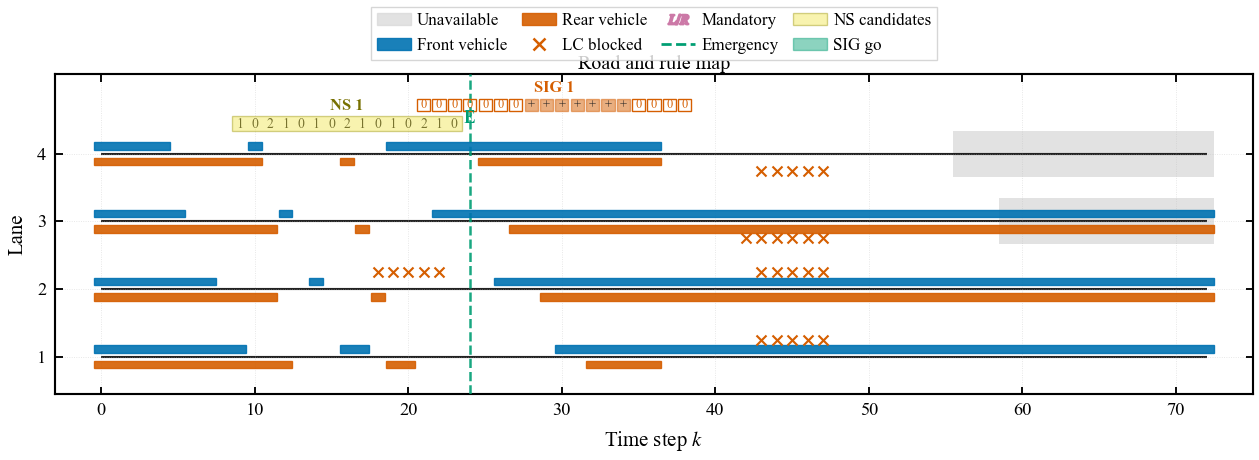

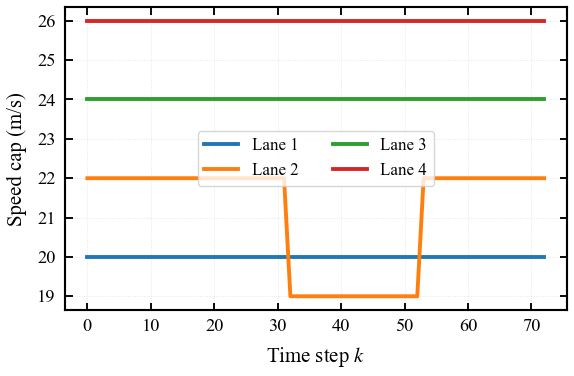

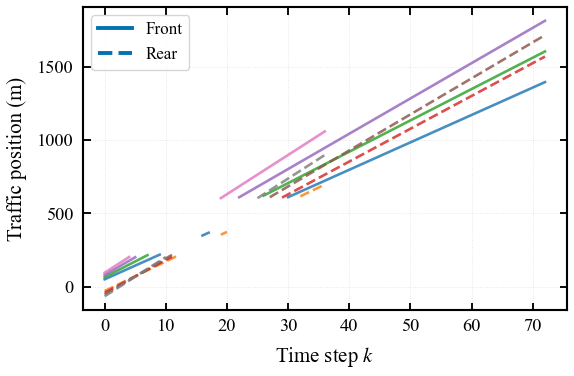

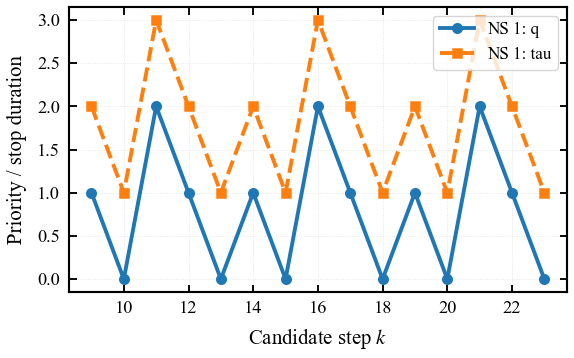

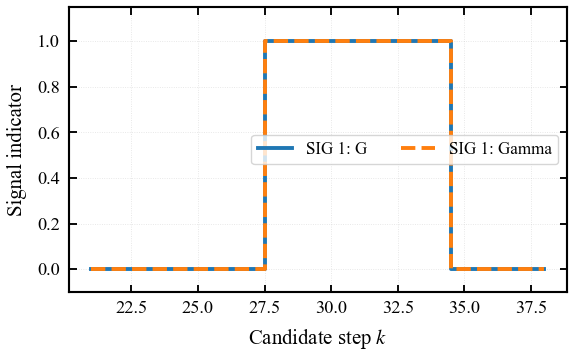

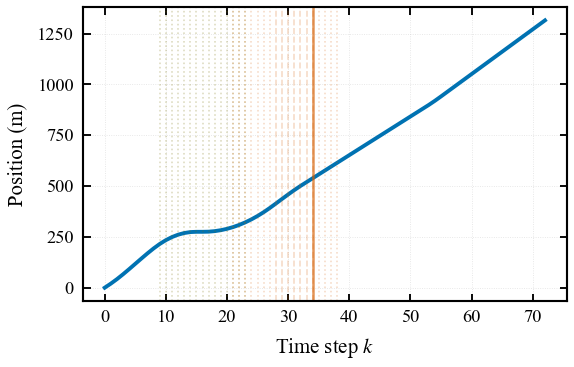

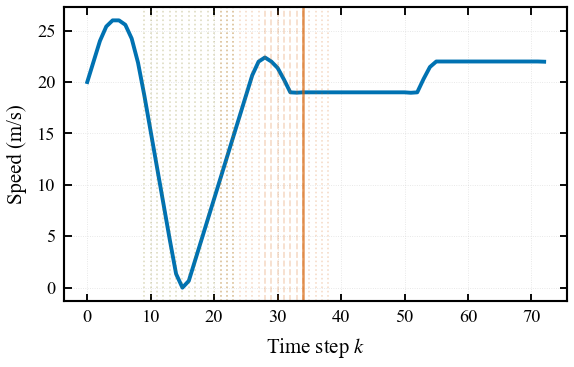

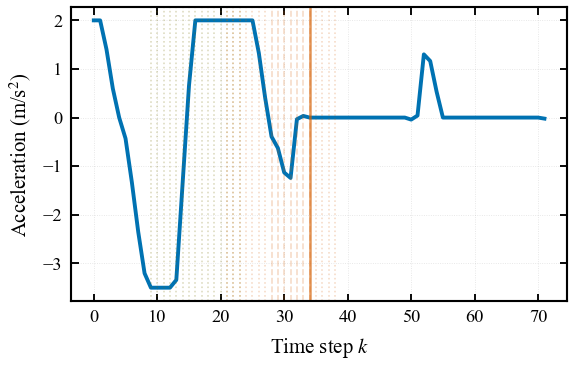

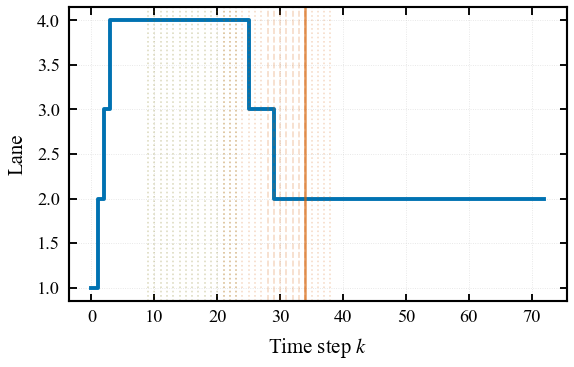

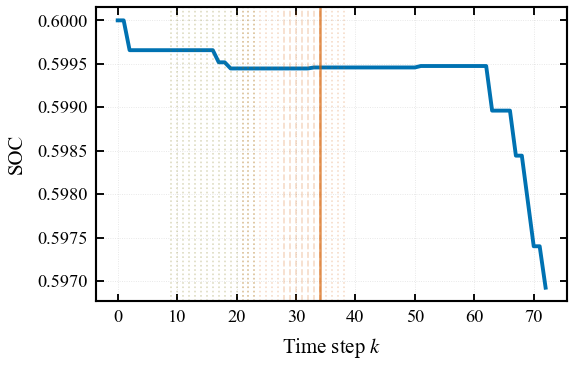

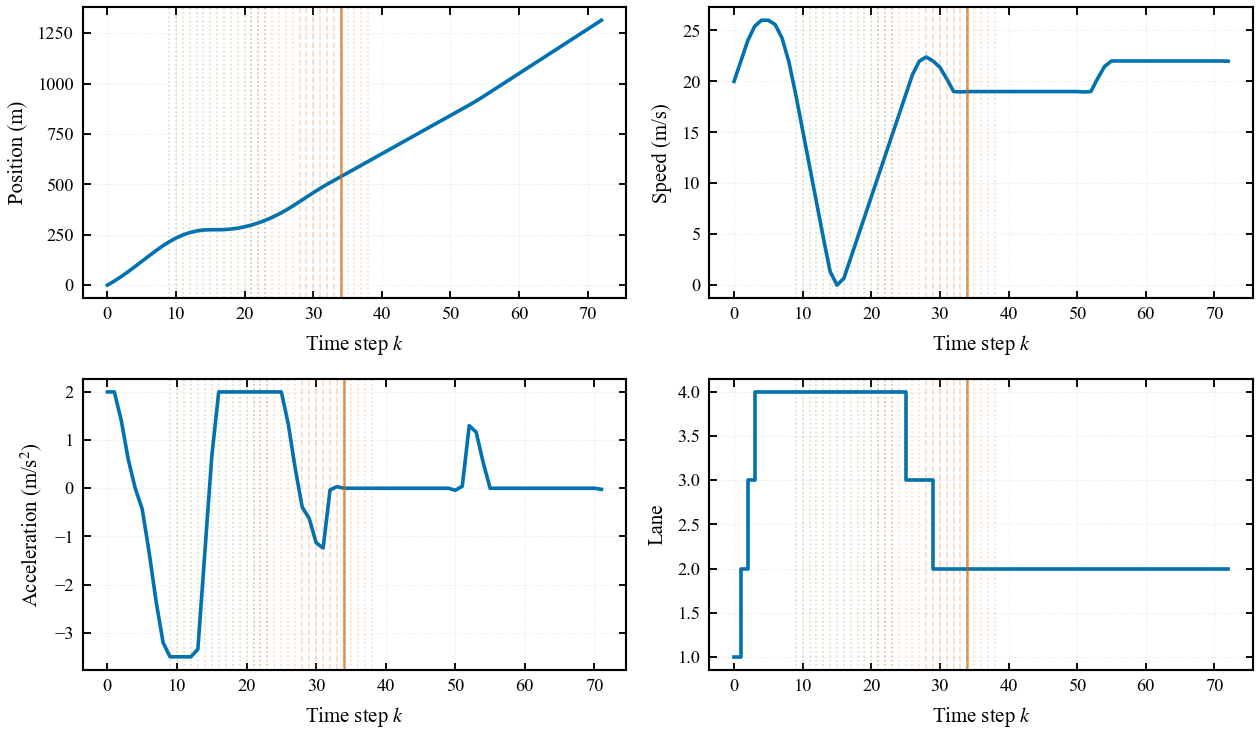

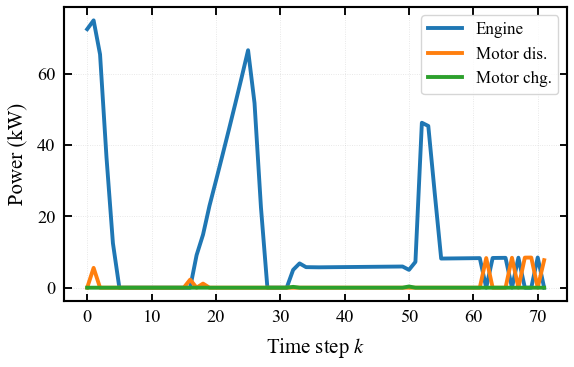

Run complete. Ordered outputs saved.
Root             : C:\Users\mhasa42\Desktop\test\paper_ready_runs\S001
Console log      : C:\Users\mhasa42\Desktop\test\paper_ready_runs\S001\00_logs\run_console_output.txt
Input plots      : C:\Users\mhasa42\Desktop\test\paper_ready_runs\S001\02_input_plots
Solution plots   : C:\Users\mhasa42\Desktop\test\paper_ready_runs\S001\03_solution_plots
SUMO folder      : C:\Users\mhasa42\Desktop\test\paper_ready_runs\S001\04_sumo
SUMO video       : C:\Users\mhasa42\Desktop\test\paper_ready_runs\S001\04_sumo\S001_sumo_video.mp4
SUMO video ok    : True


In [7]:
obj, sol, data, out = run_driving_scenario(
    scenario_id="S001",
    init_lane=1,
    base_export_dir=r"C:\Users\mhasa42\Desktop\test\paper_ready_runs",
    clean_output=True,

    export_sumo=True,
    auto_run_sumo=True,
    save_frames=True,
    make_video=True,

    use_gui=True,
    fixed_zoom=1600.0,
    dynamic_zoom=True,
    screenshot_width=2560,
    screenshot_height=1440,
    output_width=2200,
    output_height=650,
    crop_frames=True,
    crop_pad_px=10,
    seconds_per_frame=0.2,

    show_plots=True
)